<a href="https://www.kaggle.com/code/cutesybd/moi-base-publish-final?scriptVersionId=331256099" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Kernel Restart → Training Workflow

## Prerequisites
Add this dataset as notebook input:
- ✅ `cutesybd/ton-iot-pipeline-state`

---

## Cell Execution Order

| Step | Cell | Description | Time |
|:----:|:----:|-------------|:----:|
| **1** | **Cell 16b** | Fast Resume – loads data, config, functions, and Stage-1 results from dataset | ~30 sec |
| **2** | **Cell 17** | Stage-1 – detects saved results → **skips training**, prints summary | ~2 sec |
| **3** | **Cell 18** | Stage-2 – trains 6 multiclass models (or reloads if already saved) | ~100 min / ~2 sec |

---

## Flow Diagram


# Cell 16b – Quick Resume from Saved Dataset (Skip Cells 1-16)

In [17]:
# =============================================================================
# Cell 16b – Quick Resume from Output Directory
# =============================================================================
import os, json, pickle, time, re, random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any, Optional, Sequence

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# =============================================================================
# SECTION A – Paths
# =============================================================================
DATASET_PATH = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/output"
OUTPUT_DIR = "./output"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Copy files from dataset to local output for checkpoint saving
import shutil
for f in os.listdir(DATASET_PATH):
    src = os.path.join(DATASET_PATH, f)
    dst = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f"[Fast Resume] Dataset path: {DATASET_PATH}")

# =============================================================================
# SECTION B – Deterministic Environment
# =============================================================================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
try:
    tf.config.experimental.enable_op_determinism()
except: pass

print(f"[Fast Resume] GPUs: {len(gpus)}")

# =============================================================================
# SECTION C – Load Data
# =============================================================================
print(f"\n[Fast Resume] Loading data...")

# Load numpy arrays
X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(DATASET_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
y_train = np.load(os.path.join(DATASET_PATH, "y_train.npy")).astype(np.int32)
y_val   = np.load(os.path.join(DATASET_PATH, "y_val.npy")).astype(np.int32)
y_test  = np.load(os.path.join(DATASET_PATH, "y_test.npy")).astype(np.int32)
y_train_binary = np.load(os.path.join(DATASET_PATH, "y_train_binary.npy")).astype(np.int32)
y_val_binary   = np.load(os.path.join(DATASET_PATH, "y_val_binary.npy")).astype(np.int32)
y_test_binary  = np.load(os.path.join(DATASET_PATH, "y_test_binary.npy")).astype(np.int32)
sample_weights_train = np.load(os.path.join(DATASET_PATH, "sample_weights_train.npy"))
sample_weights_train_binary = np.load(os.path.join(DATASET_PATH, "sample_weights_train_binary.npy"))

SEQ_LEN = int(X_train.shape[1])

# Load config
with open(os.path.join(DATASET_PATH, "config.json"), "r") as f:
    config = json.load(f)
with open(os.path.join(DATASET_PATH, "label_dictionary.json"), "r") as f:
    label_dict = json.load(f)

CLASS_NAMES = label_dict["class_names"]
N_CLASSES = label_dict["n_classes"]
LABEL_TO_ID = {k: int(v) if isinstance(v, str) else v for k, v in label_dict["label_to_id"].items()}
ID_TO_LABEL = {int(k): v for k, v in label_dict["id_to_label"].items()}
MINORITY_CLASS_NAMES = label_dict.get("minority_class_names", [])
MINORITY_CLASS_IDS = label_dict.get("minority_class_ids", [])
NORMAL_CLASS_NAME = label_dict.get("normal_class_name", "normal")
N_FEATURES = config.get("N_FEATURES", SEQ_LEN)

print(f"  X_train: {X_train.shape}")
print(f"  N_FEATURES: {N_FEATURES}, N_CLASSES: {N_CLASSES}")

# =============================================================================
# SECTION D – Config
# =============================================================================
@dataclass(frozen=True)
class Config:
    seed: int = SEED
    output_dir: str = OUTPUT_DIR
    checkpoint_dir: str = CHECKPOINT_DIR
    batch_size: int = config.get("batch_size", 256)
    epochs: int = config.get("epochs", 80)
    patience_early: int = config.get("patience_early", 15)
    learning_rate: float = config.get("learning_rate", 5e-4)
    weight_decay: float = config.get("weight_decay", 1e-5)
    warmup_epochs: int = config.get("warmup_epochs", 5)
    max_class_weight: float = config.get("max_class_weight", 10.0)
    focal_gamma: float = config.get("focal_gamma", 2.0)
    satf_noise: float = config.get("satf_noise", 0.05)
    consistency_weight: float = config.get("consistency_weight", 0.5)
    moi_base_filters: int = config.get("moi_base_filters", 32)
    moi_dilation_rates: Tuple[int, ...] = tuple(config.get("moi_dilation_rates", (1, 2, 4)))
    moi_kernel_size: int = config.get("moi_kernel_size", 3)
    moi_sa_heads: int = config.get("moi_sa_heads", 2)
    moi_sa_key_dim: int = config.get("moi_sa_key_dim", 16)
    moi_dropout: float = config.get("moi_dropout", 0.25)
    moi_drop_path: float = config.get("moi_drop_path", 0.10)
    normal_class_name: str = NORMAL_CLASS_NAME
    n_features_actual: int = N_FEATURES
    # Defaults
    val_size: float = 0.15; test_size: float = 0.15; patience_lr: int = 5
    target_total_samples: int = 500000; majority_cap: int = 50000; minority_keep_all: bool = True
    minority_threshold: int = 5000
    shap_test_n: int = 500; shap_bg_n: int = 200; stability_noise: float = 0.15
    stability_seeds: Tuple[int, ...] = (0, 1, 2, 3, 4)
    stability_noise_levels: Tuple[float, float] = (0.10, 0.20); top_k: int = 15
    adv_epsilons: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.20); adv_test_n: int = 5000; adv_fgsm_batch: int = 128
    quant_test_n: int = 5000; quant_calibration_n: int = 200
    n_features_original: int = 34
    dataset_name: str = "TON-IoT"; base_path: str = "/kaggle/input"
    data_train_path: str = ""; data_test_path: str = ""
    dataset_keywords: Tuple[str, ...] = (); identifier_columns: Tuple[str, ...] = ()
    multiclass_label_col: str = "type"; binary_label_col: str = "label"; derived_target_col: str = "target"
    missing_placeholder: str = "-"; canonical_missing_token: str = "none"
    numeric_dash_columns: Tuple[str, ...] = (); high_cardinality_column: str = "dns_query"
    derived_indicator_name: str = "has_dns_query"
    figure_dir: str = os.path.join(OUTPUT_DIR, "figures")
    table_dir: str = os.path.join(OUTPUT_DIR, "tables")
    curves_dir: str = os.path.join(OUTPUT_DIR, "training_curves")
    def __post_init__(self):
        for d in [self.output_dir, self.checkpoint_dir, self.figure_dir, self.table_dir, self.curves_dir]:
            os.makedirs(d, exist_ok=True)

CFG = Config()
DATASET_CONFIG = {"N_FEATURES": N_FEATURES, "N_CLASSES": N_CLASSES}

# Stage-2 setup
NORMAL_CLASS_ID = LABEL_TO_ID.get(NORMAL_CLASS_NAME, 0)
ATTACK_CLASS_IDS_ORIGINAL = sorted(i for i in range(N_CLASSES) if i != NORMAL_CLASS_ID)
ATTACK_CLASS_NAMES = [CLASS_NAMES[i] for i in ATTACK_CLASS_IDS_ORIGINAL]
N_ATTACK_CLASSES = len(ATTACK_CLASS_IDS_ORIGINAL)
ATTACK_REMAP = {orig: cont for cont, orig in enumerate(ATTACK_CLASS_IDS_ORIGINAL)}
ATTACK_REMAP_INV = {cont: orig for orig, cont in ATTACK_REMAP.items()}

STAGE1_BINARY_KEYS = [
    "dnn_binary_nosatf", "dnn_binary_satf",
    "cnn_binary_nosatf", "cnn_binary_satf",
    "moi_lite_binary_nosatf", "moi_lite_binary_satf",
]
STAGE2_MULTICLASS_KEYS = [
    "dnn_multiclass_nosatf", "dnn_multiclass_satf",
    "cnn_multiclass_nosatf", "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf",
]
FLAT_MULTICLASS_KEYS = STAGE2_MULTICLASS_KEYS

def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_global_seed(SEED)

print(f"[Fast Resume] Config ready. epochs={CFG.epochs}")

# =============================================================================
# SECTION E – Loss Functions
# =============================================================================
_NUMERICAL_FLOOR = 1e-7

def make_sparse_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        batch_indices = tf.range(tf.shape(y_pred)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, y_true], axis=1)
        p_t = tf.gather_nd(y_pred, gather_indices)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

def make_binary_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

sparse_focal_loss_fn = make_sparse_focal_loss(gamma=CFG.focal_gamma)
binary_focal_loss_fn = make_binary_focal_loss(gamma=CFG.focal_gamma)

def kl_divergence_multiclass(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.clip_by_value(tf.cast(p_clean, tf.float32), epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(tf.cast(p_noisy, tf.float32), epsilon, 1.0 - epsilon)
    kl_forward = tf.reduce_sum(p_clean * tf.math.log(p_clean / p_noisy), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy * tf.math.log(p_noisy / p_clean), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))
kl_divergence_loss = kl_divergence_multiclass

def kl_divergence_binary(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.cast(tf.reshape(p_clean, [-1]), tf.float32)
    p_noisy = tf.cast(tf.reshape(p_noisy, [-1]), tf.float32)
    p_clean = tf.clip_by_value(p_clean, epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(p_noisy, epsilon, 1.0 - epsilon)
    p_clean_full = tf.stack([1.0 - p_clean, p_clean], axis=-1)
    p_noisy_full = tf.stack([1.0 - p_noisy, p_noisy], axis=-1)
    kl_forward = tf.reduce_sum(p_clean_full * tf.math.log(p_clean_full / p_noisy_full), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy_full * tf.math.log(p_noisy_full / p_clean_full), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))

print("[Fast Resume] Loss functions ready.")

# =============================================================================
# SECTION F – SpectralNorm + DropPath
# =============================================================================
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    def __init__(self, power_iterations=1):
        self.power_iterations = int(power_iterations); self.u = None
    def __call__(self, w):
        w_shape = w.shape.as_list(); w_2d = tf.reshape(w, [-1, w_shape[-1]])
        if self.u is None:
            self.u = tf.Variable(tf.random.normal([1, w_shape[-1]]), trainable=False, name="spectral_norm_u")
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))
        return w / (sigma + 1e-12)
    def get_config(self): return {"power_iterations": self.power_iterations}

def conv1d_with_sn(filters, kernel_size, dilation_rate=1, padding="same", use_bias=False, name=None):
    return tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                                   padding=padding, use_bias=use_bias,
                                   kernel_constraint=SpectralNormConstraint(power_iterations=1), name=name)

class DropPath(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.10, **kwargs):
        super().__init__(**kwargs); self.drop_prob = float(drop_prob)
    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0: return x
        keep_prob = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]; rank = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)
        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask = tf.floor(random_tensor)
        return (x / keep_prob) * binary_mask
    def get_config(self):
        config = super().get_config(); config.update({"drop_prob": self.drop_prob}); return config

print("[Fast Resume] SpectralNorm + DropPath ready.")

# =============================================================================
# SECTION G – Model Builders
# =============================================================================
def _attach_output_head(x, n_classes, binary, use_satf, architecture_prefix):
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        name = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name

def build_dnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              hidden_dims=(256, 128, 64), dropout_rate=0.30, name_prefix="dnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def build_cnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              filters=(64, 128, 64), kernel_sizes=(3, 5, 3), dropout_rate=0.30, name_prefix="cnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, name_prefix):
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(base_filters, kernel_size, dilation_rate=d, name=f"{name_prefix}_sn_conv_d{d}")(x)
        branch = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act_d{d}")(branch)
        branches.append(branch)
    return tf.keras.layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(branches)

def _light_self_attention(x, num_heads, key_dim, drop_path_rate, name_prefix):
    x_norm = tf.keras.layers.LayerNormalization(name=f"{name_prefix}_norm")(x)
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                                    use_bias=False, name=f"{name_prefix}_mha")(x_norm, x_norm)
    attention = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(attention)
    return tf.keras.layers.Add(name=f"{name_prefix}_residual")([x, attention])

def _channel_attention(x, reduction, name_prefix):
    channels = x.shape[-1]; reduced = max(channels // reduction, 4)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    reduced_dense = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name=f"{name_prefix}_fc1")(pooled)
    expanded_dense = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name=f"{name_prefix}_fc2")(reduced_dense)
    scale = tf.keras.layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(expanded_dense)
    return tf.keras.layers.Multiply(name=f"{name_prefix}_scale")([x, scale])

def _gated_residual_spectral_norm(x, filters, drop_path_rate, name_prefix):
    value = conv1d_with_sn(filters, kernel_size=3, name=f"{name_prefix}_sn_conv")(x)
    value = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(value)
    value = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act")(value)
    gate = conv1d_with_sn(filters, kernel_size=1, name=f"{name_prefix}_sn_gate")(x)
    gate = tf.keras.layers.Activation("sigmoid", name=f"{name_prefix}_gate_sig")(gate)
    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(gated)
    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(filters, 1, padding="same", use_bias=False, name=f"{name_prefix}_proj")(x)
    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])

def build_moi_lite(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                   base_filters=32, dilation_rates=(1, 2, 4), kernel_size=3,
                   sa_num_heads=2, sa_key_dim=16, drop_path_rate=0.10, dropout_rate=0.25,
                   name_prefix="moi_lite"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    x = _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, "msa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)
    x = _light_self_attention(x, sa_num_heads, sa_key_dim, drop_path_rate, "sa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)
    x = _channel_attention(x, reduction=4, name_prefix="ca")
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(x, multiscale_filters, drop_path_rate, "gr")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

print("[Fast Resume] Model builders ready.")

# =============================================================================
# SECTION H – Model Registry
# =============================================================================
_MODEL_KEY_PATTERN = re.compile(r"^(?P<architecture>dnn|cnn|moi_lite)_(?P<task>binary|multiclass)_(?P<variant>nosatf|satf)$")
def _parse_model_key(model_key):
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None: raise ValueError(f"Invalid model key: {model_key}")
    return match["architecture"], match["task"], match["variant"]

_ARCHITECTURE_BUILDERS = {"dnn": build_dnn, "cnn": build_cnn, "moi_lite": build_moi_lite}

def build_model_by_name(model_key, n_classes_override=None):
    architecture, task, variant = _parse_model_key(model_key)
    binary = (task == "binary"); use_satf = (variant == "satf")
    n_classes = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder = _ARCHITECTURE_BUILDERS[architecture]
    common_kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=binary,
                         use_satf=use_satf, satf_noise=CFG.satf_noise)
    if architecture == "moi_lite":
        return builder(**common_kwargs, base_filters=CFG.moi_base_filters,
                       dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
                       sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
                       drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    return builder(**common_kwargs)

def compile_classifier(model, binary=False, learning_rate=None):
    effective_lr = CFG.learning_rate if learning_rate is None else float(learning_rate)
    optimiser = tf.keras.optimizers.AdamW(learning_rate=effective_lr, weight_decay=CFG.weight_decay)
    if binary:
        loss = "binary_crossentropy"
        metrics = [tf.keras.metrics.BinaryAccuracy(name="acc"),
                   tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
                   tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
                   tf.keras.metrics.Precision(name="precision"),
                   tf.keras.metrics.Recall(name="recall")]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    model.compile(optimizer=optimiser, loss=loss, metrics=metrics)
    return model

def build_stage2_model(model_key):
    if "binary" in model_key: raise ValueError(f"Stage-2 must be multiclass.")
    return build_model_by_name(model_key, n_classes_override=N_ATTACK_CLASSES)

print("[Fast Resume] Model registry ready.")

# =============================================================================
# SECTION I – LR Schedule + Metrics
# =============================================================================
def warmup_cosine_schedule(epoch, total_epochs, lr_max, lr_min=1e-7, warmup_epochs=5):
    if epoch < warmup_epochs: return lr_max * (epoch + 1) / max(1, warmup_epochs)
    decay_progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    decay_progress = min(decay_progress, 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * decay_progress))

def evaluate_binary(model, X, y, batch_size=256, threshold=0.5):
    probability = model.predict(X, batch_size=batch_size, verbose=0).reshape(-1)
    prediction = (probability >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y, probability))
        metrics["pr_auc"] = float(average_precision_score(y, probability))
    except ValueError: metrics["roc_auc"] = float("nan"); metrics["pr_auc"] = float("nan")
    cm = confusion_matrix(y, prediction)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = (int(v) for v in cm.ravel())
        metrics["true_pos"] = tp; metrics["true_neg"] = tn
        metrics["false_pos"] = fp; metrics["false_neg"] = fn
        metrics["false_alarm_rate"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
        metrics["miss_rate"] = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0
    return metrics, probability, prediction

def evaluate_multiclass(model, X, y, class_names, minority_ids=None, batch_size=256):
    probability = model.predict(X, batch_size=batch_size, verbose=0)
    prediction = np.argmax(probability, axis=1)
    n_classes = len(class_names); class_index = list(range(n_classes))
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, prediction, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y, prediction, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    per_class_f1 = f1_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {class_names[i]: float(per_class_f1[i]) for i in class_index}
    if minority_ids: metrics["minority_macro_f1"] = float(np.mean([per_class_f1[i] for i in minority_ids]))
    per_class_precision = precision_score(y, prediction, labels=class_index, average=None, zero_division=0)
    per_class_recall = recall_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_precision"] = {class_names[i]: float(per_class_precision[i]) for i in class_index}
    metrics["per_class_recall"] = {class_names[i]: float(per_class_recall[i]) for i in class_index}
    try:
        y_binarised = label_binarize(y, classes=class_index)
        if probability.shape[1] == n_classes:
            metrics["roc_auc_ovr_macro"] = float(roc_auc_score(y_binarised, probability, average="macro", multi_class="ovr"))
            metrics["pr_auc_macro"] = float(average_precision_score(y_binarised, probability, average="macro"))
    except ValueError: metrics["roc_auc_ovr_macro"] = float("nan"); metrics["pr_auc_macro"] = float("nan")
    return metrics, probability, prediction

print("[Fast Resume] Metrics ready.")

# =============================================================================
# SECTION J – Training Loop
# =============================================================================
_LR_MIN = 1e-7
_NOISY_LOSS_WEIGHT = 0.5
_SHUFFLE_BUFFER_CAP = 10_000

@tf.function
def train_step_binary(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = binary_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = binary_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = binary_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

@tf.function
def train_step_multiclass(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = sparse_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = sparse_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_loss(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = sparse_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

def make_dataset(X, y, sample_weight=None, batch_size=256, shuffle=True, seed=42):
    if sample_weight is None: sample_weight = np.ones(len(X), dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.int32), sample_weight.astype(np.float32)))
    if shuffle: dataset = dataset.shuffle(buffer_size=min(_SHUFFLE_BUFFER_CAP, len(X)), seed=seed, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def train_model(model, X_train, y_train, sample_weights_train, X_val, y_val, *,
                binary, use_satf, model_key="model", epochs=None, batch_size=None,
                lr_max=None, patience_early=None, noise_sigma=None, consistency_weight=None,
                monitor_metric="macro_f1", monitor_mode="max", class_names=None,
                minority_ids=None, checkpoint_dir=None, verbose=1, resume=True):
    epochs = epochs or CFG.epochs; batch_size = batch_size or CFG.batch_size
    lr_max = lr_max or CFG.learning_rate; patience_early = patience_early or CFG.patience_early
    noise_sigma = noise_sigma or CFG.satf_noise; consistency_weight = consistency_weight or CFG.consistency_weight
    checkpoint_dir = checkpoint_dir or CFG.checkpoint_dir; class_names = class_names or CLASS_NAMES
    
    train_step_fn = train_step_binary if binary else train_step_multiclass
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_max, weight_decay=CFG.weight_decay)
    _zero_gradients = [tf.zeros_like(v) for v in model.trainable_variables]
    optimizer.apply_gradients(zip(_zero_gradients, model.trainable_variables))
    
    train_dataset = make_dataset(X_train, y_train, sample_weights_train, batch_size=batch_size, shuffle=True, seed=CFG.seed)
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"{model_key}_best.weights.h5")
    state_path = os.path.join(checkpoint_dir, f"{model_key}_state.json")
    
    history = defaultdict(list); start_epoch = 0
    best_metric = -np.inf if monitor_mode == "max" else np.inf; best_epoch = 0; patience_counter = 0
    
    if resume and os.path.exists(state_path):
        try:
            with open(state_path) as f: state = json.load(f)
            start_epoch = state.get('last_epoch', 0) + 1
            best_metric = state.get('best_metric', best_metric)
            best_epoch = state.get('best_epoch', 0)
            patience_counter = state.get('patience_counter', 0)
            if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
            else: start_epoch = 0
            print(f"[Resume] Resuming from epoch {start_epoch}")
        except Exception as e: print(f"[Resume] Failed: {e}"); start_epoch = 0
    
    noise_sigma_tensor = tf.constant(noise_sigma, dtype=tf.float32)
    consistency_weight_tensor = tf.constant(consistency_weight, dtype=tf.float32)
    
    if verbose >= 1:
        print(f"\n  training: {model.name} | SATF: {use_satf} | epochs: {epochs} | batch: {batch_size}")
    
    def save_state(epoch_num, best_metric_val, best_epoch_val, patience_val):
        state = {'last_epoch': epoch_num, 'best_metric': float(best_metric_val),
                 'best_epoch': best_epoch_val, 'patience_counter': patience_val,
                 'monitor_metric': monitor_metric, 'model_key': model_key}
        with open(state_path, 'w') as f: json.dump(state, f, indent=2)
    
    training_start_time = time.time()
    
    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()
        current_lr = warmup_cosine_schedule(epoch=epoch, total_epochs=epochs, lr_max=lr_max,
                                            lr_min=_LR_MIN, warmup_epochs=CFG.warmup_epochs)
        optimizer.learning_rate.assign(current_lr)
        
        epoch_loss_totals = {"total": [], "clean": [], "noisy": [], "consistency": []}
        for x_batch, y_batch, sw_batch in train_dataset:
            total, fc, fn, kl = train_step_fn(model, x_batch, y_batch, sw_batch, optimizer,
                                               use_satf=use_satf, noise_sigma=noise_sigma_tensor,
                                               consistency_weight=consistency_weight_tensor)
            epoch_loss_totals["total"].append(float(total.numpy()))
            epoch_loss_totals["clean"].append(float(fc.numpy()))
            epoch_loss_totals["noisy"].append(float(fn.numpy()))
            epoch_loss_totals["consistency"].append(float(kl.numpy()))
        
        if binary: val_metrics, _, _ = evaluate_binary(model, X_val, y_val, batch_size=batch_size)
        else: val_metrics, _, _ = evaluate_multiclass(model, X_val, y_val, class_names=class_names,
                                                       minority_ids=minority_ids, batch_size=batch_size)
        
        history["epoch"].append(epoch + 1); history["lr"].append(current_lr)
        history["train_loss"].append(float(np.mean(epoch_loss_totals["total"])))
        for mn, mv in val_metrics.items():
            if isinstance(mv, (int, float)): history[f"val_{mn}"].append(mv)
        
        current_metric = val_metrics.get(monitor_metric, 0.0)
        improved = (current_metric > best_metric) if monitor_mode == "max" else (current_metric < best_metric)
        
        if improved:
            best_metric, best_epoch, patience_counter = current_metric, epoch + 1, 0
            model.save_weights(checkpoint_path)
            save_state(epoch, best_metric, best_epoch, patience_counter)
            marker = "(saved)"
        else: patience_counter += 1; marker = ""
        
        if (epoch + 1) % 5 == 0: save_state(epoch, best_metric, best_epoch, patience_counter)
        
        epoch_duration = time.time() - epoch_start_time
        if verbose >= 1:
            extras = ""
            if not binary and "minority_macro_f1" in val_metrics: extras = f" min_F1={val_metrics['minority_macro_f1']:.4f}"
            print(f"  epoch {epoch+1:>3d}/{epochs} | loss={history['train_loss'][-1]:.4f} | "
                  f"val_{monitor_metric}={current_metric:.4f}{extras} | lr={current_lr:.2e} | {epoch_duration:>5.1f}s {marker}")
        
        if patience_counter >= patience_early:
            if verbose >= 1: print(f"\n  early stop at epoch {epoch+1}")
            break
    
    save_state(epoch, best_metric, best_epoch, patience_counter)
    training_duration = time.time() - training_start_time
    if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
    
    if verbose >= 1:
        print(f"\n  complete: {training_duration:.0f}s | best epoch: {best_epoch} | best {monitor_metric}: {best_metric:.4f}")
    
    return dict(history), best_epoch, float(best_metric), checkpoint_path

print("[Fast Resume] Training loop ready.")

# =============================================================================
# SECTION K.5 – Load Pre-Trained Stage-1 Results
# =============================================================================
STAGE1_SAVED_PATH = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/stage1_saved"

if os.path.exists(STAGE1_SAVED_PATH):
    print(f"\n[Fast Resume] Loading pre-trained Stage-1 results...")
    
    # Load results JSON
    stage1_json_src = os.path.join(STAGE1_SAVED_PATH, "stage1_results.json")
    if os.path.exists(stage1_json_src):
        with open(stage1_json_src, "r") as f:
            STAGE1_RESULTS = json.load(f)
        print(f"  Stage-1 results loaded: {len(STAGE1_RESULTS)} models")
        for key in STAGE1_BINARY_KEYS:
            if key in STAGE1_RESULTS:
                print(f"    {key:<35s} F1={STAGE1_RESULTS[key]['best_f1']:.4f}")
    
    # Restore checkpoints
    import shutil
    stage1_ckpt_src = os.path.join(STAGE1_SAVED_PATH, "checkpoints")
    stage1_ckpt_dst = os.path.join(CFG.checkpoint_dir, "stage1_binary")
    if os.path.exists(stage1_ckpt_src):
        os.makedirs(stage1_ckpt_dst, exist_ok=True)
        for f in os.listdir(stage1_ckpt_src):
            src = os.path.join(stage1_ckpt_src, f)
            dst = os.path.join(stage1_ckpt_dst, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
        print(f"  Checkpoints restored")
    
    # Restore curves
    stage1_curves_src = os.path.join(STAGE1_SAVED_PATH, "curves")
    stage1_curves_dst = os.path.join(CFG.curves_dir, "stage1_binary")
    if os.path.exists(stage1_curves_src):
        os.makedirs(stage1_curves_dst, exist_ok=True)
        for f in os.listdir(stage1_curves_src):
            src = os.path.join(stage1_curves_src, f)
            dst = os.path.join(stage1_curves_dst, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
        print(f"  Training curves restored")
    
    # Copy results to output for Cell 17 to detect
    stage1_results_dst = os.path.join(CFG.output_dir, "stage1_results.json")
    if not os.path.exists(stage1_results_dst):
        shutil.copy2(stage1_json_src, stage1_results_dst)
    stage1_summary_src = os.path.join(STAGE1_SAVED_PATH, "stage1_summary.csv")
    stage1_summary_dst = os.path.join(CFG.output_dir, "stage1_summary.csv")
    if os.path.exists(stage1_summary_src) and not os.path.exists(stage1_summary_dst):
        shutil.copy2(stage1_summary_src, stage1_summary_dst)
    
    print(f"  Stage-1 ready! Cell 17 will skip training.")
else:
    STAGE1_RESULTS = {}
    print(f"\n[Fast Resume] No pre-trained Stage-1 results found.")

# =============================================================================
# SECTION K.6 – Load Pre-Trained Stage-2 Results
# =============================================================================
# stage2_saved is at the dataset root, one level up from output/
STAGE2_SAVED_PATH = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/stage2_saved"

if os.path.exists(STAGE2_SAVED_PATH):
    print(f"\n[Fast Resume] Loading pre-trained Stage-2 results...")
    
    import shutil
    
    # Load results JSON
    stage2_json_src = os.path.join(STAGE2_SAVED_PATH, "stage2_results.json")
    if os.path.exists(stage2_json_src):
        with open(stage2_json_src, "r") as f:
            STAGE2_RESULTS = json.load(f)
        print(f"  Stage-2 results loaded: {len(STAGE2_RESULTS)} models")
        for key in STAGE2_MULTICLASS_KEYS:
            if key in STAGE2_RESULTS:
                print(f"    {key:<35s} macro F1={STAGE2_RESULTS[key]['best_macro_f1']:.4f}")
    
    # Restore checkpoints
    stage2_ckpt_src = os.path.join(STAGE2_SAVED_PATH, "checkpoints")
    stage2_ckpt_dst = os.path.join(CFG.checkpoint_dir, "stage2_multiclass")
    if os.path.exists(stage2_ckpt_src):
        os.makedirs(stage2_ckpt_dst, exist_ok=True)
        for f in os.listdir(stage2_ckpt_src):
            src = os.path.join(stage2_ckpt_src, f)
            dst = os.path.join(stage2_ckpt_dst, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
        print(f"  Checkpoints restored")
    
    # Restore curves
    stage2_curves_src = os.path.join(STAGE2_SAVED_PATH, "curves")
    stage2_curves_dst = os.path.join(CFG.curves_dir, "stage2_multiclass")
    if os.path.exists(stage2_curves_src):
        os.makedirs(stage2_curves_dst, exist_ok=True)
        for f in os.listdir(stage2_curves_src):
            src = os.path.join(stage2_curves_src, f)
            dst = os.path.join(stage2_curves_dst, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
        print(f"  Training curves restored")
    
    # Copy results to output for Cell 18 to detect
    stage2_results_dst = os.path.join(CFG.output_dir, "stage2_results.json")
    if not os.path.exists(stage2_results_dst):
        shutil.copy2(stage2_json_src, stage2_results_dst)
    stage2_summary_src = os.path.join(STAGE2_SAVED_PATH, "stage2_summary.csv")
    stage2_summary_dst = os.path.join(CFG.output_dir, "stage2_summary.csv")
    if os.path.exists(stage2_summary_src) and not os.path.exists(stage2_summary_dst):
        shutil.copy2(stage2_summary_src, stage2_summary_dst)
    
    print(f"  Stage-2 ready! Cell 18 will skip training.")
else:
    STAGE2_RESULTS = {}
    print(f"\n[Fast Resume] No pre-trained Stage-2 results found.")

# =============================================================================
# SECTION K.7 – Load All Experiment Results (Cells 19-26)
# =============================================================================
ALL_RESULTS_PATH = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/all_results_saved"

if os.path.exists(ALL_RESULTS_PATH):
    print(f"\n[Fast Resume] Loading all experiment results...")
    
    # Load each result file
    _result_files = {
        "HIERARCHICAL_RESULTS": "hierarchical_results.json",
        "STABILITY_RESULTS": "stability_results.json",
        "ADVERSARIAL_RESULTS": "adversarial_results.json",
        "QUANT_RESULTS": "quantization_results.json",
        "v4_results": "v4_moi_results.json",
    }
    
    for _var_name, _filename in _result_files.items():
        _src = os.path.join(ALL_RESULTS_PATH, _filename)
        if os.path.exists(_src):
            with open(_src, "r") as f:
                globals()[_var_name] = json.load(f)
            
            # Update STAGE1/STAGE2 with v4 results
            if _var_name == "v4_results":
                for _key, _rec in globals()[_var_name].items():
                    if "binary" in _key:
                        STAGE1_RESULTS[_key] = _rec
                    else:
                        STAGE2_RESULTS[_key] = _rec
            
            _count = len(globals()[_var_name]) if isinstance(globals()[_var_name], dict) else "loaded"
            print(f"  {_var_name:<25s}: {_count} entries")
    
    # Also update Stage-1/2 from saved files (in case they include v4 updates)
    _stage1_src = os.path.join(ALL_RESULTS_PATH, "stage1_results.json")
    _stage2_src = os.path.join(ALL_RESULTS_PATH, "stage2_results.json")
    
    if os.path.exists(_stage1_src):
        with open(_stage1_src, "r") as f:
            STAGE1_RESULTS.update(json.load(f))
        print(f"  STAGE1_RESULTS updated: {len(STAGE1_RESULTS)} models")
    
    if os.path.exists(_stage2_src):
        with open(_stage2_src, "r") as f:
            STAGE2_RESULTS.update(json.load(f))
        print(f"  STAGE2_RESULTS updated: {len(STAGE2_RESULTS)} models")
    
    print(f"  All experiment results loaded!")
else:
    HIERARCHICAL_RESULTS = {}
    STABILITY_RESULTS = {}
    ADVERSARIAL_RESULTS = {}
    QUANT_RESULTS = {}
    print(f"\n[Fast Resume] No experiment results found (will need to run Cells 19-26).")

# =============================================================================
# FINAL STATUS
# =============================================================================
print("\n" + "=" * 70)
print("[FAST RESUME] ALL COMPONENTS LOADED FROM DATASET")
print("=" * 70)
print(f"  Dataset path:        {DATASET_PATH}")
print(f"  GPU(s):              {len(gpus)} detected")
print(f"  X_train:             {X_train.shape}")
print(f"  X_val:               {X_val.shape}")
print(f"  X_test:              {X_test.shape}")
print(f"  N_FEATURES:          {N_FEATURES}")
print(f"  N_CLASSES:           {N_CLASSES}")
print(f"  Stage-1 keys:        {len(STAGE1_BINARY_KEYS)}")
print(f"  Stage-2 keys:        {len(STAGE2_MULTICLASS_KEYS)}")
print(f"  Checkpoint dir:      {CFG.checkpoint_dir}")
print(f"  epochs:              {CFG.epochs}")
print(f"  batch_size:          {CFG.batch_size}")
print(f"  learning_rate:       {CFG.learning_rate}")
print(f"  Stage-1 results:     {'LOADED' if STAGE1_RESULTS else 'Not found'}")
print(f"  Stage-2 results:     {'LOADED' if STAGE2_RESULTS else 'Not found'}")
print()
print("  Ready for Cell 17 + Cell 18 (training will auto-skip if results exist)!")
print(f"  Stage-1 results:     {'LOADED' if STAGE1_RESULTS else 'Not found'} ({len(STAGE1_RESULTS)} models)")
print(f"  Stage-2 results:     {'LOADED' if STAGE2_RESULTS else 'Not found'} ({len(STAGE2_RESULTS)} models)")
print(f"  Hierarchical:        {'LOADED' if HIERARCHICAL_RESULTS else 'Not found'}")
print(f"  SHAP Stability:      {'LOADED' if STABILITY_RESULTS else 'Not found'}")
print(f"  Adversarial:         {'LOADED' if ADVERSARIAL_RESULTS else 'Not found'}")
print(f"  Quantization:        {'LOADED' if QUANT_RESULTS else 'Not found'}")
print("  Training will auto-resume from saved checkpoints.")
print("=" * 70)

[Fast Resume] Dataset path: /kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/output
[Fast Resume] GPUs: 2

[Fast Resume] Loading data...
  X_train: (132787, 39)
  N_FEATURES: 39, N_CLASSES: 10
[Fast Resume] Config ready. epochs=80
[Fast Resume] Loss functions ready.
[Fast Resume] SpectralNorm + DropPath ready.
[Fast Resume] Model builders ready.
[Fast Resume] Model registry ready.
[Fast Resume] Metrics ready.
[Fast Resume] Training loop ready.

[Fast Resume] No pre-trained Stage-1 results found.

[Fast Resume] No pre-trained Stage-2 results found.

[Fast Resume] Loading all experiment results...
  HIERARCHICAL_RESULTS     : 36 entries
  STABILITY_RESULTS        : 6 entries
  ADVERSARIAL_RESULTS      : 6 entries
  QUANT_RESULTS            : 6 entries
  v4_results               : 4 entries
  STAGE1_RESULTS updated: 6 models
  STAGE2_RESULTS updated: 6 models
  All experiment results loaded!

[FAST RESUME] ALL COMPONENTS LOADED FROM DATASET
  Dataset path:        /kaggle/input/datas

# Cell 1 – Deterministic & Dataset‑Agnostic Execution Environment

In [1]:
# =============================================================================
# Cell 1 – Deterministic & Dataset‑Agnostic Execution Environment
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Default dataset : TON‑IoT (Kaggle mount, BASE_PATH = /kaggle/input)
#
# Description
# -----------
# 1. Configures a fully deterministic execution environment for TensorFlow,
#    NumPy, and Python's standard library.
#
# 2. Defines a centralised, dataset‑agnostic configuration block.  All
#    file paths, dataset‑specific column names, cleaning parameters, and
#    sampling targets are read from the ``DATASET_CONFIG`` dictionary.
#    The default values target the TON‑IoT dataset on Kaggle; to switch to
#    another intrusion detection dataset, modify this dictionary or set
#    the corresponding environment variables.
#
# Execution Order
# ---------------
# This module must be executed **first** in a fresh Python interpreter.
# =============================================================================

import os
import random
import sys
import logging
from typing import Dict, Any, Union, Callable, Tuple

# -----------------------------------------------------------------------------
# 1. Configure logging
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(message)s'
)
logger = logging.getLogger(__name__)

# -----------------------------------------------------------------------------
# 2. Global seed (project‑wide constant)
# -----------------------------------------------------------------------------
SEED: int = 42

# -----------------------------------------------------------------------------
# 3. Determinism environment variables (must be set before TensorFlow import)
# -----------------------------------------------------------------------------
_DETERMINISM_ENV: Dict[str, str] = {
    "PYTHONHASHSEED":         str(SEED),
    "TF_DETERMINISTIC_OPS":   "1",
    "TF_CUDNN_DETERMINISTIC": "1",
}

for key, value in _DETERMINISM_ENV.items():
    os.environ[key] = value

logger.info("Determinism environment variables configured.")

# -----------------------------------------------------------------------------
# 4. Library imports (after environment variables are set)
# -----------------------------------------------------------------------------
import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 5. TensorFlow thread configuration (must be set early)
# -----------------------------------------------------------------------------
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            logger.info(f"GPU memory growth enabled for: {gpu}")
        except RuntimeError as e:
            logger.warning(f"Could not set GPU memory growth: {e}")

# -----------------------------------------------------------------------------
# 6. TensorFlow op‑level determinism (TF ≥ 2.8)
# -----------------------------------------------------------------------------
try:
    tf.config.experimental.enable_op_determinism()
    logger.info("TensorFlow op‑level determinism enabled.")
except Exception as exc:
    logger.warning(f"Op‑level determinism unavailable ({exc}).")

# -----------------------------------------------------------------------------
# 7. Global seeding utility
# -----------------------------------------------------------------------------
def set_global_seed(seed: int = SEED) -> None:
    """Set seed for all random number generators in the project."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    logger.debug(f"Global seed set to {seed}")

set_global_seed(SEED)
logger.info(f"Global seed set to {SEED} for Python, NumPy, and TensorFlow.")

# -----------------------------------------------------------------------------
# 8. Dataset‑agnostic configuration (default: TON‑IoT on Kaggle)
# -----------------------------------------------------------------------------
# Environment‑variable override convention:
#   BASE_PATH              →  root directory where CSV files are searched
#   TRAIN_PATH             →  optional path to training CSV files
#   TEST_PATH              →  optional path to test CSV files
#   N_FEATURES             →  number of input features after preprocessing
#   N_CLASSES              →  number of output classes
#   DATASET_NAME           →  human‑readable dataset label
#   TARGET_SAMPLES         →  total samples after class‑balanced subsampling
#   MAJORITY_CAP           →  max samples per majority class
#   DATASET_KEYWORDS       →  comma‑separated substrings used to filter CSV
#                             files; only files whose path contains at least
#                             one keyword are loaded.
#   IDENTIFIER_COLUMNS     →  comma‑separated list of columns to drop
#   MULTICLASS_LABEL_COL   →  name of the multi‑class label column
#   BINARY_LABEL_COL       →  name of the binary label column
#   DERIVED_TARGET_COL     →  name to give the integer‑encoded label column
#   NORMAL_CLASS_NAME      →  label of the benign/normal class
#   MISSING_PLACEHOLDER    →  string used for missing/not applicable values
#   CANONICAL_MISSING_TOKEN→  token to replace the placeholder with
#   NUMERIC_DASH_COLUMNS   →  comma‑separated columns to coerce to int
#   HIGH_CARDINALITY_COLUMN→  column with high cardinality to replace
#   DERIVED_INDICATOR_NAME →  name for the derived binary indicator column
#   MINORITY_THRESHOLD     →  minimum sample count for a class to not be minority
# =============================================================================
DATASET_CONFIG: Dict[str, Any] = {
    # ------------------------------------------------------------------
    # Base directory for CSV discovery (Kaggle input mount)
    # ------------------------------------------------------------------
    "BASE_PATH": os.path.normpath("/kaggle/input"),
    # ------------------------------------------------------------------
    # Optional train/test overrides (set to empty strings if not used)
    # ------------------------------------------------------------------
    "TRAIN_PATH": "",
    "TEST_PATH":  "",
    # ------------------------------------------------------------------
    # Dataset characteristics (must match the preprocessing pipeline)
    # ------------------------------------------------------------------
    "N_FEATURES": 34,
    "N_CLASSES":  10,
    "DATASET_NAME": "TON-IoT",
    # ------------------------------------------------------------------
    # Class‑balanced subsampling defaults (TON‑IoT scale)
    # ------------------------------------------------------------------
    "TARGET_SAMPLES": 500_000,
    "MAJORITY_CAP":   50_000,
    # ------------------------------------------------------------------
    # Dataset‑specific file filter (substrings, case‑insensitive)
    # These are used by Cell 4 to ignore artefact CSV files.
    # ------------------------------------------------------------------
    "DATASET_KEYWORDS": ("ton", "iot", "network", "train", "test"),
    # ------------------------------------------------------------------
    # Cleaning & label configuration (TON‑IoT default)
    # ------------------------------------------------------------------
    "IDENTIFIER_COLUMNS":        ("src_ip", "dst_ip"),
    "MULTICLASS_LABEL_COL":      "type",
    "BINARY_LABEL_COL":          "label",
    "DERIVED_TARGET_COL":        "target",
    "NORMAL_CLASS_NAME":         "normal",
    "MISSING_PLACEHOLDER":       "-",
    "CANONICAL_MISSING_TOKEN":   "none",
    "NUMERIC_DASH_COLUMNS":      ("http_trans_depth",),
    "HIGH_CARDINALITY_COLUMN":   "dns_query",
    "DERIVED_INDICATOR_NAME":    "has_dns_query",
    "MINORITY_THRESHOLD":        5_000,
}

# -----------------------------------------------------------------------------
# 9. Environment‑variable override mapping (type‑safe)
# -----------------------------------------------------------------------------
# Each entry maps a config key to (ENV_VAR_NAME, type_converter)
_ENV_OVERRIDES: Dict[str, Tuple[str, Union[type, Callable]]] = {
    "BASE_PATH":              ("BASE_PATH",              lambda s: os.path.normpath(s)),
    "TRAIN_PATH":             ("TRAIN_PATH",             lambda s: os.path.normpath(s) if s else ""),
    "TEST_PATH":              ("TEST_PATH",              lambda s: os.path.normpath(s) if s else ""),
    "N_FEATURES":             ("N_FEATURES",             int),
    "N_CLASSES":              ("N_CLASSES",              int),
    "DATASET_NAME":           ("DATASET_NAME",           str),
    "TARGET_SAMPLES":         ("TARGET_SAMPLES",         int),
    "MAJORITY_CAP":           ("MAJORITY_CAP",           int),
    "DATASET_KEYWORDS":       ("DATASET_KEYWORDS",       
                                lambda s: tuple(kw.strip() for kw in s.split(",") if kw.strip())),
    "IDENTIFIER_COLUMNS":     ("IDENTIFIER_COLUMNS",     
                                lambda s: tuple(col.strip() for col in s.split(",") if col.strip())),
    "MULTICLASS_LABEL_COL":   ("MULTICLASS_LABEL_COL",   str),
    "BINARY_LABEL_COL":       ("BINARY_LABEL_COL",       str),
    "DERIVED_TARGET_COL":     ("DERIVED_TARGET_COL",     str),
    "NORMAL_CLASS_NAME":      ("NORMAL_CLASS_NAME",      str),
    "MISSING_PLACEHOLDER":    ("MISSING_PLACEHOLDER",    str),
    "CANONICAL_MISSING_TOKEN":("CANONICAL_MISSING_TOKEN", str),
    "NUMERIC_DASH_COLUMNS":   ("NUMERIC_DASH_COLUMNS",   
                                lambda s: tuple(col.strip() for col in s.split(",") if col.strip())),
    "HIGH_CARDINALITY_COLUMN":("HIGH_CARDINALITY_COLUMN", str),
    "DERIVED_INDICATOR_NAME": ("DERIVED_INDICATOR_NAME",  str),
    "MINORITY_THRESHOLD":     ("MINORITY_THRESHOLD",     int),
}

# Apply environment variable overrides
for key, (env_var, dtype) in _ENV_OVERRIDES.items():
    env_val = os.environ.get(env_var)
    if env_val is not None:
        try:
            DATASET_CONFIG[key] = dtype(env_val)
            logger.debug(f"Overriding {key} from env var {env_var}: {env_val}")
        except (ValueError, TypeError) as e:
            logger.warning(
                f"Could not cast env variable {env_var}='{env_val}' "
                f"using {dtype}. Error: {e}. Falling back to default."
            )

logger.info("Dataset configuration loaded:")
for key, value in DATASET_CONFIG.items():
    logger.info(f"  {key:<27} = {value}")

# -----------------------------------------------------------------------------
# 10. Configuration validation
# -----------------------------------------------------------------------------
class ConfigurationError(Exception):
    """Custom exception for configuration validation errors."""
    pass

def validate_config(config: Dict[str, Any]) -> None:
    """Perform comprehensive validation of the dataset configuration."""
    errors = []
    warnings = []
    
    # Check required numeric fields are positive
    numeric_positive = {
        "N_FEATURES": config["N_FEATURES"],
        "N_CLASSES": config["N_CLASSES"],
        "TARGET_SAMPLES": config["TARGET_SAMPLES"],
        "MAJORITY_CAP": config["MAJORITY_CAP"],
    }
    for field, value in numeric_positive.items():
        if value <= 0:
            errors.append(f"{field} must be positive (got {value})")
    
    # Check MINORITY_THRESHOLD is non-negative
    if config["MINORITY_THRESHOLD"] < 0:
        errors.append(f"MINORITY_THRESHOLD must be non-negative (got {config['MINORITY_THRESHOLD']})")
    
    # Check required string fields are not empty
    string_fields = [
        "DATASET_NAME", "MULTICLASS_LABEL_COL", "BINARY_LABEL_COL",
        "DERIVED_TARGET_COL", "NORMAL_CLASS_NAME", "MISSING_PLACEHOLDER",
        "CANONICAL_MISSING_TOKEN"
    ]
    for field in string_fields:
        if not config.get(field):
            errors.append(f"{field} must not be empty")
    
    # Check BASE_PATH exists (when not overridden by TRAIN_PATH/TEST_PATH)
    if not config["TRAIN_PATH"] and not config["TEST_PATH"]:
        base_path = config["BASE_PATH"]
        if not os.path.exists(base_path):
            warnings.append(f"BASE_PATH '{base_path}' does not exist")
        elif not os.path.isdir(base_path):
            errors.append(f"BASE_PATH '{base_path}' is not a directory")
    
    # Check path normalization
    for path_field in ["TRAIN_PATH", "TEST_PATH"]:
        path_value = config[path_field]
        if path_value:
            if not os.path.exists(path_value):
                warnings.append(f"{path_field} '{path_value}' does not exist")
            elif os.path.normpath(path_value) != path_value:
                warnings.append(f"{path_field} '{path_value}' is not normalized")
    
    # Check MAJORITY_CAP doesn't exceed TARGET_SAMPLES
    if config["MAJORITY_CAP"] > config["TARGET_SAMPLES"]:
        warnings.append(
            f"MAJORITY_CAP ({config['MAJORITY_CAP']}) exceeds "
            f"TARGET_SAMPLES ({config['TARGET_SAMPLES']})"
        )
    
    # Check DATASET_KEYWORDS is a non-empty tuple
    if not isinstance(config["DATASET_KEYWORDS"], tuple) or len(config["DATASET_KEYWORDS"]) == 0:
        errors.append("DATASET_KEYWORDS must be a non-empty tuple")
    
    # Check IDENTIFIER_COLUMNS is a tuple
    if not isinstance(config["IDENTIFIER_COLUMNS"], tuple):
        errors.append("IDENTIFIER_COLUMNS must be a tuple")
    
    # Check NUMERIC_DASH_COLUMNS is a tuple
    if not isinstance(config["NUMERIC_DASH_COLUMNS"], tuple):
        errors.append("NUMERIC_DASH_COLUMNS must be a tuple")
    
    # Report findings
    if errors:
        error_msg = "Configuration validation failed:\n  - " + "\n  - ".join(errors)
        raise ConfigurationError(error_msg)
    
    if warnings:
        logger.warning("Configuration warnings:")
        for warning in warnings:
            logger.warning(f"  ⚠ {warning}")

try:
    validate_config(DATASET_CONFIG)
    logger.info("Configuration validation passed.")
except ConfigurationError as e:
    logger.error(str(e))
    raise

# -----------------------------------------------------------------------------
# 11. Status summary
# -----------------------------------------------------------------------------
print("-" * 70)
print("Deterministic, dataset‑agnostic execution environment active.")
print(f"  • Dataset:  {DATASET_CONFIG['DATASET_NAME']}")
print(f"  • Features: {DATASET_CONFIG['N_FEATURES']}")
print(f"  • Classes:  {DATASET_CONFIG['N_CLASSES']}")
print(f"  • Base path: {DATASET_CONFIG['BASE_PATH']}")
print(f"  • Seed:     {SEED}")
print(f"  • GPU(s):   {len(gpus)} detected")
print("-" * 70)
print("Notes:")
print("  - GPU training throughput is reduced by ~2× with op‑level determinism.")
print("  - For cross‑machine reproducibility, cache intermediate outputs.")
print("  - To switch datasets, modify DATASET_CONFIG or set environment variables.")
print("  - See logs above for detailed configuration and any warnings.")
print("-" * 70)

# -----------------------------------------------------------------------------
# 12. Utility functions for downstream cells
# -----------------------------------------------------------------------------
def get_config_copy() -> Dict[str, Any]:
    """Return a deep copy of the current configuration."""
    import copy
    return copy.deepcopy(DATASET_CONFIG)

def is_config_valid() -> bool:
    """Check if current configuration is valid (for downstream cells)."""
    try:
        validate_config(DATASET_CONFIG)
        return True
    except ConfigurationError:
        return False

logger.info("Cell 1 initialization complete. Environment ready for downstream cells.")

[INFO] Determinism environment variables configured.
2026-06-29 10:06:24.492100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782727584.685174      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782727584.741917      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782727585.177223      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782727585.177261      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782727585.177264     

----------------------------------------------------------------------
Deterministic, dataset‑agnostic execution environment active.
  • Dataset:  TON-IoT
  • Features: 34
  • Classes:  10
  • Base path: /kaggle/input
  • Seed:     42
  • GPU(s):   2 detected
----------------------------------------------------------------------
Notes:
  - GPU training throughput is reduced by ~2× with op‑level determinism.
  - For cross‑machine reproducibility, cache intermediate outputs.
  - To switch datasets, modify DATASET_CONFIG or set environment variables.
  - See logs above for detailed configuration and any warnings.
----------------------------------------------------------------------


# Cell 2 – Core Library Imports, Hardware Verification, and Reproducibility Audit

In [2]:
# =============================================================================
# Cell 2 – Core Library Imports, Hardware Verification, and Reproducibility Audit
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : TON‑IoT (configurable via Cell 1)
#
# Description
# -----------
# This module performs three tasks required before any experimental work:
#   1. Importing the scientific Python stack and recording the installed
#      library versions for the paper's reproducibility appendix.
#   2. Verifying GPU availability and the memory growth configuration that
#      was already set in Cell 1 (avoids redundant configuration).
#   3. Auditing the deterministic execution environment configured in Cell 1
#      by drawing two independent random samples under an identical seed and
#      verifying bit‑for‑bit equality.
#
# Prerequisite
# ------------
# Cell 1 (deterministic, dataset‑agnostic environment) must have been executed
# in the current interpreter so that ``SEED``, ``set_global_seed``, and
# ``DATASET_CONFIG`` are available in the global namespace.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Standard library imports
# -----------------------------------------------------------------------------
import gc
import json
import sys
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# -----------------------------------------------------------------------------
# 2. Logging configuration (suppress only TensorFlow verbose logging)
# -----------------------------------------------------------------------------
import os

# Suppress TensorFlow INFO/WARNING messages (errors still shown)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Only filter specific warnings, not all warnings globally
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# -----------------------------------------------------------------------------
# 3. Third‑party scientific stack
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

# -----------------------------------------------------------------------------
# 4. Prerequisite verification
# -----------------------------------------------------------------------------
# Cell 1 must define the project‑wide seed, seeding utility, and dataset
# configuration. Explicit assertions produce clear diagnostic messages if the
# cells are executed out of order.
# -----------------------------------------------------------------------------
_required_globals = {
    "SEED": "The constant SEED",
    "set_global_seed": "The function set_global_seed()",
    "DATASET_CONFIG": "The dictionary DATASET_CONFIG",
}

_missing = []
for _name, _desc in _required_globals.items():
    if _name not in globals():
        _missing.append(f"  - {_desc} (variable '{_name}')")

if _missing:
    raise RuntimeError(
        "Cell 1 has not been executed. The following are required:\n" + 
        "\n".join(_missing)
    )

# -----------------------------------------------------------------------------
# 5. Library version and dataset identification
# -----------------------------------------------------------------------------
print("[Cell 2] Environment report:")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  Matplotlib  : {plt.matplotlib.__version__}")
print(f"  Seaborn     : {sns.__version__}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Dataset     : {DATASET_CONFIG['DATASET_NAME']}")
print(f"  Features    : {DATASET_CONFIG['N_FEATURES']}")
print(f"  Classes     : {DATASET_CONFIG['N_CLASSES']}")

# -----------------------------------------------------------------------------
# 6. GPU verification (configuration already done in Cell 1)
# -----------------------------------------------------------------------------
_gpus = tf.config.list_physical_devices("GPU")
_gpu_memory_growth_enabled = []

if _gpus:
    # Verify memory growth is already enabled from Cell 1
    for _idx, _gpu in enumerate(_gpus):
        try:
            _config = tf.config.experimental.get_memory_growth(_gpu)
            _gpu_memory_growth_enabled.append(_config)
        except Exception:
            _gpu_memory_growth_enabled.append(False)
    
    print(f"\n[Cell 2] GPU devices detected: {len(_gpus)}")
    for _idx, _gpu in enumerate(_gpus):
        _growth_status = "enabled" if _gpu_memory_growth_enabled[_idx] else "DISABLED"
        
        # Get GPU details if available
        try:
            _details = tf.config.experimental.get_device_details(_gpu)
            _gpu_name = _details.get('device_name', _gpu.name.split(':')[-1])
            _compute_cap = _details.get('compute_capability', 'N/A')
        except Exception:
            _gpu_name = _gpu.name
            _compute_cap = 'N/A'
        
        # Get GPU memory info (different methods for different TF versions)
        _gpu_memory_mb = "Unknown"
        try:
            # Method 1: Try to get memory info from device details
            if 'memory_limit' in _details:
                _gpu_memory_mb = f"{_details['memory_limit'] // (1024**2)} MB"
            else:
                # Method 2: Query using CUDA directly if available
                try:
                    import subprocess
                    _result = subprocess.run(
                        ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits', 
                         f'--id={_idx}'],
                        capture_output=True, text=True, timeout=5
                    )
                    if _result.returncode == 0:
                        _gpu_memory_mb = f"{int(_result.stdout.strip())} MB"
                except Exception:
                    pass
                
                # Method 3: Use TensorFlow memory info if available
                if _gpu_memory_mb == "Unknown":
                    try:
                        _mem_info = tf.config.experimental.get_memory_info(f'GPU:{_idx}')
                        _gpu_memory_mb = f"{_mem_info['total'] // (1024**2)} MB"
                    except Exception:
                        _gpu_memory_mb = "Not available"
        except Exception:
            _gpu_memory_mb = "Error retrieving"
        
        print(f"  GPU {_idx}: {_gpu.name}")
        print(f"    Device name        : {_gpu_name}")
        print(f"    Compute capability : {_compute_cap}")
        print(f"    Memory             : {_gpu_memory_mb}")
        print(f"    Memory growth      : {_growth_status}")
    
    if not all(_gpu_memory_growth_enabled):
        print("\n[Cell 2] Warning: Memory growth not enabled on all GPUs.")
        print("[Cell 2] Attempting to enable memory growth...")
        for _gpu in _gpus:
            try:
                tf.config.experimental.set_memory_growth(_gpu, True)
                print(f"  [OK] Enabled memory growth for {_gpu.name}")
            except RuntimeError as exc:
                print(f"  [FAILED] Could not enable memory growth: {exc}")
else:
    print("\n[Cell 2] No GPU device detected. Execution will fall back to CPU.")
    print("[Cell 2] Note: Full training of all six models may be impractical on CPU.")

# -----------------------------------------------------------------------------
# 7. Reproducibility audit
# -----------------------------------------------------------------------------
print("\n[Cell 2] Reproducibility audit:")

# Ensure we start from a clean seed
set_global_seed(SEED)
_numpy_sample_a = np.random.rand(5)
_tf_sample_a = tf.random.uniform([3])

# Reset and generate again
set_global_seed(SEED)
_numpy_sample_b = np.random.rand(5)
_tf_sample_b = tf.random.uniform([3])

# Check reproducibility with exact equality for determinism
_numpy_reproducible = np.array_equal(_numpy_sample_a, _numpy_sample_b)
_tf_reproducible = np.array_equal(_tf_sample_a.numpy(), _tf_sample_b.numpy())

print(f"  NumPy generator reproducible      : {_numpy_reproducible}")
print(f"  TensorFlow generator reproducible : {_tf_reproducible}")

# Additional debug info if reproducibility fails
if not _numpy_reproducible or not _tf_reproducible:
    print("\n[Cell 2] Debug information (reproducibility failed):")
    print(f"  NumPy sample A:     {_numpy_sample_a}")
    print(f"  NumPy sample B:     {_numpy_sample_b}")
    print(f"  NumPy abs diff:     {np.abs(_numpy_sample_a - _numpy_sample_b)}")
    print(f"  TensorFlow sample A: {_tf_sample_a.numpy()}")
    print(f"  TensorFlow sample B: {_tf_sample_b.numpy()}")
    print(f"  TensorFlow abs diff: {np.abs(_tf_sample_a.numpy() - _tf_sample_b.numpy())}")

# Assert reproducibility with informative error messages
assert _numpy_reproducible, (
    "Reproducibility audit failed: NumPy RNG is non-deterministic.\n"
    "Check that PYTHONHASHSEED is set correctly in Cell 1.\n"
    "Try setting os.environ['PYTHONHASHSEED'] = str(SEED) before importing numpy."
)
assert _tf_reproducible, (
    "Reproducibility audit failed: TensorFlow RNG is non-deterministic.\n"
    "Check that TF_DETERMINISTIC_OPS and TF_CUDNN_DETERMINISTIC are set in Cell 1.\n"
    "Also verify tf.config.experimental.enable_op_determinism() was called."
)

# -----------------------------------------------------------------------------
# 8. Additional environment checks
# -----------------------------------------------------------------------------
print("\n[Cell 2] Additional environment checks:")

# Check if determinism environment variables are still set
_determinism_vars = {
    "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"),
    "TF_DETERMINISTIC_OPS": os.environ.get("TF_DETERMINISTIC_OPS"),
    "TF_CUDNN_DETERMINISTIC": os.environ.get("TF_CUDNN_DETERMINISTIC"),
}

for _var, _value in _determinism_vars.items():
    _status = "[OK]" if _value else "[MISSING]"
    print(f"  {_var:<30} = {_value or 'NOT SET':<10} {_status}")

# Check TensorFlow determinism status
_is_deterministic = False
_check_method = ""

# Try official API (TF 2.8+)
try:
    _is_deterministic = tf.config.experimental.is_op_determinism_enabled()
    _check_method = "tf.config.experimental.is_op_determinism_enabled()"
except AttributeError:
    pass

# Fallback: check if environment variables are set and audit passed
if not _check_method:
    if (_determinism_vars["TF_DETERMINISTIC_OPS"] == "1" and 
        _determinism_vars["TF_CUDNN_DETERMINISTIC"] == "1"):
        _is_deterministic = True
        _check_method = "environment variables (audit passed)"

# Report determinism status
if _check_method:
    _det_status = "enabled" if _is_deterministic else "disabled"
    print(f"  TF op determinism                : {_det_status}")
    print(f"    (checked via: {_check_method})")
else:
    print(f"  TF op determinism                : Unable to verify")
    print(f"    (Note: TF 2.8+ supports op determinism via API or environment variables)")

# Check thread configuration
print(f"  TF intra-op threads              : {tf.config.threading.get_intra_op_parallelism_threads()}")
print(f"  TF inter-op threads              : {tf.config.threading.get_inter_op_parallelism_threads()}")

# Check if XLA is enabled (can affect determinism)
try:
    _xla_enabled = tf.config.optimizer.get_jit()
    print(f"  XLA compilation (JIT)            : {'enabled' if _xla_enabled else 'disabled'}")
except Exception:
    print(f"  XLA compilation (JIT)            : unknown")

# -----------------------------------------------------------------------------
# 9. Summary and recommendations
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 2] EXECUTION SUMMARY")
print("=" * 70)

# Overall status assessment
_status_items = []

# Check GPU status
if _gpus:
    _all_growth_enabled = all(_gpu_memory_growth_enabled)
    _gpu_status = "OK" if _all_growth_enabled else "PARTIAL"
    _status_items.append(f"  GPU:              {len(_gpus)} device(s) detected, memory growth {_gpu_status}")
else:
    _status_items.append(f"  GPU:              None (CPU-only execution)")

# Check reproducibility
_np_status = "REPRODUCIBLE" if _numpy_reproducible else "NON-DETERMINISTIC"
_tf_status = "REPRODUCIBLE" if _tf_reproducible else "NON-DETERMINISTIC"
_status_items.append(f"  NumPy RNG:        {_np_status}")
_status_items.append(f"  TensorFlow RNG:   {_tf_status}")

# Check determinism
_det_overall = "CONFIRMED" if _is_deterministic else "UNVERIFIED"
_status_items.append(f"  Determinism:      {_det_overall}")

# Check threading
_status_items.append(
    f"  Threading:        Intra={tf.config.threading.get_intra_op_parallelism_threads()}, "
    f"Inter={tf.config.threading.get_inter_op_parallelism_threads()}"
)

for _item in _status_items:
    print(_item)

# Overall verdict
_overall_ok = bool(_gpus) and _numpy_reproducible and _tf_reproducible
if _overall_ok:
    print("\n  Environment ready for training.")
else:
    print("\n  WARNING: Environment may not be fully configured for training.")

print("=" * 70)

# -----------------------------------------------------------------------------
# 10. Completion notice and cleanup
# -----------------------------------------------------------------------------
print("\n[Cell 2] Imports complete, hardware verified, reproducibility confirmed.")
print("-" * 70)

# Force garbage collection to free memory
gc.collect()

# Clear temporary variables to keep global namespace clean
del _required_globals, _missing, _name, _desc
del _numpy_sample_a, _numpy_sample_b, _tf_sample_a, _tf_sample_b
del _numpy_reproducible, _tf_reproducible
del _determinism_vars, _var, _value

[Cell 2] Environment report:
  Python      : 3.12.13
  NumPy       : 2.4.6
  Pandas      : 2.3.3
  Matplotlib  : 3.10.0
  Seaborn     : 0.13.2
  TensorFlow  : 2.19.0
  Dataset     : TON-IoT
  Features    : 34
  Classes     : 10

[Cell 2] GPU devices detected: 2
  GPU 0: /physical_device:GPU:0
    Device name        : Tesla T4
    Compute capability : (7, 5)
    Memory             : 15360 MB
    Memory growth      : enabled
  GPU 1: /physical_device:GPU:1
    Device name        : Tesla T4
    Compute capability : (7, 5)
    Memory             : 15360 MB
    Memory growth      : enabled

[Cell 2] Reproducibility audit:


I0000 00:00:1782727602.504010      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782727602.509952      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  NumPy generator reproducible      : True
  TensorFlow generator reproducible : True

[Cell 2] Additional environment checks:
  PYTHONHASHSEED                 = 42         [OK]
  TF_DETERMINISTIC_OPS           = 1          [OK]
  TF_CUDNN_DETERMINISTIC         = 1          [OK]
  TF op determinism                : enabled
    (checked via: environment variables (audit passed))
  TF intra-op threads              : 1
  TF inter-op threads              : 1
  XLA compilation (JIT)            : disabled

[Cell 2] EXECUTION SUMMARY
  GPU:              2 device(s) detected, memory growth OK
  NumPy RNG:        REPRODUCIBLE
  TensorFlow RNG:   REPRODUCIBLE
  Determinism:      CONFIRMED
  Threading:        Intra=1, Inter=1

  Environment ready for training.

[Cell 2] Imports complete, hardware verified, reproducibility confirmed.
----------------------------------------------------------------------


# Cell 3 – Experimental Configuration and Workspace Initialisation

In [3]:
# =============================================================================
# Cell 3 – Experimental Configuration and Workspace Initialisation
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : TON‑IoT (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# This module centralises every tunable parameter of the experimental study
# into a single immutable configuration object, creates the on‑disk directory
# layout used to persist artefacts, serialises the configuration to JSON for
# the reproducibility appendix, and declares the in‑memory result registries
# that downstream phases will populate.
# =============================================================================

import json
import os
from dataclasses import asdict, dataclass, field
from typing import Any, Dict, Tuple

# -----------------------------------------------------------------------------
# 1. Prerequisite verification
# -----------------------------------------------------------------------------
# Cell 1 must define DATASET_CONFIG in the global namespace
assert "DATASET_CONFIG" in globals(), (
    "Cell 1 has not been executed. DATASET_CONFIG is required."
)

# -----------------------------------------------------------------------------
# 2. Master configuration dataclass
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class Config:
    """
    Immutable container for every hyperparameter and path used in the study.
    Dataset‑dependent fields are obtained from ``DATASET_CONFIG`` (Cell 1).
    """

    # --- Reproducibility ----------------------------------------------------
    seed: int = 42  # Will be overridden in __post_init__ if needed

    # --- Dataset‑dependent paths & identifiers ------------------------------
    dataset_name:    str = "TON-IoT"
    base_path:       str = "/kaggle/input"
    data_train_path: str = ""
    data_test_path:  str = ""

    # --- Dataset‑specific file filter keywords ------------------------------
    dataset_keywords: Tuple[str, ...] = ()

    # --- Cleaning & label column names (from DATASET_CONFIG) ---------------
    identifier_columns:        Tuple[str, ...] = ()
    multiclass_label_col:      str = "type"
    binary_label_col:          str = "label"
    derived_target_col:        str = "target"
    normal_class_name:         str = "normal"
    missing_placeholder:       str = "-"
    canonical_missing_token:   str = "none"
    numeric_dash_columns:      Tuple[str, ...] = ()
    high_cardinality_column:   str = "dns_query"
    derived_indicator_name:    str = "has_dns_query"
    minority_threshold:        int = 5000

    # --- Output workspace (platform‑independent) ----------------------------
    output_dir:     str = "./output"
    checkpoint_dir: str = "./output/checkpoints"
    figure_dir:     str = "./output/figures"
    table_dir:      str = "./output/tables"
    curves_dir:     str = "./output/training_curves"

    # --- Class‑balanced subsampling (dataset‑specific, adjustable) --------
    target_total_samples: int = 500000
    majority_cap:         int = 50000
    minority_keep_all:    bool = True

    # --- Train / validation / test split ----------------------------------
    val_size:  float = 0.15
    test_size: float = 0.15

    # --- Training schedule -------------------------------------------------
    batch_size:       int   = 256
    epochs:           int   = 80
    patience_early:   int   = 15
    patience_lr:      int   = 5
    learning_rate:    float = 5e-4
    weight_decay:     float = 1e-5
    warmup_epochs:    int   = 5
    max_class_weight: float = 10.0

    # --- Loss function -----------------------------------------------------
    focal_gamma: float = 2.0

    # --- E‑SATF (Explanation‑Stability‑Aware Training Framework) v3 -------
    satf_noise:         float = 0.05
    consistency_weight: float = 0.50

    # --- MOI‑Lite architecture --------------------------------------------
    moi_base_filters:   int   = 32
    moi_dilation_rates: Tuple[int, int, int] = (1, 2, 4)
    moi_kernel_size:    int   = 3
    moi_sa_heads:       int   = 2
    moi_sa_key_dim:     int   = 16
    moi_dropout:        float = 0.25
    moi_drop_path:      float = 0.10

    # --- SHAP‑based explanation stability evaluation ----------------------
    shap_test_n:            int               = 500
    shap_bg_n:              int               = 200
    stability_noise:        float             = 0.15
    stability_seeds:        Tuple[int, ...]   = (0, 1, 2, 3, 4)
    stability_noise_levels: Tuple[float, float] = (0.10, 0.20)
    top_k:                  int               = 15

    # --- FGSM adversarial evaluation --------------------------------------
    adv_epsilons:   Tuple[float, ...] = (0.01, 0.05, 0.10, 0.20)
    adv_test_n:     int               = 5000
    adv_fgsm_batch: int               = 128

    # --- Post‑training INT8 quantisation ----------------------------------
    quant_test_n:        int = 5000
    quant_calibration_n: int = 200

    def __post_init__(self):
        """
        Override default values with DATASET_CONFIG values from Cell 1.
        This method is called automatically after __init__ by the dataclass.
        Since the dataclass is frozen, we must use object.__setattr__.
        """
        # Map Config field names to DATASET_CONFIG keys
        _dataset_overrides = {
            "dataset_name":           "DATASET_NAME",
            "base_path":              "BASE_PATH",
            "data_train_path":        "TRAIN_PATH",
            "data_test_path":         "TEST_PATH",
            "dataset_keywords":       "DATASET_KEYWORDS",
            "identifier_columns":     "IDENTIFIER_COLUMNS",
            "multiclass_label_col":   "MULTICLASS_LABEL_COL",
            "binary_label_col":       "BINARY_LABEL_COL",
            "derived_target_col":     "DERIVED_TARGET_COL",
            "normal_class_name":      "NORMAL_CLASS_NAME",
            "missing_placeholder":    "MISSING_PLACEHOLDER",
            "canonical_missing_token":"CANONICAL_MISSING_TOKEN",
            "numeric_dash_columns":   "NUMERIC_DASH_COLUMNS",
            "high_cardinality_column":"HIGH_CARDINALITY_COLUMN",
            "derived_indicator_name": "DERIVED_INDICATOR_NAME",
            "minority_threshold":     "MINORITY_THRESHOLD",
            "target_total_samples":   "TARGET_SAMPLES",
            "majority_cap":           "MAJORITY_CAP",
        }
        
        for _config_field, _dataset_key in _dataset_overrides.items():
            if _dataset_key in DATASET_CONFIG:
                _value = DATASET_CONFIG[_dataset_key]
                # Ensure tuple fields remain tuples
                if isinstance(getattr(self, _config_field), tuple) and not isinstance(_value, tuple):
                    _value = tuple(_value)
                object.__setattr__(self, _config_field, _value)


# -----------------------------------------------------------------------------
# 3. Instantiate configuration
# -----------------------------------------------------------------------------
CFG = Config()

print("[Cell 3] Configuration object instantiated (immutable/frozen).")

# -----------------------------------------------------------------------------
# 4. Workspace directory layout
# -----------------------------------------------------------------------------
_DIRECTORIES = [
    CFG.output_dir,
    CFG.checkpoint_dir,
    CFG.figure_dir,
    CFG.table_dir,
    CFG.curves_dir,
    os.path.join(CFG.checkpoint_dir, "stage1_binary"),
    os.path.join(CFG.checkpoint_dir, "stage2_multiclass"),
    os.path.join(CFG.checkpoint_dir, "ablation"),
]

print("\n[Cell 3] Initialising workspace directories:")
for _directory in _DIRECTORIES:
    os.makedirs(_directory, exist_ok=True)
    print(f"  created/verified : {_directory}")

# -----------------------------------------------------------------------------
# 5. Configuration serialisation
# -----------------------------------------------------------------------------
def _config_to_serialisable(cfg: Config) -> Dict[str, Any]:
    """
    Convert Config dataclass to JSON-serialisable dictionary.
    Tuples are converted to lists for JSON compatibility.
    """
    payload = asdict(cfg)
    for key, value in payload.items():
        if isinstance(value, tuple):
            payload[key] = list(value)
    return payload

_config_payload = _config_to_serialisable(CFG)
_config_path = os.path.join(CFG.output_dir, "config.json")

with open(_config_path, "w", encoding="utf-8") as _fh:
    json.dump(_config_payload, _fh, indent=4, default=str)

print(f"\n[Cell 3] Configuration snapshot written to: {_config_path}")

# -----------------------------------------------------------------------------
# 6. Configuration report
# -----------------------------------------------------------------------------
_REPORT_SECTIONS = [
    ("Reproducibility", ["seed"]),
    ("Paths", [
        "output_dir", "checkpoint_dir", "figure_dir", "table_dir", "curves_dir",
    ]),
    ("Dataset", [
        "dataset_name", "base_path", "data_train_path", "data_test_path",
        "dataset_keywords",
    ]),
    ("Cleaning & labels", [
        "identifier_columns", "multiclass_label_col", "binary_label_col",
        "derived_target_col", "normal_class_name", "missing_placeholder",
        "canonical_missing_token", "numeric_dash_columns", "high_cardinality_column",
        "derived_indicator_name", "minority_threshold",
    ]),
    ("Subsampling", [
        "target_total_samples", "majority_cap", "minority_keep_all",
    ]),
    ("Splits", [
        "val_size", "test_size",
    ]),
    ("Training", [
        "batch_size", "epochs", "patience_early", "patience_lr",
        "learning_rate", "weight_decay", "warmup_epochs", "max_class_weight",
    ]),
    ("Loss", [
        "focal_gamma",
    ]),
    ("E‑SATF v3", [
        "satf_noise", "consistency_weight",
    ]),
    ("MOI‑Lite architecture", [
        "moi_base_filters", "moi_dilation_rates", "moi_kernel_size",
        "moi_sa_heads", "moi_sa_key_dim", "moi_dropout", "moi_drop_path",
    ]),
    ("Stability evaluation", [
        "shap_test_n", "shap_bg_n", "stability_noise",
        "stability_seeds", "stability_noise_levels", "top_k",
    ]),
    ("Adversarial evaluation", [
        "adv_epsilons", "adv_test_n", "adv_fgsm_batch",
    ]),
    ("Quantisation", [
        "quant_test_n", "quant_calibration_n",
    ]),
]

print("\n" + "-" * 70)
print("[Cell 3] Full configuration:")
print("-" * 70)
for _section_name, _section_keys in _REPORT_SECTIONS:
    print(f"\n  [{_section_name}]")
    for _key in _section_keys:
        _value = getattr(CFG, _key)
        # Format tuples/lists nicely
        if isinstance(_value, tuple):
            _value_str = str(list(_value))
        else:
            _value_str = str(_value)
        print(f"    {_key:<30s} : {_value_str}")

# -----------------------------------------------------------------------------
# 7. Result registries
# -----------------------------------------------------------------------------
TRAINING_RESULTS:     Dict[str, Any] = {}
STAGE1_RESULTS:       Dict[str, Any] = {}
STAGE2_RESULTS:       Dict[str, Any] = {}
EVAL_RESULTS:         Dict[str, Any] = {}
STABILITY_RESULTS:    Dict[str, Any] = {}
ADVERSARIAL_RESULTS:  Dict[str, Any] = {}
QUANT_RESULTS:        Dict[str, Any] = {}
HIERARCHICAL_RESULTS: Dict[str, Any] = {}
ABLATION_RESULTS:     Dict[str, Any] = {}
FINAL_PIPELINES:      Dict[str, Any] = {}

_REGISTRY_NAMES = [
    "TRAINING_RESULTS", "STAGE1_RESULTS", "STAGE2_RESULTS",
    "EVAL_RESULTS",     "STABILITY_RESULTS", "ADVERSARIAL_RESULTS",
    "QUANT_RESULTS",    "HIERARCHICAL_RESULTS", "ABLATION_RESULTS",
    "FINAL_PIPELINES",
]

print("\n" + "-" * 70)
print("[Cell 3] Result registries initialised (all empty):")
for _name in _REGISTRY_NAMES:
    print(f"    {_name}")

# -----------------------------------------------------------------------------
# 8. Validation summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 3] CONFIGURATION VALIDATION")
print("=" * 70)

_validation_checks = []

# Check paths
_path_checks = [
    ("base_path", CFG.base_path),
    ("data_train_path", CFG.data_train_path if CFG.data_train_path else CFG.base_path),
    ("data_test_path", CFG.data_test_path if CFG.data_test_path else CFG.base_path),
]
for _name, _path in _path_checks:
    if _path and os.path.exists(_path):
        _validation_checks.append(f"  [OK] {_name}: {_path}")
    elif _path:
        _validation_checks.append(f"  [WARNING] {_name}: {_path} (does not exist yet)")

# Check split ratios
_total_split = CFG.val_size + CFG.test_size
if _total_split < 1.0:
    _validation_checks.append(f"  [OK] Train/val/test split: {(1.0 - _total_split):.1%}/{CFG.val_size:.1%}/{CFG.test_size:.1%}")
else:
    _validation_checks.append(f"  [ERROR] Split ratios sum to {_total_split}, must be < 1.0")

# Check subsampling logic
if CFG.majority_cap <= CFG.target_total_samples:
    _validation_checks.append(f"  [OK] Majority cap ({CFG.majority_cap}) <= target samples ({CFG.target_total_samples})")
else:
    _validation_checks.append(f"  [WARNING] Majority cap ({CFG.majority_cap}) > target samples ({CFG.target_total_samples})")

# Print validation
for _check in _validation_checks:
    print(_check)

print("=" * 70)
print("[Cell 3] Configuration and workspace initialisation complete.")

[Cell 3] Configuration object instantiated (immutable/frozen).

[Cell 3] Initialising workspace directories:
  created/verified : ./output
  created/verified : ./output/checkpoints
  created/verified : ./output/figures
  created/verified : ./output/tables
  created/verified : ./output/training_curves
  created/verified : ./output/checkpoints/stage1_binary
  created/verified : ./output/checkpoints/stage2_multiclass
  created/verified : ./output/checkpoints/ablation

[Cell 3] Configuration snapshot written to: ./output/config.json

----------------------------------------------------------------------
[Cell 3] Full configuration:
----------------------------------------------------------------------

  [Reproducibility]
    seed                           : 42

  [Paths]
    output_dir                     : ./output
    checkpoint_dir                 : ./output/checkpoints
    figure_dir                     : ./output/figures
    table_dir                      : ./output/tables
    curves

# Cell 4 – Dataset Discovery and Exploratory Data Analysis

In [4]:
# =============================================================================
# Cell 4 – Dataset Discovery and Exploratory Data Analysis
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Configured via DATASET_CONFIG (default TON‑IoT)
#
# Description
# -----------
# This module loads the dataset specified by the centralised configuration,
# performs an exploratory data analysis (EDA), and persists an EDA metadata
# record to disk for the reproducibility appendix.
# It scans the base path for CSV files, filters them using dataset‑specific
# keywords, loads the relevant files into a single pandas DataFrame, audits
# the schema, identifies label columns, and reports summary statistics.
# No data transformation is performed; all cleaning and feature engineering
# are deferred to subsequent cells so that the EDA snapshot reflects the
# dataset in its original form.
#
# Prerequisites
# -------------
# Cells 1, 2, and 3 must have been executed in the current interpreter.
# =============================================================================

import json
import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG" in globals(), "Cell 3 has not been executed; the CFG object is required."
assert "DATASET_CONFIG" in globals(), "Cell 1 has not been executed; DATASET_CONFIG is required."

# -----------------------------------------------------------------------------
# 1. Locate and filter CSV files using dataset‑specific keywords
# -----------------------------------------------------------------------------
_BASE_PATH = Path(CFG.base_path)

# Check if base path exists before searching
if not _BASE_PATH.exists():
    raise FileNotFoundError(
        f"Base path does not exist: {_BASE_PATH}\n"
        f"Check DATASET_CONFIG['BASE_PATH'] in Cell 1."
    )

_ALL_CSV_FILES: List[Path] = sorted(_BASE_PATH.rglob("*.csv"))

print(f"[Cell 4] Searching for CSV files under: {_BASE_PATH}")
print(f"[Cell 4] Total CSV files discovered: {len(_ALL_CSV_FILES)}")

if not _ALL_CSV_FILES:
    raise FileNotFoundError(
        f"No CSV files found under {_BASE_PATH}. "
        "Check that the dataset is mounted correctly."
    )

_KEYWORDS = CFG.dataset_keywords
if _KEYWORDS:
    _CSV_FILES = [
        path for path in _ALL_CSV_FILES
        if any(kw in str(path).lower() for kw in _KEYWORDS)
    ]
    print(f"[Cell 4] After keyword filtering (keywords: {_KEYWORDS}): "
          f"{len(_CSV_FILES)} files")
else:
    _CSV_FILES = _ALL_CSV_FILES
    print("[Cell 4] No keyword filter applied – using all discovered CSV files.")

if not _CSV_FILES:
    raise FileNotFoundError(
        f"No CSV files matched the keywords {_KEYWORDS} under {_BASE_PATH}. "
        "Check DATASET_KEYWORDS in Cell 1 or verify file names."
    )

for _path in _CSV_FILES:
    _size_mb = _path.stat().st_size / (1024 ** 2)
    print(f"  {_path.name:<50s} ({_size_mb:>8.1f} MB)  {_path}")


# -----------------------------------------------------------------------------
# 2. Load candidate files into memory
# -----------------------------------------------------------------------------
_LARGE_FILE_THRESHOLD_MB = 2_000
_LARGE_FILE_ROW_CAP = 500_000

print("\n[Cell 4] Loading dataset files into memory:")
_loaded_frames: Dict[str, pd.DataFrame] = {}
_skipped_files: List[str] = []

for _path in _CSV_FILES:
    _size_mb = _path.stat().st_size / (1024 ** 2)
    
    try:
        if _size_mb > _LARGE_FILE_THRESHOLD_MB:
            print(
                f"  {_path.name}: {_size_mb:.0f} MB exceeds threshold "
                f"({_LARGE_FILE_THRESHOLD_MB} MB); loading first "
                f"{_LARGE_FILE_ROW_CAP:,} rows."
            )
            _frame = pd.read_csv(_path, nrows=_LARGE_FILE_ROW_CAP, low_memory=False)
        else:
            print(f"  {_path.name}: {_size_mb:.1f} MB; loading in full.")
            _frame = pd.read_csv(_path, low_memory=False)
        
        # Basic validation of loaded data
        if _frame.empty:
            print(f"    WARNING: File is empty, skipping.")
            _skipped_files.append(_path.name)
            continue
            
        print(f"    shape={_frame.shape}, columns={len(_frame.columns)}")
        _loaded_frames[_path.name] = _frame
        
    except pd.errors.EmptyDataError:
        print(f"    WARNING: EmptyDataError for {_path.name}, skipping.")
        _skipped_files.append(_path.name)
    except Exception as e:
        print(f"    ERROR loading {_path.name}: {e}")
        _skipped_files.append(_path.name)

if _skipped_files:
    print(f"\n[Cell 4] Warning: Skipped {len(_skipped_files)} file(s): {_skipped_files}")

if not _loaded_frames:
    raise ValueError("No CSV files could be loaded successfully.")


# -----------------------------------------------------------------------------
# 3. Select the primary DataFrame
# -----------------------------------------------------------------------------
def _select_primary_frame(
    frames: Dict[str, pd.DataFrame],
) -> Tuple[str, pd.DataFrame]:
    """
    Choose the primary DataFrame from the loaded candidate files.
    Handles single files, disjoint train/test files, and files whose name
    contains both 'train' and 'test' (concatenated datasets) without
    double‑counting.
    """
    if len(frames) == 1:
        name = next(iter(frames))
        return name, frames[name]

    train_keys = {k for k in frames if "train" in k.lower()}
    test_keys  = {k for k in frames if "test"  in k.lower()}

    # Files that match both (e.g., train_test_network.csv) contain the full dataset
    common = train_keys & test_keys
    if common:
        common_name = max(common, key=lambda k: len(frames[k]))
        print(f"[Cell 4] Using combined train/test file: {common_name}")
        return common_name, frames[common_name]

    # Disjoint train and test files
    if train_keys and test_keys:
        print(f"[Cell 4] Concatenating {len(train_keys)} train + {len(test_keys)} test files")
        concatenated = pd.concat(
            [frames[k] for k in sorted(train_keys)] +
            [frames[k] for k in sorted(test_keys)],
            ignore_index=True,
        )
        return "concatenated", concatenated

    # Fallback: return the largest file
    name = max(frames, key=lambda k: len(frames[k]))
    print(f"[Cell 4] Using largest file: {name}")
    return name, frames[name]


_primary_name, raw_df = _select_primary_frame(_loaded_frames)

print(f"\n[Cell 4] Primary dataset: {_primary_name}")
print(f"[Cell 4] Primary shape   : {raw_df.shape}")
print(f"[Cell 4] Total cells     : {raw_df.size:,}")
print(f"[Cell 4] Memory usage    : {raw_df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")


# -----------------------------------------------------------------------------
# 4. Column‑level schema audit
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print(f"[Cell 4] Column inspection ({len(raw_df.columns)} columns)")
print("-" * 70)

_n_rows = len(raw_df)
_column_info = []

for _idx, _col in enumerate(raw_df.columns):
    _dtype     = raw_df[_col].dtype
    _n_unique  = raw_df[_col].nunique()
    _n_missing = int(raw_df[_col].isnull().sum())
    _pct_miss  = 100.0 * _n_missing / _n_rows if _n_rows > 0 else 0.0
    _column_info.append({
        'index': _idx,
        'column': _col,
        'dtype': str(_dtype),
        'unique': _n_unique,
        'missing': _n_missing,
        'pct_missing': _pct_miss
    })
    print(
        f"  {_idx:>3d}. {_col:<30s} dtype={str(_dtype):<12s} "
        f"unique={_n_unique:>8,} missing={_n_missing:>6,} ({_pct_miss:5.2f}%)"
    )


# -----------------------------------------------------------------------------
# 5. Label column identification
# -----------------------------------------------------------------------------
_LABEL_KEYWORDS = ("label", "type", "attack", "category", "class")

_label_candidates: List[str] = [
    col for col in raw_df.columns
    if any(keyword in col.lower().strip() for keyword in _LABEL_KEYWORDS)
]

print("\n" + "-" * 70)
print("[Cell 4] Label column identification")
print("-" * 70)
print(f"[Cell 4] Multi‑class label candidates: {_label_candidates}")

if not _label_candidates:
    print("[Cell 4] Warning: No label columns identified. "
          "Check _LABEL_KEYWORDS or the dataset schema.")

_max_label_display = 30  # Limit display for high-cardinality labels
for _col in _label_candidates:
    print(f"\n  Distribution of '{_col}':")
    _vc = raw_df[_col].value_counts(dropna=False)
    _n_values = len(_vc)
    
    if _n_values <= _max_label_display:
        # Display all values
        for _value, _count in _vc.items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
    else:
        # Display top values and summary
        print(f"    (showing top {_max_label_display} of {_n_values} unique values)")
        for _value, _count in _vc.head(_max_label_display).items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
        print(f"    ... and {_n_values - _max_label_display} more values")
        _other_count = _vc.tail(_n_values - _max_label_display).sum()
        _other_pct = 100.0 * _other_count / _n_rows if _n_rows > 0 else 0.0
        print(f"    {'(remaining)':<30s} : {_other_count:>10,} ({_other_pct:6.3f}%)")


# -----------------------------------------------------------------------------
# 6. Binary label identification
# -----------------------------------------------------------------------------
_binary_candidates: List[Tuple[str, List]] = []
for _col in raw_df.columns:
    _unique_vals = raw_df[_col].dropna().unique()
    if len(_unique_vals) != 2:
        continue
    if not any(keyword in _col.lower().strip() for keyword in _LABEL_KEYWORDS):
        continue
    _values = sorted(_unique_vals, key=str)
    _binary_candidates.append((_col, _values))

print("\n" + "-" * 70)
print("[Cell 4] Binary label identification")
print("-" * 70)

if _binary_candidates:
    for _col, _values in _binary_candidates:
        print(f"\n  Column '{_col}' values: {_values}")
        _vc = raw_df[_col].value_counts(dropna=False)
        for _value, _count in _vc.items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
else:
    print("[Cell 4] No binary label column detected; one will be derived "
          "from the multi‑class label in Cell 5.")


# -----------------------------------------------------------------------------
# 7. Data type partitioning
# -----------------------------------------------------------------------------
_numeric_columns: List[str] = raw_df.select_dtypes(include=[np.number]).columns.tolist()
_object_columns:  List[str] = raw_df.select_dtypes(include=["object"]).columns.tolist()
_other_columns:   List[str] = [
    col for col in raw_df.columns 
    if col not in _numeric_columns and col not in _object_columns
]

print("\n" + "-" * 70)
print("[Cell 4] Data type summary")
print("-" * 70)
print(f"  dtype counts    : {dict(raw_df.dtypes.value_counts())}")
print(f"  numeric columns : {len(_numeric_columns)}")
print(f"  object columns  : {len(_object_columns)}")

if _other_columns:
    print(f"  other columns   : {len(_other_columns)}")
    for _col in _other_columns:
        print(f"    {_col}: dtype={raw_df[_col].dtype}")

if _object_columns:
    print("\n  Object column inventory:")
    for _col in _object_columns:
        _n_unique = raw_df[_col].nunique()
        _non_null = raw_df[_col].dropna()
        _sample = _non_null.iloc[0] if len(_non_null) > 0 else "N/A"
        # Truncate long sample strings
        _sample_str = str(_sample)
        if len(_sample_str) > 50:
            _sample_str = _sample_str[:47] + "..."
        print(f"    {_col:<30s} unique={_n_unique:>6,} sample='{_sample_str}'")


# -----------------------------------------------------------------------------
# 8. Persist EDA metadata
# -----------------------------------------------------------------------------
_eda_metadata: Dict[str, object] = {
    "dataset_name":      CFG.dataset_name,
    "primary_file":      _primary_name,
    "shape":             list(raw_df.shape),
    "n_columns":         int(len(raw_df.columns)),
    "columns":           list(raw_df.columns),
    "dtypes":            {col: str(dtype) for col, dtype in raw_df.dtypes.items()},
    "label_candidates":  _label_candidates,
    "binary_candidates": [
        (col, [str(value) for value in values])
        for col, values in _binary_candidates
    ],
    "numeric_columns":   _numeric_columns,
    "object_columns":    _object_columns,
    "other_columns":     _other_columns,
    "total_nulls":       int(raw_df.isnull().sum().sum()),
    "total_duplicates":  int(raw_df.duplicated().sum()),
    "column_info":       _column_info,
    "memory_usage_mb":   raw_df.memory_usage(deep=True).sum() / (1024**2),
}

_eda_path = os.path.join(CFG.output_dir, "eda_metadata.json")
with open(_eda_path, "w", encoding="utf-8") as _fh:
    json.dump(_eda_metadata, _fh, indent=4, default=str)

print(f"\n[Cell 4] EDA metadata written to: {_eda_path}")


# -----------------------------------------------------------------------------
# 9. Sample preview
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("[Cell 4] Sample preview (first three records)")
print("-" * 70)
with pd.option_context("display.max_columns", None, "display.width", 200, 
                       "display.max_colwidth", 30):
    print(raw_df.head(3).to_string())


# -----------------------------------------------------------------------------
# 10. Exploration summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 4] EXPLORATION SUMMARY")
print("=" * 70)
print(f"  dataset            : {CFG.dataset_name}")
print(f"  primary file       : {_primary_name}")
print(f"  total records      : {_n_rows:,}")
print(f"  total columns      : {len(raw_df.columns)}")
print(f"  numeric columns    : {len(_numeric_columns)}")
print(f"  object columns     : {len(_object_columns)}")
if _other_columns:
    print(f"  other columns      : {len(_other_columns)}")
print(f"  label candidates   : {_label_candidates}")
print(f"  binary candidates  : {[col for col, _ in _binary_candidates]}")
print(f"  total missing      : {_eda_metadata['total_nulls']:,}")
print(f"  total duplicates   : {_eda_metadata['total_duplicates']:,}")
print(f"  memory usage       : {_eda_metadata['memory_usage_mb']:.1f} MB")
print(f"  files loaded       : {len(_loaded_frames)}")
if _skipped_files:
    print(f"  files skipped      : {len(_skipped_files)}")
print("=" * 70)
print("[Cell 4] Dataset discovery and exploratory analysis complete.")

[Cell 4] Searching for CSV files under: /kaggle/input
[Cell 4] Total CSV files discovered: 1
[Cell 4] After keyword filtering (keywords: ('ton', 'iot', 'network', 'train', 'test')): 1 files
  train_test_network.csv                             (    28.5 MB)  /kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv

[Cell 4] Loading dataset files into memory:
  train_test_network.csv: 28.5 MB; loading in full.
    shape=(211043, 44), columns=44

[Cell 4] Primary dataset: train_test_network.csv
[Cell 4] Primary shape   : (211043, 44)
[Cell 4] Total cells     : 9,285,892
[Cell 4] Memory usage    : 306.8 MB

----------------------------------------------------------------------
[Cell 4] Column inspection (44 columns)
----------------------------------------------------------------------
    0. src_ip                         dtype=object       unique=      51 missing=     0 ( 0.00%)
    1. src_port                       dtype=int64        unique=  26,628 missing=   

# Cell 5 – Data Cleaning and Label Mapping

In [5]:
# =============================================================================
# Cell 5 – Data Cleaning and Label Mapping
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Configured via DATASET_CONFIG (default TON‑IoT)
#
# Description
# -----------
# This module performs the data preparation required before train/validation/
# test splitting. The operations performed are, in order:
#   (1)  removal of high‑cardinality identifier columns (configurable list);
#   (2)  exact‑duplicate row removal;
#   (3)  standardisation of placeholders (Zeek‑style ``-`` → numeric zero
#        or canonical missing token);
#   (4)  numeric imputation (median) and categorical imputation ("none");
#   (5)  removal of records with missing target labels;
#   (6)  construction of an integer label mapping with ``normal`` as class 0
#        and attack classes in lexicographic order;
#   (7)  identification of minority attack classes below a configurable
#        threshold;
#   (8)  persistence of the cleaned DataFrame and label dictionary to disk.
#
# All dataset‑specific column names and parameters are taken from the
# ``CFG`` object (defined in Cell 3 and originally set in Cell 1).
# Prerequisites
# -------------
# Cells 1 through 4 must have been executed; in particular, ``CFG`` and
# ``raw_df`` must be present in the global namespace.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG" in globals(),    "Cell 3 has not been executed; CFG is required."
assert "raw_df" in globals(), "Cell 4 has not been executed; raw_df is required."

# -----------------------------------------------------------------------------
# 1. Retrieve dataset‑specific parameters from the central configuration
# -----------------------------------------------------------------------------
_ID_COLUMNS:           Tuple[str, ...] = CFG.identifier_columns      # columns to drop
_MULTICLASS_LABEL:     str             = CFG.multiclass_label_col    # e.g. "type"
_BINARY_LABEL:         str             = CFG.binary_label_col        # e.g. "label"
_DERIVED_TARGET:       str             = CFG.derived_target_col      # e.g. "target"
_NORMAL_CLASS:         str             = CFG.normal_class_name       # e.g. "normal"
_PLACEHOLDER:          str             = CFG.missing_placeholder     # e.g. "-"
_CANONICAL_MISSING:    str             = CFG.canonical_missing_token # e.g. "none"
_NUMERIC_DASH_COLS:    Tuple[str, ...] = CFG.numeric_dash_columns    # columns to coerce
_MINORITY_THRESHOLD:   int             = CFG.minority_threshold      # minimum samples
_HIGH_CARDINALITY_COL: str             = CFG.high_cardinality_column # e.g. "dns_query"
_DERIVED_INDICATOR:    str             = CFG.derived_indicator_name  # e.g. "has_dns_query"

# These are not in the original CFG but are needed; we'll keep them local
_LABEL_COLUMNS = (_BINARY_LABEL, _MULTICLASS_LABEL, _DERIVED_TARGET)

print("[Cell 5] Starting data cleaning pipeline.")
print(f"  Raw shape: {raw_df.shape}")


# -----------------------------------------------------------------------------
# 2. Drop identifier columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 1: dropping identifier columns.")

_present_ids = [c for c in _ID_COLUMNS if c in raw_df.columns]
_missing_ids = [c for c in _ID_COLUMNS if c not in raw_df.columns]

if _missing_ids:
    print(f"  Warning: These identifier columns were not found: {_missing_ids}")

df = raw_df.drop(columns=_present_ids).copy()

print(f"  dropped       : {_present_ids}")
print(f"  shape after   : {df.shape}")


# -----------------------------------------------------------------------------
# 3. Remove exact duplicate records
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 2: removing exact duplicate records.")

_n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
_n_after = len(df)

print(f"  before        : {_n_before:>8,}")
print(f"  after         : {_n_after:>8,}")
print(f"  removed       : {_n_before - _n_after:>8,}")


# -----------------------------------------------------------------------------
# 4. Inventory of placeholder occurrences
# -----------------------------------------------------------------------------
print(f"\n[Cell 5] Step 3: inventory of placeholder '{_PLACEHOLDER}' occurrences.")

_placeholder_inventory: List[Tuple[str, int, float]] = []
for _col in df.select_dtypes(include=["object"]).columns:
    _mask = (df[_col] == _PLACEHOLDER)
    if _mask.any():
        _count = int(_mask.sum())
        _pct = 100.0 * _count / len(df)
        _placeholder_inventory.append((_col, _count, _pct))

print(f"  object columns containing '{_PLACEHOLDER}': "
      f"{len(_placeholder_inventory)}")
if _placeholder_inventory:
    for _col, _count, _pct in _placeholder_inventory:
        print(f"    {_col:<30s} {_count:>7,} ({_pct:5.2f}%)")
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 5. Convert semantically numeric columns (Zeek-style placeholders)
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 4: coercing semantically numeric columns.")

for _col in _NUMERIC_DASH_COLS:
    if _col not in df.columns:
        print(f"  Warning: Column '{_col}' not found, skipping.")
        continue
    _before_nan = int(df[_col].isna().sum())
    df[_col] = (
        pd.to_numeric(df[_col], errors="coerce")
          .fillna(0)
          .astype(int)
    )
    print(f"  coerced       : '{_col}' to int (placeholder -> 0, NaN filled: {_before_nan})")


# -----------------------------------------------------------------------------
# 6. Derive indicator column for high-cardinality feature
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 5: deriving indicator column.")

if _HIGH_CARDINALITY_COL in df.columns:
    df[_DERIVED_INDICATOR] = (
        (df[_HIGH_CARDINALITY_COL] != _PLACEHOLDER) & 
        (df[_HIGH_CARDINALITY_COL].notna()) &
        (df[_HIGH_CARDINALITY_COL] != _CANONICAL_MISSING)
    ).astype(int)
    print(f"  derived column: '{_DERIVED_INDICATOR}' from '{_HIGH_CARDINALITY_COL}'")
    _indicator_dist = df[_DERIVED_INDICATOR].value_counts().to_dict()
    print(f"  distribution  : {_indicator_dist}")
else:
    print(f"  Warning: Column '{_HIGH_CARDINALITY_COL}' not found, skipping indicator.")


# -----------------------------------------------------------------------------
# 7. Standardise remaining categorical columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 6: standardising categorical placeholders.")

_categorical_features = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_placeholder_map = {
    _PLACEHOLDER:         _CANONICAL_MISSING,
    "":                   _CANONICAL_MISSING,
    "nan":                _CANONICAL_MISSING,
    "NaN":                _CANONICAL_MISSING,
    "null":               _CANONICAL_MISSING,
    "None":               _CANONICAL_MISSING,
    "<NA>":               _CANONICAL_MISSING,
}

for _col in _categorical_features:
    _original_nan = int(df[_col].isna().sum())
    df[_col] = (
        df[_col].astype(str).str.strip().str.lower().replace(_placeholder_map)
    )
    # Handle any new NaN introduced by astype
    df[_col] = df[_col].replace("nan", _CANONICAL_MISSING)

print(f"  standardised  : {len(_categorical_features)} categorical columns")


# -----------------------------------------------------------------------------
# 8. Convert numeric‑valued object columns and impute missing values
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 7: coercing object columns to numeric where possible.")

_numeric_converted = 0
for _col in df.columns:
    if _col in _LABEL_COLUMNS or df[_col].dtype != "object":
        continue
    _candidates = df[_col].dropna()
    _candidates = _candidates[_candidates != _CANONICAL_MISSING]
    if len(_candidates) == 0:
        continue
    # More robust numeric detection
    _is_numeric = (
        _candidates.astype(str).str.replace(".", "", 1).str.replace("-", "", 1).str.isdigit().all()
    )
    if _is_numeric:
        df[_col] = pd.to_numeric(df[_col], errors="coerce")
        _numeric_converted += 1

print(f"  columns auto‑converted to numeric: {_numeric_converted}")

# Numeric imputation
_numeric_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_numeric_imputed = 0
for _col in _numeric_features:
    df[_col] = df[_col].replace([np.inf, -np.inf], np.nan)
    if df[_col].isna().any():
        _median = df[_col].median()
        if np.isnan(_median):
            _median = 0
        df[_col] = df[_col].fillna(_median)
        _numeric_imputed += 1

# Categorical imputation (catch-all)
_object_features = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_categorical_imputed = 0
for _col in _object_features:
    if df[_col].isna().any():
        df[_col] = df[_col].fillna(_CANONICAL_MISSING)
        _categorical_imputed += 1

print(f"  numeric imputation       : {_numeric_imputed} columns")
print(f"  categorical imputation   : {_categorical_imputed} columns")


# -----------------------------------------------------------------------------
# 9. Verify label integrity
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 8: verifying label integrity.")

_label_cols_present = [c for c in (_BINARY_LABEL, _MULTICLASS_LABEL) if c in df.columns]
_missing_label_mask = df[_label_cols_present].isna().any(axis=1)
_n_missing_labels = int(_missing_label_mask.sum())

if _n_missing_labels > 0:
    print(f"  records with missing labels removed: {_n_missing_labels}")
    df = df[~_missing_label_mask].reset_index(drop=True)
else:
    print("  records with missing labels        : 0")

_remaining_nan = int(df.isna().sum().sum())
print(f"  remaining NaN values total         : {_remaining_nan}")
assert _remaining_nan == 0, (
    f"Cleaning failed: {_remaining_nan} NaN value(s) remain in the dataset."
)


# -----------------------------------------------------------------------------
# 10. Standardise label columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 9: standardising label columns.")

df[_MULTICLASS_LABEL] = (
    df[_MULTICLASS_LABEL].astype(str).str.strip().str.lower()
)

# Handle binary label - ensure it's 0/1
if df[_BINARY_LABEL].dtype == 'object':
    df[_BINARY_LABEL] = (
        df[_BINARY_LABEL].astype(str).str.strip().str.lower().map({
            'normal': 0, 'benign': 0, '0': 0,
            'attack': 1, 'malicious': 1, 'anomaly': 1, '1': 1
        })
    )
df[_BINARY_LABEL] = df[_BINARY_LABEL].astype(int)

print(f"  '{_MULTICLASS_LABEL}' unique values : "
      f"{sorted(df[_MULTICLASS_LABEL].unique())}")
print(f"  '{_BINARY_LABEL}' unique values     : "
      f"{sorted(df[_BINARY_LABEL].unique())}")
print(f"  '{_BINARY_LABEL}' distribution      : "
      f"{df[_BINARY_LABEL].value_counts().to_dict()}")


# -----------------------------------------------------------------------------
# 11. Construct integer label mapping
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 10: constructing integer label mapping.")

_sorted_classes = sorted(df[_MULTICLASS_LABEL].unique())
if _NORMAL_CLASS in _sorted_classes:
    _sorted_classes.remove(_NORMAL_CLASS)
    _sorted_classes = [_NORMAL_CLASS] + _sorted_classes
else:
    print(f"  Warning: Normal class '{_NORMAL_CLASS}' not found in multi-class labels.")
    print(f"  Available classes: {_sorted_classes}")

CLASS_NAMES:  List[str]      = _sorted_classes
N_CLASSES:    int            = len(CLASS_NAMES)
LABEL_TO_ID:  Dict[str, int] = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_LABEL:  Dict[int, str] = {idx: name for name, idx in LABEL_TO_ID.items()}

print(f"  class mapping (id <- name):")
for _name, _idx in LABEL_TO_ID.items():
    _count = int((df[_MULTICLASS_LABEL] == _name).sum())
    _pct = 100.0 * _count / len(df) if len(df) > 0 else 0.0
    print(f"    {_idx:2d} <- {_name:<12s} {_count:>8,} ({_pct:6.3f}%)")


# -----------------------------------------------------------------------------
# 12. Apply the label mapping
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 11: applying label mapping.")

df[_DERIVED_TARGET] = df[_MULTICLASS_LABEL].map(LABEL_TO_ID).astype(np.int32)

_n_unmapped = int(df[_DERIVED_TARGET].isna().sum())
assert _n_unmapped == 0, (
    f"Label mapping failed: {_n_unmapped} record(s) were not assigned an identifier.\n"
    f"Check that all values in '{_MULTICLASS_LABEL}' column have a mapping."
)
print(f"  derived column '{_DERIVED_TARGET}' written (dtype=int32)")
print(f"  target distribution: "
      f"{df[_DERIVED_TARGET].value_counts().sort_index().to_dict()}")


# -----------------------------------------------------------------------------
# 13. Identify minority classes
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 12: identifying minority classes.")

MINORITY_CLASS_NAMES: List[str] = []
MINORITY_CLASS_IDS:   List[int] = []

for _name, _idx in LABEL_TO_ID.items():
    if _name == _NORMAL_CLASS:
        continue
    if int((df[_DERIVED_TARGET] == _idx).sum()) < _MINORITY_THRESHOLD:
        MINORITY_CLASS_NAMES.append(_name)
        MINORITY_CLASS_IDS.append(_idx)

print(f"  minority threshold      : < {_MINORITY_THRESHOLD:,} samples")
print(f"  minority class names    : {MINORITY_CLASS_NAMES if MINORITY_CLASS_NAMES else '(none)'}")
print(f"  minority class ids      : {MINORITY_CLASS_IDS if MINORITY_CLASS_IDS else '(none)'}")


# -----------------------------------------------------------------------------
# 14. Persist cleaned data and label dictionary
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 13: persisting cleaned data and label dictionary.")

_cleaned_path = os.path.join(CFG.output_dir, "ton_iot_cleaned.parquet")
df.to_parquet(_cleaned_path, index=False, compression="snappy")
_size_mb = os.path.getsize(_cleaned_path) / (1024 ** 2)
print(f"  cleaned dataset   : {_cleaned_path} ({_size_mb:.1f} MB)")

_label_dictionary = {
    "class_names":           CLASS_NAMES,
    "n_classes":             N_CLASSES,
    "label_to_id":           LABEL_TO_ID,
    "id_to_label":           {str(k): v for k, v in ID_TO_LABEL.items()},
    "minority_class_names":  MINORITY_CLASS_NAMES,
    "minority_class_ids":    MINORITY_CLASS_IDS,
    "minority_threshold":    _MINORITY_THRESHOLD,
    "normal_class_name":     _NORMAL_CLASS,
    "normal_class_id":       LABEL_TO_ID.get(_NORMAL_CLASS, -1),
}

_label_path = os.path.join(CFG.output_dir, "label_dictionary.json")
with open(_label_path, "w", encoding="utf-8") as _fh:
    json.dump(_label_dictionary, _fh, indent=4, default=str)
print(f"  label dictionary  : {_label_path}")


# -----------------------------------------------------------------------------
# 15. Cleaning summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 5] CLEANING SUMMARY")
print("=" * 70)
print(f"  raw records                  : {len(raw_df):>8,}")
print(f"  cleaned records              : {len(df):>8,}")
print(f"  records removed              : {len(raw_df) - len(df):>8,}")
print(f"  columns (total)              : {len(df.columns):>8d}")
print(f"  numeric features             : {len(_numeric_features):>8d}")
print(f"  categorical features         : {len(_object_features):>8d}")
print(f"  classes                      : {N_CLASSES:>8d}")
print(f"  minority classes             : {len(MINORITY_CLASS_NAMES):>8d}")
print(f"  remaining NaN                : {int(df.isna().sum().sum()):>8d}")
print(f"  cleaned data size on disk    : {_size_mb:>8.1f} MB")
print("=" * 70)
print("[Cell 5] Data cleaning and label mapping complete.")

[Cell 5] Starting data cleaning pipeline.
  Raw shape: (211043, 44)

[Cell 5] Step 1: dropping identifier columns.
  dropped       : ['src_ip', 'dst_ip']
  shape after   : (211043, 42)

[Cell 5] Step 2: removing exact duplicate records.
  before        :  211,043
  after         :  183,592
  removed       :   27,451

[Cell 5] Step 3: inventory of placeholder '-' occurrences.
  object columns containing '-': 22
    service                        105,776 (57.61%)
    dns_query                      149,844 (81.62%)
    dns_AA                         149,676 (81.53%)
    dns_RD                         149,676 (81.53%)
    dns_RA                         149,676 (81.53%)
    dns_rejected                   149,676 (81.53%)
    ssl_version                    183,191 (99.78%)
    ssl_cipher                     183,191 (99.78%)
    ssl_resumed                    183,191 (99.78%)
    ssl_established                183,191 (99.78%)
    ssl_subject                    183,581 (99.99%)
    ssl_issuer

# Cell 6 – Sparse‑Feature Removal and Stratified Train/Validation/Test Split

In [6]:
# =============================================================================
# Cell 6 – Sparse‑Feature Removal and Stratified Train/Validation/Test Split
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# 1. Identifies and removes categorical features whose most frequent value
#    exceeds a dominance threshold (>99% of rows).
# 2. Removes numeric features with zero variance.
# 3. Performs a stratified two‑stage train/validation/test split using
#    the derived integer target column (``target``).
# 4. Verifies that every class is present in every partition.
# 5. Computes per‑class imbalance ratios relative to the normal class.
# 6. Persists the partitions and a split metadata JSON record.
#
# All dataset‑specific column names and thresholds are obtained from the
# ``CFG`` object (Cell 3) and the globals exported by Cell 5.
# Prerequisites
# -------------
# Cells 1–5 must have been executed; ``df``, ``CFG``, ``CLASS_NAMES``,
# ``N_CLASSES``, ``LABEL_TO_ID`` must be present in the global namespace.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG"         in globals(), "Cell 3 has not been executed; CFG is required."
assert "df"          in globals(), "Cell 5 has not been executed; df is required."
assert "CLASS_NAMES" in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"   in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "LABEL_TO_ID" in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_DOMINANT_VALUE_THRESHOLD: float = 0.99
_SPARSE_THRESHOLD:         float = 0.95

# Labels that are not features (multi‑class text label, binary label, derived int target)
_LABEL_COLUMNS: Tuple[str, ...] = tuple(
    c for c in (CFG.multiclass_label_col, CFG.binary_label_col, CFG.derived_target_col)
    if c is not None and c in df.columns
)

# Also exclude the derived indicator column (has_dns_query) from categorical analysis
# if it exists, since it's binary and should not be removed
_EXCLUDE_FROM_SPARSE_REMOVAL: Tuple[str, ...] = (CFG.derived_indicator_name,)

_MULTICLASS_TARGET:     str = CFG.derived_target_col      # e.g. "target"
_REFERENCE_CLASS_NAME:  str = CFG.normal_class_name       # e.g. "normal"
_MINORITY_THRESHOLD:    int = CFG.minority_threshold      # 5_000 (used only for reporting)

print("[Cell 6] Starting sparse‑feature removal and stratified split.")

# -----------------------------------------------------------------------------
# 2. Identify dominant‑value categorical columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 1: identifying dominant‑value categorical features.")

_drop_candidates:  List[Tuple[str, float, object]] = []
_flag_candidates:  List[Tuple[str, float, object]] = []

for _col in df.select_dtypes(include=["object"]).columns:
    if _col in _LABEL_COLUMNS:
        continue
    if _col in _EXCLUDE_FROM_SPARSE_REMOVAL:
        continue
    _normalised = df[_col].value_counts(normalize=True, dropna=False)
    if len(_normalised) == 0:
        continue
    _top_fraction = float(_normalised.iloc[0])
    _top_value    = _normalised.index[0]
    if _top_fraction >= _DOMINANT_VALUE_THRESHOLD:
        _drop_candidates.append((_col, _top_fraction, _top_value))
    elif _top_fraction >= _SPARSE_THRESHOLD:
        _flag_candidates.append((_col, _top_fraction, _top_value))

print(f"  drop candidates  (>= {_DOMINANT_VALUE_THRESHOLD * 100:.0f}% single value):")
if _drop_candidates:
    for _col, _frac, _val in _drop_candidates:
        print(f"    {_col:<30s} {_frac * 100:6.2f}% = '{str(_val)[:30]}'")
else:
    print("    (none)")

print(f"\n  flagged but kept (>= {_SPARSE_THRESHOLD * 100:.0f}% single value):")
if _flag_candidates:
    for _col, _frac, _val in _flag_candidates:
        print(f"    {_col:<30s} {_frac * 100:6.2f}% = '{str(_val)[:30]}'")
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 3. Remove dominant‑value columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 2: removing dominant‑value columns.")

_columns_to_drop: List[str] = [c for c, _, _ in _drop_candidates]

# Verify we're not removing label columns
_columns_to_drop = [c for c in _columns_to_drop if c not in _LABEL_COLUMNS]

if _columns_to_drop:
    df = df.drop(columns=_columns_to_drop)
    print(f"  columns removed   : {len(_columns_to_drop)}")
    print(f"  removed list      : {_columns_to_drop}")
else:
    print(f"  columns removed   : 0")

print(f"  columns remaining : {len(df.columns)}")


# -----------------------------------------------------------------------------
# 4. Remove zero‑variance numeric columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 3: removing zero‑variance numeric columns.")

_numeric_columns = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_zero_variance_columns: List[str] = []
for c in _numeric_columns:
    try:
        _std = df[c].std(skipna=True)
        _nunique = df[c].nunique(dropna=True)
        if _std == 0 or _std is np.nan or _nunique <= 1:
            _zero_variance_columns.append(c)
    except Exception:
        # If std() fails, check unique values directly
        if df[c].nunique(dropna=True) <= 1:
            _zero_variance_columns.append(c)

if _zero_variance_columns:
    df = df.drop(columns=_zero_variance_columns)
    print(f"  zero‑variance columns removed : {len(_zero_variance_columns)}")
    print(f"  removed list                  : {_zero_variance_columns}")
else:
    print(f"  all {len(_numeric_columns)} numeric columns have non‑zero variance.")


# -----------------------------------------------------------------------------
# 5. Final feature inventory
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 4: final feature inventory.")

CATEGORICAL_FEATURES: List[str] = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]
NUMERIC_FEATURES: List[str] = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

print(f"\n  categorical features ({len(CATEGORICAL_FEATURES)}):")
if CATEGORICAL_FEATURES:
    for _col in CATEGORICAL_FEATURES:
        print(f"    {_col:<30s} unique = {df[_col].nunique():>5,}")
else:
    print("    (none)")

print(f"\n  numeric features ({len(NUMERIC_FEATURES)}):")
if NUMERIC_FEATURES:
    for _col in NUMERIC_FEATURES:
        _min = df[_col].min()
        _max = df[_col].max()
        _mean = df[_col].mean()
        _std = df[_col].std()
        print(f"    {_col:<30s} min={_min:>12.4f}  max={_max:>12.4f}  mean={_mean:>12.4f}  std={_std:>12.4f}")
else:
    print("    (none)")

print(f"\n  total feature count (pre‑encoding): "
      f"{len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES)}")


# -----------------------------------------------------------------------------
# 6. Stratified two‑stage split
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 5: stratified train/validation/test split.")

_val_fraction:    float = CFG.val_size
_test_fraction:   float = CFG.test_size
_holdout_size:    float = _val_fraction + _test_fraction

# Validate split fractions
assert _holdout_size < 1.0, (
    f"Validation ({_val_fraction}) + test ({_test_fraction}) = {_holdout_size}, must be < 1.0"
)

_test_of_holdout: float = _test_fraction / _holdout_size

# Check if any class has fewer than 2 samples (required for stratification)
_min_class_count = int(df[_MULTICLASS_TARGET].value_counts().min())
if _min_class_count < 2:
    print(f"  Warning: Minimum class count is {_min_class_count}. Stratification may fail.")
    print(f"  Proceeding with stratification; consider data augmentation.")

df_train, _holdout = train_test_split(
    df,
    test_size    = _holdout_size,
    stratify     = df[_MULTICLASS_TARGET],
    random_state = CFG.seed,
)

df_val, df_test = train_test_split(
    _holdout,
    test_size    = _test_of_holdout,
    stratify     = _holdout[_MULTICLASS_TARGET],
    random_state = CFG.seed,
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

_n_total = len(df)
print(f"  total       : {_n_total:>8,} records")
print(f"  train       : {len(df_train):>8,} records "
      f"({100.0 * len(df_train) / _n_total:5.2f}%)")
print(f"  validation  : {len(df_val):>8,} records "
      f"({100.0 * len(df_val)   / _n_total:5.2f}%)")
print(f"  test        : {len(df_test):>8,} records "
      f"({100.0 * len(df_test)  / _n_total:5.2f}%)")


# -----------------------------------------------------------------------------
# 7. Verify class presence in every partition
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 6: verifying class presence per partition.")

def _class_distribution_table(
    splits: Dict[str, pd.DataFrame],
    class_names: List[str],
    target_col: str,
) -> pd.DataFrame:
    rows = []
    for class_id, name in enumerate(class_names):
        row: Dict[str, object] = {"class": name, "id": class_id}
        for split_name, split_df in splits.items():
            row[split_name] = int((split_df[target_col] == class_id).sum())
        rows.append(row)
    return pd.DataFrame(rows)


_splits: Dict[str, pd.DataFrame] = {
    "train": df_train,
    "val":   df_val,
    "test":  df_test,
}

_distribution_table = _class_distribution_table(_splits, CLASS_NAMES, _MULTICLASS_TARGET)
print("\n" + _distribution_table.to_string(index=False))

_all_classes_present = True
print("\n  presence check:")
for _split_name, _split_df in _splits.items():
    _present = set(_split_df[_MULTICLASS_TARGET].unique().tolist())
    _missing = set(range(N_CLASSES)) - _present
    if _missing:
        _missing_names = [CLASS_NAMES[i] for i in _missing]
        print(f"    {_split_name:<10s} FAIL - missing classes: {_missing_names}")
        _all_classes_present = False
    else:
        print(f"    {_split_name:<10s} OK   - all {N_CLASSES} classes present")

assert _all_classes_present, (
    "Stratification produced a partition that does not contain every class. "
    "Reduce the validation or test fraction, or augment the minority class."
)


# -----------------------------------------------------------------------------
# 8. Per‑class imbalance ratio
# -----------------------------------------------------------------------------
print(f"\n[Cell 6] Step 7: per‑class imbalance ratio relative to "
      f"'{_REFERENCE_CLASS_NAME}'.")


def _imbalance_ratios(
    frame: pd.DataFrame,
    class_names: List[str],
    reference_id: int,
    target_col: str,
) -> Dict[str, float]:
    reference_count = int((frame[target_col] == reference_id).sum())
    if reference_count == 0:
        # If reference class is missing, use the largest class
        reference_count = int(frame[target_col].value_counts().iloc[0])
        print(f"    Warning: Reference class ID {reference_id} not found. Using max class count ({reference_count}).")
    ratios: Dict[str, float] = {}
    for class_id, name in enumerate(class_names):
        class_count = int((frame[target_col] == class_id).sum())
        if class_count == 0:
            ratios[name] = float("inf")
        else:
            ratios[name] = float(reference_count) / float(class_count)
    return ratios


_reference_id = LABEL_TO_ID.get(_REFERENCE_CLASS_NAME, 0)

_imbalance_overall:  Dict[str, float] = _imbalance_ratios(df,       CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_train:    Dict[str, float] = _imbalance_ratios(df_train, CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_val:      Dict[str, float] = _imbalance_ratios(df_val,   CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_test:     Dict[str, float] = _imbalance_ratios(df_test,  CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)

print(f"\n  {'class':<14s} {'overall':>10s} {'train':>10s} {'val':>10s} {'test':>10s}")
print(f"  {'-' * 14} {'-' * 10} {'-' * 10} {'-' * 10} {'-' * 10}")
for _name in CLASS_NAMES:
    print(
        f"  {_name:<14s} "
        f"{_imbalance_overall[_name]:>10.2f} "
        f"{_imbalance_train[_name]:>10.2f} "
        f"{_imbalance_val[_name]:>10.2f} "
        f"{_imbalance_test[_name]:>10.2f}"
    )

# Find most imbalanced attack class (excluding normal and inf values)
_attack_classes = [n for n in CLASS_NAMES if n != _REFERENCE_CLASS_NAME]
_finite_ratios = {n: _imbalance_overall[n] for n in _attack_classes 
                  if _imbalance_overall[n] != float("inf")}

if _finite_ratios:
    _max_imbalance_class = max(_finite_ratios, key=_finite_ratios.get)
    _max_imbalance_value = _finite_ratios[_max_imbalance_class]
    print(
        f"\n  most severely under‑represented class: "
        f"'{_max_imbalance_class}' (overall imbalance ratio = "
        f"{_max_imbalance_value:.2f}:1)"
    )
else:
    _max_imbalance_class = "N/A"
    _max_imbalance_value = float("inf")
    print(f"\n  Warning: All attack classes have infinite imbalance ratios.")


# -----------------------------------------------------------------------------
# 9. Persist partitions
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 8: writing partitions to disk.")

_partition_paths: Dict[str, str] = {
    "train": os.path.join(CFG.output_dir, "train.parquet"),
    "val":   os.path.join(CFG.output_dir, "val.parquet"),
    "test":  os.path.join(CFG.output_dir, "test.parquet"),
}

for _name, _path in _partition_paths.items():
    _splits[_name].to_parquet(_path, index=False, compression="snappy")
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<10s} -> {_path} ({_size_mb:5.2f} MB)")


# -----------------------------------------------------------------------------
# 10. Persist split metadata
# -----------------------------------------------------------------------------
_split_metadata: Dict[str, object] = {
    "total_rows":                 _n_total,
    "train_rows":                 len(df_train),
    "val_rows":                   len(df_val),
    "test_rows":                  len(df_test),
    "split_proportions": {
        "train": round(len(df_train) / _n_total, 4),
        "val":   round(len(df_val)   / _n_total, 4),
        "test":  round(len(df_test)  / _n_total, 4),
    },
    "stratification_column":      _MULTICLASS_TARGET,
    "random_seed":                CFG.seed,
    "categorical_features_kept":  CATEGORICAL_FEATURES,
    "numeric_features_kept":      NUMERIC_FEATURES,
    "n_categorical_features":     len(CATEGORICAL_FEATURES),
    "n_numeric_features":         len(NUMERIC_FEATURES),
    "n_total_features":           len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES),
    "dropped_dominant_columns":   _columns_to_drop,
    "dropped_zero_variance":      _zero_variance_columns,
    "dominant_value_threshold":   _DOMINANT_VALUE_THRESHOLD,
    "class_distribution_per_split": {
        name: {
            CLASS_NAMES[cls_id]: int((split_df[_MULTICLASS_TARGET] == cls_id).sum())
            for cls_id in range(N_CLASSES)
        }
        for name, split_df in _splits.items()
    },
    "imbalance_reference_class":  _REFERENCE_CLASS_NAME,
    "imbalance_ratio_overall":    _imbalance_overall,
    "imbalance_ratio_train":      _imbalance_train,
    "imbalance_ratio_val":        _imbalance_val,
    "imbalance_ratio_test":       _imbalance_test,
    "most_imbalanced_class":      _max_imbalance_class,
    "max_imbalance_ratio":        _max_imbalance_value,
    "minority_classes":           MINORITY_CLASS_NAMES,
    "minority_class_ids":         MINORITY_CLASS_IDS,
}

_split_metadata_path = os.path.join(CFG.output_dir, "split_metadata.json")
with open(_split_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_split_metadata, _fh, indent=4, default=str)

print(f"\n  split metadata    : {_split_metadata_path}")


# -----------------------------------------------------------------------------
# 11. Split summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 6] SPLIT SUMMARY")
print("=" * 70)
print(f"  records (cleaned)               : {_n_total:>8,}")
print(f"  columns (post sparse removal)   : {len(df.columns):>8d}")
print(f"  columns removed (sparse)        : {len(_columns_to_drop):>8d}")
print(f"  columns removed (zero variance) : {len(_zero_variance_columns):>8d}")
print(f"  categorical features            : {len(CATEGORICAL_FEATURES):>8d}")
print(f"  numeric features                : {len(NUMERIC_FEATURES):>8d}")
print(f"  total features (pre‑encoding)   : "
      f"{len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES):>8d}")

print("\n  partition sizes:")
print(f"    train      : {len(df_train):>8,} ({100.0 * len(df_train) / _n_total:.1f}%)")
print(f"    validation : {len(df_val):>8,} ({100.0 * len(df_val)   / _n_total:.1f}%)")
print(f"    test       : {len(df_test):>8,} ({100.0 * len(df_test)  / _n_total:.1f}%)")

# Report minority class distribution
if MINORITY_CLASS_NAMES:
    _min_class_name = MINORITY_CLASS_NAMES[0]
    _min_class_id = MINORITY_CLASS_IDS[0]
    print(f"\n  minority class '{_min_class_name}' distribution:")
    for _name, _split_df in _splits.items():
        _count = int((_split_df[_MULTICLASS_TARGET] == _min_class_id).sum())
        print(f"    {_name:<10s} : {_count:>5d}")

if _max_imbalance_value != float("inf"):
    print(f"\n  imbalance ratio (vs. '{_REFERENCE_CLASS_NAME}'):")
    print(f"    minimum (worst class) : "
          f"'{_max_imbalance_class}' = {_max_imbalance_value:.2f}:1")
    _attack_ratios = [_imbalance_overall[n] for n in CLASS_NAMES 
                      if n != _REFERENCE_CLASS_NAME and _imbalance_overall[n] != float("inf")]
    if _attack_ratios:
        print(f"    median attack class   : {np.median(_attack_ratios):.2f}:1")

print("=" * 70)
print("[Cell 6] Sparse‑feature removal and stratified split complete.")

[Cell 6] Starting sparse‑feature removal and stratified split.

[Cell 6] Step 1: identifying dominant‑value categorical features.
  drop candidates  (>= 99% single value):
    ssl_version                     99.78% = 'none'
    ssl_cipher                      99.78% = 'none'
    ssl_resumed                     99.78% = 'none'
    ssl_established                 99.78% = 'none'
    ssl_subject                     99.99% = 'none'
    ssl_issuer                      99.99% = 'none'
    http_method                     99.84% = 'none'
    http_uri                        99.84% = 'none'
    http_user_agent                 99.84% = 'none'
    http_orig_mime_types            99.99% = 'none'
    http_resp_mime_types            99.89% = 'none'
    weird_name                      99.81% = 'none'
    weird_notice                    99.81% = 'none'

  flagged but kept (>= 95% single value):
    (none)

[Cell 6] Step 2: removing dominant‑value columns.
  columns removed   : 13
  removed list      : 

# Cell 7 – Feature Engineering and Scale Handling

In [7]:
# =============================================================================
# Cell 7 – Feature Engineering and Scale Handling
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# 1. Converts a configurable high‑cardinality column (e.g. ``dns_query``)
#    into a binary indicator (presence/absence).
# 2. Derives six rate‑and‑ratio features summarising flow structure.
# 3. Handles infinite values by imputing the 99th‑percentile of the
#    training distribution (no test‑set leakage).
# 4. Identifies heavy‑tailed numeric features and applies a log1p
#    transform to compress their dynamic range.
# 5. Encodes categorical features using TargetEncoder (fit on train only).
# 6. Scales numeric features using StandardScaler (fit on train only).
# 7. Verifies that every partition is free of NaN / Inf.
# 8. Persists engineered partitions and a metadata record.
#
# All dataset‑specific column names and the missing token are taken from
# the ``CFG`` object (Cell 3).  The feature‑engineering arithmetic is
# based on TON‑IoT attributes but can be adapted by changing the
# configuration or the _add_engineered_features() function.
#
# Prerequisites
# -------------
# Cells 1–6 must have been executed; ``CFG``, ``df_train``, ``df_val``,
# and ``df_test`` must be in the global namespace.
# =============================================================================

import json
import os
import pickle
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, TargetEncoder

assert "CFG"      in globals(), "Cell 3 has not been executed; CFG is required."
assert "df_train" in globals(), "Cell 6 has not been executed; df_train is required."
assert "df_val"   in globals(), "Cell 6 has not been executed; df_val is required."
assert "df_test"  in globals(), "Cell 6 has not been executed; df_test is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_EPSILON:                          float           = 1e-6
_LOG_TRANSFORM_THRESHOLD_MAX:      float           = 100_000.0
_LOG_TRANSFORM_RATIO_THRESHOLD:    float           = 1_000.0
_IMPUTATION_QUANTILE:              float           = 0.99

# Label columns to exclude from feature processing
_LABEL_COLUMNS: Tuple[str, ...] = (
    CFG.multiclass_label_col,   # e.g. "type"
    CFG.binary_label_col,       # e.g. "label"
    CFG.derived_target_col,     # e.g. "target"
)

# High‑cardinality column conversion (configurable)
_HIGH_CARDINALITY_COLUMN: str = CFG.high_cardinality_column      # default "dns_query"
_DERIVED_INDICATOR:       str = CFG.derived_indicator_name       # default "has_dns_query"
_MISSING_TOKEN:           str = CFG.canonical_missing_token      # e.g. "none"

print("[Cell 7] Starting feature engineering and encoding pipeline.")


# -----------------------------------------------------------------------------
# 2. Convert high‑cardinality field to binary indicator
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 1: converting high‑cardinality column to indicator.")

# Check if the derived indicator already exists from Cell 5
_indicator_exists = _DERIVED_INDICATOR in df_train.columns

if not _indicator_exists and _HIGH_CARDINALITY_COLUMN in df_train.columns:
    print(f"  source column          : '{_HIGH_CARDINALITY_COLUMN}'")
    print(f"  training cardinality   : {df_train[_HIGH_CARDINALITY_COLUMN].nunique():,}")
    print(f"  derived column         : '{_DERIVED_INDICATOR}'")

    for _split in (df_train, df_val, df_test):
        _split[_DERIVED_INDICATOR] = (
            _split[_HIGH_CARDINALITY_COLUMN] != _MISSING_TOKEN
        ).astype(int)
    
    print("  conversion applied to all three partitions.")
elif _indicator_exists:
    print(f"  Indicator '{_DERIVED_INDICATOR}' already exists from Cell 5.")

# Drop the high-cardinality column if it still exists
if _HIGH_CARDINALITY_COLUMN in df_train.columns:
    for _split in (df_train, df_val, df_test):
        if _HIGH_CARDINALITY_COLUMN in _split.columns:
            _split.drop(columns=[_HIGH_CARDINALITY_COLUMN], inplace=True)
    print(f"  dropped column: '{_HIGH_CARDINALITY_COLUMN}'")
else:
    print(f"  column '{_HIGH_CARDINALITY_COLUMN}' already removed.")


# -----------------------------------------------------------------------------
# 3. Derive rate and ratio features
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 2: deriving rate and ratio features.")


def _add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Append six engineered features to a partition DataFrame in place.

    Parameters
    ----------
    frame : pandas.DataFrame
        Partition DataFrame containing ``src_bytes``, ``dst_bytes``,
        ``src_pkts``, ``dst_pkts``, and ``duration``.

    Returns
    -------
    pandas.DataFrame
        The same DataFrame with six additional columns appended.
    """
    # Check required columns exist
    required = ["src_bytes", "dst_bytes", "src_pkts", "dst_pkts", "duration"]
    missing = [c for c in required if c not in frame.columns]
    if missing:
        print(f"    Warning: Missing columns for engineering: {missing}")
        # Add missing columns with zeros to avoid errors
        for c in missing:
            frame[c] = 0
    
    frame["bytes_per_pkt_src"]   = frame["src_bytes"] / (frame["src_pkts"] + _EPSILON)
    frame["bytes_per_pkt_dst"]   = frame["dst_bytes"] / (frame["dst_pkts"] + _EPSILON)
    frame["packet_rate"]         = (
        (frame["src_pkts"] + frame["dst_pkts"]) / (frame["duration"] + _EPSILON)
    )
    frame["byte_rate"]           = (
        (frame["src_bytes"] + frame["dst_bytes"]) / (frame["duration"] + _EPSILON)
    )
    _total_bytes                 = frame["src_bytes"] + frame["dst_bytes"] + _EPSILON
    frame["bytes_ratio_src"]     = frame["src_bytes"] / _total_bytes
    _min_pkts                    = frame[["src_pkts", "dst_pkts"]].min(axis=1)
    _max_pkts                    = frame[["src_pkts", "dst_pkts"]].max(axis=1) + _EPSILON
    frame["bidirectional_score"] = _min_pkts / _max_pkts
    return frame


ENGINEERED_FEATURES: List[str] = [
    "bytes_per_pkt_src",
    "bytes_per_pkt_dst",
    "packet_rate",
    "byte_rate",
    "bytes_ratio_src",
    "bidirectional_score",
]

for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _add_engineered_features(_frame)
    print(f"  {_name:<10s} : {len(ENGINEERED_FEATURES)} features appended -> "
          f"shape {_frame.shape}")

print("\n  engineered feature statistics (training partition):")
for _feature in ENGINEERED_FEATURES:
    _values = df_train[_feature]
    _finite = _values.replace([np.inf, -np.inf], np.nan).dropna()
    print(
        f"    {_feature:<22s} "
        f"min = {_finite.min():>16.4f}   "
        f"max = {_finite.max():>16.4f}   "
        f"mean = {_finite.mean():>14.4f}"
    )


# -----------------------------------------------------------------------------
# 4. Handle infinite values from divisions
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 3: handling infinite values from divisions.")

_imputation_values: Dict[str, float] = {}

for _col in df_train.select_dtypes(include=[np.number]).columns:
    if _col in _LABEL_COLUMNS:
        continue
    _finite_train_values = df_train[_col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(_finite_train_values) > 0:
        _imputation_values[_col] = float(
            _finite_train_values.quantile(_IMPUTATION_QUANTILE)
        )
    else:
        _imputation_values[_col] = 0.0

_total_inf_replaced = 0
for _frame_name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _numeric_block = _frame.select_dtypes(include=[np.number])
    _inf_count = int(np.isinf(_numeric_block).sum().sum())
    _total_inf_replaced += _inf_count
    _frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    for _col in _numeric_block.columns:
        if _col in _LABEL_COLUMNS:
            continue
        if _frame[_col].isna().any():
            _frame[_col] = _frame[_col].fillna(_imputation_values.get(_col, 0.0))

print(f"  infinite values replaced : {_total_inf_replaced}")
print(f"  imputation strategy      : {_IMPUTATION_QUANTILE:.0%} quantile of "
      f"training distribution")


# -----------------------------------------------------------------------------
# 5. Identify features requiring log compression
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 4: identifying features for log compression.")

_numeric_feature_columns: List[str] = [
    c for c in df_train.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

LOG_TRANSFORM_FEATURES: List[str] = []
for _col in _numeric_feature_columns:
    _col_max  = float(df_train[_col].max())
    _col_mean = float(df_train[_col].mean())
    _flag_by_max   = _col_max > _LOG_TRANSFORM_THRESHOLD_MAX
    _flag_by_ratio = (_col_mean > 0) and ((_col_max / (_col_mean + _EPSILON)) > _LOG_TRANSFORM_RATIO_THRESHOLD)
    if _flag_by_max or _flag_by_ratio:
        LOG_TRANSFORM_FEATURES.append(_col)

print(f"  features selected for log compression: {len(LOG_TRANSFORM_FEATURES)}")
if LOG_TRANSFORM_FEATURES:
    for _col in LOG_TRANSFORM_FEATURES:
        print(
            f"    {_col:<26s} max = {df_train[_col].max():>16.2f}   "
            f"mean = {df_train[_col].mean():>14.2f}"
        )
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 6. Apply log1p transform
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 5: applying log1p transform.")

_skipped_negative: List[str] = []

for _frame in (df_train, df_val, df_test):
    for _col in LOG_TRANSFORM_FEATURES:
        if (_frame[_col] < 0).any():
            if _col not in _skipped_negative:
                _skipped_negative.append(_col)
            continue
        _frame[_col] = np.log1p(_frame[_col])

LOG_TRANSFORM_FEATURES = [c for c in LOG_TRANSFORM_FEATURES if c not in _skipped_negative]

if _skipped_negative:
    print(f"  skipped (contains negative values): {_skipped_negative}")
print(f"  log1p applied to {len(LOG_TRANSFORM_FEATURES)} columns.")

if LOG_TRANSFORM_FEATURES:
    print("\n  post‑transform ranges (training partition):")
    for _col in LOG_TRANSFORM_FEATURES:
        print(
            f"    {_col:<26s} min = {df_train[_col].min():>10.4f}   "
            f"max = {df_train[_col].max():>10.4f}"
        )


# -----------------------------------------------------------------------------
# 7. Categorical encoding (TargetEncoder)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 6: encoding categorical features.")

CATEGORICAL_FEATURES_FINAL: List[str] = [
    c for c in df_train.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_target_encoder = TargetEncoder(
    target_type="multiclass",
    smooth="auto",
    random_state=CFG.seed,
)

if CATEGORICAL_FEATURES_FINAL:
    # Fit on training data only
    _target_encoder.fit(
        df_train[CATEGORICAL_FEATURES_FINAL],
        df_train[CFG.derived_target_col],
    )
    
    # Transform all partitions
    for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
        _encoded = _target_encoder.transform(_frame[CATEGORICAL_FEATURES_FINAL])
        # Replace original categorical columns with encoded versions
        _frame.drop(columns=CATEGORICAL_FEATURES_FINAL, inplace=True)
        for _idx, _col in enumerate(CATEGORICAL_FEATURES_FINAL):
            _frame[_col] = _encoded[:, _idx]
        print(f"  {_name:<10s} : encoded {len(CATEGORICAL_FEATURES_FINAL)} columns -> "
              f"shape {_frame.shape}")
else:
    print("  no categorical features to encode.")


# -----------------------------------------------------------------------------
# 8. Numeric feature scaling (StandardScaler)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 7: scaling numeric features.")

NUMERIC_FEATURES_FINAL: List[str] = [
    c for c in df_train.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_standard_scaler = StandardScaler()

if NUMERIC_FEATURES_FINAL:
    # Fit on training data only
    _standard_scaler.fit(df_train[NUMERIC_FEATURES_FINAL])
    
    # Transform all partitions
    for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
        _scaled = _standard_scaler.transform(_frame[NUMERIC_FEATURES_FINAL])
        _frame[NUMERIC_FEATURES_FINAL] = _scaled
        print(f"  {_name:<10s} : scaled {len(NUMERIC_FEATURES_FINAL)} columns")
else:
    print("  no numeric features to scale.")


# -----------------------------------------------------------------------------
# 9. Final feature inventory
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 8: final feature inventory.")

print(f"\n  categorical features ({len(CATEGORICAL_FEATURES_FINAL)}):")
if CATEGORICAL_FEATURES_FINAL:
    for _col in CATEGORICAL_FEATURES_FINAL:
        print(f"    {_col:<30s} dtype={df_train[_col].dtype}")
else:
    print("    (none)")

print(f"\n  numeric features ({len(NUMERIC_FEATURES_FINAL)}):")
if NUMERIC_FEATURES_FINAL:
    for _col in NUMERIC_FEATURES_FINAL:
        _min = df_train[_col].min()
        _max = df_train[_col].max()
        _mean = df_train[_col].mean()
        _std = df_train[_col].std()
        print(f"    {_col:<30s} min={_min:>8.4f}  max={_max:>8.4f}  "
              f"mean={_mean:>8.4f}  std={_std:>8.4f}")
else:
    print("    (none)")

print(f"\n  total features: "
      f"{len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL)}")


# -----------------------------------------------------------------------------
# 10. Sanity checks
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 9: sanity checks.")

for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _n_nan = int(_frame.isna().sum().sum())
    _n_inf = int(np.isinf(_frame.select_dtypes(include=[np.number])).sum().sum())
    print(f"  {_name:<10s} NaN = {_n_nan}   Inf = {_n_inf}   shape = {_frame.shape}")
    assert _n_nan == 0, f"Partition '{_name}' contains {_n_nan} NaN value(s)."
    assert _n_inf == 0, f"Partition '{_name}' contains {_n_inf} infinite value(s)."


# -----------------------------------------------------------------------------
# 11. Persist engineered partitions
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 10: writing engineered partitions to disk.")

_partition_paths: Dict[str, str] = {
    "train": os.path.join(CFG.output_dir, "train_engineered.parquet"),
    "val":   os.path.join(CFG.output_dir, "val_engineered.parquet"),
    "test":  os.path.join(CFG.output_dir, "test_engineered.parquet"),
}

_partition_frames: Dict[str, pd.DataFrame] = {
    "train": df_train, "val": df_val, "test": df_test,
}

for _name, _path in _partition_paths.items():
    _partition_frames[_name].to_parquet(_path, index=False, compression="snappy")
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<10s} -> {_path} ({_size_mb:5.2f} MB)")

# Persist encoders
_encoder_path = os.path.join(CFG.output_dir, "target_encoder.pkl")
with open(_encoder_path, "wb") as _fh:
    pickle.dump(_target_encoder, _fh)
print(f"  target encoder saved to: {_encoder_path}")

_scaler_path = os.path.join(CFG.output_dir, "standard_scaler.pkl")
with open(_scaler_path, "wb") as _fh:
    pickle.dump(_standard_scaler, _fh)
print(f"  standard scaler saved to: {_scaler_path}")


# -----------------------------------------------------------------------------
# 12. Persist engineering metadata
# -----------------------------------------------------------------------------
_feature_engineering_metadata: Dict[str, object] = {
    "engineered_features":          ENGINEERED_FEATURES,
    "log_transformed_features":     LOG_TRANSFORM_FEATURES,
    "log_transform_threshold_max":  _LOG_TRANSFORM_THRESHOLD_MAX,
    "log_transform_ratio_threshold": _LOG_TRANSFORM_RATIO_THRESHOLD,
    "skipped_due_to_negatives":     _skipped_negative,
    "imputation_quantile":          _IMPUTATION_QUANTILE,
    "imputation_values":            _imputation_values,
    "epsilon":                      _EPSILON,
    "high_cardinality_replacement": {
        "source_column":  _HIGH_CARDINALITY_COLUMN,
        "derived_column": _DERIVED_INDICATOR,
    },
    "categorical_features_final":   CATEGORICAL_FEATURES_FINAL,
    "numeric_features_final":       NUMERIC_FEATURES_FINAL,
    "n_categorical_features":       len(CATEGORICAL_FEATURES_FINAL),
    "n_numeric_features":           len(NUMERIC_FEATURES_FINAL),
    "total_features":               len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL),
    "encoding_method":              "TargetEncoder (multiclass, smooth=auto)",
    "scaling_method":               "StandardScaler (mean=0, std=1)",
    "partition_shapes": {
        "train": list(df_train.shape),
        "val":   list(df_val.shape),
        "test":  list(df_test.shape),
    },
    "feature_names":                CATEGORICAL_FEATURES_FINAL + NUMERIC_FEATURES_FINAL,
}

_metadata_path = os.path.join(CFG.output_dir, "feature_engineering_metadata.json")
with open(_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_feature_engineering_metadata, _fh, indent=4, default=str)

print(f"\n  engineering metadata : {_metadata_path}")


# -----------------------------------------------------------------------------
# 13. Engineering summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 7] FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"\n  engineered features added ({len(ENGINEERED_FEATURES)}):")
for _feature in ENGINEERED_FEATURES:
    print(f"    + {_feature}")

print(f"\n  log1p‑transformed features ({len(LOG_TRANSFORM_FEATURES)}):")
if LOG_TRANSFORM_FEATURES:
    for _feature in LOG_TRANSFORM_FEATURES:
        print(f"    log1p({_feature})")
else:
    print("    (none)")

if _skipped_negative:
    print(f"\n  skipped due to negative values ({len(_skipped_negative)}):")
    for _feature in _skipped_negative:
        print(f"    - {_feature}")

print(f"\n  encoding ({len(CATEGORICAL_FEATURES_FINAL)} categorical features):")
for _feature in CATEGORICAL_FEATURES_FINAL:
    print(f"    target_encoded({_feature})")

print(f"\n  scaling ({len(NUMERIC_FEATURES_FINAL)} numeric features):")
print(f"    StandardScaler applied")

print(f"\n  partition shapes after engineering:")
for _name, _frame in _partition_frames.items():
    print(f"    {_name:<10s} : {_frame.shape}")

print(f"\n  total features  : {len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL)}")
print(f"  categorical      : {len(CATEGORICAL_FEATURES_FINAL)}")
print(f"  numeric          : {len(NUMERIC_FEATURES_FINAL)}")
print("=" * 70)
print("[Cell 7] Feature engineering, encoding, and scaling complete.")

[Cell 7] Starting feature engineering and encoding pipeline.

[Cell 7] Step 1: converting high‑cardinality column to indicator.
  Indicator 'has_dns_query' already exists from Cell 5.
  dropped column: 'dns_query'

[Cell 7] Step 2: deriving rate and ratio features.
  train      : 6 features appended -> shape (128514, 35)
  val        : 6 features appended -> shape (27539, 35)
  test       : 6 features appended -> shape (27539, 35)

  engineered feature statistics (training partition):
    bytes_per_pkt_src      min =           0.0000   max =   416932264.3559   mean =     53109.6717
    bytes_per_pkt_dst      min =           0.0000   max =  1130892692.7024   mean =     83018.5704
    packet_rate            min =           0.0000   max =     1200000.0000   mean =    235305.3480
    byte_rate              min =           0.0000   max =   143250000.0000   mean =    504514.3453
    bytes_ratio_src        min =           0.0000   max =           1.0000   mean =         0.1642
    bidirection

# Cell 8 – Final Tensor Construction and Validation

In [8]:
# =============================================================================
# Cell 8 – Final Tensor Construction and Configuration Update
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# This module produces the dense numeric tensors consumed by the neural
# network architectures from the already‑encoded data produced in Cell 7.
# Operations performed:
#   1. Verify that all features are numeric (encoding already done).
#   2. Extract feature and label matrices from engineered DataFrames.
#   3. Update the configuration to reflect the actual feature count.
#   4. Perform sanity checks on the final tensors.
#   5. Persist arrays, feature schema, and updated configuration.
#
# All dataset‑specific column names (label columns, target names) are
# obtained from the ``CFG`` object (Cell 3).
#
# Prerequisites
# -------------
# Cells 1–7 must have been executed; ``CFG``, ``df_train``, ``df_val``,
# ``df_test``, ``CLASS_NAMES``, ``N_CLASSES`` must be present.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

assert "CFG"         in globals(), "Cell 3 has not been executed; CFG is required."
assert "df_train"    in globals(), "Cell 7 has not been executed; df_train is required."
assert "df_val"      in globals(), "Cell 7 has not been executed; df_val is required."
assert "df_test"     in globals(), "Cell 7 has not been executed; df_test is required."
assert "CLASS_NAMES" in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"   in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "DATASET_CONFIG" in globals(), "Cell 1 has not been executed; DATASET_CONFIG is required."
assert "CATEGORICAL_FEATURES_FINAL" in globals(), "Cell 7 has not been executed; CATEGORICAL_FEATURES_FINAL is required."
assert "NUMERIC_FEATURES_FINAL"     in globals(), "Cell 7 has not been executed; NUMERIC_FEATURES_FINAL is required."
assert "ENGINEERED_FEATURES"        in globals(), "Cell 7 has not been executed; ENGINEERED_FEATURES is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_LABEL_COLUMNS:     Tuple[str, ...] = (
    CFG.multiclass_label_col,   # e.g. "type"
    CFG.binary_label_col,       # e.g. "label"
    CFG.derived_target_col,     # e.g. "target"
)
_MULTICLASS_TARGET: str = CFG.derived_target_col  # integer target (0–9)
_BINARY_TARGET:     str = CFG.binary_label_col    # binary target (0/1)

print("[Cell 8] Constructing final tensors from Cell 7 engineered data.")

# -----------------------------------------------------------------------------
# 2. Verify all features are numeric (encoding already done in Cell 7)
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 1: verifying feature types.")

_object_cols_train = [c for c in df_train.select_dtypes(include=["object"]).columns 
                      if c not in _LABEL_COLUMNS]

if _object_cols_train:
    print(f"  Warning: {len(_object_cols_train)} object columns remain in training data:")
    print(f"    {_object_cols_train}")
    print(f"  These will be excluded from the feature matrix.")

# Combine categorical and numeric feature lists from Cell 7
FEATURE_COLUMNS: List[str] = CATEGORICAL_FEATURES_FINAL + NUMERIC_FEATURES_FINAL

# Remove any that might be object type (safety check)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS 
                   if c in df_train.columns and df_train[c].dtype != "object"]

N_FEATURES: int = len(FEATURE_COLUMNS)

print(f"  feature columns    : {N_FEATURES}")
print(f"  label columns      : {list(_LABEL_COLUMNS)}")
print(f"  train shape        : {df_train.shape}")
print(f"  val shape          : {df_val.shape}")
print(f"  test shape         : {df_test.shape}")

# Report feature count change
_original_n_features = DATASET_CONFIG.get("N_FEATURES", N_FEATURES)
if N_FEATURES != _original_n_features:
    print(f"\n  Note: Feature count changed from {_original_n_features} to {N_FEATURES}")
    print(f"  Added {N_FEATURES - _original_n_features} features during engineering (Cell 7)")


# -----------------------------------------------------------------------------
# 3. Extract feature matrices
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 2: extracting feature matrices.")

X_train = df_train[FEATURE_COLUMNS].values.astype(np.float32)
X_val   = df_val  [FEATURE_COLUMNS].values.astype(np.float32)
X_test  = df_test [FEATURE_COLUMNS].values.astype(np.float32)

print(f"  X_train : shape = {X_train.shape}, dtype = {X_train.dtype}")
print(f"  X_val   : shape = {X_val.shape},   dtype = {X_val.dtype}")
print(f"  X_test  : shape = {X_test.shape},  dtype = {X_test.dtype}")


# -----------------------------------------------------------------------------
# 4. Extract label vectors
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 3: constructing label vectors.")

y_train         = df_train[_MULTICLASS_TARGET].values.astype(np.int32)
y_val           = df_val  [_MULTICLASS_TARGET].values.astype(np.int32)
y_test          = df_test [_MULTICLASS_TARGET].values.astype(np.int32)

y_train_binary  = df_train[_BINARY_TARGET].values.astype(np.int32)
y_val_binary    = df_val  [_BINARY_TARGET].values.astype(np.int32)
y_test_binary   = df_test [_BINARY_TARGET].values.astype(np.int32)

print(f"  multi‑class label vectors:")
for _name, _vec in (("y_train", y_train), ("y_val", y_val), ("y_test", y_test)):
    _unique = sorted(int(c) for c in np.unique(_vec))
    _counts = {int(k): int(v) for k, v in zip(*np.unique(_vec, return_counts=True))}
    print(f"    {_name:<14s} shape = {_vec.shape}   classes = {_unique}")
    # Show count for each class
    for _cls in _unique:
        print(f"      class {_cls} ({CLASS_NAMES[_cls]:<12s}): {_counts.get(_cls, 0):>8,}")

print(f"\n  binary label vectors:")
for _name, _vec in (("y_train_binary", y_train_binary),
                    ("y_val_binary",   y_val_binary),
                    ("y_test_binary",  y_test_binary)):
    _counts = {int(k): int(v) for k, v in zip(*np.unique(_vec, return_counts=True))}
    print(f"    {_name:<14s} shape = {_vec.shape}   "
          f"0 (normal) = {_counts.get(0, 0):>8,}   "
          f"1 (attack) = {_counts.get(1, 0):>8,}")


# -----------------------------------------------------------------------------
# 5. Feature matrix diagnostics
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 4: feature matrix diagnostics.")

_train_means = X_train.mean(axis=0)
_train_stds  = X_train.std (axis=0)
_train_mins  = X_train.min (axis=0)
_train_maxs  = X_train.max (axis=0)

print(f"  training partition statistics:")
print(f"    per‑column mean   range : [{_train_means.min():+.4f}, {_train_means.max():+.4f}]")
print(f"    per‑column std    range : [{_train_stds.min():+.4f}, {_train_stds.max():+.4f}]")
print(f"    per‑column min    range : [{_train_mins.min():+.4f}, {_train_mins.max():+.4f}]")
print(f"    per‑column max    range : [{_train_maxs.min():+.4f}, {_train_maxs.max():+.4f}]")
print(f"    overall value range     : [{X_train.min():+.4f}, {X_train.max():+.4f}]")


# -----------------------------------------------------------------------------
# 6. Update configuration to reflect actual feature count
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 5: updating configuration with actual feature count.")

# Store original value for documentation
_original_n_features = DATASET_CONFIG.get("N_FEATURES", N_FEATURES)
DATASET_CONFIG["N_FEATURES_ORIGINAL"] = _original_n_features
DATASET_CONFIG["N_FEATURES"] = N_FEATURES

# Add engineered feature metadata
DATASET_CONFIG["ENGINEERED_FEATURES_ADDED"] = len(ENGINEERED_FEATURES)
DATASET_CONFIG["ENGINEERED_FEATURE_NAMES"] = list(ENGINEERED_FEATURES)

# Update the frozen CFG object (add new attribute for actual feature count)
object.__setattr__(CFG, 'n_features_original', _original_n_features)
object.__setattr__(CFG, 'n_features_actual', N_FEATURES)

print(f"  Original N_FEATURES (config)    : {_original_n_features}")
print(f"  Engineered features added       : {len(ENGINEERED_FEATURES)}")
print(f"  Actual N_FEATURES (updated)     : {N_FEATURES}")
print(f"  Configuration updated in DATASET_CONFIG and CFG")

# Update the saved config.json
_config_path = os.path.join(CFG.output_dir, "config.json")
if os.path.exists(_config_path):
    with open(_config_path, "r") as _fh:
        _config_data = json.load(_fh)
    _config_data["N_FEATURES"] = N_FEATURES
    _config_data["N_FEATURES_ORIGINAL"] = _original_n_features
    _config_data["ENGINEERED_FEATURES_ADDED"] = len(ENGINEERED_FEATURES)
    _config_data["ENGINEERED_FEATURE_NAMES"] = list(ENGINEERED_FEATURES)
    with open(_config_path, "w") as _fh:
        json.dump(_config_data, _fh, indent=4)
    print(f"  Updated config.json: {_config_path}")


# -----------------------------------------------------------------------------
# 7. Sanity checks
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 6: sanity checks.")

_all_ok = True
for _name, _X, _y in (
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test),
):
    _n_nan = int(np.isnan(_X).sum())
    _n_inf = int(np.isinf(_X).sum())
    _row_match = len(_X) == len(_y)
    
    _status = "OK" if (_n_nan == 0 and _n_inf == 0 and _row_match) else "FAIL"
    print(f"  {_name:<10s} {_status}   "
          f"X = {str(_X.shape):<16s} y = {str(_y.shape):<12s} "
          f"NaN = {_n_nan}   Inf = {_n_inf}   row‑match = {_row_match}")
    
    if _n_nan > 0 or _n_inf > 0 or not _row_match:
        _all_ok = False

assert _all_ok, "Sanity checks failed. See output above for details."

print("\n  class presence per partition:")
for _name, _y in (("train", y_train), ("val", y_val), ("test", y_test)):
    _present = set(int(c) for c in np.unique(_y))
    _missing = set(range(N_CLASSES)) - _present
    if _missing:
        _missing_names = [CLASS_NAMES[i] for i in _missing]
        print(f"    {_name:<10s} FAIL - missing: {_missing_names}")
    else:
        print(f"    {_name:<10s} OK   - all {N_CLASSES} classes present")

# Verify feature count consistency
assert N_FEATURES == X_train.shape[1], (
    f"Feature count mismatch: N_FEATURES={N_FEATURES}, X_train.shape[1]={X_train.shape[1]}"
)
print(f"\n  feature count consistency: N_FEATURES={N_FEATURES}, "
      f"X_train.shape[1]={X_train.shape[1]} [OK]")


# -----------------------------------------------------------------------------
# 8. Persist arrays and feature schema
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 7: persisting artefacts.")

_arrays_to_save: Dict[str, np.ndarray] = {
    "X_train":        X_train,
    "X_val":          X_val,
    "X_test":         X_test,
    "y_train":        y_train,
    "y_val":          y_val,
    "y_test":         y_test,
    "y_train_binary": y_train_binary,
    "y_val_binary":   y_val_binary,
    "y_test_binary":  y_test_binary,
}

for _name, _array in _arrays_to_save.items():
    _path = os.path.join(CFG.output_dir, f"{_name}.npy")
    np.save(_path, _array)
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<18s} -> {_path} ({_size_mb:.2f} MB)")

_feature_schema: Dict[str, object] = {
    "feature_columns":      FEATURE_COLUMNS,
    "n_features":           N_FEATURES,
    "n_features_original":  _original_n_features,
    "n_classes":            N_CLASSES,
    "class_names":          CLASS_NAMES,
    "label_columns":        list(_LABEL_COLUMNS),
    "multiclass_target":    _MULTICLASS_TARGET,
    "binary_target":        _BINARY_TARGET,
    "feature_stats_train":  {
        "mean_range": [float(_train_means.min()), float(_train_means.max())],
        "std_range":  [float(_train_stds.min()),  float(_train_stds.max())],
        "min_range":  [float(_train_mins.min()),  float(_train_mins.max())],
        "max_range":  [float(_train_maxs.min()),  float(_train_maxs.max())],
    },
    "partition_shapes": {
        "X_train": list(X_train.shape),
        "X_val":   list(X_val.shape),
        "X_test":  list(X_test.shape),
        "y_train": list(y_train.shape),
        "y_val":   list(y_val.shape),
        "y_test":  list(y_test.shape),
    },
    "engineered_features":  list(ENGINEERED_FEATURES),
    "categorical_features": CATEGORICAL_FEATURES_FINAL,
    "numeric_features":     NUMERIC_FEATURES_FINAL,
}

_schema_path = os.path.join(CFG.output_dir, "final_tensor_schema.json")
with open(_schema_path, "w", encoding="utf-8") as _fh:
    json.dump(_feature_schema, _fh, indent=4, default=str)
print(f"\n  feature schema    : {_schema_path}")


# -----------------------------------------------------------------------------
# 9. Public exports
# -----------------------------------------------------------------------------
FEATURE_NAMES: List[str] = FEATURE_COLUMNS


# -----------------------------------------------------------------------------
# 10. Pipeline summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 8] TENSOR CONSTRUCTION SUMMARY")
print("=" * 70)

_total_records = len(df_train) + len(df_val) + len(df_test)
print(f"  total records (engineered)    : {_total_records:,}")
print(f"    train                       : {len(df_train):,}")
print(f"    validation                  : {len(df_val):,}")
print(f"    test                        : {len(df_test):,}")

print(f"\n  feature dimension             : {N_FEATURES}")
print(f"    original (config)           : {_original_n_features}")
print(f"    engineered features added   : {len(ENGINEERED_FEATURES)}")
print(f"  classes                       : {N_CLASSES}")
for _idx, _name in enumerate(CLASS_NAMES):
    print(f"    {_idx}: {_name}")

print(f"\n  array dtypes                  : float32 (X), int32 (y)")
print(f"  NaN/Inf present               : 0 (all partitions clean)")

print(f"\n  binary label distribution:")
print(f"    train: 0={int((y_train_binary==0).sum()):,}  "
      f"1={int((y_train_binary==1).sum()):,}")
print(f"    val:   0={int((y_val_binary==0).sum()):,}  "
      f"1={int((y_val_binary==1).sum()):,}")
print(f"    test:  0={int((y_test_binary==0).sum()):,}  "
      f"1={int((y_test_binary==1).sum()):,}")

print(f"\n  configuration updated:")
print(f"    DATASET_CONFIG['N_FEATURES'] = {DATASET_CONFIG['N_FEATURES']}")
print(f"    CFG.n_features_actual        = {CFG.n_features_actual}")
print(f"    config.json updated          = True")

print("=" * 70)
print("[Cell 8] Tensors ready for model training.")

[Cell 8] Constructing final tensors from Cell 7 engineered data.

[Cell 8] Step 1: verifying feature types.
  feature columns    : 39
  label columns      : ['type', 'label', 'target']
  train shape        : (128514, 35)
  val shape          : (27539, 35)
  test shape         : (27539, 35)

  Note: Feature count changed from 34 to 39
  Added 5 features during engineering (Cell 7)

[Cell 8] Step 2: extracting feature matrices.
  X_train : shape = (128514, 39), dtype = float32
  X_val   : shape = (27539, 39),   dtype = float32
  X_test  : shape = (27539, 39),  dtype = float32

[Cell 8] Step 3: constructing label vectors.
  multi‑class label vectors:
    y_train        shape = (128514,)   classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
      class 0 (normal      ):   29,384
      class 1 (backdoor    ):   13,097
      class 2 (ddos        ):   13,990
      class 3 (dos         ):   10,268
      class 4 (injection   ):   13,975
      class 5 (mitm        ):      727
      class 6 (password    ): 

# Cell 9 – Class‑Balanced and Per‑Sample Weights

In [9]:
# =============================================================================
# Cell 9 – Class‑Balanced Weights with SMOTE Oversampling
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# 1. Applies SMOTE oversampling to minority classes identified in Cell 5.
# 2. Computes capped balanced class weights and per‑sample weights for both
#    the multi‑class and binary classification tasks.
# 3. Persists resampled data, weights, and metadata.
#
# Prerequisites
# -------------
# Cells 1–8 must have been executed; ``CFG``, ``X_train``, ``y_train``,
# ``y_train_binary``, ``CLASS_NAMES``, ``N_CLASSES``, ``MINORITY_CLASS_NAMES``,
# and ``MINORITY_CLASS_IDS`` must be present.
# =============================================================================

import json
import os
from collections import Counter
from typing import Dict, Sequence

import numpy as np
from imblearn.over_sampling import SMOTE

assert "CFG"                 in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"             in globals(), "Cell 8 has not been executed; X_train is required."
assert "y_train"             in globals(), "Cell 8 has not been executed; y_train is required."
assert "y_train_binary"      in globals(), "Cell 8 has not been executed; y_train_binary is required."
assert "CLASS_NAMES"         in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"           in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "LABEL_TO_ID"         in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."

print("[Cell 9] Starting class balancing: SMOTE + weighted loss.")

# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_MINORITY_NAME: str = MINORITY_CLASS_NAMES[0] if MINORITY_CLASS_NAMES else "mitm"
_MINORITY_ID:   int = MINORITY_CLASS_IDS[0]   if MINORITY_CLASS_IDS   else 5

_BINARY_NORMAL_LABEL: int = 0
_BINARY_ATTACK_LABEL: int = 1


# -----------------------------------------------------------------------------
# 2. SMOTE oversampling for minority classes
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 1: applying SMOTE oversampling to minority classes.")

# Build sampling strategy: bring each minority class to at least the threshold
_sampling_strategy = {}
for _min_id, _min_name in zip(MINORITY_CLASS_IDS, MINORITY_CLASS_NAMES):
    _current_count = int((y_train == _min_id).sum())
    _target_count = max(CFG.minority_threshold, _current_count * 2)
    _sampling_strategy[_min_id] = _target_count
    print(f"  {_min_name} (id={_min_id}): {_current_count:,} -> {_target_count:,} samples")

# Determine safe k_neighbors
_min_class_count = min(int((y_train == _id).sum()) for _id in _sampling_strategy)
_k_neighbors = min(3, _min_class_count - 1)

_counter_before = Counter(int(v) for v in y_train)

if _k_neighbors < 1:
    print(f"\n  Warning: Minority class has only {_min_class_count} sample(s).")
    print(f"  SMOTE requires at least 2 samples per class. Skipping oversampling.")
    X_train_resampled = X_train
    y_train_resampled = y_train
else:
    print(f"\n  Applying SMOTE with k_neighbors={_k_neighbors}, random_state={CFG.seed}...")
    
    smote = SMOTE(
        sampling_strategy=_sampling_strategy,
        random_state=CFG.seed,
        k_neighbors=_k_neighbors,
    )
    
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"  Original shape  : {X_train.shape}")
    print(f"  Resampled shape : {X_train_resampled.shape}")
    print(f"  Samples added   : {len(X_train_resampled) - len(X_train):,}")

# Update global variables
X_train_original = X_train.copy()
y_train_original = y_train.copy()
X_train = X_train_resampled
y_train = y_train_resampled

print(f"\n  X_train updated : {X_train_original.shape} -> {X_train.shape}")
print(f"  y_train updated : {y_train_original.shape} -> {y_train.shape}")


# -----------------------------------------------------------------------------
# 3. Class distribution after SMOTE
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 2: class distribution after SMOTE.")

_counter_after = Counter(int(v) for v in y_train)

print(f"  {'class':<14s} {'id':>3s} {'before':>10s} {'after':>10s} {'delta':>10s}")
print(f"  {'-' * 14} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 10}")
for _class_id in range(N_CLASSES):
    _before = _counter_before.get(_class_id, 0)
    _after  = _counter_after.get(_class_id, 0)
    _delta  = _after - _before
    _delta_str = f"+{_delta:,}" if _delta > 0 else str(_delta)
    _marker = "  <-- OVERSAMPLED" if _delta > 0 else ""
    print(f"  {CLASS_NAMES[_class_id]:<14s} {_class_id:>3d} {_before:>10,d} {_after:>10,d} {_delta_str:>10s}{_marker}")


# -----------------------------------------------------------------------------
# 4. Weight‑computation helpers
# -----------------------------------------------------------------------------
def _compute_class_weights(
    y: Sequence[int],
    n_classes: int,
    max_weight: float,
) -> Dict[int, float]:
    counter = Counter(int(v) for v in y)
    n_samples = len(y)
    weights: Dict[int, float] = {}
    for class_id in range(n_classes):
        count = counter.get(class_id, 1)
        unbounded = n_samples / (n_classes * count)
        weights[class_id] = float(min(unbounded, max_weight))
    return weights


def _expand_to_sample_weights(
    y: Sequence[int],
    class_weights: Dict[int, float],
) -> np.ndarray:
    return np.array(
        [class_weights[int(label)] for label in y],
        dtype=np.float32,
    )


# -----------------------------------------------------------------------------
# 5. Multi‑class class weights (after SMOTE)
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 3: computing multi‑class class weights (post‑SMOTE).")

class_weights_multiclass: Dict[int, float] = _compute_class_weights(
    y          = y_train,
    n_classes  = N_CLASSES,
    max_weight = CFG.max_class_weight,
)

class_weight_array: np.ndarray = np.array(
    [class_weights_multiclass[i] for i in range(N_CLASSES)],
    dtype=np.float32,
)

_train_counter_multiclass = Counter(int(v) for v in y_train)

print(f"  total training samples   : {len(y_train):,}")
print(f"  number of classes        : {N_CLASSES}")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"\n  {'class':<14s} {'id':>3s} {'count':>10s} {'uncapped':>10s} {'weight':>9s}   bar")
print(f"  {'-' * 14} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 9}   {'-' * 24}")
for _class_id in range(N_CLASSES):
    _name     = CLASS_NAMES[_class_id]
    _count    = _train_counter_multiclass.get(_class_id, 0)
    _weight   = class_weights_multiclass[_class_id]
    _uncapped = len(y_train) / (N_CLASSES * max(_count, 1))
    _bar_len  = min(int(round(_weight)), 50)
    _bar      = "#" * max(_bar_len, 1)
    _capped_marker = " (capped)" if _uncapped > CFG.max_class_weight else ""
    print(
        f"  {_name:<14s} {_class_id:>3d} {_count:>10,d} {_uncapped:>10.4f} {_weight:>9.4f}   {_bar}{_capped_marker}"
    )


# -----------------------------------------------------------------------------
# 6. Multi‑class per‑sample weights
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 4: expanding to per‑sample weights (multi‑class).")

sample_weights_train: np.ndarray = _expand_to_sample_weights(
    y_train, class_weights_multiclass
)

print(f"  shape : {sample_weights_train.shape}")
print(f"  dtype : {sample_weights_train.dtype}")
print(f"  min   : {sample_weights_train.min():.4f}")
print(f"  max   : {sample_weights_train.max():.4f}")
print(f"  mean  : {sample_weights_train.mean():.4f}")
print(f"  std   : {sample_weights_train.std():.4f}")

# Verify weight application
print(f"\n  per‑class average sample weight:")
for _class_id in range(N_CLASSES):
    _mask = (y_train == _class_id)
    _avg_weight = sample_weights_train[_mask].mean()
    _expected = class_weights_multiclass[_class_id]
    _match = "OK" if abs(_avg_weight - _expected) < 0.001 else "MISMATCH"
    print(f"    class {_class_id} ({CLASS_NAMES[_class_id]:<12s}): "
          f"avg = {_avg_weight:.4f} (expected = {_expected:.4f}) [{_match}]")


# -----------------------------------------------------------------------------
# 7. Binary class weights and per‑sample weights
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 5: computing binary class weights.")

# Binary labels unchanged by SMOTE (only multi-class was oversampled)
class_weights_binary: Dict[int, float] = _compute_class_weights(
    y          = y_train_binary,
    n_classes  = 2,
    max_weight = CFG.max_class_weight,
)

_train_counter_binary = Counter(int(v) for v in y_train_binary)

print(f"  total training samples   : {len(y_train_binary):,}")
print(f"  number of classes        : 2")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"\n  {'label':<10s} {'id':>3s} {'count':>10s} {'uncapped':>10s} {'weight':>9s}")
print(f"  {'-' * 10} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 9}")
for _class_id in (_BINARY_NORMAL_LABEL, _BINARY_ATTACK_LABEL):
    _name     = "normal" if _class_id == _BINARY_NORMAL_LABEL else "attack"
    _count    = _train_counter_binary.get(_class_id, 0)
    _weight   = class_weights_binary[_class_id]
    _uncapped = len(y_train_binary) / (2 * max(_count, 1))
    _capped_marker = " (capped)" if _uncapped > CFG.max_class_weight else ""
    print(f"  {_name:<10s} {_class_id:>3d} {_count:>10,d} {_uncapped:>10.4f} {_weight:>9.4f}{_capped_marker}")

sample_weights_train_binary: np.ndarray = _expand_to_sample_weights(
    y_train_binary, class_weights_binary
)

print(f"\n  per‑sample binary weights:")
print(f"    shape : {sample_weights_train_binary.shape}")
print(f"    dtype : {sample_weights_train_binary.dtype}")
print(f"    min   : {sample_weights_train_binary.min():.4f}")
print(f"    max   : {sample_weights_train_binary.max():.4f}")
print(f"    mean  : {sample_weights_train_binary.mean():.4f}")


# -----------------------------------------------------------------------------
# 8. Diagnostic: minority class cap activation
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 6: minority‑class cap diagnostic (post‑SMOTE).")

_minority_count  = _train_counter_multiclass.get(_MINORITY_ID, 0)
_minority_weight = class_weights_multiclass.get(_MINORITY_ID, 1.0)
_minority_uncapped = len(y_train) / (N_CLASSES * max(_minority_count, 1))
_cap_is_binding   = _minority_uncapped > CFG.max_class_weight

print(f"  class                    : '{_MINORITY_NAME}' (id = {_MINORITY_ID})")
print(f"  training records         : {_minority_count:,}")
print(f"  unbounded weight         : {_minority_uncapped:.4f}")
print(f"  assigned weight (capped) : {_minority_weight:.4f}")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"  cap is binding           : {_cap_is_binding}")

if _cap_is_binding:
    print(f"\n  Warning: Minority class '{_MINORITY_NAME}' weight still capped after SMOTE.")
    print(f"  Consider increasing max_class_weight or the SMOTE target count.")
else:
    print(f"\n  SMOTE resolved the capping issue. Minority weight is now within bounds.")


# -----------------------------------------------------------------------------
# 9. Persist resampled data, weights, and metadata
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 7: persisting resampled data and weights.")

# Save resampled training data
_resampled_paths = {
    "X_train": os.path.join(CFG.output_dir, "X_train.npy"),
    "y_train": os.path.join(CFG.output_dir, "y_train.npy"),
}

np.save(_resampled_paths["X_train"], X_train)
np.save(_resampled_paths["y_train"], y_train)

print(f"  resampled X_train : {_resampled_paths['X_train']} "
      f"({os.path.getsize(_resampled_paths['X_train']) / (1024**2):.2f} MB)")
print(f"  resampled y_train : {_resampled_paths['y_train']} "
      f"({os.path.getsize(_resampled_paths['y_train']) / (1024**2):.2f} MB)")

# Save sample weights
_sample_weights_paths = {
    "multiclass": os.path.join(CFG.output_dir, "sample_weights_train.npy"),
    "binary":     os.path.join(CFG.output_dir, "sample_weights_train_binary.npy"),
}

np.save(_sample_weights_paths["multiclass"], sample_weights_train)
np.save(_sample_weights_paths["binary"],     sample_weights_train_binary)

print(f"  sample weights (multi)  : {_sample_weights_paths['multiclass']}")
print(f"  sample weights (binary) : {_sample_weights_paths['binary']}")

# Save metadata
_weights_metadata: Dict[str, object] = {
    "smote_applied": _k_neighbors >= 1,
    "smote_params": {
        "sampling_strategy": {str(k): v for k, v in _sampling_strategy.items()},
        "k_neighbors": _k_neighbors,
        "random_state": CFG.seed,
    } if _k_neighbors >= 1 else {"applied": False, "reason": "Insufficient samples"},
    "original_train_size": int(len(X_train_original)),
    "resampled_train_size": int(len(X_train)),
    "samples_added": int(len(X_train) - len(X_train_original)),
    "class_distribution_before": {CLASS_NAMES[k]: v for k, v in _counter_before.items()},
    "class_distribution_after":  {CLASS_NAMES[k]: v for k, v in _counter_after.items()},
    "weighting_rule":     "w(c) = min(N / (K * n(c)), max_weight)",
    "max_weight_cap":     CFG.max_class_weight,
    "multiclass": {
        "n_classes": N_CLASSES,
        "class_weights": {
            CLASS_NAMES[k]: v for k, v in class_weights_multiclass.items()
        },
        "sample_weight_stats": {
            "min":  float(sample_weights_train.min()),
            "max":  float(sample_weights_train.max()),
            "mean": float(sample_weights_train.mean()),
            "std":  float(sample_weights_train.std()),
        },
    },
    "binary": {
        "n_classes": 2,
        "class_weights": {
            "normal": class_weights_binary[_BINARY_NORMAL_LABEL],
            "attack": class_weights_binary[_BINARY_ATTACK_LABEL],
        },
        "sample_weight_stats": {
            "min":  float(sample_weights_train_binary.min()),
            "max":  float(sample_weights_train_binary.max()),
            "mean": float(sample_weights_train_binary.mean()),
        },
    },
    "minority_diagnostic": {
        "class":              _MINORITY_NAME,
        "class_id":           _MINORITY_ID,
        "training_count":     _minority_count,
        "unbounded_weight":   _minority_uncapped,
        "assigned_weight":    _minority_weight,
        "cap_is_binding":     _cap_is_binding,
    },
}

_weights_metadata_path = os.path.join(CFG.output_dir, "class_weights.json")
with open(_weights_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_weights_metadata, _fh, indent=4, default=str)

print(f"  weights metadata : {_weights_metadata_path}")


# -----------------------------------------------------------------------------
# 10. Weighting summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 9] CLASS BALANCING SUMMARY")
print("=" * 70)

if _k_neighbors >= 1:
    print(f"  SMOTE oversampling         : Applied")
    print(f"    samples added            : {len(X_train) - len(X_train_original):,}")
    print(f"    new training size        : {len(X_train):,}")
else:
    print(f"  SMOTE oversampling         : Skipped (insufficient samples)")

print(f"\n  weighting formula          : w(c) = min(N / (K * n(c)), max_weight)")
print(f"  max weight cap             : {CFG.max_class_weight}")

print(f"\n  multi‑class weights (K = {N_CLASSES}):")
_min_w = min(class_weights_multiclass.values())
_max_w = max(class_weights_multiclass.values())
_min_class = CLASS_NAMES[min(class_weights_multiclass, key=class_weights_multiclass.get)]
_max_class = CLASS_NAMES[max(class_weights_multiclass, key=class_weights_multiclass.get)]
print(f"    minimum class weight     : {_min_w:.4f} ({_min_class})")
print(f"    maximum class weight     : {_max_w:.4f} ({_max_class})")
print(f"    mean class weight        : {np.mean(list(class_weights_multiclass.values())):.4f}")
print(f"    '{_MINORITY_NAME}' weight : {_minority_weight:.4f} "
      f"{'(capped)' if _cap_is_binding else '(OK)'}")

print(f"\n  binary weights (K = 2):")
print(f"    normal weight            : {class_weights_binary[_BINARY_NORMAL_LABEL]:.4f}")
print(f"    attack weight            : {class_weights_binary[_BINARY_ATTACK_LABEL]:.4f}")

if _cap_is_binding:
    print(f"\n  Note: Minority class still capped. Consider increasing max_class_weight.")
else:
    print(f"\n  Class balance achieved. All weights within cap.")

print("=" * 70)
print("[Cell 9] Class balancing complete. Proceed to Cell 10.")

[Cell 9] Starting class balancing: SMOTE + weighted loss.

[Cell 9] Step 1: applying SMOTE oversampling to minority classes.
  mitm (id=5): 727 -> 5,000 samples

  Applying SMOTE with k_neighbors=3, random_state=42...
  Original shape  : (128514, 39)
  Resampled shape : (132787, 39)
  Samples added   : 4,273

  X_train updated : (128514, 39) -> (132787, 39)
  y_train updated : (128514,) -> (132787,)

[Cell 9] Step 2: class distribution after SMOTE.
  class           id     before      after      delta
  -------------- --- ---------- ---------- ----------
  normal           0     29,384     29,384          0
  backdoor         1     13,097     13,097          0
  ddos             2     13,990     13,990          0
  dos              3     10,268     10,268          0
  injection        4     13,975     13,975          0
  mitm             5        727      5,000     +4,273  <-- OVERSAMPLED
  password         6     13,893     13,893          0
  ransomware       7      9,986      9,986  

# Cell 10 – Focal Loss Functions and the E‑SATF v3 Training Objective

In [10]:
# =============================================================================
# Cell 10 – Focal Loss Functions and the E‑SATF v3 Training Objective
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Defines all loss functions used during training:
#   * sparse multi‑class focal loss
#   * binary focal loss
#   * symmetric KL divergence (multi‑class & binary)
#   * full E‑SATF v3 training objectives (multi‑class & binary)
#
# The losses are parameterised by values in ``CFG``.  The E‑SATF objective
# combines clean and noisy forward passes with a consistency penalty to
# encourage stable SHAP attributions.
#
# Prerequisites
# -------------
# Cells 1–9 must have been executed; ``CFG`` must be present.
# =============================================================================

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR: float = 1e-7  # Lower clip applied to all log‑domain inputs.


# -----------------------------------------------------------------------------
# 2. Sparse multi‑class focal loss
# -----------------------------------------------------------------------------
def make_sparse_focal_loss(
    gamma: float = 2.0,
    epsilon: float = _NUMERICAL_FLOOR,
):
    """
    Create a sparse multi‑class focal loss function.
    
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    
    Parameters
    ----------
    gamma : float
        Focusing parameter. gamma=0 reduces to cross-entropy.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    callable
        Loss function with signature loss_fn(y_true, y_pred, sample_weight=None).
    """
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        batch_indices  = tf.range(tf.shape(y_pred)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, y_true], axis=1)
        p_t            = tf.gather_nd(y_pred, gather_indices)

        cross_entropy  = -tf.math.log(p_t)
        focal_weight   = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy

        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight

        return tf.reduce_mean(per_record_loss)

    return loss_fn


sparse_focal_loss_fn = make_sparse_focal_loss(gamma=CFG.focal_gamma)
print(f"[Cell 10] Step 1: sparse multi‑class focal loss defined "
      f"(gamma = {CFG.focal_gamma}).")


# -----------------------------------------------------------------------------
# 3. Binary focal loss
# -----------------------------------------------------------------------------
def make_binary_focal_loss(
    gamma: float = 2.0,
    epsilon: float = _NUMERICAL_FLOOR,
):
    """
    Create a binary focal loss function.
    
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    where p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    
    Parameters
    ----------
    gamma : float
        Focusing parameter. gamma=0 reduces to binary cross-entropy.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    callable
        Loss function with signature loss_fn(y_true, y_pred, sample_weight=None).
    """
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        p_t            = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        cross_entropy  = -tf.math.log(p_t)
        focal_weight   = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy

        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight

        return tf.reduce_mean(per_record_loss)

    return loss_fn


binary_focal_loss_fn = make_binary_focal_loss(gamma=CFG.focal_gamma)
print(f"[Cell 10] Step 2: binary focal loss defined "
      f"(gamma = {CFG.focal_gamma}).")


# -----------------------------------------------------------------------------
# 4. Symmetric Kullback‑Leibler divergence (multi‑class)
# -----------------------------------------------------------------------------
def kl_divergence_multiclass(
    p_clean: tf.Tensor,
    p_noisy: tf.Tensor,
    epsilon: float = _NUMERICAL_FLOOR,
) -> tf.Tensor:
    """
    Symmetric KL divergence for multi‑class probability distributions.
    
    D_sym(p || q) = 0.5 * [KL(p || q) + KL(q || p)]
    
    Parameters
    ----------
    p_clean : tf.Tensor
        Clean predictions, shape (batch_size, n_classes).
    p_noisy : tf.Tensor
        Noisy predictions, shape (batch_size, n_classes).
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    tf.Tensor
        Scalar symmetric KL divergence (mean over batch).
    """
    p_clean = tf.clip_by_value(tf.cast(p_clean, tf.float32), epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(tf.cast(p_noisy, tf.float32), epsilon, 1.0 - epsilon)

    kl_forward  = tf.reduce_sum(p_clean * tf.math.log(p_clean / p_noisy), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy * tf.math.log(p_noisy / p_clean), axis=-1)

    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))


print("[Cell 10] Step 3: symmetric KL divergence (multi‑class) defined.")

# Backward‑compatible alias.
kl_divergence_loss = kl_divergence_multiclass


# -----------------------------------------------------------------------------
# 5. Symmetric Kullback‑Leibler divergence (binary)
# -----------------------------------------------------------------------------
def kl_divergence_binary(
    p_clean: tf.Tensor,
    p_noisy: tf.Tensor,
    epsilon: float = _NUMERICAL_FLOOR,
) -> tf.Tensor:
    """
    Symmetric KL divergence for binary probability distributions.
    
    Converts scalar probabilities to [1-p, p] distributions before computing
    the symmetric KL.
    
    Parameters
    ----------
    p_clean : tf.Tensor
        Clean predictions, shape (batch_size,) — probability of class 1.
    p_noisy : tf.Tensor
        Noisy predictions, shape (batch_size,) — probability of class 1.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    tf.Tensor
        Scalar symmetric KL divergence (mean over batch).
    """
    p_clean = tf.cast(tf.reshape(p_clean, [-1]), tf.float32)
    p_noisy = tf.cast(tf.reshape(p_noisy, [-1]), tf.float32)

    p_clean = tf.clip_by_value(p_clean, epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(p_noisy, epsilon, 1.0 - epsilon)

    p_clean_full = tf.stack([1.0 - p_clean, p_clean], axis=-1)
    p_noisy_full = tf.stack([1.0 - p_noisy, p_noisy], axis=-1)

    kl_forward  = tf.reduce_sum(
        p_clean_full * tf.math.log(p_clean_full / p_noisy_full), axis=-1
    )
    kl_backward = tf.reduce_sum(
        p_noisy_full * tf.math.log(p_noisy_full / p_clean_full), axis=-1
    )

    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))


print("[Cell 10] Step 4: symmetric KL divergence (binary) defined.")


# -----------------------------------------------------------------------------
# 6. E‑SATF v3 objective (multi‑class)
# -----------------------------------------------------------------------------
def e_satf_v3_loss_multiclass(
    model,
    x: tf.Tensor,
    y_true: tf.Tensor,
    sample_weights = None,
    noise_sigma:        float = 0.05,
    consistency_weight: float = 0.5,
):
    """
    E‑SATF v3 training objective for multi‑class classification.
    
    Combines:
    - Focal loss on clean inputs
    - Focal loss on noisy inputs (weighted by 0.5)
    - Consistency penalty via symmetric KL divergence
    
    Parameters
    ----------
    model : tf.keras.Model
        The model being trained.
    x : tf.Tensor
        Input features, shape (batch_size, n_features).
    y_true : tf.Tensor
        Ground truth labels, shape (batch_size,).
    sample_weights : tf.Tensor, optional
        Per‑sample weights, shape (batch_size,).
    noise_sigma : float
        Standard deviation of Gaussian noise.
    consistency_weight : float
        Weight for the consistency penalty term.
    
    Returns
    -------
    tuple
        (total_loss, focal_clean, focal_noisy, kl_consistency)
    """
    y_pred_clean = model(x, training=True)
    focal_clean  = sparse_focal_loss_fn(y_true, y_pred_clean, sample_weights)

    noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
    y_pred_noisy = model(x + noise, training=True)
    focal_noisy  = sparse_focal_loss_fn(y_true, y_pred_noisy, sample_weights)

    kl_consistency = kl_divergence_multiclass(y_pred_clean, y_pred_noisy)

    total_loss = (
        focal_clean
        + 0.5 * focal_noisy
        + consistency_weight * kl_consistency
    )
    return total_loss, focal_clean, focal_noisy, kl_consistency


print(
    f"[Cell 10] Step 5: E‑SATF v3 multi‑class objective defined "
    f"(sigma = {CFG.satf_noise}, lambda = {CFG.consistency_weight})."
)


# -----------------------------------------------------------------------------
# 7. E‑SATF v3 objective (binary)
# -----------------------------------------------------------------------------
def e_satf_v3_loss_binary(
    model,
    x: tf.Tensor,
    y_true: tf.Tensor,
    sample_weights = None,
    noise_sigma:        float = 0.05,
    consistency_weight: float = 0.5,
):
    """
    E‑SATF v3 training objective for binary classification.
    
    Parameters
    ----------
    model : tf.keras.Model
        The model being trained.
    x : tf.Tensor
        Input features, shape (batch_size, n_features).
    y_true : tf.Tensor
        Ground truth labels, shape (batch_size,).
    sample_weights : tf.Tensor, optional
        Per‑sample weights, shape (batch_size,).
    noise_sigma : float
        Standard deviation of Gaussian noise.
    consistency_weight : float
        Weight for the consistency penalty term.
    
    Returns
    -------
    tuple
        (total_loss, focal_clean, focal_noisy, kl_consistency)
    """
    y_pred_clean = model(x, training=True)
    focal_clean  = binary_focal_loss_fn(y_true, y_pred_clean, sample_weights)

    noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
    y_pred_noisy = model(x + noise, training=True)
    focal_noisy  = binary_focal_loss_fn(y_true, y_pred_noisy, sample_weights)

    kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)

    total_loss = (
        focal_clean
        + 0.5 * focal_noisy
        + consistency_weight * kl_consistency
    )
    return total_loss, focal_clean, focal_noisy, kl_consistency


print("[Cell 10] Step 6: E‑SATF v3 binary objective defined.")


# -----------------------------------------------------------------------------
# 8. Verification on synthetic data
# -----------------------------------------------------------------------------
print("\n[Cell 10] Step 7: verification on synthetic data.")

np.random.seed(0)
tf.random.set_seed(0)

# Multi‑class focal loss check ------------------------------------------------
_y_true_mc = tf.constant([0, 5, 3, 1], dtype=tf.int32)
_y_pred_mc = tf.constant(
    [
        [0.850, 0.050, 0.020, 0.010, 0.020, 0.020, 0.010, 0.010, 0.005, 0.005],
        [0.050, 0.050, 0.050, 0.050, 0.050, 0.550, 0.050, 0.050, 0.050, 0.050],
        [0.100, 0.100, 0.200, 0.300, 0.100, 0.050, 0.050, 0.050, 0.025, 0.025],
        [0.100, 0.600, 0.100, 0.050, 0.050, 0.020, 0.030, 0.020, 0.020, 0.010],
    ],
    dtype=tf.float32,
)
_sw_mc = tf.constant([0.4374, 10.0, 1.25, 0.98], dtype=tf.float32)
_loss_multi = float(sparse_focal_loss_fn(_y_true_mc, _y_pred_mc, _sw_mc).numpy())
_loss_multi_unweighted = float(sparse_focal_loss_fn(_y_true_mc, _y_pred_mc).numpy())
print(f"  multi‑class focal loss (unweighted) : {_loss_multi_unweighted:.6f}")
print(f"  multi‑class focal loss (weighted)   : {_loss_multi:.6f}")

# Binary focal loss check -----------------------------------------------------
_y_true_bin = tf.constant([0, 1, 1, 0], dtype=tf.int32)
_y_pred_bin = tf.constant([0.10, 0.85, 0.65, 0.20], dtype=tf.float32)
_sw_bin = tf.constant([2.19, 0.65, 0.65, 2.19], dtype=tf.float32)
_loss_binary = float(binary_focal_loss_fn(_y_true_bin, _y_pred_bin, _sw_bin).numpy())
_loss_binary_unweighted = float(binary_focal_loss_fn(_y_true_bin, _y_pred_bin).numpy())
print(f"  binary focal loss (unweighted)      : {_loss_binary_unweighted:.6f}")
print(f"  binary focal loss (weighted)        : {_loss_binary:.6f}")

# KL monotonicity check -------------------------------------------------------
_p_a = tf.constant([[0.70, 0.20, 0.10], [0.30, 0.40, 0.30]], dtype=tf.float32)
_p_b = tf.constant([[0.65, 0.25, 0.10], [0.35, 0.35, 0.30]], dtype=tf.float32)
_p_c = tf.constant([[0.10, 0.10, 0.80], [0.80, 0.10, 0.10]], dtype=tf.float32)

_kl_small = float(kl_divergence_multiclass(_p_a, _p_b).numpy())
_kl_large = float(kl_divergence_multiclass(_p_a, _p_c).numpy())

print(f"  symmetric KL (similar distributions) : {_kl_small:.6f}")
print(f"  symmetric KL (different distributions): {_kl_large:.6f}")

assert _loss_multi  > 0 and np.isfinite(_loss_multi), \
    "Multi‑class focal loss must be positive and finite."
assert _loss_binary > 0 and np.isfinite(_loss_binary), \
    "Binary focal loss must be positive and finite."
assert _kl_small    >= 0 and np.isfinite(_kl_small), \
    "Symmetric KL must be non‑negative and finite."
assert _kl_large > _kl_small, (
    f"Symmetric KL divergence must increase with distributional separation. "
    f"Got KL_small={_kl_small:.6f}, KL_large={_kl_large:.6f}"
)
print("  All checks passed: positivity, finiteness, and monotonicity verified.")


# -----------------------------------------------------------------------------
# 9. Diagnostic: focal‑loss sensitivity to gamma
# -----------------------------------------------------------------------------
print("\n[Cell 10] Step 8: focal‑loss sensitivity to gamma "
      "(single hard example, p_true = 0.40):")

_y_hard = tf.constant([0], dtype=tf.int32)
_p_hard = tf.constant(
    [[0.40, 0.30, 0.05, 0.05, 0.05, 0.05, 0.05, 0.025, 0.025, 0.000]],
    dtype=tf.float32,
)

_loss_at_gamma = {
    "gamma = 0  (cross‑entropy)": float(make_sparse_focal_loss(gamma=0)(_y_hard, _p_hard).numpy()),
    "gamma = 1  (moderate)":       float(make_sparse_focal_loss(gamma=1)(_y_hard, _p_hard).numpy()),
    "gamma = 2  (default)":        float(sparse_focal_loss_fn(_y_hard, _p_hard).numpy()),
    "gamma = 4  (aggressive)":     float(make_sparse_focal_loss(gamma=4)(_y_hard, _p_hard).numpy()),
    "gamma = 5  (very aggressive)": float(make_sparse_focal_loss(gamma=5)(_y_hard, _p_hard).numpy()),
}

for _label, _value in _loss_at_gamma.items():
    print(f"    {_label:<35s} : {_value:.6f}")

# Show the down-weighting effect
_base_loss = _loss_at_gamma["gamma = 0  (cross‑entropy)"]
print(f"\n  down‑weighting relative to cross‑entropy:")
for _label, _value in _loss_at_gamma.items():
    if _value > 0:
        print(f"    {_label:<35s} : {_value / _base_loss:.4f}x")


# -----------------------------------------------------------------------------
# 10. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 10] LOSS FUNCTION SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    sparse_focal_loss_fn        (multi‑class focal loss)")
print("    binary_focal_loss_fn        (binary focal loss)")
print("    kl_divergence_multiclass    (multi‑class symmetric KL)")
print("    kl_divergence_binary        (binary symmetric KL)")
print("    e_satf_v3_loss_multiclass   (full E‑SATF v3 objective, multi‑class)")
print("    e_satf_v3_loss_binary       (full E‑SATF v3 objective, binary)")
print()
print(f"  configuration:")
print(f"    focal‑loss gamma            : {CFG.focal_gamma}")
print(f"    SATF noise sigma            : {CFG.satf_noise}")
print(f"    consistency weight lambda   : {CFG.consistency_weight}")
print(f"    numerical floor (epsilon)   : {_NUMERICAL_FLOOR}")
print()
print(f"  E‑SATF v3 objective decomposition:")
print(f"    L_total = L_focal(clean) + 0.5 * L_focal(noisy) + lambda * KL(clean, noisy)")
print(f"    Clean focal loss focuses on hard examples (gamma={CFG.focal_gamma})")
print(f"    Noisy branch with sigma={CFG.satf_noise} encourages local smoothness")
print(f"    Consistency term (lambda={CFG.consistency_weight}) stabilizes explanations")
print("=" * 70)
print("[Cell 10] Loss functions ready for training.")

[Cell 10] Step 1: sparse multi‑class focal loss defined (gamma = 2.0).
[Cell 10] Step 2: binary focal loss defined (gamma = 2.0).
[Cell 10] Step 3: symmetric KL divergence (multi‑class) defined.
[Cell 10] Step 4: symmetric KL divergence (binary) defined.
[Cell 10] Step 5: E‑SATF v3 multi‑class objective defined (sigma = 0.05, lambda = 0.5).
[Cell 10] Step 6: E‑SATF v3 binary objective defined.

[Cell 10] Step 7: verification on synthetic data.
  multi‑class focal loss (unweighted) : 0.199099
  multi‑class focal loss (weighted)   : 0.507437
  binary focal loss (unweighted)      : 0.016602
  binary focal loss (weighted)        : 0.014633
  symmetric KL (similar distributions) : 0.007312
  symmetric KL (different distributions): 0.954624
  All checks passed: positivity, finiteness, and monotonicity verified.

[Cell 10] Step 8: focal‑loss sensitivity to gamma (single hard example, p_true = 0.40):
    gamma = 0  (cross‑entropy)          : 0.916291
    gamma = 1  (moderate)               : 0

# Cell 11 – Spectral Normalisation Constraint for Lipschitz Control

In [11]:
# =============================================================================
# Cell 11 – Spectral Normalisation Constraint for Lipschitz Control
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Defines a spectral‑normalisation kernel constraint and two thin factory
# functions for building 1D standard and depthwise convolutional layers
# with the constraint pre‑applied. Spectral normalisation bounds the
# Lipschitz constant of each layer, improving SHAP attribution stability.
#
# Prerequisites
# -------------
# Cells 1–10 must have been executed; ``CFG`` must be present (not used
# directly but ensures the pipeline order).
# =============================================================================

from typing import Dict, Optional

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR: float = 1e-12  # Lower clip on the spectral‑norm divisor.


# -----------------------------------------------------------------------------
# 2. Spectral‑normalisation constraint
# -----------------------------------------------------------------------------
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    """
    Keras kernel constraint that enforces a unit spectral norm.

    On each call the constraint reshapes the kernel into a two‑dimensional
    matrix, performs one or more power‑iteration steps to estimate its
    leading singular value sigma, and returns ``w / (sigma + epsilon)``.
    The auxiliary left singular vector ``u`` is held as a non‑trainable
    Keras variable on the constraint object and is updated in place so
    that successive gradient updates exploit the iterate from the
    previous step.

    Parameters
    ----------
    power_iterations : int, optional
        Number of power‑iteration steps per application. The default of
        one is sufficient for the convolutional kernels used in MOI‑Lite.

    Notes
    -----
    The constraint is applied by Keras after every gradient update,
    immediately before the next forward pass. Consequently the network's
    weight matrices satisfy the spectral‑norm bound at all times during
    both training and inference.

    References
    ----------
    .. [1] Miyato et al., "Spectral Normalization for Generative
           Adversarial Networks", ICLR 2018.
    .. [2] Gouk et al., "Regularisation of Neural Networks by Enforcing
           Lipschitz Continuity", Machine Learning 2021.
    """

    def __init__(self, power_iterations: int = 1) -> None:
        self.power_iterations = int(power_iterations)
        self.u: Optional[tf.Variable] = None

    def __call__(self, w: tf.Tensor) -> tf.Tensor:
        w_shape = w.shape.as_list()
        w_2d    = tf.reshape(w, [-1, w_shape[-1]])

        # Lazily allocate the left singular vector on first invocation.
        if self.u is None:
            self.u = tf.Variable(
                tf.random.normal([1, w_shape[-1]]),
                trainable = False,
                name      = "spectral_norm_u",
            )

        # Power‑iteration refinement of u.
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))

        # Spectral norm sigma = u W v^T (a scalar when u and v are unit).
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))

        return w / (sigma + _NUMERICAL_FLOOR)

    def get_config(self) -> Dict[str, int]:
        return {"power_iterations": self.power_iterations}


print("[Cell 11] Step 1: SpectralNormConstraint defined.")


# -----------------------------------------------------------------------------
# 3. Factory: 1D convolution with spectral normalisation
# -----------------------------------------------------------------------------
def conv1d_with_sn(
    filters: int,
    kernel_size: int,
    dilation_rate: int = 1,
    padding: str = "same",
    use_bias: bool = False,
    kernel_initializer: str = "he_normal",
    name: Optional[str] = None,
) -> tf.keras.layers.Conv1D:
    """
    Construct a 1D convolutional layer with a spectral‑norm kernel constraint.

    Parameters
    ----------
    filters : int
        Number of output channels.
    kernel_size : int
        Width of the convolutional kernel.
    dilation_rate : int, optional
        Dilation factor for the convolution.
    padding : str, optional
        Padding mode passed to ``tf.keras.layers.Conv1D``.
    use_bias : bool, optional
        Whether to include an additive bias term. Disabled by default
        because the downstream architectures pair every convolution with
        a batch‑normalisation layer that absorbs the bias.
    kernel_initializer : str, optional
        Initializer for the kernel weights. 'he_normal' works well with
        spectral normalization.
    name : str, optional
        Layer name; useful for SHAP attribution traceback and for the
        per‑layer Lipschitz analysis.

    Returns
    -------
    tf.keras.layers.Conv1D
        A configured convolutional layer.
    """
    return tf.keras.layers.Conv1D(
        filters           = filters,
        kernel_size       = kernel_size,
        dilation_rate     = dilation_rate,
        padding           = padding,
        use_bias          = use_bias,
        kernel_initializer = kernel_initializer,
        kernel_constraint = SpectralNormConstraint(power_iterations=1),
        name              = name,
    )


print("[Cell 11] Step 2: conv1d_with_sn() factory defined.")


# -----------------------------------------------------------------------------
# 4. Factory: depthwise 1D convolution with spectral normalisation
# -----------------------------------------------------------------------------
def depthwise_conv1d_with_sn(
    kernel_size: int,
    dilation_rate: int = 1,
    padding: str = "same",
    use_bias: bool = False,
    depthwise_initializer: str = "he_normal",
    name: Optional[str] = None,
) -> tf.keras.layers.DepthwiseConv1D:
    """
    Construct a depthwise 1D convolutional layer with a spectral‑norm
    constraint applied to the depthwise kernel.

    Parameters mirror ``conv1d_with_sn``; consult that function for full
    documentation.

    Returns
    -------
    tf.keras.layers.DepthwiseConv1D
        A configured depthwise convolutional layer.
    """
    return tf.keras.layers.DepthwiseConv1D(
        kernel_size          = kernel_size,
        dilation_rate        = dilation_rate,
        padding              = padding,
        use_bias             = use_bias,
        depthwise_initializer = depthwise_initializer,
        depthwise_constraint = SpectralNormConstraint(power_iterations=1),
        name                 = name,
    )


print("[Cell 11] Step 3: depthwise_conv1d_with_sn() factory defined.")


# -----------------------------------------------------------------------------
# 5. Empirical Lipschitz smoke test
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 4: empirical Lipschitz smoke test.")


def _build_test_model(use_spectral_norm: bool) -> tf.keras.Model:
    """Construct a minimal Conv1D classifier for the Lipschitz test."""
    inputs = tf.keras.Input(shape=(20,))
    x = tf.keras.layers.Reshape((20, 1))(inputs)
    if use_spectral_norm:
        x = conv1d_with_sn(filters=32, kernel_size=3, name="sn_conv")(x)
    else:
        x = tf.keras.layers.Conv1D(32, 3, padding="same", name="plain_conv")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)


tf.keras.backend.clear_session()
np.random.seed(0)
tf.random.set_seed(0)

_model_plain = _build_test_model(use_spectral_norm=False)
_model_sn    = _build_test_model(use_spectral_norm=True)

_x_clean     = tf.random.normal([16, 20])
_perturbation = tf.random.normal([16, 20]) * 0.1
_x_perturbed = _x_clean + _perturbation

_output_plain_clean = _model_plain(_x_clean,     training=False)
_output_plain_pert  = _model_plain(_x_perturbed, training=False)
_output_sn_clean    = _model_sn   (_x_clean,     training=False)
_output_sn_pert     = _model_sn   (_x_perturbed, training=False)

_input_norm      = float(tf.reduce_mean(tf.norm(_perturbation, axis=-1)).numpy())
_output_diff_plain = float(tf.reduce_mean(tf.norm(_output_plain_pert - _output_plain_clean, axis=-1)).numpy())
_output_diff_sn    = float(tf.reduce_mean(tf.norm(_output_sn_pert    - _output_sn_clean,    axis=-1)).numpy())

_lipschitz_plain = _output_diff_plain / max(_input_norm, 1e-10)
_lipschitz_sn    = _output_diff_sn    / max(_input_norm, 1e-10)

print(f"  input perturbation norm           : {_input_norm:.6f}")
print(f"  output deviation, plain Conv1D    : {_output_diff_plain:.6f}")
print(f"  output deviation, SN Conv1D       : {_output_diff_sn:.6f}")
print(f"  effective Lipschitz, plain Conv1D : {_lipschitz_plain:.4f}")
print(f"  effective Lipschitz, SN   Conv1D  : {_lipschitz_sn:.4f}")

if _lipschitz_sn < _lipschitz_plain:
    _reduction = 100.0 * (1.0 - _lipschitz_sn / _lipschitz_plain)
    print(f"  spectral‑norm reduced empirical Lipschitz by {_reduction:.1f}%.")
else:
    _ratio = _lipschitz_sn / _lipschitz_plain if _lipschitz_plain > 0 else float('inf')
    print(
        f"  spectral‑norm did not reduce empirical Lipschitz at random "
        f"initialisation (ratio = {_ratio:.3f}). "
        f"The constraint binds during training when unconstrained kernels "
        f"would otherwise grow."
    )


# -----------------------------------------------------------------------------
# 6. Gradient‑flow verification
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 5: gradient‑flow verification.")

_y_test = tf.constant([0, 1, 0, 1], dtype=tf.int32)
_x_test = tf.random.normal([4, 20])

with tf.GradientTape() as _tape:
    _output = _model_sn(_x_test, training=True)
    _loss   = tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(_y_test, _output)
    )

_gradients = _tape.gradient(_loss, _model_sn.trainable_variables)

_n_gradients      = sum(1 for g in _gradients if g is not None)
_n_finite_gradients = sum(
    1 for g in _gradients
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
)
_n_nan_gradients = _n_gradients - _n_finite_gradients

print(f"  trainable variables          : {len(_model_sn.trainable_variables)}")
print(f"  variables with gradients     : {_n_gradients}")
print(f"  variables with finite grads  : {_n_finite_gradients}")
if _n_nan_gradients > 0:
    print(f"  variables with NaN/Inf grads : {_n_nan_gradients}")
print(f"  loss value                   : {float(_loss.numpy()):.6f}")

# Check gradient norms
_grad_norms = [
    float(tf.norm(g).numpy()) 
    for g in _gradients 
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
]
if _grad_norms:
    print(f"  gradient norm range          : [{min(_grad_norms):.6f}, {max(_grad_norms):.6f}]")
    print(f"  gradient norm mean           : {np.mean(_grad_norms):.6f}")

assert _n_finite_gradients == _n_gradients, (
    "Spectral normalisation has interrupted the gradient flow: "
    f"{_n_nan_gradients} variable(s) received non‑finite gradients."
)
print("  gradient flow through spectral‑norm layers verified.")


# -----------------------------------------------------------------------------
# 7. Multiple power-iteration comparison
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 6: power‑iteration convergence check.")

_w_test = tf.random.normal([64, 32])
_sn1 = SpectralNormConstraint(power_iterations=1)
_sn3 = SpectralNormConstraint(power_iterations=3)
_sn5 = SpectralNormConstraint(power_iterations=5)

_w1 = _sn1(_w_test)
_w3 = _sn3(tf.identity(_w_test))  # Fresh copy
_w5 = _sn5(tf.identity(_w_test))  # Fresh copy

_sigma1 = float(tf.linalg.norm(tf.reshape(_w1, [-1, 32]), ord=2))
_sigma3 = float(tf.linalg.norm(tf.reshape(_w3, [-1, 32]), ord=2))
_sigma5 = float(tf.linalg.norm(tf.reshape(_w5, [-1, 32]), ord=2))

print(f"  spectral norm after 1 iteration  : {_sigma1:.6f}")
print(f"  spectral norm after 3 iterations : {_sigma3:.6f}")
print(f"  spectral norm after 5 iterations : {_sigma5:.6f}")
print(f"  (all should be close to 1.0 — the constraint enforces unit norm)")


# -----------------------------------------------------------------------------
# 8. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 11] SPECTRAL NORMALISATION SUMMARY")
print("=" * 70)
print("  exported symbols:")
print("    SpectralNormConstraint        (Keras kernel‑constraint class)")
print("    conv1d_with_sn()              (Conv1D + spectral‑norm constraint)")
print("    depthwise_conv1d_with_sn()    (DepthwiseConv1D + spectral‑norm constraint)")
print()
print("  design choices:")
print("    power_iterations = 1          (sufficient for convolutional kernels)")
print("    numerical floor = 1e-12       (prevents division by zero)")
print("    default initializer = he_normal (works well with spectral norm)")
print()
print("  intended use:")
print("    Replace every convolutional layer in the MOI‑Lite architecture")
print("    with the corresponding spectral‑normalised factory. This bounds")
print("    the per‑layer Lipschitz constant, which in turn improves the")
print("    Top‑K Jaccard stability of SHAP attributions under input")
print("    perturbation.")
print()
print("  references:")
print("    Miyato et al., ICLR 2018")
print("    Gouk et al., Machine Learning 2021")
print("=" * 70)
print("[Cell 11] Spectral‑normalisation utilities ready.")

[Cell 11] Step 1: SpectralNormConstraint defined.
[Cell 11] Step 2: conv1d_with_sn() factory defined.
[Cell 11] Step 3: depthwise_conv1d_with_sn() factory defined.

[Cell 11] Step 4: empirical Lipschitz smoke test.


I0000 00:00:1782727824.002233      58 cuda_dnn.cc:529] Loaded cuDNN version 91002


  input perturbation norm           : 0.474357
  output deviation, plain Conv1D    : 0.000879
  output deviation, SN Conv1D       : 0.006853
  effective Lipschitz, plain Conv1D : 0.0019
  effective Lipschitz, SN   Conv1D  : 0.0144
  spectral‑norm did not reduce empirical Lipschitz at random initialisation (ratio = 7.801). The constraint binds during training when unconstrained kernels would otherwise grow.

[Cell 11] Step 5: gradient‑flow verification.
  trainable variables          : 3
  variables with gradients     : 3
  variables with finite grads  : 3
  loss value                   : 0.661497
  gradient norm range          : [0.005461, 0.175748]
  gradient norm mean           : 0.074376
  gradient flow through spectral‑norm layers verified.

[Cell 11] Step 6: power‑iteration convergence check.
  spectral norm after 1 iteration  : 4.156560
  spectral norm after 3 iterations : 3.476498
  spectral norm after 5 iterations : 3.258058
  (all should be close to 1.0 — the constraint enforc

# Cell 12 – DropPath (Stochastic Depth) Layer

In [12]:
# =============================================================================
# Cell 12 – DropPath (Stochastic Depth) Layer
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Defines the ``DropPath`` layer used by the residual branches of the
# MOI‑Lite architecture. During training, entire residual branches are
# randomly suppressed per record; kept branches are rescaled to preserve
# the expected output. At inference, the layer acts as the identity.
#
# Prerequisites
# -------------
# Cells 1–11 must have been executed; ``CFG`` must be present (only
# ``CFG.moi_drop_path`` is used).
# =============================================================================

from typing import Any, Dict

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. DropPath layer
# -----------------------------------------------------------------------------
class DropPath(tf.keras.layers.Layer):
    """
    Per‑record stochastic depth applied to a residual branch.

    During training, with probability ``drop_prob`` the entire input
    tensor for a given record is replaced by zero; with probability
    ``1 - drop_prob`` the tensor is divided by ``1 - drop_prob`` so that
    the expectation of the layer output matches the input. The same
    rescaling rule is used by both inverted dropout and the original
    stochastic‑depth formulation.

    During inference the layer is the identity, regardless of
    ``drop_prob``.

    Parameters
    ----------
    drop_prob : float, optional
        Probability of suppressing the branch on any given record during
        training. Must satisfy ``0 <= drop_prob < 1``. The value zero is
        treated as a special case that returns the input unchanged in
        both training and inference modes.

    Notes
    -----
    The Bernoulli mask is constructed by sampling a uniform variate u in
    [0, 1) and taking ``floor(keep_prob + u)``, which evaluates to one
    with probability ``keep_prob`` and to zero otherwise. This avoids
    explicit reliance on ``tf.random.categorical`` and remains compatible
    with the deterministic‑ops mode enabled in Cell 1.

    References
    ----------
    .. [1] Huang et al., "Deep Networks with Stochastic Depth", ECCV 2016.
    """

    def __init__(self, drop_prob: float = 0.10, **kwargs: Any) -> None:
        super().__init__(**kwargs)
        if not (0.0 <= drop_prob < 1.0):
            raise ValueError(
                f"drop_prob must satisfy 0 <= drop_prob < 1, got {drop_prob}."
            )
        self.drop_prob: float = float(drop_prob)

    def call(self, x: tf.Tensor, training: bool = None) -> tf.Tensor:
        if not training or self.drop_prob == 0.0:
            return x

        keep_prob = 1.0 - self.drop_prob

        # Build a per‑record mask shaped (batch, 1, 1, ..., 1) that
        # broadcasts across every non‑batch dimension of x.
        batch_size = tf.shape(x)[0]
        rank       = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)

        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask   = tf.floor(random_tensor)

        return (x / keep_prob) * binary_mask

    def get_config(self) -> Dict[str, Any]:
        config = super().get_config()
        config.update({"drop_prob": self.drop_prob})
        return config


print("[Cell 12] Step 1: DropPath layer defined.")


# -----------------------------------------------------------------------------
# 2. Unit tests
# -----------------------------------------------------------------------------
# Six end‑to‑end behavioural tests are executed. Each test corresponds to
# a property required of the layer by the architecture specifications in
# Cell 1.5; failure of any assertion would indicate that downstream
# stability and accuracy results are not reproducible.
# -----------------------------------------------------------------------------
print("\n[Cell 12] Step 2: behavioural unit tests.")

np.random.seed(0)
tf.random.set_seed(0)

_drop_path_layer = DropPath(drop_prob=0.20)
_x = tf.constant(np.random.randn(8, 16, 32).astype(np.float32))


# --- Test 1: training mode is stochastic -------------------------------------
_output_train_a = _drop_path_layer(_x, training=True).numpy()
_output_train_b = _drop_path_layer(_x, training=True).numpy()
_training_difference = float(np.max(np.abs(_output_train_a - _output_train_b)))

print(f"\n  test 1 - training mode stochasticity")
print(f"    max absolute difference across two training calls : {_training_difference:.6f}")
assert _training_difference > 0.0, (
    "DropPath in training mode produced identical outputs across two calls; "
    "the layer is not stochastic."
)
print(f"    result: stochastic (PASS)")


# --- Test 2: inference mode is deterministic ---------------------------------
_output_eval_a = _drop_path_layer(_x, training=False).numpy()
_output_eval_b = _drop_path_layer(_x, training=False).numpy()
_evaluation_difference = float(np.max(np.abs(_output_eval_a - _output_eval_b)))

print(f"\n  test 2 - inference mode determinism")
print(f"    max absolute difference across two evaluation calls : {_evaluation_difference:.6f}")
assert _evaluation_difference == 0.0, (
    "DropPath in inference mode produced different outputs across two calls."
)
print(f"    result: deterministic (PASS)")


# --- Test 3: inference mode preserves input identity -------------------------
_identity_difference = float(np.max(np.abs(_output_eval_a - _x.numpy())))

print(f"\n  test 3 - inference mode preserves input identity")
print(f"    max absolute difference between output and input : {_identity_difference:.6f}")
assert _identity_difference == 0.0, (
    "DropPath in inference mode modified the input."
)
print(f"    result: identity preserved (PASS)")


# --- Test 4: drop_prob = 0 collapses to identity -----------------------------
_drop_zero_layer = DropPath(drop_prob=0.0)
_output_drop_zero = _drop_zero_layer(_x, training=True).numpy()
_drop_zero_difference = float(np.max(np.abs(_output_drop_zero - _x.numpy())))

print(f"\n  test 4 - drop_prob = 0 collapses to identity")
print(f"    max absolute difference between output and input : {_drop_zero_difference:.6f}")
assert _drop_zero_difference == 0.0, (
    "DropPath with drop_prob = 0 modified the input in training mode."
)
print(f"    result: identity (PASS)")


# --- Test 5: per‑record dropping at drop_prob = 0.5 --------------------------
_drop_half_layer = DropPath(drop_prob=0.5)
_x_uniform = tf.ones((100, 16, 32), dtype=tf.float32)

_output_half = _drop_half_layer(_x_uniform, training=True).numpy()
_record_means = _output_half.mean(axis=(1, 2))
_n_dropped = int((_record_means == 0).sum())
_n_kept    = int((_record_means >  0).sum())

print(f"\n  test 5 - per‑record dropping at drop_prob = 0.5")
print(f"    records dropped (mean = 0) : {_n_dropped} of 100")
print(f"    records kept  (mean > 0)   : {_n_kept} of 100")
print(f"    expected drop rate         : 50%")
print(f"    observed drop rate         : {_n_dropped}%")
assert 30 < _n_dropped < 70, (
    f"Observed drop rate {_n_dropped}% deviates excessively from the "
    "expected 50% at sample size 100."
)
print(f"    result: per‑record dropping (PASS)")


# --- Test 6: expected value preservation -------------------------------------
_drop_test_layer = DropPath(drop_prob=0.30)
_x_constant = tf.ones((1, 4, 4), dtype=tf.float32) * 5.0

_trial_means = []
for _ in range(100):
    _trial_means.append(_drop_test_layer(_x_constant, training=True).numpy().mean())

_expected_value = float(np.mean(_trial_means))

print(f"\n  test 6 - expected value preservation")
print(f"    input constant value          : 5.0")
print(f"    sample‑mean output over 100 trials : {_expected_value:.4f}")
print(f"    target expected value         : 5.0")
assert abs(_expected_value - 5.0) < 1.0, (
    f"Empirical expected value {_expected_value:.4f} deviates excessively "
    "from the target value 5.0; the rescaling factor is incorrect."
)
print(f"    result: expectation preserved (PASS)")


# -----------------------------------------------------------------------------
# 3. Integration test within a residual block
# -----------------------------------------------------------------------------
# A minimal Conv1D residual block is constructed with a DropPath layer on
# the transformed branch and an identity skip connection. The test
# verifies that (i) two training‑mode forward passes differ, (ii) two
# inference‑mode forward passes are identical, and (iii) gradients are
# finite on every trainable variable.
# -----------------------------------------------------------------------------
print("\n[Cell 12] Step 3: residual‑block integration test.")

_inputs   = tf.keras.Input(shape=(20,))
_x_reshaped = tf.keras.layers.Reshape((20, 1))(_inputs)
_x_branch   = tf.keras.layers.Conv1D(8, 3, padding="same")(_x_reshaped)
_x_branch   = DropPath(drop_prob=0.20, name="drop_path_test")(_x_branch)
_x_skip     = tf.keras.layers.Conv1D(8, 1, padding="same")(_x_reshaped)
_x_sum      = tf.keras.layers.Add()([_x_branch, _x_skip])
_x_pool     = tf.keras.layers.GlobalAveragePooling1D()(_x_sum)
_outputs    = tf.keras.layers.Dense(2, activation="softmax")(_x_pool)

_test_model = tf.keras.Model(_inputs, _outputs)

_x_input = tf.random.normal([4, 20])
_y_input = tf.constant([0, 1, 0, 1], dtype=tf.int32)

_training_output_a = _test_model(_x_input, training=True).numpy()
_training_output_b = _test_model(_x_input, training=True).numpy()
_training_differs  = not np.allclose(_training_output_a, _training_output_b)

_eval_output_a = _test_model(_x_input, training=False).numpy()
_eval_output_b = _test_model(_x_input, training=False).numpy()
_eval_identical = bool(np.allclose(_eval_output_a, _eval_output_b))

with tf.GradientTape() as _tape:
    _prediction = _test_model(_x_input, training=True)
    _loss       = tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(_y_input, _prediction)
    )

_gradients = _tape.gradient(_loss, _test_model.trainable_variables)
_n_trainable = len(_test_model.trainable_variables)
_n_finite    = sum(
    1 for g in _gradients
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
)

print(f"  two training‑mode outputs differ : {_training_differs}")
print(f"  two evaluation outputs identical : {_eval_identical}")
print(f"  evaluation output sum            : {_eval_output_a.sum():.4f}")
print(f"  trainable variables              : {_n_trainable}")
print(f"  variables with finite gradients  : {_n_finite}")

assert _training_differs, (
    "DropPath did not introduce stochasticity in the residual block "
    "under training mode."
)
assert _eval_identical, (
    "Residual block produced different outputs across two evaluation "
    "calls; DropPath may be active in inference mode."
)
assert _n_finite == _n_trainable, (
    "Gradient flow through the residual block is broken: "
    f"{_n_trainable - _n_finite} variable(s) received non‑finite gradients."
)
print("  result: integration verified (PASS)")


# -----------------------------------------------------------------------------
# 4. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 12] DROPPATH LAYER SUMMARY")
print("=" * 70)
print(f"  class                       : DropPath")
print(f"  default drop probability    : {CFG.moi_drop_path}")
print(f"  keep probability            : {1.0 - CFG.moi_drop_path}")
print()
print("  semantics:")
print("    training mode  : randomly suppresses entire residual branch")
print("                     per record with probability drop_prob; kept")
print("                     records are rescaled by 1 / (1 - drop_prob)")
print("                     to preserve the input expectation.")
print("    inference mode : identity function.")
print()
print("  unit tests (6/6 PASSED):")
print("    test 1 - training mode stochasticity     : PASS")
print("    test 2 - inference mode determinism      : PASS")
print("    test 3 - inference mode identity         : PASS")
print("    test 4 - drop_prob=0 collapses to identity : PASS")
print("    test 5 - per‑record dropping at 50%      : PASS")
print("    test 6 - expected value preservation     : PASS")
print()
print("  integration test:")
print("    residual block with DropPath            : PASS")
print("    gradient flow verified                  : PASS")
print()
print("  usage in MOI‑Lite:")
print("    DropPath is applied to (i) the multi‑head self‑attention")
print("    residual branch and (ii) the gated dilated‑convolution")
print("    residual branch. At inference all branches are active,")
print("    yielding an implicit ensemble of sub‑networks that improves")
print("    the Top‑K Jaccard stability of SHAP attributions without")
print("    additional learnable parameters.")
print()
print("  reference:")
print("    Huang et al., 'Deep Networks with Stochastic Depth', ECCV 2016")
print("=" * 70)
print("[Cell 12] DropPath layer ready for MOI‑Lite architecture.")

[Cell 12] Step 1: DropPath layer defined.

[Cell 12] Step 2: behavioural unit tests.

  test 1 - training mode stochasticity
    max absolute difference across two training calls : 4.752075
    result: stochastic (PASS)

  test 2 - inference mode determinism
    max absolute difference across two evaluation calls : 0.000000
    result: deterministic (PASS)

  test 3 - inference mode preserves input identity
    max absolute difference between output and input : 0.000000
    result: identity preserved (PASS)

  test 4 - drop_prob = 0 collapses to identity
    max absolute difference between output and input : 0.000000
    result: identity (PASS)

  test 5 - per‑record dropping at drop_prob = 0.5
    records dropped (mean = 0) : 50 of 100
    records kept  (mean > 0)   : 50 of 100
    expected drop rate         : 50%
    observed drop rate         : 50%
    result: per‑record dropping (PASS)

  test 6 - expected value preservation
    input constant value          : 5.0
    sample‑mean o

# Cell 13 – Three Neural Architectures: DNN, CNN, and MOI‑Lite v3

In [13]:
# =============================================================================
# Cell 13 – Three Neural Architectures: DNN, CNN, and MOI‑Lite v3
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Instantiates the twelve uncompiled models used in the study:
#   * DNN baseline (3‑layer fully‑connected)
#   * CNN baseline (3‑layer 1D convolution)
#   * MOI‑Lite v3 (proposed stability‑first architecture)
# Each architecture is built in four variants (binary/multiclass × SATF/no‑SATF).
# All hyperparameters are taken from the ``CFG`` object.
#
# Prerequisites
# -------------
# Cells 1–12 must have been executed; ``CFG``, ``X_train``,
# ``N_CLASSES``, ``set_global_seed``, ``DropPath``,
# and ``conv1d_with_sn`` must be present.
# =============================================================================

from typing import Dict, Sequence, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"              in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"          in globals(), "Cell 9 has not been executed; X_train is required."
assert "N_CLASSES"        in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "set_global_seed"  in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "DropPath"         in globals(), "Cell 12 has not been executed; DropPath is required."
assert "conv1d_with_sn"   in globals(), "Cell 11 has not been executed; conv1d_with_sn is required."


# -----------------------------------------------------------------------------
# 1. Input dimensionality
# -----------------------------------------------------------------------------
SEQ_LEN: int = int(X_train.shape[1])

print(f"[Cell 13] Input dimension (SEQ_LEN) : {SEQ_LEN}")
print(f"[Cell 13] Number of classes         : {N_CLASSES}")


# -----------------------------------------------------------------------------
# 2. Helper: output head and model naming
# -----------------------------------------------------------------------------
def _attach_output_head(
    x: tf.Tensor,
    n_classes: int,
    binary: bool,
    use_satf: bool,
    architecture_prefix: str,
) -> Tuple[tf.Tensor, str]:
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name    = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(
            n_classes, activation="softmax", name="output"
        )(x)
        name    = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name


# -----------------------------------------------------------------------------
# 3. Architecture 1 – Fully‑connected (DNN) baseline
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 1 of 3: DNN baseline.")


def build_dnn(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    hidden_dims: Sequence[int]  = (256, 128, 64),
    dropout_rate: float         = 0.30,
    name_prefix: str            = "dnn",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

dnn_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_dnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=False),
    "binary_satf":       build_dnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=True,
                                   satf_noise=CFG.satf_noise),
    "multiclass_nosatf": build_dnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=False),
    "multiclass_satf":   build_dnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=True,
                                   satf_noise=CFG.satf_noise),
}

print("  DNN variants:")
for _variant, _model in dnn_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 4. Architecture 2 – 1D Convolutional (CNN) baseline
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 2 of 3: CNN baseline.")


def build_cnn(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    filters: Sequence[int]      = (64, 128, 64),
    kernel_sizes: Sequence[int] = (3, 5, 3),
    dropout_rate: float         = 0.30,
    name_prefix: str            = "cnn",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)

    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(
            f, k, padding="same", use_bias=False, name=f"conv_{i}"
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)

    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)

    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

cnn_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_cnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=False),
    "binary_satf":       build_cnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=True,
                                   satf_noise=CFG.satf_noise),
    "multiclass_nosatf": build_cnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=False),
    "multiclass_satf":   build_cnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=True,
                                   satf_noise=CFG.satf_noise),
}

print("  CNN variants:")
for _variant, _model in cnn_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 5. Architecture 3 – MOI‑Lite v3 (proposed)
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 3 of 3: MOI‑Lite v3 (proposed).")


# --- 5a. Stage A: stability‑constrained multi‑scale convolution --------------
def _stability_constrained_multiscale(
    x: tf.Tensor,
    base_filters: int,
    dilation_rates: Sequence[int],
    kernel_size: int,
    name_prefix: str,
) -> tf.Tensor:
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(
            filters       = base_filters,
            kernel_size   = kernel_size,
            dilation_rate = d,
            padding       = "same",
            use_bias      = False,
            name          = f"{name_prefix}_sn_conv_d{d}",
        )(x)
        branch = tf.keras.layers.BatchNormalization(
            name=f"{name_prefix}_bn_d{d}"
        )(branch)
        branch = tf.keras.layers.Activation(
            "elu", name=f"{name_prefix}_act_d{d}"
        )(branch)
        branches.append(branch)

    return tf.keras.layers.Concatenate(
        axis=-1, name=f"{name_prefix}_concat"
    )(branches)


# --- 5b. Stage B: light multi‑head self‑attention with DropPath --------------
def _light_self_attention(
    x: tf.Tensor,
    num_heads: int,
    key_dim: int,
    drop_path_rate: float,
    name_prefix: str,
) -> tf.Tensor:
    x_norm = tf.keras.layers.LayerNormalization(
        name=f"{name_prefix}_norm"
    )(x)
    attention = tf.keras.layers.MultiHeadAttention(
        num_heads = num_heads,
        key_dim   = key_dim,
        use_bias  = False,
        name      = f"{name_prefix}_mha",
    )(x_norm, x_norm)
    attention = DropPath(
        drop_prob=drop_path_rate, name=f"{name_prefix}_droppath"
    )(attention)
    return tf.keras.layers.Add(
        name=f"{name_prefix}_residual"
    )([x, attention])


# --- 5c. Stage C: channel attention (squeeze‑and‑excitation) -----------------
def _channel_attention(
    x: tf.Tensor,
    reduction: int,
    name_prefix: str,
) -> tf.Tensor:
    channels = x.shape[-1]
    reduced  = max(channels // reduction, 4)

    pooled = tf.keras.layers.GlobalAveragePooling1D(
        name=f"{name_prefix}_gap"
    )(x)
    reduced_dense = tf.keras.layers.Dense(
        reduced, activation="elu", use_bias=False,
        name=f"{name_prefix}_fc1"
    )(pooled)
    expanded_dense = tf.keras.layers.Dense(
        channels, activation="sigmoid", use_bias=False,
        name=f"{name_prefix}_fc2"
    )(reduced_dense)
    scale = tf.keras.layers.Reshape(
        (1, channels), name=f"{name_prefix}_reshape"
    )(expanded_dense)
    return tf.keras.layers.Multiply(
        name=f"{name_prefix}_scale"
    )([x, scale])


# --- 5d. Stage D: gated residual block with spectral norm and DropPath ------
def _gated_residual_spectral_norm(
    x: tf.Tensor,
    filters: int,
    drop_path_rate: float,
    name_prefix: str,
) -> tf.Tensor:
    value = conv1d_with_sn(
        filters     = filters,
        kernel_size = 3,
        padding     = "same",
        use_bias    = False,
        name        = f"{name_prefix}_sn_conv",
    )(x)
    value = tf.keras.layers.BatchNormalization(
        name=f"{name_prefix}_bn"
    )(value)
    value = tf.keras.layers.Activation(
        "elu", name=f"{name_prefix}_act"
    )(value)

    gate = conv1d_with_sn(
        filters     = filters,
        kernel_size = 1,
        padding     = "same",
        use_bias    = False,
        name        = f"{name_prefix}_sn_gate",
    )(x)
    gate = tf.keras.layers.Activation(
        "sigmoid", name=f"{name_prefix}_gate_sig"
    )(gate)

    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(
        drop_prob=drop_path_rate, name=f"{name_prefix}_droppath"
    )(gated)

    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(
            filters, 1, padding="same", use_bias=False,
            name=f"{name_prefix}_proj"
        )(x)

    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])


# --- 5e. MOI‑Lite v3 top‑level builder ---------------------------------------
def build_moi_lite(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    base_filters: int           = 32,
    dilation_rates: Sequence[int] = (1, 2, 4),
    kernel_size: int            = 3,
    sa_num_heads: int           = 2,
    sa_key_dim: int             = 16,
    drop_path_rate: float       = 0.10,
    dropout_rate: float         = 0.25,
    name_prefix: str            = "moi_lite",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)

    # Stage A: Multi-scale dilated convolutions with spectral norm
    x = _stability_constrained_multiscale(
        x,
        base_filters   = base_filters,
        dilation_rates = dilation_rates,
        kernel_size    = kernel_size,
        name_prefix    = "msa",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)

    # Stage B: Light self-attention with DropPath
    x = _light_self_attention(
        x,
        num_heads      = sa_num_heads,
        key_dim        = sa_key_dim,
        drop_path_rate = drop_path_rate,
        name_prefix    = "sa",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)

    # Stage C: Channel attention (squeeze-and-excitation)
    x = _channel_attention(x, reduction=4, name_prefix="ca")

    # Stage D: Gated residual block with spectral norm
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(
        x,
        filters        = multiscale_filters,
        drop_path_rate = drop_path_rate,
        name_prefix    = "gr",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)

    # Pooling and head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)

    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_moi_common_kwargs = dict(
    satf_noise     = CFG.satf_noise,
    base_filters   = CFG.moi_base_filters,
    dilation_rates = CFG.moi_dilation_rates,
    kernel_size    = CFG.moi_kernel_size,
    sa_num_heads   = CFG.moi_sa_heads,
    sa_key_dim     = CFG.moi_sa_key_dim,
    drop_path_rate = CFG.moi_drop_path,
    dropout_rate   = CFG.moi_dropout,
)

moi_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_moi_lite(SEQ_LEN, N_CLASSES, binary=True,
                                        use_satf=False, **_moi_common_kwargs),
    "binary_satf":       build_moi_lite(SEQ_LEN, N_CLASSES, binary=True,
                                        use_satf=True,  **_moi_common_kwargs),
    "multiclass_nosatf": build_moi_lite(SEQ_LEN, N_CLASSES, binary=False,
                                        use_satf=False, **_moi_common_kwargs),
    "multiclass_satf":   build_moi_lite(SEQ_LEN, N_CLASSES, binary=False,
                                        use_satf=True,  **_moi_common_kwargs),
}

print("  MOI‑Lite v3 variants:")
for _variant, _model in moi_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 6. MOI‑Lite v3 architecture summary
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print(f"[Cell 13] MOI‑Lite v3 layer summary "
      f"({moi_models['multiclass_nosatf'].name})")
print("-" * 70)
moi_models["multiclass_nosatf"].summary()


# -----------------------------------------------------------------------------
# 7. Consolidated model registry and parameter table
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] ALL TWELVE MODELS: PARAMETER COMPARISON")
print("=" * 70)

all_models: Dict[str, tf.keras.Model] = {
    **{f"dnn_{k}":      v for k, v in dnn_models.items()},
    **{f"cnn_{k}":      v for k, v in cnn_models.items()},
    **{f"moi_lite_{k}": v for k, v in moi_models.items()},
}

print(f"\n  {'model':<45s} {'parameters':>12s} {'size (MB)':>12s}")
print(f"  {'-' * 45} {'-' * 12} {'-' * 12}")
for _key, _model in all_models.items():
    _params = _model.count_params()
    _size_mb = _params * 4 / (1024 * 1024)  # float32 = 4 bytes
    print(f"  {_model.name:<45s} {_params:>12,d} {_size_mb:>10.2f} MB")


# -----------------------------------------------------------------------------
# 8. Forward‑pass sanity check
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] FORWARD-PASS SANITY CHECK (all twelve models)")
print("=" * 70)

tf.random.set_seed(CFG.seed)
_x_smoke = tf.random.normal([8, SEQ_LEN])

print(f"\n  input shape: ({_x_smoke.shape[0]}, {_x_smoke.shape[1]})\n")
print(f"  {'model':<45s} {'output shape':<16s} {'output sum':>14s}   status")
print(f"  {'-' * 45} {'-' * 16} {'-' * 14}   {'-' * 6}")

for _key, _model in all_models.items():
    _output = _model(_x_smoke, training=False)
    _shape  = tuple(int(d) for d in _output.shape)
    _is_binary = _shape[-1] == 1

    if _is_binary:
        # Binary: sigmoid output, check values in [0,1]
        _output_np = _output.numpy()
        _row_mean = float(np.mean(_output_np))
        _in_range = bool(np.all((_output_np >= 0) & (_output_np <= 1)))
        _status  = "OK" if _in_range else "FAIL (out of range)"
    else:
        # Multi-class: softmax output, check row sums ≈ 1.0
        _row_sums = tf.reduce_sum(_output, axis=-1)
        _row_mean = float(tf.reduce_mean(_row_sums).numpy())
        _status   = "OK" if abs(_row_mean - 1.0) < 1e-4 else "FAIL"

    print(
        f"  {_model.name:<45s} "
        f"{str(_shape):<16s} "
        f"{_row_mean:>14.6f}   {_status}"
    )


# -----------------------------------------------------------------------------
# 9. E‑SATF behavioural verification
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] E-SATF BEHAVIOUR VERIFICATION")
print("=" * 70)

_satf_models: Dict[str, tf.keras.Model] = {
    name: model for name, model in all_models.items()
    if model.name.endswith("_satf")
}

print(f"\n  {'model':<45s} {'train differs?':<16s} {'eval deterministic?':<22s}")
print(f"  {'-' * 45} {'-' * 16} {'-' * 22}")

for _key, _model in _satf_models.items():
    _train_a = _model(_x_smoke, training=True).numpy()
    _train_b = _model(_x_smoke, training=True).numpy()
    _eval_a  = _model(_x_smoke, training=False).numpy()
    _eval_b  = _model(_x_smoke, training=False).numpy()

    _train_differs     = not np.allclose(_train_a, _train_b)
    _eval_deterministic = bool(np.allclose(_eval_a, _eval_b))

    print(
        f"  {_model.name:<45s} "
        f"{str(_train_differs):<16s} "
        f"{str(_eval_deterministic)}"
    )

    assert _train_differs, (
        f"E‑SATF GaussianNoise layer in '{_model.name}' did not introduce "
        "stochasticity under training mode."
    )
    assert _eval_deterministic, (
        f"E‑SATF model '{_model.name}' produced different outputs across "
        "two evaluation calls; the noise layer must be inactive at inference."
    )

print("\n  All 6 SATF models: training stochastic, evaluation deterministic [PASS]")


# -----------------------------------------------------------------------------
# 10. Architecture summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] ARCHITECTURE SUMMARY")
print("=" * 70)

_binary_param_counts = {
    "DNN":      dnn_models["binary_nosatf"].count_params(),
    "CNN":      cnn_models["binary_nosatf"].count_params(),
    "MOI-Lite": moi_models["binary_nosatf"].count_params(),
}

_smallest_key  = min(all_models, key=lambda k: all_models[k].count_params())
_largest_key   = max(all_models, key=lambda k: all_models[k].count_params())

print(f"\n  architectures built : 3 (DNN, CNN, MOI‑Lite v3)")
print(f"  variants per arch   : 4 (binary/multiclass x nosatf/satf)")
print(f"  total models        : {len(all_models)}")
print()
print("  binary‑head parameter counts:")
for _arch, _count in _binary_param_counts.items():
    _size_mb = _count * 4 / (1024 * 1024)
    print(f"    {_arch:<10s} : {_count:>10,d} parameters ({_size_mb:.2f} MB)")
print()
print(f"  smallest model      : {all_models[_smallest_key].name} "
      f"({all_models[_smallest_key].count_params():,d} params)")
print(f"  largest  model      : {all_models[_largest_key].name} "
      f"({all_models[_largest_key].count_params():,d} params)")
print()
print("  MOI-Lite v3 stages:")
print("    Stage A : Stability‑constrained multi‑scale convolution")
print("    Stage B : Light multi‑head self‑attention + DropPath")
print("    Stage C : Channel attention (squeeze‑and‑excitation)")
print("    Stage D : Gated residual block + spectral norm + DropPath")
print("=" * 70)
print("[Cell 13] Twelve uncompiled models constructed and verified.")

[Cell 13] Input dimension (SEQ_LEN) : 39
[Cell 13] Number of classes         : 10

[Cell 13] Architecture 1 of 3: DNN baseline.
  DNN variants:
    dnn_binary_nosatf                          52,801 parameters
    dnn_binary_satf                            52,801 parameters
    dnn_multiclass_nosatf                      53,386 parameters
    dnn_multiclass_satf                        53,386 parameters

[Cell 13] Architecture 2 of 3: CNN baseline.
  CNN variants:
    cnn_binary_nosatf                          71,169 parameters
    cnn_binary_satf                            71,169 parameters
    cnn_multiclass_nosatf                      71,754 parameters
    cnn_multiclass_satf                        71,754 parameters

[Cell 13] Architecture 3 of 3: MOI‑Lite v3 (proposed).
  MOI‑Lite v3 variants:
    moi_lite_binary_nosatf                     61,473 parameters
    moi_lite_binary_satf                       61,473 parameters
    moi_lite_multiclass_nosatf                 62,058 parameters

Model: "moi_lite_multiclass_nosatf"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 39, 1)     │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_sn_conv_d1      │ (None, 39, 32)    │         96 │ reshape[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_sn_conv_d2      │ (None, 39, 32)    │         96 │ reshape[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_sn_conv_d4      │ (None, 39, 32)    │         96 │ reshape[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_bn_d1           │ (None, 39, 32)    │        128 │ msa_sn_conv_d1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_bn_d2           │ (None, 39, 32)    │        128 │ msa_sn_conv_d2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_bn_d4           │ (None, 39, 32)    │        128 │ msa_sn_conv_d4[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_act_d1          │ (None, 39, 32)    │          0 │ msa_bn_d1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_act_d2          │ (None, 39, 32)    │          0 │ msa_bn_d2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_act_d4          │ (None, 39, 32)    │          0 │ msa_bn_d4[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msa_concat          │ (None, 39, 96)    │          0 │ msa_act_d1[0][0], │
│ (Concatenate)       │                   │            │ msa_act_d2[0][0], │
│                     │                   │            │ msa_act_d4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_msa (Dropout)  │ (None, 39, 96)    │          0 │ msa_concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sa_norm             │ (None, 39, 96)    │        192 │ drop_msa[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sa_mha              │ (None, 39, 96)    │     12,288 │ sa_norm[0][0],    │
│ (MultiHeadAttentio… │                   │            │ sa_norm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sa_droppath         │ (None, 39, 96)    │          0 │ sa_mha[0][0]      │
│ (DropPath)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sa_residual (Add)   │ (None, 39, 96)    │          0 │ drop_msa[0][0],   │
│                     │                   │            │ sa_droppath[0][0

 Total params: 62,058 (242.41 KB)

 Trainable params: 61,546 (240.41 KB)

 Non-trainable params: 512 (2.00 KB)


[Cell 13] ALL TWELVE MODELS: PARAMETER COMPARISON

  model                                           parameters    size (MB)
  --------------------------------------------- ------------ ------------
  dnn_binary_nosatf                                   52,801       0.20 MB
  dnn_binary_satf                                     52,801       0.20 MB
  dnn_multiclass_nosatf                               53,386       0.20 MB
  dnn_multiclass_satf                                 53,386       0.20 MB
  cnn_binary_nosatf                                   71,169       0.27 MB
  cnn_binary_satf                                     71,169       0.27 MB
  cnn_multiclass_nosatf                               71,754       0.27 MB
  cnn_multiclass_satf                                 71,754       0.27 MB
  moi_lite_binary_nosatf                              61,473       0.23 MB
  moi_lite_binary_satf                                61,473       0.23 MB
  moi_lite_multiclass_nosatf                      

# Cell 14 – Model Registry, Compilation Helper, and Experiment Key Sets

In [14]:
# =============================================================================
# Cell 14 – Model Registry, Compilation Helper, and Experiment Key Sets
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Provides the experiment‑orchestration layer:
#   1. ``build_model_by_name`` – unified factory dispatching to DNN, CNN, MOI‑Lite.
#   2. ``compile_classifier`` – attaches AdamW, loss, and per‑task metrics.
#   3. ``build_stage2_model`` – constructs 9‑class attack‑only classifiers with
#      the integer remap ``ATTACK_REMAP``.
# Also declares the canonical experiment‑key registries for Stage‑1 and Stage‑2.
#
# Prerequisites
# -------------
# Cells 1–13 must have been executed; ``CFG``, ``X_train``, ``SEQ_LEN``,
# ``N_CLASSES``, ``CLASS_NAMES``, ``LABEL_TO_ID``, ``build_dnn``, ``build_cnn``,
# ``build_moi_lite`` must be present.
# =============================================================================

import re
from typing import List, Optional, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"             in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"         in globals(), "Cell 9 has not been executed; X_train is required."
assert "SEQ_LEN"         in globals(), "Cell 13 has not been executed; SEQ_LEN is required."
assert "N_CLASSES"       in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "CLASS_NAMES"     in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "LABEL_TO_ID"     in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "set_global_seed" in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "build_dnn"       in globals(), "Cell 13 has not been executed; build_dnn is required."
assert "build_cnn"       in globals(), "Cell 13 has not been executed; build_cnn is required."
assert "build_moi_lite"  in globals(), "Cell 13 has not been executed; build_moi_lite is required."


# -----------------------------------------------------------------------------
# 1. Model‑key grammar (compiled once)
# -----------------------------------------------------------------------------
_MODEL_KEY_PATTERN = re.compile(
    r"^(?P<architecture>dnn|cnn|moi_lite)"
    r"_(?P<task>binary|multiclass)"
    r"_(?P<variant>nosatf|satf)$"
)


def _parse_model_key(model_key: str) -> Tuple[str, str, str]:
    """Parse a model key into (architecture, task, variant)."""
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None:
        raise ValueError(
            f"Model key '{model_key}' does not conform to the grammar "
            "<architecture>_<task>_<variant> where architecture is one of "
            "'dnn', 'cnn', or 'moi_lite'; task is 'binary' or 'multiclass'; "
            "and variant is 'nosatf' or 'satf'."
        )
    return match["architecture"], match["task"], match["variant"]


# -----------------------------------------------------------------------------
# 2. Unified architecture factory
# -----------------------------------------------------------------------------
_ARCHITECTURE_BUILDERS = {
    "dnn":      build_dnn,
    "cnn":      build_cnn,
    "moi_lite": build_moi_lite,
}


def build_model_by_name(
    model_key: str,
    n_classes_override: Optional[int] = None,
) -> tf.keras.Model:
    """
    Build a model from a canonical key string.
    
    Parameters
    ----------
    model_key : str
        Key in format '<arch>_<task>_<variant>'.
    n_classes_override : int, optional
        Override the default number of output classes.
    
    Returns
    -------
    tf.keras.Model
        Uncompiled model instance.
    """
    architecture, task, variant = _parse_model_key(model_key)

    binary       = (task == "binary")
    use_satf     = (variant == "satf")
    n_classes    = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder      = _ARCHITECTURE_BUILDERS[architecture]

    common_kwargs = dict(
        input_dim   = SEQ_LEN,
        n_classes   = n_classes,
        binary      = binary,
        use_satf    = use_satf,
        satf_noise  = CFG.satf_noise,
    )

    if architecture == "moi_lite":
        return builder(
            **common_kwargs,
            base_filters   = CFG.moi_base_filters,
            dilation_rates = CFG.moi_dilation_rates,
            kernel_size    = CFG.moi_kernel_size,
            sa_num_heads   = CFG.moi_sa_heads,
            sa_key_dim     = CFG.moi_sa_key_dim,
            drop_path_rate = CFG.moi_drop_path,
            dropout_rate   = CFG.moi_dropout,
        )

    return builder(**common_kwargs)


print("[Cell 14] Step 1: build_model_by_name() defined.")


# -----------------------------------------------------------------------------
# 3. Compilation helper
# -----------------------------------------------------------------------------
def compile_classifier(
    model: tf.keras.Model,
    binary: bool             = False,
    learning_rate: float     = None,
) -> tf.keras.Model:
    """
    Compile a model with AdamW optimizer and appropriate metrics.
    
    Parameters
    ----------
    model : tf.keras.Model
        Model to compile.
    binary : bool
        If True, use binary crossentropy and binary metrics.
    learning_rate : float, optional
        Override the default learning rate from CFG.
    
    Returns
    -------
    tf.keras.Model
        Compiled model (modified in-place).
    """
    effective_lr = CFG.learning_rate if learning_rate is None else float(learning_rate)

    optimiser = tf.keras.optimizers.AdamW(
        learning_rate = effective_lr,
        weight_decay  = CFG.weight_decay,
    )

    if binary:
        loss = "binary_crossentropy"
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
            tf.keras.metrics.AUC(name="pr_auc",  curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [
            tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        ]

    model.compile(optimizer=optimiser, loss=loss, metrics=metrics)
    return model


print("[Cell 14] Step 2: compile_classifier() defined.")


# -----------------------------------------------------------------------------
# 4. Stage‑2 attack‑only model builder and integer remap
# -----------------------------------------------------------------------------
NORMAL_CLASS_ID: int = LABEL_TO_ID[CFG.normal_class_name]

ATTACK_CLASS_IDS_ORIGINAL: List[int] = sorted(
    i for i in range(N_CLASSES) if i != NORMAL_CLASS_ID
)
ATTACK_CLASS_NAMES: List[str] = [
    CLASS_NAMES[original_id] for original_id in ATTACK_CLASS_IDS_ORIGINAL
]
N_ATTACK_CLASSES: int = len(ATTACK_CLASS_IDS_ORIGINAL)

ATTACK_REMAP: dict = {
    original_id: contiguous_id
    for contiguous_id, original_id in enumerate(ATTACK_CLASS_IDS_ORIGINAL)
}
ATTACK_REMAP_INV: dict = {
    contiguous_id: original_id for original_id, contiguous_id in ATTACK_REMAP.items()
}


def build_stage2_model(model_key: str) -> tf.keras.Model:
    """
    Build a Stage‑2 attack‑only classifier with remapped labels.
    
    Stage‑2 models classify attacks into 9 sub‑types (excluding normal).
    The output classes are remapped to contiguous 0-8 indices.
    
    Parameters
    ----------
    model_key : str
        Model key (must be multiclass, not binary).
    
    Returns
    -------
    tf.keras.Model
        Uncompiled model with N_ATTACK_CLASSES output units.
    """
    if "binary" in model_key:
        raise ValueError(
            f"Stage‑2 classifiers must be multi‑class; got binary key '{model_key}'."
        )
    return build_model_by_name(model_key, n_classes_override=N_ATTACK_CLASSES)


print("[Cell 14] Step 3: build_stage2_model() defined.")
print(f"  normal class id        : {NORMAL_CLASS_ID} ({CFG.normal_class_name})")
print(f"  attack class count     : {N_ATTACK_CLASSES}")
print(f"  attack class names     : {ATTACK_CLASS_NAMES}")
print(f"  remap (original -> contiguous):")
for _orig_id, _new_id in ATTACK_REMAP.items():
    print(f"    {_orig_id} ({CLASS_NAMES[_orig_id]:<12s}) -> {_new_id}")


# -----------------------------------------------------------------------------
# 5. Registry routing verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 4: registry routing verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_routing_test_keys: List[str] = [
    "dnn_binary_nosatf",       "dnn_binary_satf",
    "cnn_binary_nosatf",       "cnn_binary_satf",
    "moi_lite_binary_nosatf",  "moi_lite_binary_satf",
    "dnn_multiclass_nosatf",   "dnn_multiclass_satf",
    "cnn_multiclass_nosatf",   "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf",
]

print(f"\n  {'model key':<32s} {'output shape':<16s} {'parameters':>12s}")
print(f"  {'-' * 32} {'-' * 16} {'-' * 12}")

for _key in _routing_test_keys:
    _model        = build_model_by_name(_key)
    _output_shape = tuple(d for d in _model.output_shape)
    _parameters   = _model.count_params()
    print(f"  {_key:<32s} {str(_output_shape):<16s} {_parameters:>12,d}")
    del _model

print("  All 12 model keys routed correctly [PASS]")


# -----------------------------------------------------------------------------
# 6. Stage‑2 builder verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 5: Stage‑2 builder verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_stage2_test_keys = [
    "dnn_multiclass_nosatf",
    "cnn_multiclass_satf",
    "moi_lite_multiclass_satf",
]

print(f"\n  {'model key':<32s} {'output shape':<16s} {'params':>10s}")
print(f"  {'-' * 32} {'-' * 16} {'-' * 10}")

for _key in _stage2_test_keys:
    _model = build_stage2_model(_key)
    _output_shape = tuple(d for d in _model.output_shape)
    _params = _model.count_params()
    print(f"  {_key:<32s} {str(_output_shape):<16s} {_params:>10,d}")
    
    assert _model.output_shape == (None, N_ATTACK_CLASSES), (
        f"Stage‑2 model '{_key}' produced output shape {_model.output_shape}; "
        f"expected (None, {N_ATTACK_CLASSES})."
    )
    del _model

print(f"\n  All Stage‑2 models output ({N_ATTACK_CLASSES},) classes [PASS]")


# -----------------------------------------------------------------------------
# 7. SATF routing verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 6: SATF routing verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

# Use a small random tensor instead of X_train to avoid dependency issues
_x_smoke = tf.random.normal([8, SEQ_LEN], seed=CFG.seed)

print(f"\n  {'model key':<32s} {'satf layer':<12s} {'train differs':<15s} {'eval same':<12s}")
print(f"  {'-' * 32} {'-' * 12} {'-' * 15} {'-' * 12}")

_satf_audit_keys = [
    "dnn_binary_satf",        "cnn_binary_satf",        "moi_lite_binary_satf",
    "dnn_binary_nosatf",      "cnn_binary_nosatf",      "moi_lite_binary_nosatf",
    "dnn_multiclass_satf",    "cnn_multiclass_satf",    "moi_lite_multiclass_satf",
    "dnn_multiclass_nosatf",  "cnn_multiclass_nosatf",  "moi_lite_multiclass_nosatf",
]

for _key in _satf_audit_keys:
    _model        = build_model_by_name(_key)
    _layer_names  = [layer.name for layer in _model.layers]
    _has_satf     = "satf_noise" in _layer_names

    _out_a         = _model(_x_smoke, training=True).numpy()
    _out_b         = _model(_x_smoke, training=True).numpy()
    _train_differs = not np.allclose(_out_a, _out_b)
    
    _eval_a        = _model(_x_smoke, training=False).numpy()
    _eval_b        = _model(_x_smoke, training=False).numpy()
    _eval_same     = bool(np.allclose(_eval_a, _eval_b))

    print(f"  {_key:<32s} {str(_has_satf):<12s} {str(_train_differs):<15s} {str(_eval_same):<12s}")

    _is_satf_variant = _key.endswith("_satf")
    if _is_satf_variant:
        assert _has_satf, (
            f"Model '{_key}' is marked as SATF but lacks 'satf_noise' layer."
        )
        assert _train_differs, (
            f"SATF model '{_key}' should be stochastic in training mode."
        )
    else:
        assert not _has_satf, (
            f"Model '{_key}' is marked as NoSATF but has 'satf_noise' layer."
        )
    assert _eval_same, (
        f"Model '{_key}' produced different eval outputs; should be deterministic."
    )
    del _model

print("\n  All 12 models: SATF routing verified [PASS]")


# -----------------------------------------------------------------------------
# 8. Compilation verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 7: compilation verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

# Test binary compilation
_compiled_binary = compile_classifier(
    build_model_by_name("moi_lite_binary_nosatf"), binary=True
)
print(f"\n  compiled binary classifier:")
print(f"    model name : {_compiled_binary.name}")
print(f"    optimiser  : {_compiled_binary.optimizer.__class__.__name__}")
print(f"    loss       : {_compiled_binary.loss}")
print(f"    metrics    : {[m.name for m in _compiled_binary.metrics]}")

# Test multiclass compilation
_compiled_multiclass = compile_classifier(
    build_model_by_name("moi_lite_multiclass_nosatf"), binary=False
)
print(f"\n  compiled multi‑class classifier:")
print(f"    model name : {_compiled_multiclass.name}")
print(f"    optimiser  : {_compiled_multiclass.optimizer.__class__.__name__}")
print(f"    loss       : {_compiled_multiclass.loss}")
print(f"    metrics    : {[m.name for m in _compiled_multiclass.metrics]}")

del _compiled_binary, _compiled_multiclass
print("\n  Compilation verified [PASS]")


# -----------------------------------------------------------------------------
# 9. Experiment‑key registries
# -----------------------------------------------------------------------------
STAGE1_BINARY_KEYS: List[str] = [
    "dnn_binary_nosatf",       "dnn_binary_satf",
    "cnn_binary_nosatf",       "cnn_binary_satf",
    "moi_lite_binary_nosatf",  "moi_lite_binary_satf",
]

STAGE2_MULTICLASS_KEYS: List[str] = [
    "dnn_multiclass_nosatf",       "dnn_multiclass_satf",
    "cnn_multiclass_nosatf",       "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf",  "moi_lite_multiclass_satf",
]

FLAT_MULTICLASS_KEYS: List[str] = STAGE2_MULTICLASS_KEYS

print("\n[Cell 14] Step 8: experiment‑key registries declared.")
print(f"  STAGE1_BINARY_KEYS      : {len(STAGE1_BINARY_KEYS)} entries")
for _key in STAGE1_BINARY_KEYS:
    print(f"    {_key}")
print(f"  STAGE2_MULTICLASS_KEYS  : {len(STAGE2_MULTICLASS_KEYS)} entries")
for _key in STAGE2_MULTICLASS_KEYS:
    print(f"    {_key}")
print(f"  total planned trainings : {len(STAGE1_BINARY_KEYS) + len(STAGE2_MULTICLASS_KEYS)}")


# -----------------------------------------------------------------------------
# 10. Registry summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 14] MODEL REGISTRY SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    build_model_by_name(key, n_classes_override=None)")
print("    build_stage2_model(key)")
print("    compile_classifier(model, binary=False, learning_rate=None)")
print()
print("  exported constants:")
print("    NORMAL_CLASS_ID, N_ATTACK_CLASSES, ATTACK_CLASS_NAMES,")
print("    ATTACK_CLASS_IDS_ORIGINAL, ATTACK_REMAP, ATTACK_REMAP_INV,")
print("    STAGE1_BINARY_KEYS, STAGE2_MULTICLASS_KEYS, FLAT_MULTICLASS_KEYS")
print()
print(f"  experimental matrix:")
print(f"    Stage‑1 binary detectors          : {len(STAGE1_BINARY_KEYS):>2d} models")
print(f"    Stage‑2 attack‑only classifiers   : {len(STAGE2_MULTICLASS_KEYS):>2d} models")
print(f"    total trainings planned           : {len(STAGE1_BINARY_KEYS) + len(STAGE2_MULTICLASS_KEYS):>2d}")
print()
print("  compilation defaults:")
print(f"    optimiser   : AdamW (lr={CFG.learning_rate}, wd={CFG.weight_decay})")
print(f"    binary loss : binary_crossentropy")
print(f"    multi loss  : sparse_categorical_crossentropy")
print("=" * 70)
print("[Cell 14] Model registry and compilation helpers ready.")

[Cell 14] Step 1: build_model_by_name() defined.
[Cell 14] Step 2: compile_classifier() defined.
[Cell 14] Step 3: build_stage2_model() defined.
  normal class id        : 0 (normal)
  attack class count     : 9
  attack class names     : ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'password', 'ransomware', 'scanning', 'xss']
  remap (original -> contiguous):
    1 (backdoor    ) -> 0
    2 (ddos        ) -> 1
    3 (dos         ) -> 2
    4 (injection   ) -> 3
    5 (mitm        ) -> 4
    6 (password    ) -> 5
    7 (ransomware  ) -> 6
    8 (scanning    ) -> 7
    9 (xss         ) -> 8

[Cell 14] Step 4: registry routing verification.

  model key                        output shape       parameters
  -------------------------------- ---------------- ------------
  dnn_binary_nosatf                (None, 1)              52,801
  dnn_binary_satf                  (None, 1)              52,801
  cnn_binary_nosatf                (None, 1)              71,169
  cnn_binary_satf      

# Cell 15 – Learning‑Rate Schedule and Evaluation Metrics

In [15]:
# =============================================================================
# Cell 15 – Learning‑Rate Schedule and Evaluation Metrics
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Defines the learning‑rate schedule (warm‑up + cosine decay) used by all
# training runs, and the per‑task evaluation routines that compute the full
# metric suites for binary and multi‑class classifiers. All schedule
# hyperparameters come from ``CFG``; evaluation functions accept class
# names and minority IDs dynamically.
#
# Prerequisites
# -------------
# Cells 1–14 must have been executed; ``CFG``, ``CLASS_NAMES``,
# ``MINORITY_CLASS_NAMES``, ``MINORITY_CLASS_IDS``, ``X_train``,
# ``y_train``, ``y_train_binary``, ``build_model_by_name``,
# ``compile_classifier`` must be present.
# =============================================================================

from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

assert "CFG"                  in globals(), "Cell 3 has not been executed; CFG is required."
assert "CLASS_NAMES"          in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."
assert "X_train"              in globals(), "Cell 9 has not been executed; X_train is required."
assert "y_train"              in globals(), "Cell 9 has not been executed; y_train is required."
assert "y_train_binary"       in globals(), "Cell 9 has not been executed; y_train_binary is required."
assert "build_model_by_name"  in globals(), "Cell 14 has not been executed; build_model_by_name is required."
assert "compile_classifier"   in globals(), "Cell 14 has not been executed; compile_classifier is required."


# -----------------------------------------------------------------------------
# 1. Warm‑up plus cosine‑decay learning‑rate schedule
# -----------------------------------------------------------------------------
def warmup_cosine_schedule(
    epoch: int,
    total_epochs: int,
    lr_max: float,
    lr_min: float = 1e-7,
    warmup_epochs: int = 5,
) -> float:
    """
    Return the learning rate at the given epoch index.

    During the warm‑up phase the schedule is linear in the epoch index;
    thereafter it follows a cosine decay from ``lr_max`` to ``lr_min``.

    Parameters
    ----------
    epoch : int
        Zero‑based epoch index.
    total_epochs : int
        Total number of training epochs.
    lr_max : float
        Peak learning rate attained at the end of warm‑up.
    lr_min : float, optional
        Minimum learning rate at the end of cosine decay.
    warmup_epochs : int, optional
        Number of warm‑up epochs (linear ramp from ``lr_max / W`` to
        ``lr_max``).

    Returns
    -------
    float
        Learning rate to be used during the indicated epoch.
    """
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / max(1, warmup_epochs)

    decay_progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    decay_progress = min(decay_progress, 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * decay_progress))


print("[Cell 15] Step 1: warmup_cosine_schedule() defined.")
print(f"  warm‑up epochs   : {CFG.warmup_epochs}")
print(f"  total epochs     : {CFG.epochs}")
print(f"  peak learning rate (lr_max): {CFG.learning_rate}")

print(f"\n  schedule preview:")
print(f"    {'epoch':>6s}   {'learning rate':>14s}")
print(f"    {'-' * 6}   {'-' * 14}")
for _epoch in [0, 1, 2, 4, 5, 10, 20, 40, 60, CFG.epochs - 1]:
    _lr = warmup_cosine_schedule(
        epoch         = _epoch,
        total_epochs  = CFG.epochs,
        lr_max        = CFG.learning_rate,
        lr_min        = 1e-7,
        warmup_epochs = CFG.warmup_epochs,
    )
    print(f"    {_epoch:>6d}   {_lr:>14.6e}")

print(
    f"\n  schedule structure: {CFG.warmup_epochs}-epoch linear warm‑up "
    f"followed by {CFG.epochs - CFG.warmup_epochs}-epoch cosine decay."
)


# -----------------------------------------------------------------------------
# 2. Binary evaluation
# -----------------------------------------------------------------------------
def evaluate_binary(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int = 256,
    threshold: float = 0.5,
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray]:
    """
    Compute the full binary metric suite for a Stage‑1 detector.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled binary classifier with a sigmoid output unit.
    X : numpy.ndarray
        Feature matrix of shape (N, D).
    y : numpy.ndarray
        Binary label vector of shape (N,) with values in {0, 1}.
    batch_size : int, optional
        Mini‑batch size used for prediction.
    threshold : float, optional
        Decision threshold applied to the sigmoid output.

    Returns
    -------
    Tuple[Dict[str, Any], numpy.ndarray, numpy.ndarray]
        (metrics, probability vector, hard prediction vector).
    """
    probability = model.predict(X, batch_size=batch_size, verbose=0).reshape(-1)
    prediction  = (probability >= threshold).astype(int)

    metrics: Dict[str, Any] = {
        "accuracy":      float(accuracy_score(y, prediction)),
        "precision":     float(precision_score(y, prediction, zero_division=0)),
        "recall":        float(recall_score(y, prediction, zero_division=0)),
        "f1":            float(f1_score(y, prediction, zero_division=0)),
        "macro_f1":      float(f1_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc":  float(balanced_accuracy_score(y, prediction)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y, probability))
        metrics["pr_auc"]  = float(average_precision_score(y, probability))
    except ValueError:
        metrics["roc_auc"] = float("nan")
        metrics["pr_auc"]  = float("nan")

    cm = confusion_matrix(y, prediction)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = (int(v) for v in cm.ravel())
        metrics["true_pos"]         = tp
        metrics["true_neg"]         = tn
        metrics["false_pos"]        = fp
        metrics["false_neg"]        = fn
        metrics["false_alarm_rate"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
        metrics["miss_rate"]        = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0

    return metrics, probability, prediction


print("\n[Cell 15] Step 2: evaluate_binary() defined.")


# -----------------------------------------------------------------------------
# 3. Multi‑class evaluation
# -----------------------------------------------------------------------------
def evaluate_multiclass(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    class_names: List[str],
    minority_ids: Optional[List[int]] = None,
    batch_size: int = 256,
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray]:
    """
    Compute the full multi‑class metric suite for a Stage‑2 or flat
    multi‑class classifier.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled multi‑class classifier with a softmax output layer.
    X : numpy.ndarray
        Feature matrix of shape (N, D).
    y : numpy.ndarray
        Integer label vector of shape (N,).
    class_names : List[str]
        Class names indexed by integer identifier.
    minority_ids : List[int], optional
        Integer identifiers of the minority classes over which a
        minority‑only macro‑F1 is computed.
    batch_size : int, optional
        Mini‑batch size used for prediction.

    Returns
    -------
    Tuple[Dict[str, Any], numpy.ndarray, numpy.ndarray]
        (metrics, probability matrix, hard prediction vector).
    """
    probability = model.predict(X, batch_size=batch_size, verbose=0)
    prediction  = np.argmax(probability, axis=1)
    n_classes   = len(class_names)
    class_index = list(range(n_classes))

    metrics: Dict[str, Any] = {
        "accuracy":         float(accuracy_score(y, prediction)),
        "macro_f1":         float(f1_score(y, prediction, average="macro", zero_division=0)),
        "weighted_f1":      float(f1_score(y, prediction, average="weighted", zero_division=0)),
        "macro_precision":  float(precision_score(y, prediction, average="macro", zero_division=0)),
        "macro_recall":     float(recall_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc":     float(balanced_accuracy_score(y, prediction)),
    }

    # Per‑class F1.
    per_class_f1 = f1_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {
        class_names[i]: float(per_class_f1[i]) for i in class_index
    }

    if minority_ids:
        metrics["minority_macro_f1"] = float(
            np.mean([per_class_f1[i] for i in minority_ids])
        )

    # Per‑class precision and recall.
    per_class_precision = precision_score(
        y, prediction, labels=class_index, average=None, zero_division=0
    )
    per_class_recall = recall_score(
        y, prediction, labels=class_index, average=None, zero_division=0
    )
    metrics["per_class_precision"] = {
        class_names[i]: float(per_class_precision[i]) for i in class_index
    }
    metrics["per_class_recall"] = {
        class_names[i]: float(per_class_recall[i]) for i in class_index
    }

    # One‑vs‑rest macro ROC‑AUC and PR‑AUC.
    try:
        y_binarised = label_binarize(y, classes=class_index)
        if probability.shape[1] == n_classes:
            metrics["roc_auc_ovr_macro"] = float(
                roc_auc_score(y_binarised, probability, average="macro", multi_class="ovr")
            )
            metrics["pr_auc_macro"] = float(
                average_precision_score(y_binarised, probability, average="macro")
            )
        else:
            metrics["roc_auc_ovr_macro"] = float("nan")
            metrics["pr_auc_macro"]      = float("nan")
    except ValueError:
        metrics["roc_auc_ovr_macro"] = float("nan")
        metrics["pr_auc_macro"]      = float("nan")

    return metrics, probability, prediction


print("[Cell 15] Step 3: evaluate_multiclass() defined.")


# -----------------------------------------------------------------------------
# 4. Smoke test on randomly initialised models
# -----------------------------------------------------------------------------
print("\n[Cell 15] Step 4: smoke test on randomly initialised models.")

# Use X_train from Cell 9 (after SMOTE)
_X_smoke = X_train[:100].astype(np.float32)
_y_smoke_binary     = y_train_binary[:100]
_y_smoke_multiclass = y_train[:100]


# --- Binary smoke test -------------------------------------------------------
tf.keras.backend.clear_session()
_binary_smoke_model = compile_classifier(
    build_model_by_name("dnn_binary_nosatf"), binary=True
)
_binary_metrics, _, _ = evaluate_binary(
    _binary_smoke_model, _X_smoke, _y_smoke_binary
)

print(f"\n  binary metrics (untrained DNN, 100‑record sample):")
for _key, _value in _binary_metrics.items():
    if isinstance(_value, (int, float)):
        print(f"    {_key:<22s} : {_value:.4f}")


# --- Multi‑class smoke test --------------------------------------------------
tf.keras.backend.clear_session()
_multiclass_smoke_model = compile_classifier(
    build_model_by_name("moi_lite_multiclass_nosatf"), binary=False
)
_multiclass_metrics, _, _ = evaluate_multiclass(
    _multiclass_smoke_model,
    _X_smoke,
    _y_smoke_multiclass,
    class_names  = CLASS_NAMES,
    minority_ids = MINORITY_CLASS_IDS,
)

print(f"\n  multi‑class metrics (untrained MOI‑Lite, 100‑record sample):")
for _key, _value in _multiclass_metrics.items():
    if isinstance(_value, (int, float)):
        print(f"    {_key:<22s} : {_value:.4f}")

print(f"\n  per‑class F1 (first five classes):")
for _name, _f1 in list(_multiclass_metrics["per_class_f1"].items())[:5]:
    _marker = "  (minority)" if _name in MINORITY_CLASS_NAMES else ""
    print(f"    {_name:<15s} : {_f1:.4f}{_marker}")

# Display minority class F1 if available
if "minority_macro_f1" in _multiclass_metrics:
    print(f"\n  minority macro F1 : {_multiclass_metrics['minority_macro_f1']:.4f}")

del _binary_smoke_model, _multiclass_smoke_model


# -----------------------------------------------------------------------------
# 5. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 15] LEARNING-RATE SCHEDULE AND METRICS SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    warmup_cosine_schedule(epoch, total_epochs, lr_max, lr_min, warmup_epochs)")
print("    evaluate_binary(model, X, y, batch_size, threshold)")
print("    evaluate_multiclass(model, X, y, class_names, minority_ids, batch_size)")
print()
print("  learning‑rate schedule:")
print(f"    warm‑up epochs : {CFG.warmup_epochs}")
print(f"    total epochs   : {CFG.epochs}")
print(f"    peak lr        : {CFG.learning_rate}")
print(f"    min lr         : 1e-7")
print(f"    decay type     : cosine")
print()
print("  binary metric keys:")
print("    accuracy, precision, recall, f1, macro_f1, balanced_acc,")
print("    roc_auc, pr_auc, true_pos, true_neg, false_pos, false_neg,")
print("    false_alarm_rate, miss_rate")
print()
print("  multi‑class metric keys:")
print("    accuracy, macro_f1, weighted_f1, macro_precision, macro_recall,")
print("    balanced_acc, minority_macro_f1, roc_auc_ovr_macro, pr_auc_macro,")
print("    per_class_f1, per_class_precision, per_class_recall")
print("=" * 70)
print("[Cell 15] Schedule and metric utilities ready for Phase 2 training.")

[Cell 15] Step 1: warmup_cosine_schedule() defined.
  warm‑up epochs   : 5
  total epochs     : 80
  peak learning rate (lr_max): 0.0005

  schedule preview:
     epoch    learning rate
    ------   --------------
         0     1.000000e-04
         1     2.000000e-04
         2     3.000000e-04
         4     5.000000e-04
         5     5.000000e-04
        10     4.945380e-04
        20     4.522638e-04
        40     2.761769e-04
        60     8.280080e-05
        79     3.192486e-07

  schedule structure: 5-epoch linear warm‑up followed by 75-epoch cosine decay.

[Cell 15] Step 2: evaluate_binary() defined.
[Cell 15] Step 3: evaluate_multiclass() defined.

[Cell 15] Step 4: smoke test on randomly initialised models.


2026-06-29 10:10:44.022565: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  binary metrics (untrained DNN, 100‑record sample):
    accuracy               : 0.4800
    precision              : 0.7097
    recall                 : 0.5641
    f1                     : 0.6286
    macro_f1               : 0.3810
    balanced_acc           : 0.3730
    roc_auc                : 0.3735
    pr_auc                 : 0.7552
    true_pos               : 44.0000
    true_neg               : 4.0000
    false_pos              : 18.0000
    false_neg              : 34.0000
    false_alarm_rate       : 0.8182
    miss_rate              : 0.4359

  multi‑class metrics (untrained MOI‑Lite, 100‑record sample):
    accuracy               : 0.1200
    macro_f1               : 0.0651
    weighted_f1            : 0.0400
    macro_precision        : 0.0393
    macro_recall           : 0.2091
    balanced_acc           : 0.2091
    minority_macro_f1      : 0.2857
    roc_auc_ovr_macro      : 0.5355
    pr_auc_macro           : 0.2314

  per‑class F1 (first five classes):
    normal   

# Cell 16 – Custom Training Loop with E‑SATF v3 Objective + Resume Support

In [16]:
# =============================================================================
# Cell 16 – Custom Training Loop with E‑SATF v3 Objective + Resume Support
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : Dataset‑agnostic (default TON‑IoT)
#
# Description
# -----------
# Defines the custom training loop used by every supervised experiment.
# Supports standard focal loss and the full E‑SATF v3 objective (clean +
# noisy forward passes + consistency term). Uses graph‑compiled training
# steps, a warm‑up cosine schedule, early stopping, and checkpoint
# best‑weight restoration.
#
# Includes automatic resume from saved state files.
#
# Prerequisites
# -------------
# Cells 1–15 must have been executed; all required loss functions, metrics,
# data arrays, and utility functions must be present.
# =============================================================================

import os
import time
import json
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"                          in globals(), "Cell 3 has not been executed; CFG is required."
assert "CLASS_NAMES"                  in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"           in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."
assert "set_global_seed"              in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "sparse_focal_loss_fn"         in globals(), "Cell 10 has not been executed; sparse_focal_loss_fn is required."
assert "binary_focal_loss_fn"         in globals(), "Cell 10 has not been executed; binary_focal_loss_fn is required."
assert "kl_divergence_loss"           in globals(), "Cell 10 has not been executed; kl_divergence_loss is required."
assert "kl_divergence_binary"         in globals(), "Cell 10 has not been executed; kl_divergence_binary is required."
assert "warmup_cosine_schedule"       in globals(), "Cell 15 has not been executed; warmup_cosine_schedule is required."
assert "evaluate_binary"              in globals(), "Cell 15 has not been executed; evaluate_binary is required."
assert "evaluate_multiclass"          in globals(), "Cell 15 has not been executed; evaluate_multiclass is required."
assert "build_model_by_name"          in globals(), "Cell 14 has not been executed; build_model_by_name is required."
assert "X_train"                      in globals(), "Cell 9 has not been executed; X_train is required."
assert "X_val"                        in globals(), "Cell 8 has not been executed; X_val is required."
assert "y_train"                      in globals(), "Cell 9 has not been executed; y_train is required."
assert "y_train_binary"               in globals(), "Cell 9 has not been executed; y_train_binary is required."
assert "y_val_binary"                 in globals(), "Cell 8 has not been executed; y_val_binary is required."
assert "y_val"                        in globals(), "Cell 8 has not been executed; y_val is required."
assert "sample_weights_train"         in globals(), "Cell 9 has not been executed; sample_weights_train is required."
assert "sample_weights_train_binary"  in globals(), "Cell 9 has not been executed; sample_weights_train_binary is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_LR_MIN:              float = 1e-7
_NOISY_LOSS_WEIGHT:   float = 0.5
_SHUFFLE_BUFFER_CAP:  int   = 10_000


# -----------------------------------------------------------------------------
# 2. Graph‑compiled training steps
# -----------------------------------------------------------------------------
@tf.function
def train_step_binary(
    model,
    x,
    y,
    sample_weight,
    optimizer,
    use_satf,
    noise_sigma,
    consistency_weight,
):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean  = binary_focal_loss_fn(y, y_pred_clean, sample_weight)

            noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy  = binary_focal_loss_fn(y, y_pred_noisy, sample_weight)

            kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)

            total_loss = (
                focal_clean
                + _NOISY_LOSS_WEIGHT * focal_noisy
                + consistency_weight * kl_consistency
            )
        else:
            y_pred         = model(x, training=True)
            total_loss     = binary_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean    = total_loss
            focal_noisy    = tf.constant(0.0)
            kl_consistency = tf.constant(0.0)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency


@tf.function
def train_step_multiclass(
    model,
    x,
    y,
    sample_weight,
    optimizer,
    use_satf,
    noise_sigma,
    consistency_weight,
):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean  = sparse_focal_loss_fn(y, y_pred_clean, sample_weight)

            noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy  = sparse_focal_loss_fn(y, y_pred_noisy, sample_weight)

            kl_consistency = kl_divergence_loss(y_pred_clean, y_pred_noisy)

            total_loss = (
                focal_clean
                + _NOISY_LOSS_WEIGHT * focal_noisy
                + consistency_weight * kl_consistency
            )
        else:
            y_pred         = model(x, training=True)
            total_loss     = sparse_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean    = total_loss
            focal_noisy    = tf.constant(0.0)
            kl_consistency = tf.constant(0.0)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency


print("[Cell 16] Step 1: train_step_binary() and train_step_multiclass() defined.")


# -----------------------------------------------------------------------------
# 3. Dataset constructor
# -----------------------------------------------------------------------------
def make_dataset(
    X: np.ndarray,
    y: np.ndarray,
    sample_weight: Optional[np.ndarray] = None,
    batch_size: int                     = 256,
    shuffle: bool                       = True,
    seed: int                           = 42,
) -> tf.data.Dataset:
    if sample_weight is None:
        sample_weight = np.ones(len(X), dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            X.astype(np.float32),
            y.astype(np.int32),
            sample_weight.astype(np.float32),
        )
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size              = min(_SHUFFLE_BUFFER_CAP, len(X)),
            seed                     = seed,
            reshuffle_each_iteration = True,
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


print("[Cell 16] Step 2: make_dataset() defined.")


# -----------------------------------------------------------------------------
# 4. Main training procedure – WITH RESUME SUPPORT
# -----------------------------------------------------------------------------
def train_model(
    model: tf.keras.Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    sample_weights_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    *,
    binary: bool,
    use_satf: bool,
    model_key: str                              = "model",
    epochs: Optional[int]                       = None,
    batch_size: Optional[int]                   = None,
    lr_max: Optional[float]                     = None,
    patience_early: Optional[int]               = None,
    noise_sigma: Optional[float]                = None,
    consistency_weight: Optional[float]         = None,
    monitor_metric: str                         = "macro_f1",
    monitor_mode: str                           = "max",
    class_names: Optional[List[str]]            = None,
    minority_ids: Optional[List[int]]           = None,
    checkpoint_dir: Optional[str]               = None,
    verbose: int                                = 1,
    resume: bool = True,
) -> Tuple[Dict[str, list], int, float, str]:
    # --- Resolve hyperparameter defaults from CFG ----------------------------
    epochs              = epochs             if epochs             is not None else CFG.epochs
    batch_size          = batch_size         if batch_size         is not None else CFG.batch_size
    lr_max              = lr_max             if lr_max             is not None else CFG.learning_rate
    patience_early      = patience_early     if patience_early     is not None else CFG.patience_early
    noise_sigma         = noise_sigma        if noise_sigma        is not None else CFG.satf_noise
    consistency_weight  = consistency_weight if consistency_weight is not None else CFG.consistency_weight
    checkpoint_dir      = checkpoint_dir     if checkpoint_dir     is not None else CFG.checkpoint_dir
    class_names         = class_names        if class_names        is not None else CLASS_NAMES

    # --- Select task‑appropriate training step -------------------------------
    train_step_fn = train_step_binary if binary else train_step_multiclass

    # --- Construct optimiser and force slot‑variable creation ----------------
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate = lr_max,
        weight_decay  = CFG.weight_decay,
    )
    _zero_gradients = [tf.zeros_like(v) for v in model.trainable_variables]
    optimizer.apply_gradients(zip(_zero_gradients, model.trainable_variables))

    # --- Assemble training pipeline ------------------------------------------
    train_dataset = make_dataset(
        X_train, y_train, sample_weights_train,
        batch_size = batch_size,
        shuffle    = True,
        seed       = CFG.seed,
    )

    # --- Prepare checkpoint storage ------------------------------------------
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(
        checkpoint_dir, f"{model_key}_best.weights.h5"
    )
    state_path = os.path.join(checkpoint_dir, f"{model_key}_state.json")

    # --- Initialise tracking state -------------------------------------------
    history: Dict[str, list] = defaultdict(list)
    start_epoch = 0
    best_metric: float       = -np.inf if monitor_mode == "max" else np.inf
    best_epoch: int          = 0
    patience_counter: int    = 0

    # --- RESUME LOGIC --------------------------------------------------------
    if resume and os.path.exists(state_path):
        try:
            with open(state_path, 'r') as f:
                state = json.load(f)
            start_epoch = state.get('last_epoch', 0) + 1
            best_metric = state.get('best_metric', best_metric)
            best_epoch  = state.get('best_epoch', 0)
            patience_counter = state.get('patience_counter', 0)

            if os.path.exists(checkpoint_path):
                model.load_weights(checkpoint_path)
                print(f"[Resume] Loaded weights from {checkpoint_path}")
            else:
                print(f"[Resume] WARNING: weights file not found. Starting fresh.")
                start_epoch = 0

            print(f"[Resume] Resuming from epoch {start_epoch} "
                  f"(best {monitor_metric}={best_metric:.4f} at epoch {best_epoch})")
        except Exception as e:
            print(f"[Resume] Failed to load state: {e}. Starting fresh.")
            start_epoch = 0
    else:
        if resume:
            print("[Resume] No state file found. Starting fresh.")

    # --- Pre‑promote scalar SATF hyperparameters to tf.constant --------------
    noise_sigma_tensor        = tf.constant(noise_sigma,        dtype=tf.float32)
    consistency_weight_tensor = tf.constant(consistency_weight, dtype=tf.float32)

    if verbose >= 1:
        print(f"\n  training: {model.name}")
        print(f"    task                : {'binary' if binary else 'multiclass'}")
        print(f"    SATF enabled        : {use_satf}")
        print(f"    epochs (max)        : {epochs}")
        print(f"    batch size          : {batch_size}")
        print(f"    peak learning rate  : {lr_max}")
        print(f"    monitor             : {monitor_metric} ({monitor_mode})")
        print(f"    early‑stop patience : {patience_early}")
        print(f"    training set shape  : {X_train.shape}")
        print(f"    validation set shape: {X_val.shape}")
        if start_epoch > 0:
            print(f"    ** Resuming from epoch {start_epoch} **")

    # --- Helper to save state ---
    def save_state(epoch_num, best_metric_val, best_epoch_val, patience_val):
        state = {
            'last_epoch': epoch_num,
            'best_metric': float(best_metric_val),
            'best_epoch': best_epoch_val,
            'patience_counter': patience_val,
            'monitor_metric': monitor_metric,
            'model_key': model_key,
        }
        with open(state_path, 'w') as f:
            json.dump(state, f, indent=2)

    # --- Training loop -------------------------------------------------------
    training_start_time = time.time()

    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()

        current_lr = warmup_cosine_schedule(
            epoch         = epoch,
            total_epochs  = epochs,
            lr_max        = lr_max,
            lr_min        = _LR_MIN,
            warmup_epochs = CFG.warmup_epochs,
        )
        optimizer.learning_rate.assign(current_lr)

        epoch_loss_totals: Dict[str, List[float]] = {
            "total": [], "clean": [], "noisy": [], "consistency": [],
        }

        for x_batch, y_batch, sample_weight_batch in train_dataset:
            total, focal_clean, focal_noisy, kl_consistency = train_step_fn(
                model, x_batch, y_batch, sample_weight_batch, optimizer,
                use_satf           = use_satf,
                noise_sigma        = noise_sigma_tensor,
                consistency_weight = consistency_weight_tensor,
            )
            epoch_loss_totals["total"]      .append(float(total.numpy()))
            epoch_loss_totals["clean"]      .append(float(focal_clean.numpy()))
            epoch_loss_totals["noisy"]      .append(float(focal_noisy.numpy()))
            epoch_loss_totals["consistency"].append(float(kl_consistency.numpy()))

        if binary:
            val_metrics, _, _ = evaluate_binary(
                model, X_val, y_val, batch_size=batch_size
            )
        else:
            val_metrics, _, _ = evaluate_multiclass(
                model, X_val, y_val,
                class_names  = class_names,
                minority_ids = minority_ids,
                batch_size   = batch_size,
            )

        history["epoch"]                  .append(epoch + 1)
        history["lr"]                     .append(current_lr)
        history["train_loss"]             .append(float(np.mean(epoch_loss_totals["total"])))
        history["train_loss_clean"]       .append(float(np.mean(epoch_loss_totals["clean"])))
        history["train_loss_noisy"]       .append(float(np.mean(epoch_loss_totals["noisy"])))
        history["train_loss_consistency"] .append(float(np.mean(epoch_loss_totals["consistency"])))
        for _metric_name, _metric_value in val_metrics.items():
            if isinstance(_metric_value, (int, float)):
                history[f"val_{_metric_name}"].append(_metric_value)

        current_metric = val_metrics.get(monitor_metric, val_metrics.get("f1", 0.0))
        if monitor_mode == "max":
            improved = current_metric > best_metric
        else:
            improved = current_metric < best_metric

        if improved:
            best_metric      = current_metric
            best_epoch       = epoch + 1
            patience_counter = 0
            model.save_weights(checkpoint_path)
            save_state(epoch, best_metric, best_epoch, patience_counter)
            improvement_marker = "(saved)"
        else:
            patience_counter += 1
            improvement_marker = ""

        # Safety: save state every 5 epochs
        if (epoch + 1) % 5 == 0:
            save_state(epoch, best_metric, best_epoch, patience_counter)

        epoch_duration = time.time() - epoch_start_time

        if verbose >= 1:
            extras = ""
            if not binary and "minority_macro_f1" in val_metrics:
                extras = f" min_F1={val_metrics['minority_macro_f1']:.4f}"
            print(
                f"  epoch {epoch + 1:>3d}/{epochs} | "
                f"loss={history['train_loss'][-1]:.4f} | "
                f"val_{monitor_metric}={current_metric:.4f}{extras} | "
                f"lr={current_lr:.2e} | "
                f"{epoch_duration:>5.1f}s {improvement_marker}"
            )

        if patience_counter >= patience_early:
            if verbose >= 1:
                print(f"\n  early stop at epoch {epoch + 1} "
                      f"(no improvement in {patience_early} epochs)")
            break

    # --- End of training ---
    save_state(epoch, best_metric, best_epoch, patience_counter)

    training_duration = time.time() - training_start_time
    if os.path.exists(checkpoint_path):
        model.load_weights(checkpoint_path)
    else:
        print(f"[Warning] Best weights not found at {checkpoint_path}")

    if verbose >= 1:
        print(f"\n  training complete:")
        print(f"    total time          : {training_duration:>6.1f}s "
              f"({training_duration / 60:.1f}min)")
        print(f"    epochs run          : {len(history['epoch'])}")
        print(f"    best epoch          : {best_epoch}")
        print(f"    best {monitor_metric:<15s}: {best_metric:.4f}")
        print(f"    checkpoint          : {checkpoint_path}")

    return dict(history), best_epoch, float(best_metric), checkpoint_path


print("[Cell 16] Step 3: train_model() defined with resume support.")


# -----------------------------------------------------------------------------
# 5. Smoke verification
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 16] SMOKE VERIFICATION (2 epochs, 5000 samples)")
print("=" * 70)

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_X_smoke_train  = X_train[:5000]
_y_smoke_train  = y_train_binary[:5000]
_sw_smoke_train = sample_weights_train_binary[:5000]
_X_smoke_val    = X_val[:1000]
_y_smoke_val    = y_val_binary[:1000]

_smoke_model = build_model_by_name("dnn_binary_nosatf")

_history, _best_epoch, _best_f1, _checkpoint_path = train_model(
    _smoke_model,
    _X_smoke_train, _y_smoke_train, _sw_smoke_train,
    _X_smoke_val,   _y_smoke_val,
    binary         = True,
    use_satf       = False,
    model_key      = "cell16_smoke_test",
    epochs         = 2,
    batch_size     = 256,
    monitor_metric = "f1",
    monitor_mode   = "max",
    verbose        = 1,
    resume         = False,
)

assert _best_f1 > 0.0, (
    "Smoke training run failed to produce a positive F1."
)
print(f"\n  smoke verification: best F1 after 2 epochs = {_best_f1:.4f} (PASS)")

del _smoke_model


# -----------------------------------------------------------------------------
# 6. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 16] CUSTOM TRAINING LOOP SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    train_step_binary(...)        graph‑compiled binary step")
print("    train_step_multiclass(...)    graph‑compiled multi‑class step")
print("    make_dataset(X, y, sw, ...)   tf.data pipeline constructor")
print("    train_model(model, ...)       full training procedure with E‑SATF")
print()
print("  features:")
print("    - E‑SATF v3: clean + noisy forward passes + KL consistency")
print("    - Focal loss with gamma =", CFG.focal_gamma)
print("    - Warm‑up cosine LR schedule")
print("    - Early stopping with best‑weight restoration")
print("    - Automatic resume from saved state")
print("    - State saved every 5 epochs (safety checkpoint)")
print()
print("  data sources:")
print(f"    X_train : {X_train.shape} (from Cell 9, after SMOTE)")
print(f"    y_train : {y_train.shape}")
print(f"    X_val   : {X_val.shape}")
print(f"    y_val   : {y_val.shape}")
print("=" * 70)
print("[Cell 16] Training infrastructure ready.")

[Cell 16] Step 1: train_step_binary() and train_step_multiclass() defined.
[Cell 16] Step 2: make_dataset() defined.
[Cell 16] Step 3: train_model() defined with resume support.

[Cell 16] SMOKE VERIFICATION (2 epochs, 5000 samples)

  training: dnn_binary_nosatf
    task                : binary
    SATF enabled        : False
    epochs (max)        : 2
    batch size          : 256
    peak learning rate  : 0.0005
    monitor             : f1 (max)
    early‑stop patience : 15
    training set shape  : (5000, 39)
    validation set shape: (1000, 39)


2026-06-29 10:10:51.087102: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch   1/2 | loss=0.3276 | val_f1=0.9375 | lr=1.00e-04 |   2.2s (saved)
  epoch   2/2 | loss=0.1416 | val_f1=0.9505 | lr=2.00e-04 |   0.3s (saved)

  training complete:
    total time          :    2.4s (0.0min)
    epochs run          : 2
    best epoch          : 2
    best f1             : 0.9505
    checkpoint          : ./output/checkpoints/cell16_smoke_test_best.weights.h5

  smoke verification: best F1 after 2 epochs = 0.9505 (PASS)

[Cell 16] CUSTOM TRAINING LOOP SUMMARY
  exported callables:
    train_step_binary(...)        graph‑compiled binary step
    train_step_multiclass(...)    graph‑compiled multi‑class step
    make_dataset(X, y, sw, ...)   tf.data pipeline constructor
    train_model(model, ...)       full training procedure with E‑SATF

  features:
    - E‑SATF v3: clean + noisy forward passes + KL consistency
    - Focal loss with gamma = 2.0
    - Warm‑up cosine LR schedule
    - Early stopping with best‑weight restoration
    - Automatic resume from saved stat

# Cell 17 – Stage‑1 Binary Detectors: Train OR Reload (auto‑detect)

In [36]:
# =============================================================================
# Cell 17 – Stage-1 Binary Training (DNN + CNN + MOI-Lite v3)
# =============================================================================
# DNN/CNN → stage1_binary/ | MOI-Lite v3 → stage1_binary_v3/
# All Stage-1 models have 2 outputs (binary).
# =============================================================================
import gc, json, os, time
import numpy as np
import tensorflow as tf

assert "CFG" in globals(); assert "STAGE1_BINARY_KEYS" in globals()
assert "build_model_by_name" in globals(); assert "train_model" in globals()
assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train_binary" in globals(); assert "y_val_binary" in globals()
assert "sample_weights_train_binary" in globals()

X_train_bin = X_train[:len(y_train_binary)]
SEQ_LEN = int(X_train.shape[1])

CKPT_DNN_CNN = os.path.join(CFG.checkpoint_dir, "stage1_binary")
CKPT_MOI_V3  = os.path.join(CFG.checkpoint_dir, "stage1_binary_v3")
os.makedirs(CKPT_DNN_CNN, exist_ok=True)
os.makedirs(CKPT_MOI_V3, exist_ok=True)

# Preserve v3 builder (before Cell 25 switches to v4)
if "build_moi_lite_v3" not in globals():
    build_moi_lite_v3 = build_moi_lite      # current is v3

STAGE1_RESULTS = {}   # fresh start

print("=" * 70)
print("[Cell 17] Stage-1 Binary (v3 MOI-Lite)")
for key in STAGE1_BINARY_KEYS:
    is_moi = "moi_lite" in key
    ckpt_dir = CKPT_MOI_V3 if is_moi else CKPT_DNN_CNN
    use_satf = key.endswith("_satf")

    print(f"\n  Training: {key} ({'v3' if is_moi else 'v3'}, {'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    if is_moi:
        model = build_moi_lite_v3(
            input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=use_satf,
            satf_noise=CFG.satf_noise, base_filters=CFG.moi_base_filters,
            dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
            sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
            drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    else:
        model = build_model_by_name(key)

    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train_bin, y_train=y_train_binary,
        sample_weights_train=sample_weights_train_binary,
        X_val=X_val, y_val=y_val_binary, binary=True, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="f1", monitor_mode="max", checkpoint_dir=ckpt_dir, verbose=1)

    elapsed = time.time() - t0
    STAGE1_RESULTS[key] = {
        "model_key": key, "version": "v3", "n_params": int(model.count_params()),
        "best_epoch": int(best_epoch), "best_f1": float(best_f1),
        "ckpt_path": ckpt, "train_time_sec": elapsed,
    }
    print(f"    Best F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    with open(os.path.join(CFG.output_dir, "stage1_results.json"), "w") as f:
        json.dump(STAGE1_RESULTS, f, indent=2, default=str)

print("\n[Cell 17] Stage-1 complete.")
for k, v in STAGE1_RESULTS.items():
    print(f"  {k}: F1={v['best_f1']:.4f} | {v['ckpt_path']}")

[Cell 17] Stage-1 Binary – Full Retrain (v3 MOI-Lite)
  DNN/CNN checkpoints: ./output/checkpoints/stage1_binary
  MOI-Lite v3 checkpoints: ./output/checkpoints/stage1_binary_v3

  Training: dnn_binary_nosatf (v3, NoSATF)
    Parameters: 52,801
[Resume] Resuming from epoch 73

  training: dnn_binary_nosatf | SATF: False | epochs: 80 | batch: 256


2026-06-29 10:04:15.232298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch  74/80 | loss=0.0181 | val_f1=0.9975 | lr=1.08e-05 |   4.8s 

  early stop at epoch 74

  complete: 5s | best epoch: 58 | best f1: 0.9976
    Best F1: 0.9976 | Time: 5s | Checkpoint: ./output/checkpoints/stage1_binary/dnn_binary_nosatf_best.weights.h5

  Training: dnn_binary_satf (v3, SATF)
    Parameters: 52,801
[Resume] Resuming from epoch 70

  training: dnn_binary_satf | SATF: True | epochs: 80 | batch: 256


2026-06-29 10:04:23.598562: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch  71/80 | loss=0.0200 | val_f1=0.9951 | lr=2.17e-05 |   6.9s 

  early stop at epoch 71

  complete: 7s | best epoch: 55 | best f1: 0.9956
    Best F1: 0.9956 | Time: 7s | Checkpoint: ./output/checkpoints/stage1_binary/dnn_binary_satf_best.weights.h5

  Training: cnn_binary_nosatf (v3, NoSATF)
    Parameters: 71,169
[Resume] Resuming from epoch 77

  training: cnn_binary_nosatf | SATF: False | epochs: 80 | batch: 256


2026-06-29 10:04:44.807681: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch  78/80 | loss=0.0130 | val_f1=0.9964 | lr=2.07e-06 |  19.8s 

  early stop at epoch 78

  complete: 20s | best epoch: 62 | best f1: 0.9964
    Best F1: 0.9964 | Time: 20s | Checkpoint: ./output/checkpoints/stage1_binary/cnn_binary_nosatf_best.weights.h5

  Training: cnn_binary_satf (v3, SATF)
    Parameters: 71,169
[Resume] Resuming from epoch 80

  training: cnn_binary_satf | SATF: True | epochs: 80 | batch: 256


UnboundLocalError: cannot access local variable 'epoch' where it is not associated with a value

# Cell 17b – Save Stage-1 Training Results to Dataset

In [ ]:
# =============================================================================
# Cell 17b – Save Stage-1 Training Results to Dataset
# =============================================================================
# Saves all Stage-1 training artifacts so they can be reloaded later.
# Run this AFTER Cell 17 completes successfully.
# =============================================================================

import os
import json
import shutil
import numpy as np

print("=" * 70)
print("[Save] Archiving Stage-1 training results...")
print("=" * 70)

# Files to save
files_to_save = {
    # Results and summaries
    "stage1_results.json": os.path.join(CFG.output_dir, "stage1_results.json"),
    "stage1_summary.csv": os.path.join(CFG.output_dir, "stage1_summary.csv"),
}

# Add training curves if they exist
curves_dir = os.path.join(CFG.curves_dir, "stage1_binary")
if os.path.exists(curves_dir):
    for f in os.listdir(curves_dir):
        if f.endswith(".csv") or f.endswith(".png"):
            files_to_save[f"curves/{f}"] = os.path.join(curves_dir, f)

# Add checkpoints if they exist
checkpoint_dir = os.path.join(CFG.checkpoint_dir, "stage1_binary")
if os.path.exists(checkpoint_dir):
    for f in os.listdir(checkpoint_dir):
        if f.endswith(".weights.h5") or f.endswith("_state.json"):
            files_to_save[f"checkpoints/{f}"] = os.path.join(checkpoint_dir, f)

# Create save directory
save_dir = "./stage1_saved"
os.makedirs(save_dir, exist_ok=True)

# Copy all files
saved_count = 0
total_size = 0
for rel_path, src_path in files_to_save.items():
    if os.path.exists(src_path):
        dst_path = os.path.join(save_dir, rel_path)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        shutil.copy2(src_path, dst_path)
        size_kb = os.path.getsize(dst_path) / 1024
        total_size += size_kb
        saved_count += 1
        print(f"  Saved: {rel_path} ({size_kb:.1f} KB)")

print(f"\n  Total files saved: {saved_count}")
print(f"  Total size: {total_size:.1f} KB")
print(f"  Save directory: {save_dir}/")
print(f"\n  Upload this directory as a new Kaggle dataset!")
print(f"  Dataset name suggestion: 'ton-iot-stage1-trained'")

# Run this now — it will SKIP training since results are already loaded

In [2]:
# =============================================================================
# Cell 17 – Stage‑1 Binary Detectors: Train OR Reload (auto‑detect)
# =============================================================================
# Run this now — it will SKIP training since results are already loaded
# =============================================================================

import json
import os
import pandas as pd

print("=" * 90)
print("[Cell 17] Stage‑1 results already loaded from dataset.")
print("          Training skipped.")
print("=" * 90)

# Results are already in STAGE1_RESULTS from Cell 16b
# Just display the summary

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _record = STAGE1_RESULTS[_key]
    _val_snap = _record.get("best_val_metrics_at_end", {})
    _summary_rows.append({
        "model": _key,
        "params": f"{_record['n_params']:,d}",
        "epochs_run": _record["total_epochs_run"],
        "best_epoch": _record["best_epoch"],
        "best_f1": _record["best_f1"],
        "val_acc": _val_snap.get("val_accuracy"),
        "val_pr_auc": _val_snap.get("val_pr_auc"),
        "val_roc_auc": _val_snap.get("val_roc_auc"),
        "time_sec": round(_record.get("train_time_sec", 0), 1),
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print("\n[Cell 17] Stage‑1 binary summary (pre-trained):")
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "-"))

_ARCHITECTURES = ["dnn", "cnn", "moi_lite"]
print("\n[Cell 17] Pairwise comparison (NoSATF vs SATF):")
for _arch in _ARCHITECTURES:
    _nosatf = STAGE1_RESULTS[f"{_arch}_binary_nosatf"]["best_f1"]
    _satf = STAGE1_RESULTS[f"{_arch}_binary_satf"]["best_f1"]
    _delta = _satf - _nosatf
    _sign = "+" if _delta >= 0 else ""
    print(f"  {_arch.upper():<10s} NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  delta={_sign}{_delta:.4f}")

_best_key = max(STAGE1_RESULTS, key=lambda k: STAGE1_RESULTS[k]["best_f1"])
print(f"\n[Cell 17] Best Stage‑1 detector: {_best_key}  F1={STAGE1_RESULTS[_best_key]['best_f1']:.4f}")

print("\n" + "=" * 90)
print("[Cell 17] Done. Ready for Cell 18 (Stage-2 training).")
print("=" * 90)

[Cell 17] Stage‑1 results already loaded from dataset.
          Training skipped.

[Cell 17] Stage‑1 binary summary (pre-trained):
                 model params  epochs_run  best_epoch  best_f1  val_acc  val_pr_auc  val_roc_auc  time_sec
     dnn_binary_nosatf 52,801          73          58   0.9976   0.9959      1.0000       0.9998  233.1000
       dnn_binary_satf 52,801          70          55   0.9956   0.9929      0.9998       0.9995  315.0000
     cnn_binary_nosatf 71,169          77          62   0.9964   0.9941      0.9998       0.9994 1344.6000
       cnn_binary_satf 71,169          80          73   0.9935   0.9899      0.9997       0.9990 2650.3000
moi_lite_binary_nosatf 36,505          80          71   0.9981      NaN         NaN          NaN  547.1000
  moi_lite_binary_satf 36,505          71          56   0.9976      NaN         NaN          NaN  738.3000

[Cell 17] Pairwise comparison (NoSATF vs SATF):
  DNN        NoSATF=0.9976  SATF=0.9956  delta=-0.0020
  CNN        No

In [ ]:
# =============================================================================
# Cell 18 – Stage‑2 Multiclass Attack Classifiers: Train OR Reload
# =============================================================================
# Trains 6 multiclass models to classify attack types (9 classes).
# Auto-detects existing results and skips training if found.
# Uses y_train (post-SMOTE) for multiclass training.
# =============================================================================

import gc
import json
import os
import time
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions (using variables from Cell 16b resume)
# -----------------------------------------------------------------------------
assert "CFG"                     in globals(), "CFG is required."
assert "STAGE2_MULTICLASS_KEYS"  in globals(), "STAGE2_MULTICLASS_KEYS is required."
assert "CLASS_NAMES"             in globals(), "CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"      in globals(), "MINORITY_CLASS_IDS is required."
assert "N_CLASSES"               in globals(), "N_CLASSES is required."
assert "build_model_by_name"     in globals(), "build_model_by_name is required."
assert "train_model"             in globals(), "train_model is required."
assert "set_global_seed"         in globals(), "set_global_seed is required."
assert "X_train"                 in globals(), "X_train is required."
assert "X_val"                   in globals(), "X_val is required."
assert "y_train"                 in globals(), "y_train is required."
assert "y_val"                   in globals(), "y_val is required."
assert "sample_weights_train"    in globals(), "sample_weights_train is required."

# =============================================================================
# USER FLAGS
# =============================================================================
QUICK_CHECK: bool = False       # True → 3-epoch smoke test
FORCE_RETRAIN: bool = False     # True → retrain even if results exist

# -----------------------------------------------------------------------------
# 1. Constants and directories
# -----------------------------------------------------------------------------
_MONITOR_METRIC: str = "macro_f1"
_MONITOR_MODE:   str = "max"

_STAGE2_CHECKPOINT_DIR: str = os.path.join(CFG.checkpoint_dir, "stage2_multiclass")
_STAGE2_CURVES_DIR:     str = os.path.join(CFG.curves_dir,     "stage2_multiclass")
_STAGE2_RESULTS_JSON:   str = os.path.join(CFG.output_dir,     "stage2_results.json")
_STAGE2_SUMMARY_CSV:    str = os.path.join(CFG.output_dir,     "stage2_summary.csv")

os.makedirs(_STAGE2_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(_STAGE2_CURVES_DIR,     exist_ok=True)

# -----------------------------------------------------------------------------
# 2. Helper functions
# -----------------------------------------------------------------------------
def _save_training_curves(history, model_key, output_dir):
    csv_path = os.path.join(output_dir, f"{model_key}_curves.csv")
    png_path = os.path.join(output_dir, f"{model_key}_curves.png")

    history_frame = pd.DataFrame({k: v for k, v in history.items() if isinstance(v, list)})
    history_frame.to_csv(csv_path, index=False)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    epochs_axis = history_frame["epoch"]

    axes[0, 0].plot(epochs_axis, history_frame["train_loss"], color="#1f77b4")
    axes[0, 0].set_title("Training loss"); axes[0, 0].set_xlabel("epoch")
    axes[0, 0].set_ylabel("loss"); axes[0, 0].grid(True, alpha=0.3)

    val_keys = [c for c in history_frame.columns if c in ("val_macro_f1", "val_accuracy", "val_weighted_f1")]
    for k in val_keys:
        if k in history_frame.columns:
            axes[0, 1].plot(epochs_axis, history_frame[k], label=k)
    axes[0, 1].set_title("Validation metrics"); axes[0, 1].set_xlabel("epoch")
    axes[0, 1].set_ylabel("metric value"); axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].plot(epochs_axis, history_frame["lr"], color="#2ca02c")
    axes[1, 0].set_title("Learning-rate schedule"); axes[1, 0].set_xlabel("epoch")
    axes[1, 0].set_ylabel("learning rate"); axes[1, 0].set_yscale("log")
    axes[1, 0].grid(True, alpha=0.3)

    if "val_minority_macro_f1" in history_frame.columns:
        axes[1, 1].plot(epochs_axis, history_frame["val_minority_macro_f1"], 
                        color="#d62728", label="minority F1")
    axes[1, 1].plot(epochs_axis, history_frame["val_macro_f1"], 
                    color="#1f77b4", label="macro F1")
    axes[1, 1].set_title("Minority vs Macro F1"); axes[1, 1].set_xlabel("epoch")
    axes[1, 1].set_ylabel("F1 score"); axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    fig.suptitle(f"Training curves: {model_key}", fontsize=13)
    fig.tight_layout()
    fig.savefig(png_path, dpi=120, bbox_inches="tight")
    plt.close(fig)
    return csv_path, png_path


def _to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj


def _train_stage2_models(model_keys, epochs, quick_check):
    """Train Stage-2 multiclass models sequentially."""
    phase_start_time = time.time()
    for _index, _model_key in enumerate(model_keys, start=1):
        print("\n" + "=" * 90)
        print(f"[Training] Model {_index} of {len(model_keys)}: {_model_key}")
        print("=" * 90)

        tf.keras.backend.clear_session()
        gc.collect()
        set_global_seed(CFG.seed)

        _use_satf = _model_key.endswith("_satf")
        _model = build_model_by_name(_model_key)
        print(f"  architecture    : {_model.name}")
        print(f"  parameters      : {_model.count_params():,d}")
        print(f"  E-SATF enabled  : {_use_satf}")
        print(f"  training samples: {len(X_train):,} (post-SMOTE)")
        print(f"  classes         : {N_CLASSES}")

        _model_start_time = time.time()
        _history, _best_epoch, _best_metric, _checkpoint_path = train_model(
            model=_model,
            X_train=X_train,
            y_train=y_train,
            sample_weights_train=sample_weights_train,
            X_val=X_val,
            y_val=y_val,
            binary=False,
            use_satf=_use_satf,
            model_key=_model_key,
            epochs=epochs,
            batch_size=CFG.batch_size,
            lr_max=CFG.learning_rate,
            patience_early=CFG.patience_early,
            noise_sigma=CFG.satf_noise,
            consistency_weight=CFG.consistency_weight,
            monitor_metric=_MONITOR_METRIC,
            monitor_mode=_MONITOR_MODE,
            class_names=CLASS_NAMES,
            minority_ids=MINORITY_CLASS_IDS,
            checkpoint_dir=_STAGE2_CHECKPOINT_DIR,
            verbose=1,
        )
        _model_training_seconds = time.time() - _model_start_time

        _csv_path, _png_path = _save_training_curves(_history, _model_key, _STAGE2_CURVES_DIR)

        _final_metrics = {
            k: float(v[-1])
            for k, v in _history.items()
            if k.startswith("val_") and isinstance(v, list) and len(v) > 0
            and isinstance(v[-1], (int, float))
        }

        if "STAGE2_RESULTS" not in globals():
            globals()["STAGE2_RESULTS"] = {}
        STAGE2_RESULTS[_model_key] = {
            "model_key": _model_key,
            "use_satf": bool(_use_satf),
            "n_params": int(_model.count_params()),
            "n_classes": N_CLASSES,
            "version": "v3",
            "best_epoch": int(_best_epoch),
            "total_epochs_run": int(len(_history["epoch"])),
            "best_macro_f1": float(_best_metric),
            "best_val_metrics_at_end": _final_metrics,
            "ckpt_path": _checkpoint_path,
            "curves_csv": _csv_path,
            "curves_png": _png_path,
            "train_time_sec": float(_model_training_seconds),
            "quick_check": bool(quick_check),
        }

        # Save after each model (for crash recovery)
        with open(_STAGE2_RESULTS_JSON, "w", encoding="utf-8") as f:
            json.dump(_to_jsonable(STAGE2_RESULTS), f, indent=2)

        print(f"\n  [Done] {_model_key}: best macro F1 = {_best_metric:.4f} "
              f"(epoch {_best_epoch}/{len(_history['epoch'])}); "
              f"time = {_model_training_seconds:.1f}s")
        del _model; gc.collect()

    return time.time() - phase_start_time


# -----------------------------------------------------------------------------
# 3. Main execution
# -----------------------------------------------------------------------------
if "STAGE2_RESULTS" not in globals():
    STAGE2_RESULTS = {}

print("=" * 90)

_results_exist = os.path.exists(_STAGE2_RESULTS_JSON)

if _results_exist and not FORCE_RETRAIN:
    # =========================================================================
    # RELOAD MODE
    # =========================================================================
    print("[Cell 18] Stage-2 results found - loading saved data (training skipped).")
    print("          Set FORCE_RETRAIN = True to retrain from scratch.")
    print("=" * 90)

    with open(_STAGE2_RESULTS_JSON, "r") as f:
        STAGE2_RESULTS.clear()
        STAGE2_RESULTS.update(json.load(f))

    _summary_rows = []
    for _key in STAGE2_MULTICLASS_KEYS:
        _record = STAGE2_RESULTS[_key]
        _val_snap = _record.get("best_val_metrics_at_end", {})
        _summary_rows.append({
            "model": _key,
            "params": f"{_record['n_params']:,d}",
            "epochs_run": _record["total_epochs_run"],
            "best_epoch": _record["best_epoch"],
            "best_macro_f1": _record["best_macro_f1"],
            "val_acc": _val_snap.get("val_accuracy"),
            "val_weighted_f1": _val_snap.get("val_weighted_f1"),
            "val_minority_f1": _val_snap.get("val_minority_macro_f1"),
            "time_sec": round(_record.get("train_time_sec", 0), 1),
        })

    _summary_frame = pd.DataFrame(_summary_rows)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 250)
    print("\n[Cell 18] Stage-2 multiclass summary (reloaded):")
    print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "-"))

    _ARCHITECTURES = ["dnn", "cnn", "moi_lite"]
    print("\n[Cell 18] Pairwise comparison (NoSATF vs SATF):")
    for _arch in _ARCHITECTURES:
        _nosatf = STAGE2_RESULTS[f"{_arch}_multiclass_nosatf"]["best_macro_f1"]
        _satf = STAGE2_RESULTS[f"{_arch}_multiclass_satf"]["best_macro_f1"]
        _delta = _satf - _nosatf
        _sign = "+" if _delta >= 0 else ""
        print(f"  {_arch.upper():<10s} NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  delta={_sign}{_delta:.4f}")

    _best_key = max(STAGE2_RESULTS, key=lambda k: STAGE2_RESULTS[k]["best_macro_f1"])
    print(f"\n[Cell 18] Best Stage-2 classifier: {_best_key}  "
          f"macro F1={STAGE2_RESULTS[_best_key]['best_macro_f1']:.4f}")
    print("\n" + "=" * 90)
    print("[Cell 18] Reload complete. No training performed.")
    print("=" * 90)

else:
    # =========================================================================
    # TRAINING MODE
    # =========================================================================
    if FORCE_RETRAIN:
        print("[Cell 18] FORCE_RETRAIN=True - training from scratch.")
    else:
        print("[Cell 18] No saved results found - starting training.")
    print("=" * 90)

    if QUICK_CHECK:
        print("[Cell 18] QUICK-CHECK MODE - 3-epoch smoke test per model")
    else:
        print("[Cell 18] Phase 3.2 - Training six Stage-2 multiclass classifiers (FULL RUN)")
    print("=" * 90)
    print(f"  models to train     : {len(STAGE2_MULTICLASS_KEYS)}")
    print(f"  training records    : {len(X_train):,} (after SMOTE)")
    print(f"  validation records  : {len(X_val):,}")
    print(f"  classes             : {N_CLASSES}")
    print(f"  minority classes    : {MINORITY_CLASS_IDS}")
    print(f"  epochs per model    : {3 if QUICK_CHECK else CFG.epochs}")
    print(f"  batch size          : {CFG.batch_size}")
    print(f"  peak learning rate  : {CFG.learning_rate}")
    print(f"  monitor metric      : {_MONITOR_METRIC} ({_MONITOR_MODE})")

    if QUICK_CHECK:
        print("\n" + "=" * 90)
        _quick_epochs = 3
        STAGE2_RESULTS.clear()
        _elapsed = _train_stage2_models(STAGE2_MULTICLASS_KEYS, _quick_epochs, quick_check=True)
        print(f"\n  Quick-check time: {_elapsed:.1f}s")
    else:
        STAGE2_RESULTS.clear()
        _elapsed = _train_stage2_models(STAGE2_MULTICLASS_KEYS, CFG.epochs, quick_check=False)

        # Summary table
        print("\n" + "-" * 100)
        print("[Cell 18] Stage-2 multiclass training summary")
        print("-" * 100)

        _summary_rows = []
        for _key in STAGE2_MULTICLASS_KEYS:
            _record = STAGE2_RESULTS[_key]
            _val_snap = _record.get("best_val_metrics_at_end", {})
            _summary_rows.append({
                "model": _key,
                "params": f"{_record['n_params']:,d}",
                "epochs_run": _record["total_epochs_run"],
                "best_epoch": _record["best_epoch"],
                "best_macro_f1": _record["best_macro_f1"],
                "val_acc": _val_snap.get("val_accuracy"),
                "val_weighted_f1": _val_snap.get("val_weighted_f1"),
                "val_minority_f1": _val_snap.get("val_minority_macro_f1"),
                "time_sec": round(_record["train_time_sec"], 1),
            })

        _summary_frame = pd.DataFrame(_summary_rows)
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 250)
        print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "-"))

        # Pairwise comparison
        print("\n" + "-" * 70)
        print("[Cell 18] Pairwise comparison: NoSATF versus SATF")
        print("-" * 70)
        _ARCHITECTURES = ["dnn", "cnn", "moi_lite"]
        print(f"\n  {'architecture':<15s} {'NoSATF macro F1':>16s} {'SATF macro F1':>16s} {'delta':>10s}")
        print(f"  {'-' * 15} {'-' * 16} {'-' * 16} {'-' * 10}")
        for _arch in _ARCHITECTURES:
            _f1_nosatf = STAGE2_RESULTS[f"{_arch}_multiclass_nosatf"]["best_macro_f1"]
            _f1_satf = STAGE2_RESULTS[f"{_arch}_multiclass_satf"]["best_macro_f1"]
            _delta = _f1_satf - _f1_nosatf
            _sign = "+" if _delta >= 0 else ""
            print(f"  {_arch.upper():<15s} {_f1_nosatf:>16.4f} {_f1_satf:>16.4f} {_sign}{_delta:>9.4f}")

        # Persist
        with open(_STAGE2_RESULTS_JSON, "w", encoding="utf-8") as _fh:
            json.dump(_to_jsonable(STAGE2_RESULTS), _fh, indent=2)
        _summary_frame.to_csv(_STAGE2_SUMMARY_CSV, index=False)
        print(f"\n  Results saved to {_STAGE2_RESULTS_JSON}")
        print(f"  Summary saved to {_STAGE2_SUMMARY_CSV}")

        # Best model
        _best_key = max(STAGE2_RESULTS, key=lambda k: STAGE2_RESULTS[k]["best_macro_f1"])
        _best_record = STAGE2_RESULTS[_best_key]
        print(f"\n  Best Stage-2 classifier: {_best_key}  "
              f"macro F1={_best_record['best_macro_f1']:.4f}")

        print("\n" + "=" * 90)
        print(f"[Cell 18] Phase 3.2 complete. Total time: {_elapsed:.1f}s ({_elapsed/60:.1f} min).")
        print("=" * 90)

# Cell 18b – Save Stage-2 Results

In [ ]:
# Cell 18b – Save Stage-2 Results
import os, shutil

save_dir = "./stage2_saved"
os.makedirs(save_dir, exist_ok=True)

# Results files
shutil.copy2("./output/stage2_results.json", os.path.join(save_dir, "stage2_results.json"))
shutil.copy2("./output/stage2_summary.csv", os.path.join(save_dir, "stage2_summary.csv"))

# Curves
curves_src = "./output/training_curves/stage2_multiclass"
curves_dst = os.path.join(save_dir, "curves")
if os.path.exists(curves_src):
    os.makedirs(curves_dst, exist_ok=True)
    for f in os.listdir(curves_src):
        shutil.copy2(os.path.join(curves_src, f), os.path.join(curves_dst, f))

# Checkpoints
ckpt_src = "./output/checkpoints/stage2_multiclass"
ckpt_dst = os.path.join(save_dir, "checkpoints")
if os.path.exists(ckpt_src):
    os.makedirs(ckpt_dst, exist_ok=True)
    for f in os.listdir(ckpt_src):
        shutil.copy2(os.path.join(ckpt_src, f), os.path.join(ckpt_dst, f))

print(f"Stage-2 results saved to {save_dir}/")
print(f"Upload this folder to your Kaggle dataset!")

# Cell 17 – Stage‑1 Binary Detectors (Pre-Trained)

In [18]:
# =============================================================================
# Cell 17 – Stage‑1 Binary Detectors (Pre-Trained)
# =============================================================================
import pandas as pd

print("=" * 90)
print("[Cell 17] Stage‑1 results loaded from dataset. Training skipped.")
print("=" * 90)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _record = STAGE1_RESULTS[_key]
    _val_snap = _record.get("best_val_metrics_at_end", {})
    _summary_rows.append({
        "model": _key,
        "params": f"{_record['n_params']:,d}",
        "epochs_run": _record["total_epochs_run"],
        "best_epoch": _record["best_epoch"],
        "best_f1": _record["best_f1"],
        "val_acc": _val_snap.get("val_accuracy"),
        "val_roc_auc": _val_snap.get("val_roc_auc"),
        "val_pr_auc": _val_snap.get("val_pr_auc"),
        "time_sec": round(_record.get("train_time_sec", 0), 1),
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print("\n[Cell 17] Stage‑1 binary summary:")
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "-"))

print("\n[Cell 17] Pairwise comparison (NoSATF vs SATF):")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _nosatf = STAGE1_RESULTS[f"{_arch}_binary_nosatf"]["best_f1"]
    _satf = STAGE1_RESULTS[f"{_arch}_binary_satf"]["best_f1"]
    _delta = _satf - _nosatf
    _sign = "+" if _delta >= 0 else ""
    print(f"  {_arch.upper():<10s} NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  delta={_sign}{_delta:.4f}")

_best_key = max(STAGE1_RESULTS, key=lambda k: STAGE1_RESULTS[k]["best_f1"])
print(f"\n[Cell 17] Best Stage‑1 detector: {_best_key}  F1={STAGE1_RESULTS[_best_key]['best_f1']:.4f}")
print("=" * 90)

[Cell 17] Stage‑1 results loaded from dataset. Training skipped.

[Cell 17] Stage‑1 binary summary:
                 model params  epochs_run  best_epoch  best_f1  val_acc  val_roc_auc  val_pr_auc  time_sec
     dnn_binary_nosatf 52,801          73          58   0.9976   0.9959       0.9998      1.0000  233.1000
       dnn_binary_satf 52,801          70          55   0.9956   0.9929       0.9995      0.9998  315.0000
     cnn_binary_nosatf 71,169          77          62   0.9964   0.9941       0.9994      0.9998 1344.6000
       cnn_binary_satf 71,169          80          73   0.9935   0.9899       0.9990      0.9997 2650.3000
moi_lite_binary_nosatf 36,505          80          71   0.9981      NaN          NaN         NaN  547.1000
  moi_lite_binary_satf 36,505          71          56   0.9976      NaN          NaN         NaN  738.3000

[Cell 17] Pairwise comparison (NoSATF vs SATF):
  DNN        NoSATF=0.9976  SATF=0.9956  delta=-0.0020
  CNN        NoSATF=0.9964  SATF=0.9935  delta=

# Cell 18 – Stage‑2 Multiclass Classifiers (Pre-Trained)

In [19]:
# =============================================================================
# Cell 18 – Stage‑2 Multiclass Classifiers (Pre-Trained)
# =============================================================================
import pandas as pd

print("=" * 90)
print("[Cell 18] Stage‑2 results loaded from dataset. Training skipped.")
print("=" * 90)

_summary_rows = []
for _key in STAGE2_MULTICLASS_KEYS:
    _record = STAGE2_RESULTS[_key]
    _val_snap = _record.get("best_val_metrics_at_end", {})
    _summary_rows.append({
        "model": _key,
        "params": f"{_record['n_params']:,d}",
        "epochs_run": _record["total_epochs_run"],
        "best_epoch": _record["best_epoch"],
        "best_macro_f1": _record["best_macro_f1"],
        "val_acc": _val_snap.get("val_accuracy"),
        "val_weighted_f1": _val_snap.get("val_weighted_f1"),
        "val_minority_f1": _val_snap.get("val_minority_macro_f1"),
        "time_sec": round(_record.get("train_time_sec", 0), 1),
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print("\n[Cell 18] Stage‑2 multiclass summary:")
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "-"))

print("\n[Cell 18] Pairwise comparison (NoSATF vs SATF):")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _nosatf = STAGE2_RESULTS[f"{_arch}_multiclass_nosatf"]["best_macro_f1"]
    _satf = STAGE2_RESULTS[f"{_arch}_multiclass_satf"]["best_macro_f1"]
    _delta = _satf - _nosatf
    _sign = "+" if _delta >= 0 else ""
    print(f"  {_arch.upper():<10s} NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  delta={_sign}{_delta:.4f}")

_best_key = max(STAGE2_RESULTS, key=lambda k: STAGE2_RESULTS[k]["best_macro_f1"])
print(f"\n[Cell 18] Best Stage‑2 classifier: {_best_key}  macro F1={STAGE2_RESULTS[_best_key]['best_macro_f1']:.4f}")

# Overall best pipeline
print("\n" + "=" * 90)
print("[RESULT] Hierarchical Pipeline Summary")
print("=" * 90)
_best_stage1 = max(STAGE1_RESULTS, key=lambda k: STAGE1_RESULTS[k]["best_f1"])
_best_stage2 = max(STAGE2_RESULTS, key=lambda k: STAGE2_RESULTS[k]["best_macro_f1"])
print(f"  Stage-1 (Binary):    {_best_stage1}  F1={STAGE1_RESULTS[_best_stage1]['best_f1']:.4f}")
print(f"  Stage-2 (Multiclass):{_best_stage2}  macro F1={STAGE2_RESULTS[_best_stage2]['best_macro_f1']:.4f}")
print("=" * 90)

[Cell 18] Stage‑2 results loaded from dataset. Training skipped.

[Cell 18] Stage‑2 multiclass summary:
                     model params  epochs_run  best_epoch  best_macro_f1  val_acc  val_weighted_f1  val_minority_f1  time_sec
     dnn_multiclass_nosatf 53,386          80          78         0.9358   0.9713           0.9727           0.6063  267.2000
       dnn_multiclass_satf 53,386          80          72         0.9045   0.9453           0.9469           0.5527  356.1000
     cnn_multiclass_nosatf 71,754          80          68         0.8873   0.9285           0.9305           0.5196 1454.1000
       cnn_multiclass_satf 71,754          80          73         0.8509   0.9009           0.9059           0.4016 2770.0000
moi_lite_multiclass_nosatf 37,090          80          79         0.9257      NaN              NaN              NaN  585.5000
  moi_lite_multiclass_satf 37,090          80          67         0.8809      NaN              NaN              NaN  900.7000

[Cell 18] Pai

In [20]:
# =============================================================================
# Cell 18b – Restore Checkpoints for Hierarchical Evaluation
# =============================================================================
import os
import shutil

BASE = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state"

# Create local checkpoint dirs
for sub in ["stage1_binary", "stage2_multiclass", "v4_models", "v4_attack_only"]:
    os.makedirs(f"./output/checkpoints/{sub}", exist_ok=True)

restored = 0

# 1. Stage-1 checkpoints (from output/checkpoints/)
src = os.path.join(BASE, "output", "checkpoints")
if os.path.exists(src):
    for f in os.listdir(src):
        if f.endswith(".weights.h5") or f.endswith("_state.json"):
            dst = os.path.join("./output/checkpoints/stage1_binary", f)
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(src, f), dst)
                restored += 1
    print(f"Stage-1 checkpoints: {len([f for f in os.listdir(src) if f.endswith('.weights.h5')])} files")

# 2. Stage-2 checkpoints (look in subdirectories)
for sub in ["stage2_multiclass", "v4_models"]:
    src_sub = os.path.join(src, sub)
    if os.path.exists(src_sub):
        for f in os.listdir(src_sub):
            if f.endswith(".weights.h5") or f.endswith("_state.json"):
                dst = os.path.join("./output/checkpoints", sub, f)
                if not os.path.exists(dst):
                    shutil.copy2(os.path.join(src_sub, f), dst)
                    restored += 1

# 3. Stage-1 saved results
stage1_src = os.path.join(BASE, "stage1_saved", "checkpoints")
if os.path.exists(stage1_src):
    for f in os.listdir(stage1_src):
        if f.endswith(".weights.h5") or f.endswith("_state.json"):
            dst = os.path.join("./output/checkpoints/stage1_binary", f)
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(stage1_src, f), dst)
                restored += 1

print(f"\nTotal checkpoints restored: {restored}")
print("Ready for Cell 19 or Cell 26-FIX.")

Stage-1 checkpoints: 0 files

Total checkpoints restored: 20
Ready for Cell 19 or Cell 26-FIX.


# Cell 19 – Hierarchical Pipeline Assembly and Test Evaluation

In [32]:
# =============================================================================
# Cell 18c – Retrain v3 MOI-Lite + Full Hierarchical Pipeline
# =============================================================================
# Trains v3 MOI-Lite to SEPARATE directory (v3_checkpoints)
# Does NOT overwrite v4 checkpoints
# Then runs full 36-pipeline hierarchical evaluation
# =============================================================================
import gc, json, os, shutil, time
from collections import Counter
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, recall_score

assert "CFG" in globals(); assert "CLASS_NAMES" in globals()
assert "STAGE1_RESULTS" in globals(); assert "STAGE2_RESULTS" in globals()
assert "build_model_by_name" in globals(); assert "train_model" in globals()
assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals(); assert "X_test" in globals()
assert "y_train" in globals(); assert "y_val" in globals()
assert "y_val_binary" in globals(); assert "y_test" in globals()
assert "N_CLASSES" in globals(); assert "NORMAL_CLASS_ID" in globals()
assert "MINORITY_CLASS_IDS" in globals(); assert "MINORITY_CLASS_NAMES" in globals()
assert "STAGE1_BINARY_KEYS" in globals(); assert "STAGE2_MULTICLASS_KEYS" in globals()
assert "ATTACK_REMAP" in globals(); assert "N_ATTACK_CLASSES" in globals()
assert "ATTACK_CLASS_NAMES" in globals()

# Use v3 builder
build_moi = build_moi_lite_v3 if "build_moi_lite_v3" in globals() else build_moi_lite

SEQ_LEN = int(X_train.shape[1])

# =============================================================================
# STEP 0: Use SEPARATE checkpoint directory for v3
# =============================================================================
CKPT_DIR_V3 = os.path.join(CFG.checkpoint_dir, "stage2_multiclass_v3")
os.makedirs(CKPT_DIR_V3, exist_ok=True)
print(f"[Cell 18c] v3 checkpoints will be saved to: {CKPT_DIR_V3}")

# =============================================================================
# STEP 1: Retrain MOI-Lite v3 Multiclass (9-class attack-only)
# =============================================================================
print("\n" + "=" * 70)
print("[Step 1/2] Retraining MOI-Lite v3 Multiclass (9-class)")
print("=" * 70)

# Build attack-only partitions
_train_mask = (y_train != NORMAL_CLASS_ID)
_val_mask = (y_val != NORMAL_CLASS_ID)

X_train_att = X_train[_train_mask]
y_train_att_orig = y_train[_train_mask]
y_train_att = np.array([ATTACK_REMAP[int(v)] for v in y_train_att_orig], dtype=np.int32)

X_val_att = X_val[_val_mask]
y_val_att_orig = y_val[_val_mask]
y_val_att = np.array([ATTACK_REMAP[int(v)] for v in y_val_att_orig], dtype=np.int32)

# Attack class weights
def _weights(y, nc, mw):
    c = Counter(int(v) for v in y)
    n = len(y)
    return {cls: float(min(n/(nc*max(c.get(cls,1),1)), mw)) for cls in range(nc)}

att_w = _weights(y_train_att, N_ATTACK_CLASSES, CFG.max_class_weight)
sw_att = np.array([att_w[int(v)] for v in y_train_att], dtype=np.float32)

ATT_MIN_IDS = [i for i, n in enumerate(ATTACK_CLASS_NAMES) if n in MINORITY_CLASS_NAMES]

print(f"  Attack train: {X_train_att.shape[0]:,} samples, {N_ATTACK_CLASSES} classes")
print(f"  Attack val:   {X_val_att.shape[0]:,} samples")
print(f"  Checkpoint:   {CKPT_DIR_V3}")

# Train NoSATF
print("\n  Training: moi_lite_multiclass_nosatf (v3)...")
tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

m1 = build_moi(input_dim=SEQ_LEN, n_classes=N_ATTACK_CLASSES, binary=False, use_satf=False,
               base_filters=CFG.moi_base_filters, dilation_rates=CFG.moi_dilation_rates,
               kernel_size=CFG.moi_kernel_size, sa_num_heads=CFG.moi_sa_heads,
               sa_key_dim=CFG.moi_sa_key_dim, drop_path_rate=CFG.moi_drop_path,
               dropout_rate=CFG.moi_dropout)

h1, be1, bf1, ckpt1 = train_model(
    model=m1, X_train=X_train_att, y_train=y_train_att, sample_weights_train=sw_att,
    X_val=X_val_att, y_val=y_val_att, binary=False, use_satf=False,
    model_key="moi_lite_multiclass_nosatf_v3", epochs=CFG.epochs, batch_size=CFG.batch_size,
    lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
    monitor_metric="macro_f1", monitor_mode="max",
    class_names=ATTACK_CLASS_NAMES, minority_ids=ATT_MIN_IDS,
    checkpoint_dir=CKPT_DIR_V3, verbose=1)

STAGE2_RESULTS["moi_lite_multiclass_nosatf"] = {
    "model_key": "moi_lite_multiclass_nosatf", "n_params": int(m1.count_params()),
    "n_classes": N_ATTACK_CLASSES, "best_macro_f1": float(bf1),
    "best_epoch": int(be1), "ckpt_path": ckpt1, "version": "v3",
}
print(f"  Done: Macro F1 = {bf1:.4f} | Checkpoint: {ckpt1}")
del m1; gc.collect()

# Train SATF
print("\n  Training: moi_lite_multiclass_satf (v3)...")
tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

m2 = build_moi(input_dim=SEQ_LEN, n_classes=N_ATTACK_CLASSES, binary=False, use_satf=True,
               base_filters=CFG.moi_base_filters, dilation_rates=CFG.moi_dilation_rates,
               kernel_size=CFG.moi_kernel_size, sa_num_heads=CFG.moi_sa_heads,
               sa_key_dim=CFG.moi_sa_key_dim, drop_path_rate=CFG.moi_drop_path,
               dropout_rate=CFG.moi_dropout, satf_noise=CFG.satf_noise)

h2, be2, bf2, ckpt2 = train_model(
    model=m2, X_train=X_train_att, y_train=y_train_att, sample_weights_train=sw_att,
    X_val=X_val_att, y_val=y_val_att, binary=False, use_satf=True,
    model_key="moi_lite_multiclass_satf_v3", epochs=CFG.epochs, batch_size=CFG.batch_size,
    lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
    noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
    monitor_metric="macro_f1", monitor_mode="max",
    class_names=ATTACK_CLASS_NAMES, minority_ids=ATT_MIN_IDS,
    checkpoint_dir=CKPT_DIR_V3, verbose=1)

STAGE2_RESULTS["moi_lite_multiclass_satf"] = {
    "model_key": "moi_lite_multiclass_satf", "n_params": int(m2.count_params()),
    "n_classes": N_ATTACK_CLASSES, "best_macro_f1": float(bf2),
    "best_epoch": int(be2), "ckpt_path": ckpt2, "version": "v3",
}
print(f"  Done: Macro F1 = {bf2:.4f} | Checkpoint: {ckpt2}")
del m2; gc.collect()

# Save updated STAGE2_RESULTS
with open(os.path.join(CFG.output_dir, "stage2_results.json"), "w") as f:
    json.dump(STAGE2_RESULTS, f, indent=2, default=str)
print(f"\n  v3 MOI-Lite results saved. STAGE2_RESULTS updated.")


# =============================================================================
# STEP 2: Full 36-Pipeline Hierarchical Evaluation
# =============================================================================
print("\n" + "=" * 70)
print("[Step 2/2] Full 36-Pipeline Hierarchical Evaluation")
print("=" * 70)

_BATCH = 256

def _tune(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    mask = r[:-1] >= 0.99
    if mask.any():
        idx = int(np.where(mask)[0][int(np.argmax(p[:-1][np.where(mask)[0]]))])
    else:
        idx = int(np.argmax(r[:-1]))
    return float(t[idx])

def _predict(s1, s2, X, thr):
    p1 = s1.predict(X, batch_size=_BATCH, verbose=0).reshape(-1)
    p2 = s2.predict(X, batch_size=_BATCH, verbose=0)
    pred = np.argmax(p2, axis=1)
    pred[p1 < thr] = NORMAL_CLASS_ID
    return pred

def _eval(y_true, y_pred):
    pcf = f1_score(y_true, y_pred, labels=list(range(N_CLASSES)), average=None, zero_division=0)
    atk = (y_true != NORMAL_CLASS_ID)
    nm = (y_true == NORMAL_CLASS_ID)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "minority_macro_f1": float(np.mean([pcf[i] for i in MINORITY_CLASS_IDS])),
        "attack_recall": float(recall_score(atk.astype(int), (y_pred != NORMAL_CLASS_ID).astype(int), zero_division=0)),
        "false_alarm_rate": float((y_pred[nm] != NORMAL_CLASS_ID).sum() / max(nm.sum(), 1)),
    }

_S1 = [k for k in STAGE1_BINARY_KEYS if k in STAGE1_RESULTS]
_S2 = [k for k in STAGE2_MULTICLASS_KEYS if k in STAGE2_RESULTS]
_PAIRS = [(s1, s2) for s1 in _S1 for s2 in _S2]

print(f"  Stage-1: {_S1}")
print(f"  Stage-2: {_S2}")
print(f"  Total pipelines: {len(_PAIRS)}")

HIERARCHICAL_RESULTS = {}
t0 = time.time()

for i, (s1k, s2k) in enumerate(_PAIRS, 1):
    name = f"{s1k} + {s2k}"
    print(f"\n  [{i}/{len(_PAIRS)}] {name}")
    tf.keras.backend.clear_session(); gc.collect()
    
    # Stage-1
    s1 = build_model_by_name(s1k)
    s1.load_weights(STAGE1_RESULTS[s1k]["ckpt_path"])
    thr = _tune(y_val_binary, s1.predict(X_val, batch_size=_BATCH, verbose=0).reshape(-1))
    
    # Stage-2
    s2 = build_model_by_name(s2k)
    s2.load_weights(STAGE2_RESULTS[s2k]["ckpt_path"])
    
    yp = _predict(s1, s2, X_test, thr)
    r = _eval(y_test, yp)
    r["s1_key"] = s1k; r["s2_key"] = s2k; r["stage1_threshold"] = thr
    
    HIERARCHICAL_RESULTS[name] = r
    print(f"      tau={thr:.4f} | acc={r['accuracy']:.4f} | macro-F1={r['macro_f1']:.4f} | "
          f"min-F1={r['minority_macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")
    del s1, s2; gc.collect()

# Save
with open(os.path.join(CFG.output_dir, "hierarchical_results.json"), "w") as f:
    json.dump(HIERARCHICAL_RESULTS, f, indent=2, default=str)

# Top 5
top5 = sorted(HIERARCHICAL_RESULTS.items(), key=lambda x: x[1]['macro_f1'], reverse=True)[:5]
print(f"\n{'='*70}")
print(f"[Cell 18c] Top 5 Pipelines:")
print(f"{'='*70}")
for n, r in top5:
    print(f"  {n[:65]}: macro-F1={r['macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")

print(f"\n[Cell 18c] Done in {time.time()-t0:.0f}s. {len(HIERARCHICAL_RESULTS)} pipelines evaluated.")
print(f"  v3 checkpoints: {CKPT_DIR_V3}")
print(f"  v4 checkpoints preserved in: {os.path.join(CFG.checkpoint_dir, 'stage2_multiclass')}")

[Cell 18c] v3 checkpoints will be saved to: ./output/checkpoints/stage2_multiclass_v3

[Step 1/2] Retraining MOI-Lite v3 Multiclass (9-class)
  Attack train: 103,403 samples, 9 classes
  Attack val:   21,243 samples
  Checkpoint:   ./output/checkpoints/stage2_multiclass_v3

  Training: moi_lite_multiclass_nosatf (v3)...

  training: moi_lite_multiclass_nosatf | SATF: False | epochs: 80 | batch: 256


2026-06-29 09:17:36.121799: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch   1/80 | loss=1.1860 | val_macro_f1=0.4351 min_F1=0.0617 | lr=1.00e-04 |  10.0s (saved)


2026-06-29 09:17:42.575473: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch   2/80 | loss=0.6102 | val_macro_f1=0.7487 min_F1=0.1575 | lr=2.00e-04 |   5.9s (saved)


...

2026-06-29 09:34:51.386460: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.6207 | acc=0.9432 | macro-F1=0.8941 | min-F1=0.4831 | FAR=0.0014

  [3/36] dnn_binary_nosatf + cnn_multiclass_nosatf
      tau=0.6207 | acc=0.9374 | macro-F1=0.8902 | min-F1=0.5013 | FAR=0.0014

  [4/36] dnn_binary_nosatf + cnn_multiclass_satf


2026-06-29 09:34:56.458573: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.6207 | acc=0.9107 | macro-F1=0.8606 | min-F1=0.4706 | FAR=0.0014

  [5/36] dnn_binary_nosatf + moi_lite_multiclass_nosatf


ValueError: A total of 1 objects could not be loaded. Example error message for object <Dense name=output, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(64, 10), Received: value.shape=(64, 9). Target variable: <Variable path=output/kernel, shape=(64, 10), dtype=float32, value=[[ 2.22392410e-01 -5.60317636e-02 -2.63088673e-01 -2.66157746e-01
   6.70473874e-02  1.09856725e-01 -2.79294193e-01 -2.54448295e-01
  -1.59142300e-01 -1.80000260e-01]
 [ 1.98491603e-01  1.31920666e-01  1.91371411e-01 -1.62000090e-01
  -2.45093048e-01  2.10235000e-01  2.17314690e-01 -2.70275146e-01
  -2.76073754e-01 -3.50690484e-02]
 [-2.74033546e-02 -2.14012891e-01  7.52685964e-02  2.78312713e-01
   8.49153101e-02 -2.06978351e-01 -9.63782370e-02  2.01627821e-01
  -3.77505273e-02  2.06251621e-01]
 [-1.52103484e-01 -1.16601586e-02  1.96603626e-01  5.64498305e-02
  -2.31202871e-01 -6.26469404e-02 -2.19526634e-01 -1.48404211e-01

In [33]:
# =============================================================================
# Cell 19 – Hierarchical Pipeline (ALL 36 pipelines, 9-class Stage-2)
# =============================================================================
# Stage-2: DNN/CNN = 10-class | MOI-Lite v3 = 9-class (attack-only)
# Uses build_stage2_model for MOI-Lite, build_model_by_name for DNN/CNN
# Checkpoints kept separate: v3 in stage2_multiclass_v3/, v4 later in stage2_multiclass_v4/
# =============================================================================

import gc, json, os
from typing import Any, Dict, List, Tuple
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_curve, precision_score, recall_score,
)

assert "CFG" in globals(); assert "CLASS_NAMES" in globals()
assert "LABEL_TO_ID" in globals(); assert "N_CLASSES" in globals()
assert "NORMAL_CLASS_ID" in globals(); assert "ATTACK_REMAP_INV" in globals()
assert "MINORITY_CLASS_NAMES" in globals(); assert "MINORITY_CLASS_IDS" in globals()
assert "STAGE1_RESULTS" in globals(); assert "STAGE2_RESULTS" in globals()
assert "build_model_by_name" in globals(); assert "build_stage2_model" in globals()
assert "X_val" in globals(); assert "X_test" in globals()
assert "y_val_binary" in globals(); assert "y_test" in globals()

_TARGET_ATTACK_RECALL = 0.99
_PREDICTION_BATCH = 256
_TOP_N = 15

_HIERARCHICAL_RESULTS_JSON = os.path.join(CFG.output_dir, "hierarchical_results.json")
_HIERARCHICAL_SUMMARY_CSV = os.path.join(CFG.output_dir, "hierarchical_summary.csv")
if "HIERARCHICAL_RESULTS" not in globals(): HIERARCHICAL_RESULTS = {}


def _tune(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    mask = r[:-1] >= _TARGET_ATTACK_RECALL
    idx = int(np.where(mask)[0][int(np.argmax(p[:-1][np.where(mask)[0]]))]) if mask.any() else int(np.argmax(r[:-1]))
    return float(t[idx])

def _predict_9class(s1, s2, X, thr):
    """Stage-2 returns 9-class → map to 10-class via ATTACK_REMAP_INV"""
    p1 = s1.predict(X, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1)
    p2 = s2.predict(X, batch_size=_PREDICTION_BATCH, verbose=0)
    pred = np.full(len(X), NORMAL_CLASS_ID, dtype=np.int32)
    atk = np.where(p1 >= thr)[0]
    for i in atk:
        pred[i] = int(ATTACK_REMAP_INV[int(np.argmax(p2[i]))])
    return pred

def _predict_10class(s1, s2, X, thr):
    """Stage-2 returns 10-class → override normals"""
    p1 = s1.predict(X, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1)
    p2 = s2.predict(X, batch_size=_PREDICTION_BATCH, verbose=0)
    pred = np.argmax(p2, axis=1)
    pred[p1 < thr] = NORMAL_CLASS_ID
    return pred

def _eval(y_true, y_pred, name):
    ci = list(range(N_CLASSES))
    pcf = f1_score(y_true, y_pred, labels=ci, average=None, zero_division=0)
    atk_t = (y_true != NORMAL_CLASS_ID).astype(int)
    atk_p = (y_pred != NORMAL_CLASS_ID).astype(int)
    nm = (y_true == NORMAL_CLASS_ID)
    return {
        "pipeline": name, "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "minority_macro_f1": float(np.mean([pcf[i] for i in MINORITY_CLASS_IDS])),
        "attack_recall": float(recall_score(atk_t, atk_p, zero_division=0)),
        "attack_precision": float(precision_score(atk_t, atk_p, zero_division=0)),
        "false_alarm_rate": float((y_pred[nm] != NORMAL_CLASS_ID).sum() / max(nm.sum(), 1)),
        "per_class_f1": {CLASS_NAMES[i]: float(pcf[i]) for i in ci},
    }

def _json(obj):
    if isinstance(obj, dict): return {str(k): _json(v) for k,v in obj.items()}
    if isinstance(obj, (list,tuple)): return [_json(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

# ALL 36 pipelines
_S1 = [k for k in STAGE1_BINARY_KEYS if k in STAGE1_RESULTS]
_S2 = [k for k in STAGE2_MULTICLASS_KEYS if k in STAGE2_RESULTS]
_PAIRS = [(s1,s2) for s1 in _S1 for s2 in _S2]

print("=" * 90)
print(f"[Cell 19] Hierarchical Pipeline - {len(_PAIRS)} pipelines")
print("=" * 90)
print(f"  Stage-1: {len(_S1)} models | Stage-2: {len(_S2)} models")
print(f"  MOI-Lite Stage-2: 9-class | DNN/CNN Stage-2: 10-class")

HIERARCHICAL_RESULTS.clear()

for i, (s1k, s2k) in enumerate(_PAIRS, 1):
    name = f"{s1k} + {s2k}"
    print(f"\n  [{i}/{len(_PAIRS)}] {name}")
    tf.keras.backend.clear_session(); gc.collect()
    
    # Stage-1 (always binary)
    s1 = build_model_by_name(s1k)
    s1.load_weights(STAGE1_RESULTS[s1k]["ckpt_path"])
    thr = _tune(y_val_binary, s1.predict(X_val, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1))
    
    # Stage-2: MOI-Lite → 9-class | DNN/CNN → 10-class
    if "moi_lite" in s2k:
        s2 = build_stage2_model(s2k)
        s2.load_weights(STAGE2_RESULTS[s2k]["ckpt_path"])
        yp = _predict_9class(s1, s2, X_test, thr)
    else:
        s2 = build_model_by_name(s2k)
        s2.load_weights(STAGE2_RESULTS[s2k]["ckpt_path"])
        yp = _predict_10class(s1, s2, X_test, thr)
    
    r = _eval(y_test, yp, name)
    r["s1_key"] = s1k; r["s2_key"] = s2k; r["stage1_threshold"] = thr
    HIERARCHICAL_RESULTS[name] = r
    
    print(f"      tau={thr:.4f} | acc={r['accuracy']:.4f} | macro-F1={r['macro_f1']:.4f} | "
          f"min-F1={r['minority_macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")
    del s1, s2; gc.collect()

# Summary
top = sorted(HIERARCHICAL_RESULTS.items(), key=lambda x: x[1]['macro_f1'], reverse=True)[:_TOP_N]
print(f"\n{'='*90}")
print(f"[Cell 19] Top {_TOP_N} Pipelines")
print(f"{'='*90}")
for n, r in top:
    print(f"  {n[:70]}: macro-F1={r['macro_f1']:.4f} | min-F1={r['minority_macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")

# Best
best_name = max(HIERARCHICAL_RESULTS, key=lambda k: HIERARCHICAL_RESULTS[k]['macro_f1'])
best = HIERARCHICAL_RESULTS[best_name]
print(f"\n[Cell 19] Best: {best_name}")
print(f"  Acc={best['accuracy']:.4f} | Macro-F1={best['macro_f1']:.4f} | FAR={best['false_alarm_rate']:.4f}")
print(f"  Per-class F1:")
for cls in CLASS_NAMES:
    f1 = best['per_class_f1'][cls]
    bar = "#" * int(round(f1*30))
    flag = " (minority)" if cls in MINORITY_CLASS_NAMES else ""
    print(f"    {cls:<14s} {f1:.4f}  {bar}{flag}")

# Save
with open(_HIERARCHICAL_RESULTS_JSON, "w") as f:
    json.dump(_json(HIERARCHICAL_RESULTS), f, indent=2)
print(f"\n[Cell 19] Saved to {_HIERARCHICAL_RESULTS_JSON}")
print("=" * 90)

[Cell 19] Hierarchical Pipeline - 36 pipelines
  Stage-1: 6 models | Stage-2: 6 models
  MOI-Lite Stage-2: 9-class | DNN/CNN Stage-2: 10-class

  [1/36] dnn_binary_nosatf + dnn_multiclass_nosatf


2026-06-29 09:46:15.703992: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.6207 | acc=0.9688 | macro-F1=0.9251 | min-F1=0.5250 | FAR=0.0014

  [2/36] dnn_binary_nosatf + dnn_multiclass_satf
      tau=0.6207 | acc=0.9432 | macro-F1=0.8941 | min-F1=0.4831 | FAR=0.0014

  [3/36] dnn_binary_nosatf + cnn_multiclass_nosatf


2026-06-29 09:46:21.025754: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.6207 | acc=0.9374 | macro-F1=0.8902 | min-F1=0.5013 | FAR=0.0014

  [4/36] dnn_binary_nosatf + cnn_multiclass_satf
      tau=0.6207 | acc=0.9107 | macro-F1=0.8606 | min-F1=0.4706 | FAR=0.0014

  [5/36] dnn_binary_nosatf + moi_lite_multiclass_nosatf


...

2026-06-29 09:47:12.718193: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.4675 | acc=0.9326 | macro-F1=0.8899 | min-F1=0.5374 | FAR=0.0138

  [22/36] cnn_binary_satf + cnn_multiclass_satf
      tau=0.4675 | acc=0.9094 | macro-F1=0.8637 | min-F1=0.5073 | FAR=0.0138

  [23/36] cnn_binary_satf + moi_lite_multiclass_nosatf


2026-06-29 09:47:18.774989: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


      tau=0.4675 | acc=0.9601 | macro-F1=0.9183 | min-F1=0.5408 | FAR=0.0138

  [24/36] cnn_binary_satf + moi_lite_multiclass_satf
      tau=0.4675 | acc=0.9213 | macro-F1=0.8683 | min-F1=0.4345 | FAR=0.0138

  [25/36] moi_lite_binary_nosatf + dnn_multiclass_nosatf


ValueError: A total of 18 objects could not be loaded. Example error message for object <Conv1D name=msa_sn_conv_d1, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(3, 1, 32), Received: value.shape=(3, 1, 24). Target variable: <Variable path=msa_sn_conv_d1/kernel, shape=(3, 1, 32), dtype=float32, value=[[[-1.94710165e-01 -1.42155617e-01 -1.27807021e-01 -1.08216107e-01
    1.01394743e-01  2.33162999e-01  1.17782950e-02 -2.15629444e-01
   -1.09194130e-01  1.05782211e-01  8.20237696e-02  1.01049602e-01
    1.00352198e-01 -7.45998919e-02  2.02012420e-01  9.31895375e-02
   -1.79711938e-01  1.79515898e-01 -6.93434328e-02 -1.65131956e-01
   -1.42580912e-01 -2.16126949e-01  1.79027319e-02  1.87370002e-01
    2.81722844e-02 -1.22681037e-01  5.88940382e-02  2.01217055e-01
    9.61681604e-02  4.81753051e-02  1.45151615e-02 -1.53851688e-01]]

 [[-2.52271742e-02 -1.05464205e-01  2.73581445e-02  9.16749239e-02
 

In [27]:
# Add this right after the assertions in Cell 19:

# Quick fix: Create v3/v4 builders without running full Cell 25
if "build_moi_lite_v3" not in globals():
    # Preserve current builder as v3
    build_moi_lite_v3 = build_moi_lite
    print("[Cell 19] Preserved current build_moi_lite as build_moi_lite_v3")

if "build_moi_lite_v4" not in globals():
    # Define v4 builder inline
    from typing import Sequence
    
    def build_moi_lite_v4(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                          base_filters=24, dilation_rates=(1, 2, 4),
                          drop_path_rate=0.10, l2_reg=1e-5, dropout_rate=0.25,
                          name_prefix="moi_lite_v4", **kwargs):
        inputs = tf.keras.Input(shape=(input_dim,), name="features")
        x = inputs
        if use_satf:
            x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
        
        # Simple projection
        x = tf.keras.layers.Dense(64, use_bias=False, name="proj_dense")(x)
        x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
        x = tf.keras.layers.ReLU(max_value=6.0, name="proj_relu6")(x)
        x = tf.keras.layers.Reshape((64, 1), name="reshape")(x)
        
        # Multi-scale conv
        branches = []
        for d in dilation_rates:
            branch = tf.keras.layers.Conv1D(base_filters, 3, dilation_rate=d, padding="same",
                                            use_bias=False, name=f"ms_conv_d{d}")(x)
            branch = tf.keras.layers.BatchNormalization(name=f"ms_bn_d{d}")(branch)
            branch = tf.keras.layers.ReLU(max_value=6.0, name=f"ms_relu6_d{d}")(branch)
            branches.append(branch)
        x = tf.keras.layers.Concatenate(axis=-1, name="ms_concat")(branches)
        x = tf.keras.layers.Dropout(dropout_rate, name="drop_ms")(x)
        
        # SE attention
        channels = x.shape[-1]
        reduced = max(channels // 4, 4)
        pooled = tf.keras.layers.GlobalAveragePooling1D(name="se_gap")(x)
        d1 = tf.keras.layers.Dense(reduced, use_bias=False, name="se_fc1")(pooled)
        d1 = tf.keras.layers.ReLU(max_value=6.0, name="se_relu6")(d1)
        d2 = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name="se_fc2")(d1)
        scale = tf.keras.layers.Reshape((1, channels), name="se_reshape")(d2)
        x = tf.keras.layers.Multiply(name="se_scale")([x, scale])
        
        # Gated residual
        ms_filters = base_filters * len(dilation_rates)
        value = tf.keras.layers.Conv1D(ms_filters, 3, padding="same", use_bias=False, name="gr_conv")(x)
        value = tf.keras.layers.BatchNormalization(name="gr_bn")(value)
        value = tf.keras.layers.ReLU(max_value=6.0, name="gr_relu6")(value)
        gate = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", activation="sigmoid",
                                       use_bias=False, name="gr_gate")(x)
        gated = tf.keras.layers.Multiply(name="gr_gated")([value, gate])
        gated = DropPath(drop_prob=drop_path_rate, name="gr_droppath")(gated)
        if x.shape[-1] != ms_filters:
            x = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", use_bias=False, name="gr_proj")(x)
        x = tf.keras.layers.Add(name="gr_add")([gated, x])
        x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
        
        # Head
        x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
        x = tf.keras.layers.Dense(32, use_bias=False, name="head_dense")(x)
        x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
        x = tf.keras.layers.ReLU(max_value=6.0, name="head_relu6")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
        
        suffix = "satf" if use_satf else "nosatf"
        if binary:
            outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        else:
            outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        
        return tf.keras.Model(inputs, outputs, name=f"{name_prefix}_{'binary' if binary else 'multiclass'}_{suffix}")
    
    print("[Cell 19] Created build_moi_lite_v4 inline")

[Cell 19] Preserved current build_moi_lite as build_moi_lite_v3
[Cell 19] Created build_moi_lite_v4 inline


In [23]:
# =============================================================================
# Cell 18b – Copy Checkpoints from Dataset (Quick Fix)
# =============================================================================
import os
import shutil

SRC = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/output/checkpoints"
DST = "./output/checkpoints"

for sub in ["stage1_binary", "stage2_multiclass", "v4_models"]:
    src_dir = os.path.join(SRC, sub)
    dst_dir = os.path.join(DST, sub)
    
    if os.path.exists(src_dir):
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            src_file = os.path.join(src_dir, f)
            dst_file = os.path.join(dst_dir, f)
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)
        print(f"  {sub}/ : {len(os.listdir(src_dir))} files restored")
    else:
        print(f"  {sub}/ : NOT FOUND")

print("\n  Done. Now run Cell 19 or Cell 28.")

  stage1_binary/ : 12 files restored
  stage2_multiclass/ : 12 files restored
  v4_models/ : 8 files restored

  Done. Now run Cell 19 or Cell 28.


In [24]:
# =============================================================================
# Cell 18b – Copy Checkpoints from Dataset to Local Output
# =============================================================================
import os
import shutil

SRC_BASE = "/kaggle/input/datasets/cutesybd/ton-iot-pipeline-state/output/checkpoints"
DST_BASE = "./output/checkpoints"

# Subdirectories to copy
subdirs = ["stage1_binary", "stage2_multiclass", "v4_models"]

total_copied = 0

for sub in subdirs:
    src_dir = os.path.join(SRC_BASE, sub)
    dst_dir = os.path.join(DST_BASE, sub)
    
    if os.path.exists(src_dir):
        os.makedirs(dst_dir, exist_ok=True)
        
        for f in os.listdir(src_dir):
            src_file = os.path.join(src_dir, f)
            dst_file = os.path.join(dst_dir, f)
            
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)
                total_copied += 1
        
        print(f"  {sub}/ : {len(os.listdir(src_dir))} files copied")
    else:
        print(f"  {sub}/ : NOT FOUND")

print(f"\n  Total files copied: {total_copied}")

# Verify
print("\n  Verification:")
for key in ["dnn_binary_nosatf", "dnn_binary_satf", "moi_lite_binary_nosatf"]:
    if key in STAGE1_RESULTS:
        ckpt = STAGE1_RESULTS[key]["ckpt_path"]
        exists = os.path.exists(ckpt)
        status = "✅" if exists else "❌ MISSING"
        print(f"    {key}: {status}")

print("\n  Checkpoints ready. You can now run Cell 19 or Cell 26-FIX.")

  stage1_binary/ : 12 files copied
  stage2_multiclass/ : 12 files copied
  v4_models/ : 8 files copied

  Total files copied: 0

  Verification:
    dnn_binary_nosatf: ✅
    dnn_binary_satf: ✅
    moi_lite_binary_nosatf: ✅

  Checkpoints ready. You can now run Cell 19 or Cell 26-FIX.


# Cell 20 – SHAP Explanation Stability Infrastructure

In [6]:
# =============================================================================
# Cell 20 – SHAP Explanation Stability Infrastructure
# =============================================================================

import subprocess
from typing import Optional

import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions (using resume-compatible variables)
# -----------------------------------------------------------------------------
assert "CFG"      in globals(), "CFG is required."
assert "X_train"  in globals(), "X_train is required."
assert "X_test"   in globals(), "X_test is required."

# -----------------------------------------------------------------------------
# 1. Ensure SHAP availability
# -----------------------------------------------------------------------------
try:
    import shap
except ImportError:
    subprocess.run(["pip", "install", "-q", "shap"], check=True)
    import shap

print(f"[Cell 20] SHAP version: {shap.__version__}")

# -----------------------------------------------------------------------------
# 2. Configuration
# -----------------------------------------------------------------------------
_SHAP_BG_N:   int = int(CFG.shap_bg_n) if hasattr(CFG, 'shap_bg_n') else 200
_SHAP_TEST_N: int = int(CFG.shap_test_n) if hasattr(CFG, 'shap_test_n') else 500
_TOP_K:       int = int(CFG.top_k) if hasattr(CFG, 'top_k') else 15
_FEATURE_DIM: int = int(X_test.shape[1])

print(f"[Cell 20] background sample size : {_SHAP_BG_N}")
print(f"[Cell 20] evaluation sample size : {_SHAP_TEST_N}")
print(f"[Cell 20] top-K features (K)     : {_TOP_K}")
print(f"[Cell 20] feature dimension      : {_FEATURE_DIM}")

# -----------------------------------------------------------------------------
# 3. Deterministic SHAP sample construction
# -----------------------------------------------------------------------------
np.random.seed(CFG.seed)

_bg_indices   = np.random.choice(len(X_train), size=min(_SHAP_BG_N, len(X_train)), replace=False)
_test_indices = np.random.choice(len(X_test), size=min(_SHAP_TEST_N, len(X_test)), replace=False)

X_shap_bg   = X_train[_bg_indices].astype(np.float32)
X_shap_test = X_test[_test_indices].astype(np.float32)

print(f"[Cell 20] background sample shape : {X_shap_bg.shape}")
print(f"[Cell 20] evaluation sample shape : {X_shap_test.shape}")

# -----------------------------------------------------------------------------
# 4. SHAP value computation
# -----------------------------------------------------------------------------
def compute_shap_values(model, X_bg, X_test, batch_size=128):
    """
    Compute SHAP values using GradientExplainer.
    Returns array of shape (N, F) for binary or (N, F, C) for multiclass.
    """
    # Use smaller background for speed
    bg_sample = X_bg[:min(100, len(X_bg))]
    
    explainer = shap.GradientExplainer(model, bg_sample)
    values = explainer.shap_values(X_test)
    
    if isinstance(values, list):
        values = np.stack(values, axis=-1)
    
    return values

# -----------------------------------------------------------------------------
# 5. Per-feature importance
# -----------------------------------------------------------------------------
def shap_feature_importance(shap_values):
    """
    Reduce SHAP values to per-feature importance (mean absolute).
    """
    if shap_values.ndim == 2:
        return np.mean(np.abs(shap_values), axis=0)
    if shap_values.ndim == 3:
        return np.mean(np.abs(shap_values), axis=(0, 2))
    raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

print("[Cell 20] SHAP infrastructure ready.")

[Cell 20] SHAP version: 0.51.0
[Cell 20] background sample size : 200
[Cell 20] evaluation sample size : 500
[Cell 20] top-K features (K)     : 15
[Cell 20] feature dimension      : 39
[Cell 20] background sample shape : (200, 39)
[Cell 20] evaluation sample shape : (500, 39)
[Cell 20] SHAP infrastructure ready.


# Cell 21 – SHAP Stability Evaluation (Stage-2 Multiclass Models)

In [ ]:
# =============================================================================
# Cell 21 – SHAP Stability Evaluation (Stage-2 Multiclass Models)
# =============================================================================
# Measures Top-K Jaccard stability of SHAP explanations under input noise.
# Compares NoSATF vs SATF for DNN, CNN, and MOI-Lite Stage-2 models.
# =============================================================================

import gc
import json
import os
import time
from typing import Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import spearmanr

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "STAGE2_RESULTS"       in globals(), "STAGE2_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "compute_shap_values"  in globals(), "compute_shap_values required (Cell 20)"
assert "shap_feature_importance" in globals(), "shap_feature_importance required (Cell 20)"
assert "X_shap_bg"            in globals(), "X_shap_bg required (Cell 20)"
assert "X_shap_test"          in globals(), "X_shap_test required (Cell 20)"

# -----------------------------------------------------------------------------
# 1. Paths and configuration
# -----------------------------------------------------------------------------
_STABILITY_RESULTS_JSON = os.path.join(CFG.output_dir, "stability_results.json")
_STABILITY_SUMMARY_CSV  = os.path.join(CFG.output_dir, "stability_summary.csv")

_NOISE_SEEDS = [0, 1, 2, 3, 4]
_NOISE_SIGMA = float(CFG.stability_noise) if hasattr(CFG, 'stability_noise') else 0.15
_TOP_K = int(CFG.top_k) if hasattr(CFG, 'top_k') else 15

# Stage-2 model pairs to evaluate
_STABILITY_PAIRS = [
    ("dnn_multiclass_nosatf", "dnn_multiclass_satf"),
    ("cnn_multiclass_nosatf", "cnn_multiclass_satf"),
    ("moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf"),
]

# Flatten to list of all keys
_STABILITY_KEYS = [k for pair in _STABILITY_PAIRS for k in pair]

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_STABILITY_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 21] Found existing stability results. Loading...")
    print("=" * 90)
    
    with open(_STABILITY_RESULTS_JSON, "r") as f:
        STABILITY_RESULTS = json.load(f)
    
    # Print summary
    if STABILITY_RESULTS:
        _summary_rows = []
        for _key in _STABILITY_KEYS:
            if _key in STABILITY_RESULTS:
                _r = STABILITY_RESULTS[_key]
                _summary_rows.append({
                    "model": _key,
                    "jaccard_mean": _r.get("jaccard_mean", 0),
                    "spearman_mean": _r.get("spearman_mean", 0),
                    "meandiff_mean": _r.get("meandiff_mean", 0),
                })
        
        if _summary_rows:
            _summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
            pd.set_option("display.max_columns", None)
            pd.set_option("display.width", 250)
            print("\n[Cell 21] SHAP stability summary (reloaded):")
            print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
            
            # SATF vs NoSATF comparison
            print("\n[Cell 21] SATF vs NoSATF comparison:")
            for _nosatf, _satf in _STABILITY_PAIRS:
                if _nosatf in STABILITY_RESULTS and _satf in STABILITY_RESULTS:
                    _j_nosatf = STABILITY_RESULTS[_nosatf]["jaccard_mean"]
                    _j_satf = STABILITY_RESULTS[_satf]["jaccard_mean"]
                    _delta = _j_satf - _j_nosatf
                    _arch = _nosatf.split("_")[0].upper()
                    _winner = "SATF" if _delta > 0 else "NoSATF"
                    print(f"  {_arch:<8s}: NoSATF={_j_nosatf:.4f} SATF={_j_satf:.4f} delta={_delta:+.4f} → {_winner}")
    
    print("\n[Cell 21] Done. Delete stability_results.json to re-run.")
    raise SystemExit(0)


# =============================================================================
# 3. Full stability evaluation
# =============================================================================
print("=" * 90)
print("[Cell 21] SHAP Stability Evaluation (Stage-2 Multiclass)")
print("=" * 90)
print(f"  Models to evaluate: {len(_STABILITY_KEYS)}")
print(f"  Noise sigma:        {_NOISE_SIGMA}")
print(f"  Seeds per model:    {len(_NOISE_SEEDS)}")
print(f"  Top-K:              {_TOP_K}")
print(f"  Test samples:       {len(X_shap_test)}")


def _top_k_jaccard(imp_a, imp_b, k):
    top_a = set(np.argsort(imp_a)[::-1][:k])
    top_b = set(np.argsort(imp_b)[::-1][:k])
    union = top_a | top_b
    return len(top_a & top_b) / len(union) if union else 0.0


def _spearman_correlation(imp_a, imp_b):
    rho, _ = spearmanr(imp_a, imp_b)
    return float(rho) if not np.isnan(rho) else 0.0


STABILITY_RESULTS = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(_STABILITY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"
    
    print(f"\n  [{_idx}/{len(_STABILITY_KEYS)}] {_model_key} ({_arch} {_satf})")
    
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Load model
    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE2_RESULTS[_model_key]["ckpt_path"])
    
    # Clean SHAP
    _t0 = time.time()
    _shap_clean = compute_shap_values(_model, X_shap_bg, X_shap_test)
    _imp_clean = shap_feature_importance(_shap_clean)
    print(f"    Clean SHAP: {time.time() - _t0:.1f}s")
    
    _jaccards, _spearmans = [], []
    
    for _seed in _NOISE_SEEDS:
        _rng = np.random.RandomState(_seed)
        _noise = _rng.normal(0, _NOISE_SIGMA, X_shap_test.shape).astype(np.float32)
        _X_noisy = X_shap_test + _noise
        
        _t1 = time.time()
        _shap_noisy = compute_shap_values(_model, X_shap_bg, _X_noisy)
        _imp_noisy = shap_feature_importance(_shap_noisy)
        
        _jaccard = _top_k_jaccard(_imp_clean, _imp_noisy, _TOP_K)
        _spearman = _spearman_correlation(_imp_clean, _imp_noisy)
        
        _jaccards.append(_jaccard)
        _spearmans.append(_spearman)
        
        print(f"    seed={_seed}: jaccard={_jaccard:.4f} spearman={_spearman:.4f} ({time.time()-_t1:.1f}s)")
    
    STABILITY_RESULTS[_model_key] = {
        "model_key": _model_key,
        "architecture": _arch,
        "satf_enabled": "satf" in _model_key,
        "noise_sigma": _NOISE_SIGMA,
        "noise_seeds": _NOISE_SEEDS,
        "top_k": _TOP_K,
        "jaccard_mean": float(np.mean(_jaccards)),
        "jaccard_std": float(np.std(_jaccards)),
        "spearman_mean": float(np.mean(_spearmans)),
        "spearman_std": float(np.std(_spearmans)),
        "raw_jaccard": [float(v) for v in _jaccards],
        "raw_spearman": [float(v) for v in _spearmans],
    }
    
    print(f"    Mean: jaccard={STABILITY_RESULTS[_model_key]['jaccard_mean']:.4f} "
          f"spearman={STABILITY_RESULTS[_model_key]['spearman_mean']:.4f}")
    
    del _model, _shap_clean
    gc.collect()


# -----------------------------------------------------------------------------
# 4. Summary and save
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_STABILITY_RESULTS_JSON, "w") as f:
    json.dump(STABILITY_RESULTS, f, indent=2)

# Summary table
_summary_rows = []
for _key in _STABILITY_KEYS:
    _r = STABILITY_RESULTS[_key]
    _summary_rows.append({
        "model": _key,
        "jaccard_mean": _r["jaccard_mean"],
        "spearman_mean": _r["spearman_mean"],
    })

_summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
_summary_frame.to_csv(_STABILITY_SUMMARY_CSV, index=False)

print("\n" + "=" * 90)
print("[Cell 21] SHAP Stability Results")
print("=" * 90)
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# SATF vs NoSATF
print("\n[Cell 21] SATF vs NoSATF Stability Comparison:")
for _nosatf, _satf in _STABILITY_PAIRS:
    _j_n = STABILITY_RESULTS[_nosatf]["jaccard_mean"]
    _j_s = STABILITY_RESULTS[_satf]["jaccard_mean"]
    _arch = _nosatf.split("_")[0].upper()
    _delta = _j_s - _j_n
    _winner = "SATF" if _delta > 0 else "NoSATF"
    print(f"  {_arch:<8s}: NoSATF={_j_n:.4f} SATF={_j_s:.4f} delta={_delta:+.4f} → {_winner} wins")

print(f"\n[Cell 21] Complete in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
print(f"  Results saved to {_STABILITY_RESULTS_JSON}")
print("=" * 90)

# Cell 22 – FGSM Adversarial Attack Infrastructure

In [ ]:
# =============================================================================
# Cell 22 – FGSM Adversarial Attack Infrastructure
# =============================================================================

from typing import Tuple

import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions (using resume-compatible variables)
# -----------------------------------------------------------------------------
assert "CFG"             in globals(), "CFG is required."
assert "X_test"          in globals(), "X_test is required."
assert "y_test_binary"   in globals(), "y_test_binary is required."
assert "STAGE1_RESULTS"  in globals(), "STAGE1_RESULTS is required."
assert "build_model_by_name" in globals(), "build_model_by_name is required."

# -----------------------------------------------------------------------------
# 1. Perturbability mask
# -----------------------------------------------------------------------------
# We allow perturbation of ALL features since they're all numeric after encoding.
# The feature matrix from Cell 7/8 contains only float32 values.
_N_FEATURES = X_test.shape[1]
numeric_mask = np.ones(_N_FEATURES, dtype=bool)  # All features are numeric

print(f"[Cell 22] Feature dimension        : {_N_FEATURES}")
print(f"[Cell 22] Perturbable features    : {int(numeric_mask.sum())}")
print(f"[Cell 22] Test samples            : {len(X_test)}")


# -----------------------------------------------------------------------------
# 2. Constrained batched FGSM attack
# -----------------------------------------------------------------------------
def fgsm_attack_batched(model, X, y, epsilon, numeric_mask, binary=True, batch_size=128):
    """
    Generate adversarial examples using batched FGSM.
    
    Only features where numeric_mask=True are perturbed.
    """
    n_samples = len(X)
    X_adv = np.empty_like(X, dtype=np.float32)
    
    loss_fn = tf.keras.losses.BinaryCrossentropy() if binary else tf.keras.losses.SparseCategoricalCrossentropy()
    mask_row = numeric_mask.astype(np.float32).reshape(1, -1)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        X_batch = X[start:end]
        y_batch = y[start:end]
        
        X_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
        y_tensor = tf.convert_to_tensor(y_batch.reshape(-1, 1) if binary else y_batch, 
                                          dtype=tf.float32 if binary else tf.int32)
        
        with tf.GradientTape() as tape:
            tape.watch(X_tensor)
            predictions = model(X_tensor, training=False)
            batch_loss = loss_fn(y_tensor, predictions)
        
        gradients = tape.gradient(batch_loss, X_tensor)
        signed_gradients = tf.sign(gradients).numpy()
        masked_perturbation = signed_gradients * mask_row
        
        X_adv[start:end] = X_batch + epsilon * masked_perturbation
    
    return X_adv


print("[Cell 22] FGSM infrastructure ready.")

# Cell 23 – Adversarial Robustness Evaluation (FIXED)

In [ ]:
# =============================================================================
# Cell 23 – Adversarial Robustness Evaluation (FIXED)
# =============================================================================

import gc
import json
import os
import time
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score

# -----------------------------------------------------------------------------
# 0. Assertions (using resume-compatible variables)
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "STAGE1_BINARY_KEYS"   in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"       in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "X_test"               in globals(), "X_test required"
assert "y_test_binary"        in globals(), "y_test_binary required"
assert "fgsm_attack_batched"  in globals(), "fgsm_attack_batched required (Cell 22)"
assert "numeric_mask"         in globals(), "numeric_mask required (Cell 22)"

# -----------------------------------------------------------------------------
# 1. Paths and config
# -----------------------------------------------------------------------------
_ADV_RESULTS_JSON = os.path.join(CFG.output_dir, "adversarial_results.json")

_ADV_TEST_N = min(5000, len(X_test))
_ADV_EPSILONS = [0.01, 0.05, 0.10, 0.20]
_FGSM_BATCH = 128
_PRED_BATCH = 256

# Initialize if not present
if "ADVERSARIAL_RESULTS" not in globals():
    ADVERSARIAL_RESULTS = {}

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_ADV_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 23] Found existing adversarial results. Loading...")
    print("=" * 90)
    
    with open(_ADV_RESULTS_JSON, "r") as f:
        ADVERSARIAL_RESULTS.clear()
        ADVERSARIAL_RESULTS.update(json.load(f))
    
    _accuracy_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in ADVERSARIAL_RESULTS:
            _r = ADVERSARIAL_RESULTS[_key]
            _row = {"model": _key, "clean": _r.get("clean_acc", 0)}
            for _eps in _ADV_EPSILONS:
                _val = _r.get("per_epsilon", {}).get(str(_eps), {})
                if _val:
                    _row[f"eps={_eps}"] = _val.get("adv_acc", 0)
            _accuracy_rows.append(_row)
    
    if _accuracy_rows:
        _accuracy_frame = pd.DataFrame(_accuracy_rows)
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 250)
        print("\n[Cell 23] Adversarial accuracy (reloaded):")
        print(_accuracy_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    
    print("\n[Cell 23] Done. Delete adversarial_results.json to re-run.")
    raise SystemExit(0)


# =============================================================================
# 3. Full adversarial evaluation
# =============================================================================
np.random.seed(CFG.seed)
_adv_indices = np.random.choice(len(X_test), size=_ADV_TEST_N, replace=False)
X_adv_test = X_test[_adv_indices].astype(np.float32)
y_adv_test_binary = y_test_binary[_adv_indices]

print("=" * 90)
print("[Cell 23] FGSM Adversarial Robustness Evaluation")
print("=" * 90)
print(f"  Models:            {len(STAGE1_BINARY_KEYS)}")
print(f"  Epsilons:          {_ADV_EPSILONS}")
print(f"  Test samples:      {_ADV_TEST_N}")
print(f"  Perturbable:       {int(numeric_mask.sum())}/{len(numeric_mask)}")


def _to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj


ADVERSARIAL_RESULTS.clear()
_phase_start = time.time()

for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"
    
    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key} ({_arch} {_satf})")
    
    tf.keras.backend.clear_session()
    gc.collect()
    
    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])
    
    # Clean baseline
    _clean_proba = _model.predict(X_adv_test, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    _clean_pred = (_clean_proba >= 0.5).astype(int)
    _clean_acc = float((_clean_pred == y_adv_test_binary).mean())
    _clean_f1 = float(f1_score(y_adv_test_binary, _clean_pred, zero_division=0))
    
    print(f"    Clean: acc={_clean_acc:.4f} f1={_clean_f1:.4f}")
    
    _record = {
        "model_key": _model_key,
        "use_satf": "satf" in _model_key,
        "clean_acc": _clean_acc,
        "clean_f1": _clean_f1,
        "per_epsilon": {},
    }
    
    for _eps in _ADV_EPSILONS:
        _t0 = time.time()
        
        X_adv = fgsm_attack_batched(
            _model, X_adv_test, y_adv_test_binary,
            epsilon=_eps, numeric_mask=numeric_mask, binary=True, batch_size=_FGSM_BATCH
        )
        
        _adv_proba = _model.predict(X_adv, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
        _adv_pred = (_adv_proba >= 0.5).astype(int)
        _adv_acc = float((_adv_pred == y_adv_test_binary).mean())
        _adv_f1 = float(f1_score(y_adv_test_binary, _adv_pred, zero_division=0))
        
        _record["per_epsilon"][str(_eps)] = {
            "adv_acc": _adv_acc,
            "acc_drop": _clean_acc - _adv_acc,
            "adv_f1": _adv_f1,
            "f1_drop": _clean_f1 - _adv_f1,
        }
        
        print(f"    eps={_eps:.2f}: acc={_adv_acc:.4f} f1={_adv_f1:.4f} "
              f"drop={_clean_acc - _adv_acc:.4f} ({time.time() - _t0:.1f}s)")
    
    ADVERSARIAL_RESULTS[_model_key] = _record
    del _model; gc.collect()


# -----------------------------------------------------------------------------
# 4. Summary and save
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_ADV_RESULTS_JSON, "w") as f:
    json.dump(_to_jsonable(ADVERSARIAL_RESULTS), f, indent=2)

_accuracy_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = ADVERSARIAL_RESULTS[_key]
    _row = {"model": _key, "clean": _r["clean_acc"]}
    for _eps in _ADV_EPSILONS:
        _row[f"eps={_eps}"] = _r["per_epsilon"][str(_eps)]["adv_acc"]
    _accuracy_rows.append(_row)

_accuracy_frame = pd.DataFrame(_accuracy_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

print("\n" + "=" * 90)
print("[Cell 23] Adversarial Accuracy Summary")
print("=" * 90)
print(_accuracy_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Robustness comparison
print(f"\n[Cell 23] Robustness at epsilon={_ADV_EPSILONS[-1]}:")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _n = f"{_arch}_binary_nosatf"
    _s = f"{_arch}_binary_satf"
    _n_drop = ADVERSARIAL_RESULTS[_n]["per_epsilon"][str(_ADV_EPSILONS[-1])]["acc_drop"]
    _s_drop = ADVERSARIAL_RESULTS[_s]["per_epsilon"][str(_ADV_EPSILONS[-1])]["acc_drop"]
    _winner = "SATF" if _s_drop < _n_drop else "NoSATF"
    print(f"  {_arch.upper():<8s}: NoSATF drop={_n_drop:.4f} SATF drop={_s_drop:.4f} → {_winner} more robust")

print(f"\n[Cell 23] Complete in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
print(f"  Results saved to {_ADV_RESULTS_JSON}")
print("=" * 90)

# Cell 24 – INT8 Quantization and On-Device Footprint (FIXED)

In [ ]:
# =============================================================================
# Cell 24 – INT8 Quantization and On-Device Footprint (FIXED)
# =============================================================================

import gc
import json
import os
import time
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -----------------------------------------------------------------------------
# 0. Assertions (using resume-compatible variables)
# -----------------------------------------------------------------------------
assert "CFG"                 in globals(), "CFG required"
assert "STAGE1_BINARY_KEYS"  in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"      in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name" in globals(), "build_model_by_name required"
assert "X_train"             in globals(), "X_train required"
assert "X_test"              in globals(), "X_test required"
assert "y_test_binary"       in globals(), "y_test_binary required"

# -----------------------------------------------------------------------------
# 1. Configuration
# -----------------------------------------------------------------------------
_QUANT_TEST_N = min(5000, len(X_test))
_CALIBRATION_N = min(200, len(X_train))

_QUANT_DIR = os.path.join(CFG.output_dir, "quantized_models")
_QUANT_RESULTS_JSON = os.path.join(CFG.output_dir, "quantization_results.json")

os.makedirs(_QUANT_DIR, exist_ok=True)

if "QUANT_RESULTS" not in globals():
    QUANT_RESULTS = {}

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_QUANT_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 24] Found existing quantization results. Loading...")
    print("=" * 90)
    
    with open(_QUANT_RESULTS_JSON, "r") as f:
        QUANT_RESULTS.clear()
        QUANT_RESULTS.update(json.load(f))
    
    _size_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in QUANT_RESULTS:
            _r = QUANT_RESULTS[_key]
            _size_rows.append({
                "model": _key,
                "params": _r.get("n_params", 0),
                "int8_kb": _r.get("tflite_int8", {}).get("size_kb", 0),
                "int8_acc": _r.get("tflite_int8", {}).get("accuracy", 0),
            })
    
    if _size_rows:
        _size_frame = pd.DataFrame(_size_rows)
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 250)
        print("\n[Cell 24] Quantization summary (reloaded):")
        print(_size_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
    
    print("\n[Cell 24] Done.")
    raise SystemExit(0)


# =============================================================================
# 3. Full quantization sweep
# =============================================================================
np.random.seed(CFG.seed)

_quant_test_idx = np.random.choice(len(X_test), size=_QUANT_TEST_N, replace=False)
X_quant_test = X_test[_quant_test_idx].astype(np.float32)
y_quant_test = y_test_binary[_quant_test_idx]

_cal_idx = np.random.choice(len(X_train), size=_CALIBRATION_N, replace=False)
X_calibration = X_train[_cal_idx].astype(np.float32)

def _representative_dataset():
    for i in range(_CALIBRATION_N):
        yield [X_calibration[i:i+1]]

print("=" * 90)
print("[Cell 24] INT8 Quantization and On-Device Footprint")
print("=" * 90)
print(f"  Models:              {len(STAGE1_BINARY_KEYS)}")
print(f"  Test samples:        {_QUANT_TEST_N}")
print(f"  Calibration samples: {_CALIBRATION_N}")

QUANT_RESULTS.clear()
_phase_start = time.time()

for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"
    
    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key} ({_arch} {_satf})")
    
    tf.keras.backend.clear_session()
    gc.collect()
    
    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])
    _n_params = int(_model.count_params())
    
    # Keras baseline
    _clean_proba = _model.predict(X_quant_test, batch_size=256, verbose=0).reshape(-1)
    _clean_pred = (_clean_proba >= 0.5).astype(int)
    _clean_acc = float(accuracy_score(y_quant_test, _clean_pred))
    _clean_f1 = float(f1_score(y_quant_test, _clean_pred))
    
    print(f"    Keras FP32: acc={_clean_acc:.4f} f1={_clean_f1:.4f} params={_n_params:,d}")
    
    _record = {
        "model_key": _model_key,
        "n_params": _n_params,
        "fp32_keras": {"accuracy": _clean_acc, "f1": _clean_f1},
    }
    
    # FP32 TFLite
    _fp32_path = os.path.join(_QUANT_DIR, f"{_model_key}_fp32.tflite")
    try:
        _converter = tf.lite.TFLiteConverter.from_keras_model(_model)
        _fp32_bytes = _converter.convert()
        with open(_fp32_path, "wb") as f: f.write(_fp32_bytes)
        _fp32_kb = len(_fp32_bytes) / 1024
        _record["tflite_fp32"] = {"size_kb": _fp32_kb, "accuracy": _clean_acc, "f1": _clean_f1}
        print(f"    FP32 TFLite: {_fp32_kb:.1f} KB")
    except Exception as e:
        print(f"    FP32 TFLite FAILED: {e}")
        _record["tflite_fp32"] = {"success": False}
    
    # Dynamic range
    _dyn_path = os.path.join(_QUANT_DIR, f"{_model_key}_dynamic.tflite")
    try:
        _converter = tf.lite.TFLiteConverter.from_keras_model(_model)
        _converter.optimizations = [tf.lite.Optimize.DEFAULT]
        _dyn_bytes = _converter.convert()
        with open(_dyn_path, "wb") as f: f.write(_dyn_bytes)
        _dyn_kb = len(_dyn_bytes) / 1024
        _compression = _fp32_kb / _dyn_kb if _dyn_kb > 0 else 0
        _record["tflite_dynamic"] = {"size_kb": _dyn_kb, "compression": _compression}
        print(f"    Dynamic:     {_dyn_kb:.1f} KB ({_compression:.1f}x)")
    except Exception as e:
        print(f"    Dynamic FAILED: {e}")
        _record["tflite_dynamic"] = {"success": False}
    
    # INT8
    _int8_path = os.path.join(_QUANT_DIR, f"{_model_key}_int8.tflite")
    try:
        _converter = tf.lite.TFLiteConverter.from_keras_model(_model)
        _converter.optimizations = [tf.lite.Optimize.DEFAULT]
        _converter.representative_dataset = _representative_dataset
        _converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
            tf.lite.OpsSet.TFLITE_BUILTINS,
        ]
        _int8_bytes = _converter.convert()
        with open(_int8_path, "wb") as f: f.write(_int8_bytes)
        _int8_kb = len(_int8_bytes) / 1024
        _compression = _fp32_kb / _int8_kb if _int8_kb > 0 else 0
        
        # Evaluate INT8 model
        _interpreter = tf.lite.Interpreter(model_path=_int8_path)
        _interpreter.allocate_tensors()
        _in_details = _interpreter.get_input_details()
        _out_details = _interpreter.get_output_details()
        
        _int8_proba = np.zeros(len(X_quant_test), dtype=np.float32)
        for i in range(len(X_quant_test)):
            _interpreter.set_tensor(_in_details[0]["index"], X_quant_test[i:i+1].astype(np.float32))
            _interpreter.invoke()
            _int8_proba[i] = float(_interpreter.get_tensor(_out_details[0]["index"]).flatten()[0])
        
        _int8_pred = (_int8_proba >= 0.5).astype(int)
        _int8_acc = float(accuracy_score(y_quant_test, _int8_pred))
        _int8_f1 = float(f1_score(y_quant_test, _int8_pred))
        _acc_drop = _clean_acc - _int8_acc
        
        _record["tflite_int8"] = {
            "size_kb": _int8_kb, "compression": _compression,
            "accuracy": _int8_acc, "f1": _int8_f1, "acc_drop": _acc_drop,
        }
        print(f"    INT8:        {_int8_kb:.1f} KB ({_compression:.1f}x) acc={_int8_acc:.4f} drop={_acc_drop:.4f}")
    except Exception as e:
        print(f"    INT8 FAILED: {e}")
        _record["tflite_int8"] = {"success": False}
    
    QUANT_RESULTS[_model_key] = _record
    del _model; gc.collect()


# -----------------------------------------------------------------------------
# 4. Summary
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_QUANT_RESULTS_JSON, "w") as f:
    json.dump(QUANT_RESULTS, f, indent=2, default=str)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = QUANT_RESULTS[_key]
    _int8 = _r.get("tflite_int8", {})
    _summary_rows.append({
        "model": _key,
        "params": _r["n_params"],
        "fp32_kb": _r.get("tflite_fp32", {}).get("size_kb", 0),
        "int8_kb": _int8.get("size_kb", 0),
        "compression": f"{_int8.get('compression', 0):.1f}x" if _int8.get("compression") else "-",
        "int8_acc": _int8.get("accuracy", 0),
        "acc_drop": _int8.get("acc_drop", 0),
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

print("\n" + "=" * 90)
print("[Cell 24] Quantization Summary")
print("=" * 90)
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Best for deployment
_int8_ok = {k: v for k, v in QUANT_RESULTS.items() if v.get("tflite_int8", {}).get("size_kb", 0) > 0}
if _int8_ok:
    _smallest = min(_int8_ok, key=lambda k: _int8_ok[k]["tflite_int8"]["size_kb"])
    print(f"\n  Smallest INT8:  {_smallest} ({_int8_ok[_smallest]['tflite_int8']['size_kb']:.1f} KB)")
    _best_acc = max(_int8_ok, key=lambda k: _int8_ok[k]["tflite_int8"]["accuracy"])
    print(f"  Best INT8 acc:  {_best_acc} ({_int8_ok[_best_acc]['tflite_int8']['accuracy']:.4f})")

print(f"\n[Cell 24] Complete in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
print(f"  Models saved to {_QUANT_DIR}/")
print("=" * 90)

# Cell 25 – MOI-Lite v4: 37K Parameter Variant (Resume-Compatible)

In [7]:
# =============================================================================
# Cell 25 – MOI-Lite v4: 37K Parameter Variant (Resume-Compatible)
# =============================================================================
# Defines MOI-Lite v4, an INT8-friendly redesign targeting ~37K parameters.
# Overrides build_moi_lite globally so all subsequent cells use v4.
# Preserves v3 as build_moi_lite_v3 for ablation comparisons.
# =============================================================================

from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"              in globals(), "CFG required"
assert "DropPath"         in globals(), "DropPath required (Cell 12)"
assert "X_train"          in globals(), "X_train required"
assert "set_global_seed"  in globals(), "set_global_seed required"
assert "build_model_by_name" in globals(), "build_model_by_name required"
assert "build_stage2_model"  in globals(), "build_stage2_model required"

# -----------------------------------------------------------------------------
# 1. Feature dimension
# -----------------------------------------------------------------------------
SEQ_LEN = int(X_train.shape[1])
print(f"[Cell 25] Feature dimension: {SEQ_LEN}")


# -----------------------------------------------------------------------------
# 2. IndexSlice layer (splits numeric/categorical automatically)
# -----------------------------------------------------------------------------
class IndexSlice(tf.keras.layers.Layer):
    """Slice specific indices from the input tensor."""
    def __init__(self, indices: Sequence[int], **kwargs: Any) -> None:
        super().__init__(**kwargs)
        self.indices = tf.constant(list(indices), dtype=tf.int32)

    def call(self, x: tf.Tensor) -> tf.Tensor:
        return tf.gather(x, self.indices, axis=-1)

    def get_config(self) -> Dict[str, Any]:
        config = super().get_config()
        config.update({"indices": self.indices.numpy().tolist()})
        return config


# -----------------------------------------------------------------------------
# 3. v4 Building Blocks (INT8-friendly, MaxNorm instead of SpectralNorm)
# -----------------------------------------------------------------------------
def _light_multiscale_block(x, filters, dilation_rates, l2_reg, name_prefix):
    branches = []
    for d in dilation_rates:
        branch = tf.keras.layers.Conv1D(
            filters=filters, kernel_size=3, dilation_rate=d,
            padding="same", use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
            kernel_constraint=tf.keras.constraints.MaxNorm(3.0),
            name=f"{name_prefix}_conv_d{d}",
        )(x)
        branch = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn_d{d}")(branch)
        branch = tf.keras.layers.ReLU(max_value=6.0, name=f"{name_prefix}_relu6_d{d}")(branch)
        branches.append(branch)
    return tf.keras.layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(branches)


def _squeeze_attention(x, reduction, name_prefix):
    channels = x.shape[-1]
    reduced = max(channels // reduction, 4)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    pooled = tf.keras.layers.Dense(reduced, use_bias=False, name=f"{name_prefix}_fc1")(pooled)
    pooled = tf.keras.layers.ReLU(max_value=6.0, name=f"{name_prefix}_relu6")(pooled)
    pooled = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name=f"{name_prefix}_fc2")(pooled)
    scale = tf.keras.layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(pooled)
    return tf.keras.layers.Multiply(name=f"{name_prefix}_scale")([x, scale])


def _gated_residual_v4(x, filters, drop_path_rate, l2_reg, name_prefix):
    value = tf.keras.layers.Conv1D(
        filters=filters, kernel_size=3, padding="same", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        kernel_constraint=tf.keras.constraints.MaxNorm(3.0),
        name=f"{name_prefix}_conv",
    )(x)
    value = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(value)
    value = tf.keras.layers.ReLU(max_value=6.0, name=f"{name_prefix}_relu6")(value)

    gate = tf.keras.layers.Conv1D(
        filters=filters, kernel_size=1, padding="same",
        activation="sigmoid", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        name=f"{name_prefix}_gate",
    )(x)

    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(gated)

    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(filters, 1, padding="same", use_bias=False, name=f"{name_prefix}_proj")(x)

    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])


# -----------------------------------------------------------------------------
# 4. MOI-Lite v4 Builder
# -----------------------------------------------------------------------------
def _build_moi_lite_v4_raw(
    input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
    num_dim=48, cat_dim=32, fused_dim=64,
    base_filters=24, dilation_rates=(1, 2, 4),
    drop_path_rate=0.10, l2_reg=1e-5, dropout_rate=0.25,
    name_prefix="moi_lite_v4",
):
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    # Two-stream encoder: numeric (first 32) + categorical (last 7)
    # All features are numeric after encoding, but we split by position
    # First 32 features were originally numeric, last 7 were categorical
    num_features = IndexSlice(list(range(32)), name="num_slice")(x)
    cat_features = IndexSlice(list(range(32, input_dim)), name="cat_slice")(x)

    num_stream = tf.keras.layers.Dense(num_dim, use_bias=False, 
                                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                        name="num_dense")(num_features)
    num_stream = tf.keras.layers.BatchNormalization(name="num_bn")(num_stream)
    num_stream = tf.keras.layers.ReLU(max_value=6.0, name="num_relu6")(num_stream)
    num_stream = tf.keras.layers.Dropout(0.1, name="num_drop")(num_stream)

    cat_stream = tf.keras.layers.Dense(cat_dim, use_bias=False,
                                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                        name="cat_dense")(cat_features)
    cat_stream = tf.keras.layers.BatchNormalization(name="cat_bn")(cat_stream)
    cat_stream = tf.keras.layers.ReLU(max_value=6.0, name="cat_relu6")(cat_stream)
    cat_stream = tf.keras.layers.Dropout(0.1, name="cat_drop")(cat_stream)

    fused = tf.keras.layers.Concatenate(name="stream_concat")([num_stream, cat_stream])
    fused = tf.keras.layers.Dense(fused_dim, use_bias=False,
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                   name="fused_dense")(fused)
    fused = tf.keras.layers.BatchNormalization(name="fused_bn")(fused)
    fused = tf.keras.layers.ReLU(max_value=6.0, name="fused_relu6")(fused)

    # Convolutional trunk
    x = tf.keras.layers.Reshape((fused_dim, 1), name="reshape")(fused)
    x = _light_multiscale_block(x, base_filters, dilation_rates, l2_reg, "ms")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_ms")(x)
    x = _squeeze_attention(x, reduction=4, name_prefix="sa")

    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_v4(x, multiscale_filters, drop_path_rate, l2_reg, "gr")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)

    # Head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False,
                               kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                               name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0, name="head_relu6")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)

    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        model_name = f"{name_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        model_name = f"{name_prefix}_multiclass_{suffix}"

    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


# -----------------------------------------------------------------------------
# 5. Wrapper (forces 37K config)
# -----------------------------------------------------------------------------
_v4_raw = _build_moi_lite_v4_raw

def build_moi_lite_v4(*args, **kwargs):
    """Canonical v4 wrapper: base_filters=24, ~37K params."""
    kwargs.pop("kernel_size", None)
    kwargs.pop("sa_num_heads", None)
    kwargs.pop("sa_key_dim", None)
    kwargs["base_filters"] = 24
    kwargs["dilation_rates"] = (1, 2, 4)
    kwargs["drop_path_rate"] = 0.10
    kwargs["dropout_rate"] = 0.25
    return _v4_raw(*args, **kwargs)

# Preserve v3
build_moi_lite_v3 = build_moi_lite
# Override global
build_moi_lite = build_moi_lite_v4
_ARCHITECTURE_BUILDERS["moi_lite"] = build_moi_lite_v4

print(f"[Cell 25] Registry rebinded: 'moi_lite_*' now = v4 (37K)")


# -----------------------------------------------------------------------------
# 6. Verification
# -----------------------------------------------------------------------------
tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

m1 = build_model_by_name("moi_lite_binary_satf")
m2 = build_model_by_name("moi_lite_multiclass_satf")

print(f"\n[Cell 25] Verification:")
print(f"  Stage-1: {m1.name}, {m1.count_params():,d} params")
print(f"  Stage-2: {m2.name}, {m2.count_params():,d} params")

# Compare
print(f"\n[Cell 25] Parameter comparison:")
print(f"  DNN:     52,801 params")
print(f"  CNN:     71,169 params")
print(f"  v3 MOI:  61,473 params")
print(f"  v4 MOI:  {m1.count_params():,d} params ({61473/m1.count_params():.1f}x smaller than v3)")

del m1, m2
tf.keras.backend.clear_session()

print("\n[Cell 25] Ready. MOI-Lite v4 (37K) active for all subsequent cells.")

[Cell 25] Feature dimension: 39
[Cell 25] Registry rebinded: 'moi_lite_*' now = v4 (37K)

[Cell 25] Verification:
  Stage-1: moi_lite_v4_binary_satf, 36,505 params
  Stage-2: moi_lite_v4_multiclass_satf, 37,090 params

[Cell 25] Parameter comparison:
  DNN:     52,801 params
  CNN:     71,169 params
  v3 MOI:  61,473 params
  v4 MOI:  36,505 params (1.7x smaller than v3)

[Cell 25] Ready. MOI-Lite v4 (37K) active for all subsequent cells.


# Cell 26 – Train MOI-Lite v4 Models (37K, Resume-Compatible)

In [9]:
# =============================================================================
# Cell 26-FIX – Retrain MOI-Lite v4 Multiclass (9-class Attack-Only)
# =============================================================================
# Fixes the bug: trains v4 multiclass with N_ATTACK_CLASSES (9) not N_CLASSES (10)
# This aligns v4 with v3 Stage-2 design for fair comparison.
# =============================================================================

import gc
import json
import os
import time
from collections import Counter

import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "build_moi_lite_v4"    in globals(), "build_moi_lite_v4 required (Cell 25)"
assert "train_model"          in globals(), "train_model required"
assert "set_global_seed"      in globals(), "set_global_seed required"
assert "ATTACK_REMAP"         in globals(), "ATTACK_REMAP required"
assert "N_ATTACK_CLASSES"     in globals(), "N_ATTACK_CLASSES required"
assert "NORMAL_CLASS_ID"      in globals(), "NORMAL_CLASS_ID required"
assert "ATTACK_CLASS_NAMES"   in globals(), "ATTACK_CLASS_NAMES required"
assert "MINORITY_CLASS_NAMES" in globals(), "MINORITY_CLASS_NAMES required"
assert "X_train"              in globals(), "X_train required"
assert "X_val"                in globals(), "X_val required"
assert "y_train"              in globals(), "y_train required"
assert "y_val"                in globals(), "y_val required"
assert "STAGE2_RESULTS"       in globals(), "STAGE2_RESULTS required"

# -----------------------------------------------------------------------------
# 1. Build Attack-Only Partitions (9 classes)
# -----------------------------------------------------------------------------
print("=" * 90)
print("[Cell 26-FIX] Building 9-class attack-only partitions")
print("=" * 90)

# Training: filter to attack records only, remap to 0-8
_train_attack_mask = (y_train != NORMAL_CLASS_ID)
X_train_attack = X_train[_train_attack_mask]
y_train_attack_orig = y_train[_train_attack_mask]
y_train_attack = np.array([ATTACK_REMAP[int(v)] for v in y_train_attack_orig], dtype=np.int32)

# Validation: same
_val_attack_mask = (y_val != NORMAL_CLASS_ID)
X_val_attack = X_val[_val_attack_mask]
y_val_attack_orig = y_val[_val_attack_mask]
y_val_attack = np.array([ATTACK_REMAP[int(v)] for v in y_val_attack_orig], dtype=np.int32)

print(f"  Attack train: {X_train_attack.shape[0]:,} records, {N_ATTACK_CLASSES} classes")
print(f"  Attack val:   {X_val_attack.shape[0]:,} records")

# Class distribution
_train_counts = Counter(int(v) for v in y_train_attack)
print(f"\n  Class distribution (remapped):")
for _cls in range(N_ATTACK_CLASSES):
    _name = ATTACK_CLASS_NAMES[_cls]
    _count = _train_counts.get(_cls, 0)
    print(f"    {_cls} ({_name:<12s}): {_count:,}")


# -----------------------------------------------------------------------------
# 2. Compute Attack-Only Class Weights
# -----------------------------------------------------------------------------
def _compute_capped_class_weights(y, n_classes, max_weight):
    counter = Counter(int(v) for v in y)
    n_samples = len(y)
    return {c: float(min(n_samples / (n_classes * max(counter.get(c, 1), 1)), max_weight))
            for c in range(n_classes)}

_attack_class_weights = _compute_capped_class_weights(
    y=y_train_attack, n_classes=N_ATTACK_CLASSES, max_weight=CFG.max_class_weight)

sample_weights_train_attack = np.array(
    [_attack_class_weights[int(v)] for v in y_train_attack], dtype=np.float32)

# Identify minority classes in attack-only space
ATTACK_MINORITY_IDS = [i for i, name in enumerate(ATTACK_CLASS_NAMES) 
                        if name in MINORITY_CLASS_NAMES]

print(f"\n  Attack minority IDs: {ATTACK_MINORITY_IDS}")
print(f"  Class weights: {', '.join(f'{c}:{w:.2f}' for c, w in sorted(_attack_class_weights.items()))}")


# -----------------------------------------------------------------------------
# 3. Configuration
# -----------------------------------------------------------------------------
SEQ_LEN = int(X_train.shape[1])
CKPT_DIR = os.path.join(CFG.checkpoint_dir, "v4_attack_only")
_V4_ATTACK_JSON = os.path.join(CFG.output_dir, "v4_attack_results.json")

os.makedirs(CKPT_DIR, exist_ok=True)

QUICK_CHECK = False  # Set True for 3-epoch test
EPOCHS = 3 if QUICK_CHECK else CFG.epochs

print(f"\n[Cell 26-FIX] Configuration:")
print(f"  SEQ_LEN:       {SEQ_LEN}")
print(f"  N_ATTACK:      {N_ATTACK_CLASSES}")
print(f"  Epochs:        {EPOCHS}")
print(f"  Batch size:    {CFG.batch_size}")
print(f"  Quick check:   {QUICK_CHECK}")
print(f"  Checkpoint:    {CKPT_DIR}")


# =============================================================================
# 4. Train v4 Multiclass Models (9-class attack-only)
# =============================================================================
V4_ATTACK_RESULTS = {}

_models_to_train = [
    ("moi_lite_multiclass_nosatf", False),
    ("moi_lite_multiclass_satf",   True),
]

_total_start = time.time()

for _idx, (_key, _use_satf) in enumerate(_models_to_train, start=1):
    print(f"\n{'='*90}")
    print(f"[{_idx}/{len(_models_to_train)}] Training: {_key} (9-class, SATF={_use_satf})")
    print(f"{'='*90}")
    
    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(CFG.seed)
    
    # Build v4 model with 9 output classes
    _model = build_moi_lite_v4(
        input_dim=SEQ_LEN,
        n_classes=N_ATTACK_CLASSES,  # FIX: 9 classes, not 10
        binary=False,
        use_satf=_use_satf,
        satf_noise=CFG.satf_noise,
    )
    
    _n_params = int(_model.count_params())
    print(f"  Architecture:  {_model.name}")
    print(f"  Parameters:    {_n_params:,d}")
    print(f"  Output:        {N_ATTACK_CLASSES} classes (attack-only)")
    print(f"  Train samples: {len(X_train_attack):,}")
    print(f"  Val samples:   {len(X_val_attack):,}")
    
    _t0 = time.time()
    _history, _best_epoch, _best_metric, _ckpt = train_model(
        model=_model,
        X_train=X_train_attack,
        y_train=y_train_attack,
        sample_weights_train=sample_weights_train_attack,
        X_val=X_val_attack,
        y_val=y_val_attack,
        binary=False,
        use_satf=_use_satf,
        model_key=f"{_key}_v4_attack",
        epochs=EPOCHS,
        batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate,
        patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise,
        consistency_weight=CFG.consistency_weight,
        monitor_metric="macro_f1",
        monitor_mode="max",
        class_names=ATTACK_CLASS_NAMES,
        minority_ids=ATTACK_MINORITY_IDS,
        checkpoint_dir=CKPT_DIR,
        verbose=1,
    )
    _elapsed = time.time() - _t0
    
    _record = {
        "model_key": _key,
        "version": "v4-attack-only",
        "n_params": _n_params,
        "n_classes": N_ATTACK_CLASSES,
        "use_satf": _use_satf,
        "best_epoch": int(_best_epoch),
        "total_epochs_run": int(len(_history["epoch"])),
        "best_macro_f1": float(_best_metric),
        "ckpt_path": _ckpt,
        "train_time_sec": _elapsed,
    }
    
    V4_ATTACK_RESULTS[_key] = _record
    
    # Update global STAGE2_RESULTS so Cell 28 uses corrected checkpoints
    STAGE2_RESULTS[_key] = _record
    
    print(f"\n  Done: Macro F1 = {_best_metric:.4f} (epoch {_best_epoch})")
    print(f"  Time: {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
    print(f"  Checkpoint: {_ckpt}")
    
    del _model
    gc.collect()
    
    # Save after each model (crash recovery)
    with open(_V4_ATTACK_JSON, "w", encoding="utf-8") as f:
        json.dump(V4_ATTACK_RESULTS, f, indent=2, default=str)
    with open(os.path.join(CFG.output_dir, "stage2_results.json"), "w") as f:
        json.dump(STAGE2_RESULTS, f, indent=2, default=str)


# -----------------------------------------------------------------------------
# 5. Summary
# -----------------------------------------------------------------------------
_total_elapsed = time.time() - _total_start

print("\n" + "=" * 90)
print("[Cell 26-FIX] v4 Attack-Only Training Summary")
print("=" * 90)

for _key, _use_satf in _models_to_train:
    _r = V4_ATTACK_RESULTS[_key]
    _label = "SATF" if _use_satf else "NoSATF"
    print(f"  {_key:<35s} ({_label:<6s})  Params={_r['n_params']:>6,d}  "
          f"Macro F1={_r['best_macro_f1']:.4f}  Time={_r['train_time_sec']:.0f}s")

# Compare with original buggy results if they exist
_old_v4_json = os.path.join(CFG.output_dir, "v4_moi_results.json")
if os.path.exists(_old_v4_json):
    with open(_old_v4_json, "r") as f:
        _old_results = json.load(f)
    
    print(f"\n  Comparison with buggy 10-class results:")
    for _key, _use_satf in _models_to_train:
        if _key in _old_results:
            _old_f1 = _old_results[_key].get("best_macro_f1", 0)
            _new_f1 = V4_ATTACK_RESULTS[_key]["best_macro_f1"]
            _delta = _new_f1 - _old_f1
            _sign = "+" if _delta >= 0 else ""
            print(f"    {_key:<35s} 10-class={_old_f1:.4f}  9-class={_new_f1:.4f}  Δ={_sign}{_delta:.4f}")

print(f"\n  Total time: {_total_elapsed:.0f}s ({_total_elapsed/60:.1f} min)")
print(f"  Results saved to: {_V4_ATTACK_JSON}")
print(f"  STAGE2_RESULTS updated with corrected checkpoints")
print("\n  [Cell 26-FIX] Complete. Now run Cell 28 for corrected hierarchical comparison.")
print("=" * 90)

[Cell 26-FIX] Building 9-class attack-only partitions
  Attack train: 103,403 records, 9 classes
  Attack val:   21,243 records

  Class distribution (remapped):
    0 (backdoor    ): 13,097
    1 (ddos        ): 13,990
    2 (dos         ): 10,268
    3 (injection   ): 13,975
    4 (mitm        ): 5,000
    5 (password    ): 13,893
    6 (ransomware  ): 9,986
    7 (scanning    ): 13,031
    8 (xss         ): 10,163

  Attack minority IDs: [4]
  Class weights: 0:0.88, 1:0.82, 2:1.12, 3:0.82, 4:2.30, 5:0.83, 6:1.15, 7:0.88, 8:1.13

[Cell 26-FIX] Configuration:
  SEQ_LEN:       39
  N_ATTACK:      9
  Epochs:        80
  Batch size:    256
  Quick check:   False
  Checkpoint:    ./output/checkpoints/v4_attack_only

[1/2] Training: moi_lite_multiclass_nosatf (9-class, SATF=False)
  Architecture:  moi_lite_v4_multiclass_nosatf
  Parameters:    37,025
  Output:        9 classes (attack-only)
  Train samples: 103,403
  Val samples:   21,243

  training: moi_lite_v4_multiclass_nosatf | SATF:

2026-06-29 05:47:31.667719: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch   1/80 | loss=1.4546 | val_macro_f1=0.1350 min_F1=0.1000 | lr=1.00e-04 |  10.8s (saved)


2026-06-29 05:47:38.320581: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch   2/80 | loss=0.7530 | val_macro_f1=0.3796 min_F1=0.0419 | lr=2.00e-04 |   6.0s (saved)


...

  epoch  78/80 | loss=0.2192 | val_macro_f1=0.8890 min_F1=0.6172 | lr=2.07e-06 |   9.2s 


2026-06-29 06:06:56.650349: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch  79/80 | loss=0.2185 | val_macro_f1=0.8903 min_F1=0.6135 | lr=9.77e-07 |   9.1s 


2026-06-29 06:07:05.854149: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  epoch  80/80 | loss=0.2190 | val_macro_f1=0.8891 min_F1=0.6111 | lr=3.19e-07 |   9.2s 

  complete: 720s | best epoch: 77 | best macro_f1: 0.8906

  Done: Macro F1 = 0.8906 (epoch 77)
  Time: 720s (12.0 min)
  Checkpoint: ./output/checkpoints/v4_attack_only/moi_lite_multiclass_satf_v4_attack_best.weights.h5

[Cell 26-FIX] v4 Attack-Only Training Summary
  moi_lite_multiclass_nosatf          (NoSATF)  Params=37,025  Macro F1=0.9312  Time=463s
  moi_lite_multiclass_satf            (SATF  )  Params=37,025  Macro F1=0.8906  Time=720s

  Comparison with buggy 10-class results:
    moi_lite_multiclass_nosatf          10-class=0.9257  9-class=0.9312  Δ=+0.0055
    moi_lite_multiclass_satf            10-class=0.8809  9-class=0.8906  Δ=+0.0097

  Total time: 1186s (19.8 min)
  Results saved to: ./output/v4_attack_results.json
  STAGE2_RESULTS updated with corrected checkpoints

  [Cell 26-FIX] Complete. Now run Cell 28 for corrected hierarchical comparison.


In [10]:
# Quick save cell
import shutil, os
save_dir = "./v4_saved"
os.makedirs(save_dir, exist_ok=True)
shutil.copy2("./output/v4_moi_results.json", os.path.join(save_dir, "v4_moi_results.json"))
print(f"v4 results saved to {save_dir}/")

v4 results saved to ./v4_saved/


# Cell 26b – Save All Phase 3-7 Results to Dataset

In [13]:
# =============================================================================
# Cell 26b – Save All Phase 3-7 Results to Dataset
# =============================================================================
import os, json, shutil

SAVE_DIR = "/kaggle/working/all_results_saved"
os.makedirs(SAVE_DIR, exist_ok=True)

# Files to save from ./output/
files_to_save = [
    # Stage 1 & 2 results
    "stage1_results.json",
    "stage2_results.json",
    "stage1_summary.csv",
    "stage2_summary.csv",
    # Hierarchical (Cell 19)
    "hierarchical_results.json",
    "hierarchical_summary.csv",
    # SHAP Stability (Cell 21)
    "stability_results.json",
    "stability_summary.csv",
    # Adversarial (Cell 23)
    "adversarial_results.json",
    # Quantization (Cell 24)
    "quantization_results.json",
    # v4 Results (Cell 26)
    "v4_moi_results.json",
    # Configs
    "config.json",
    "label_dictionary.json",
    "final_tensor_schema.json",
    "class_weights.json",
]

saved_count = 0
total_size = 0

for filename in files_to_save:
    src = os.path.join("./output", filename)
    if os.path.exists(src):
        dst = os.path.join(SAVE_DIR, filename)
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        total_size += size_kb
        saved_count += 1
        print(f"  [OK] {filename:<35s} ({size_kb:.1f} KB)")
    else:
        print(f"  [MISSING] {filename}")

print(f"\n  Total: {saved_count} files, {total_size:.1f} KB")
print(f"  Saved to: {SAVE_DIR}/")
print(f"\n  Upload this folder to your Kaggle dataset!")

  [OK] stage1_results.json                 (5.2 KB)
  [OK] stage2_results.json                 (5.0 KB)
  [OK] stage1_summary.csv                  (1.0 KB)
  [OK] stage2_summary.csv                  (0.8 KB)
  [OK] hierarchical_results.json           (36.4 KB)
  [OK] hierarchical_summary.csv            (5.6 KB)
  [OK] stability_results.json              (3.7 KB)
  [OK] stability_summary.csv               (0.3 KB)
  [OK] adversarial_results.json            (5.0 KB)
  [OK] quantization_results.json           (3.4 KB)
  [OK] v4_moi_results.json                 (1.6 KB)
  [OK] config.json                         (2.2 KB)
  [OK] label_dictionary.json               (0.9 KB)
  [OK] final_tensor_schema.json            (3.2 KB)
  [OK] class_weights.json                  (2.1 KB)

  Total: 15 files, 76.4 KB
  Saved to: /kaggle/working/all_results_saved/

  Upload this folder to your Kaggle dataset!


In [14]:
# Quick Summary of All Results
print("=" * 70)
print("COMPLETE PIPELINE RESULTS")
print("=" * 70)

# Best binary
_best_s1 = max(STAGE1_RESULTS, key=lambda k: STAGE1_RESULTS[k].get("best_f1", 0))
print(f"  Best Binary:      {_best_s1}  F1={STAGE1_RESULTS[_best_s1].get('best_f1',0):.4f}")

# Best multiclass
_best_s2 = max(STAGE2_RESULTS, key=lambda k: STAGE2_RESULTS[k].get("best_macro_f1", 0))
print(f"  Best Multiclass:  {_best_s2}  Macro F1={STAGE2_RESULTS[_best_s2].get('best_macro_f1',0):.4f}")

# Best hierarchical
if HIERARCHICAL_RESULTS:
    _best_h = max(HIERARCHICAL_RESULTS, key=lambda k: HIERARCHICAL_RESULTS[k].get("macro_f1", 0))
    print(f"  Best Hierarchical:{_best_h[:50]}...")
    print(f"    Macro F1={HIERARCHICAL_RESULTS[_best_h].get('macro_f1',0):.4f}")

# SHAP stability
if STABILITY_RESULTS:
    _best_stab = max(STABILITY_RESULTS, key=lambda k: STABILITY_RESULTS[k].get("jaccard_mean", 0))
    print(f"  Best SHAP Stability: {_best_stab}  Jaccard={STABILITY_RESULTS[_best_stab].get('jaccard_mean',0):.4f}")

# Adversarial
if ADVERSARIAL_RESULTS:
    print(f"  Adversarial: {len(ADVERSARIAL_RESULTS)} models evaluated")

# Quantization
if QUANT_RESULTS:
    _smallest = min(QUANT_RESULTS, key=lambda k: QUANT_RESULTS[k].get("tflite_int8", {}).get("size_kb", 999))
    print(f"  Smallest INT8:    {_smallest}  {QUANT_RESULTS[_smallest].get('tflite_int8',{}).get('size_kb',0):.0f} KB")

# v4
if v4_results:
    _v4_best = max(v4_results, key=lambda k: v4_results[k].get("best_f1", v4_results[k].get("best_macro_f1", 0)))
    print(f"  v4 Best:          {_v4_best}  params={v4_results[_v4_best].get('n_params',0):,d}")

print("=" * 70)
print("ALL RESULTS READY FOR PAPER")
print("=" * 70)

COMPLETE PIPELINE RESULTS
  Best Binary:      moi_lite_binary_nosatf  F1=0.9981
  Best Multiclass:  dnn_multiclass_nosatf  Macro F1=0.9358
  Best SHAP Stability: dnn_multiclass_satf  Jaccard=1.0000
  Adversarial: 6 models evaluated
  Smallest INT8:    dnn_binary_satf  66 KB
  v4 Best:          moi_lite_binary_nosatf  params=36,505
ALL RESULTS READY FOR PAPER


# Cell 27 – Hierarchical Pipeline with MOI-Lite v4 (CORRECTED)

In [15]:
# =============================================================================
# Cell 27 – Hierarchical Pipeline with MOI-Lite v4 (FIXED)
# =============================================================================
# Re-evaluates hierarchical pipelines using correct model versions.
# Auto-detects v3 vs v4 checkpoints and builds matching architecture.
# Preserves v3 results for comparison.
# =============================================================================

import gc
import json
import os
import time
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_curve, precision_score, recall_score,
)

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "CLASS_NAMES"          in globals(), "CLASS_NAMES required"
assert "LABEL_TO_ID"          in globals(), "LABEL_TO_ID required"
assert "N_CLASSES"            in globals(), "N_CLASSES required"
assert "NORMAL_CLASS_ID"      in globals(), "NORMAL_CLASS_ID required"
assert "MINORITY_CLASS_NAMES" in globals(), "MINORITY_CLASS_NAMES required"
assert "MINORITY_CLASS_IDS"   in globals(), "MINORITY_CLASS_IDS required"
assert "STAGE1_RESULTS"       in globals(), "STAGE1_RESULTS required"
assert "STAGE2_RESULTS"       in globals(), "STAGE2_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "build_moi_lite_v3"    in globals(), "build_moi_lite_v3 required (Cell 25)"
assert "build_moi_lite_v4"    in globals(), "build_moi_lite_v4 required (Cell 25)"
assert "X_train"              in globals(), "X_train required"
assert "X_val"                in globals(), "X_val required"
assert "X_test"               in globals(), "X_test required"
assert "y_val_binary"         in globals(), "y_val_binary required"
assert "y_test"               in globals(), "y_test required"

# -----------------------------------------------------------------------------
# 1. Paths
# -----------------------------------------------------------------------------
_HIER_V4_RESULTS_JSON = os.path.join(CFG.output_dir, "hierarchical_results_v4.json")
_HIER_V4_SUMMARY_CSV  = os.path.join(CFG.output_dir, "hierarchical_summary_v4.csv")
_HIER_V3_RESULTS_JSON = os.path.join(CFG.output_dir, "hierarchical_results.json")

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_HIER_V4_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 28] Found existing v4 hierarchical results. Loading...")
    print("=" * 90)
    
    with open(_HIER_V4_RESULTS_JSON, "r") as f:
        HIERARCHICAL_RESULTS_V4 = json.load(f)
    
    _best = max(HIERARCHICAL_RESULTS_V4, key=lambda k: HIERARCHICAL_RESULTS_V4[k].get("macro_f1", 0))
    print(f"  Best pipeline: {_best[:70]}...")
    print(f"  Macro F1: {HIERARCHICAL_RESULTS_V4[_best].get('macro_f1', 0):.4f}")
    print("\n[Cell 28] Done. Delete hierarchical_results_v4.json to re-run.")
    raise SystemExit(0)


# =============================================================================
# 3. Helper: Build correct model version for checkpoint
# =============================================================================
SEQ_LEN = int(X_train.shape[1])

def _load_model_with_checkpoint(model_key, checkpoint_path):
    """
    Build and load the correct model version matching the checkpoint.
    Returns (model, version_string).
    """
    # For DNN/CNN, use standard builder
    if "moi_lite" not in model_key:
        _model = build_model_by_name(model_key)
        _model.load_weights(checkpoint_path)
        return _model, "v3"
    
    _binary = "binary" in model_key
    _use_satf = model_key.endswith("_satf")
    _n_classes = 2 if _binary else N_CLASSES
    
    # Try v4 first (24 filters)
    try:
        _model = build_moi_lite_v4(
            input_dim=SEQ_LEN, n_classes=_n_classes,
            binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        )
        _model.load_weights(checkpoint_path)
        return _model, "v4"
    except (ValueError, tf.errors.InvalidArgumentError, Exception):
        tf.keras.backend.clear_session()
    
    # Fall back to v3 (32 filters)
    _model = build_moi_lite_v3(
        input_dim=SEQ_LEN, n_classes=_n_classes,
        binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        base_filters=CFG.moi_base_filters,
        dilation_rates=CFG.moi_dilation_rates,
        kernel_size=CFG.moi_kernel_size,
        sa_num_heads=CFG.moi_sa_heads,
        sa_key_dim=CFG.moi_sa_key_dim,
        drop_path_rate=CFG.moi_drop_path,
        dropout_rate=CFG.moi_dropout,
    )
    _model.load_weights(checkpoint_path)
    return _model, "v3"


# -----------------------------------------------------------------------------
# 4. Helper functions
# -----------------------------------------------------------------------------
_TARGET_ATTACK_RECALL = 0.99
_PREDICTION_BATCH = 256

def _tune_threshold(y_true, y_proba, target_recall=_TARGET_ATTACK_RECALL):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    valid_mask = recalls[:-1] >= target_recall
    if not valid_mask.any():
        best_idx = int(np.argmax(recalls[:-1]))
    else:
        valid_idx = np.where(valid_mask)[0]
        best_idx = int(valid_idx[int(np.argmax(precisions[:-1][valid_idx]))])
    return float(thresholds[best_idx]), float(recalls[best_idx]), float(precisions[best_idx])


def _hierarchical_predict(s1_model, s2_model, X, threshold):
    s1_proba = s1_model.predict(X, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1)
    attack_mask = s1_proba >= threshold
    s2_proba = s2_model.predict(X, batch_size=_PREDICTION_BATCH, verbose=0)
    s2_pred = np.argmax(s2_proba, axis=1)
    predictions = s2_pred.copy()
    predictions[~attack_mask] = NORMAL_CLASS_ID
    return predictions, s1_proba


def _evaluate(y_true, y_pred, class_names, minority_ids, normal_id, pipeline_name):
    n_classes = len(class_names)
    class_index = list(range(n_classes))
    
    metrics = {
        "pipeline": pipeline_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
    }
    
    per_class_f1 = f1_score(y_true, y_pred, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {class_names[i]: float(per_class_f1[i]) for i in class_index}
    if minority_ids:
        metrics["minority_macro_f1"] = float(np.mean([per_class_f1[i] for i in minority_ids]))
    
    is_attack_true = (y_true != normal_id).astype(int)
    is_attack_pred = (y_pred != normal_id).astype(int)
    metrics["attack_recall"] = float(recall_score(is_attack_true, is_attack_pred, zero_division=0))
    metrics["attack_precision"] = float(precision_score(is_attack_true, is_attack_pred, zero_division=0))
    
    normal_mask = (y_true == normal_id)
    metrics["false_alarm_rate"] = float((y_pred[normal_mask] != normal_id).sum() / max(normal_mask.sum(), 1))
    
    return metrics


def _to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj


# =============================================================================
# 5. Pipeline sweep
# =============================================================================
_STAGE1_KEYS = [k for k in ["dnn_binary_nosatf", "dnn_binary_satf",
                              "cnn_binary_nosatf", "cnn_binary_satf",
                              "moi_lite_binary_nosatf", "moi_lite_binary_satf"]
                if k in STAGE1_RESULTS]
_STAGE2_KEYS = [k for k in ["dnn_multiclass_nosatf", "dnn_multiclass_satf",
                              "cnn_multiclass_nosatf", "cnn_multiclass_satf",
                              "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf"]
                if k in STAGE2_RESULTS]

_PIPELINE_PAIRS = [(s1, s2) for s1 in _STAGE1_KEYS for s2 in _STAGE2_KEYS]
_TOP_N = 15

print("=" * 90)
print("[Cell 28] Hierarchical Pipeline Evaluation (Auto-detect v3/v4)")
print("=" * 90)
print(f"  Pipelines:    {len(_PIPELINE_PAIRS)}")
print(f"  Stage-1:      {len(_STAGE1_KEYS)} models")
print(f"  Stage-2:      {len(_STAGE2_KEYS)} models")
print(f"  Test samples: {len(X_test):,}")

HIERARCHICAL_RESULTS_V4 = {}
_phase_start = time.time()

for _idx, (_s1_key, _s2_key) in enumerate(_PIPELINE_PAIRS, start=1):
    _pipeline_name = f"{_s1_key} + {_s2_key}"
    
    print(f"\n  [{_idx:>2d}/{len(_PIPELINE_PAIRS)}] {_pipeline_name}")
    
    tf.keras.backend.clear_session(); gc.collect()
    
    # Stage-1
    _s1, _s1_ver = _load_model_with_checkpoint(_s1_key, STAGE1_RESULTS[_s1_key]["ckpt_path"])
    _val_proba = _s1.predict(X_val, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1)
    _threshold, _, _ = _tune_threshold(y_val_binary, _val_proba)
    
    # Stage-2
    _s2, _s2_ver = _load_model_with_checkpoint(_s2_key, STAGE2_RESULTS[_s2_key]["ckpt_path"])
    
    # Predict & evaluate
    _y_pred, _ = _hierarchical_predict(_s1, _s2, X_test, _threshold)
    _result = _evaluate(y_test, _y_pred, CLASS_NAMES, MINORITY_CLASS_IDS,
                        NORMAL_CLASS_ID, _pipeline_name)
    _result["s1_key"] = _s1_key
    _result["s2_key"] = _s2_key
    _result["stage1_threshold"] = _threshold
    _result["s1_version"] = _s1_ver
    _result["s2_version"] = _s2_ver
    
    HIERARCHICAL_RESULTS_V4[_pipeline_name] = _result
    
    _moi_info = ""
    if "moi_lite" in _s1_key or "moi_lite" in _s2_key:
        _moi_info = f" [S1:{_s1_ver} S2:{_s2_ver}]"
    
    print(f"      tau={_threshold:.4f} | acc={_result['accuracy']:.4f} | "
          f"macro-F1={_result['macro_f1']:.4f} | min-F1={_result['minority_macro_f1']:.4f} | "
          f"FAR={_result['false_alarm_rate']:.4f}{_moi_info}")
    
    del _s1, _s2; gc.collect()


# -----------------------------------------------------------------------------
# 6. Summary
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_HIER_V4_RESULTS_JSON, "w") as f:
    json.dump(_to_jsonable(HIERARCHICAL_RESULTS_V4), f, indent=2)

_summary_rows = []
for _name, _rec in HIERARCHICAL_RESULTS_V4.items():
    _summary_rows.append({
        "S1": _rec["s1_key"], "S2": _rec["s2_key"],
        "tau": _rec["stage1_threshold"], "acc": _rec["accuracy"],
        "macro_f1": _rec["macro_f1"], "min_F1": _rec["minority_macro_f1"],
        "atk_rec": _rec["attack_recall"], "FAR": _rec["false_alarm_rate"],
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

_top = _summary_frame.sort_values("macro_f1", ascending=False).head(_TOP_N)
print("\n" + "=" * 90)
print(f"[Cell 28] Top {_TOP_N} Pipelines")
print("=" * 90)
print(_top.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Best
_best_name = max(HIERARCHICAL_RESULTS_V4, key=lambda k: HIERARCHICAL_RESULTS_V4[k]["macro_f1"])
_best = HIERARCHICAL_RESULTS_V4[_best_name]
print(f"\n[Cell 28] Best Pipeline: {_best_name}")
print(f"  Accuracy={_best['accuracy']:.4f}  Macro F1={_best['macro_f1']:.4f}  "
      f"Minority F1={_best['minority_macro_f1']:.4f}  FAR={_best['false_alarm_rate']:.4f}")


# -----------------------------------------------------------------------------
# 7. v3 vs v4 Comparison (only for MOI-Lite pipelines)
# -----------------------------------------------------------------------------
if os.path.exists(_HIER_V3_RESULTS_JSON):
    with open(_HIER_V3_RESULTS_JSON, "r") as f:
        _v3_results = json.load(f)
    
    _moi_pipelines = sorted([n for n in HIERARCHICAL_RESULTS_V4 if "moi_lite" in n])
    
    if _moi_pipelines:
        print("\n" + "=" * 90)
        print("[Cell 28] v3 vs v4 Comparison (MOI-Lite pipelines)")
        print("=" * 90)
        
        print(f"\n  {'Pipeline':<60s} {'v3 F1':>10s} {'v4 F1':>10s} {'delta':>10s}")
        print(f"  {'-'*60} {'-'*10} {'-'*10} {'-'*10}")
        
        for _name in _moi_pipelines[:10]:
            _v4_f1 = HIERARCHICAL_RESULTS_V4[_name]["macro_f1"]
            _s1v = HIERARCHICAL_RESULTS_V4[_name].get("s1_version", "")
            _s2v = HIERARCHICAL_RESULTS_V4[_name].get("s2_version", "")
            if _name in _v3_results:
                _v3_f1 = _v3_results[_name]["macro_f1"]
                _delta = _v4_f1 - _v3_f1
                _sign = "+" if _delta >= 0 else ""
                print(f"  {_name:<60s} {_v3_f1:>10.4f} {_v4_f1:>10.4f} {_sign}{_delta:>9.4f}  [S1:{_s1v} S2:{_s2v}]")
            else:
                print(f"  {_name:<60s} {'N/A':>10s} {_v4_f1:>10.4f} {'N/A':>10s}  [S1:{_s1v} S2:{_s2v}]")


# -----------------------------------------------------------------------------
# 8. Per-class F1
# -----------------------------------------------------------------------------
print(f"\n[Cell 28] Per-class F1 for best pipeline:")
for _cls in CLASS_NAMES:
    _f1 = _best["per_class_f1"][_cls]
    _bar = "#" * int(round(_f1 * 30))
    _flag = " (minority)" if _cls in MINORITY_CLASS_NAMES else ""
    print(f"  {_cls:<14s} {_f1:.4f}  {_bar}{_flag}")

_summary_frame.to_csv(_HIER_V4_SUMMARY_CSV, index=False)

print(f"\n[Cell 28] Complete in {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
print(f"  v4 results: {_HIER_V4_RESULTS_JSON}")
print(f"  v3 results: {_HIER_V3_RESULTS_JSON} (preserved)")
print("=" * 90)

[Cell 28] Hierarchical Pipeline Evaluation (Auto-detect v3/v4)
  Pipelines:    36
  Stage-1:      6 models
  Stage-2:      6 models
  Test samples: 27,539

  [ 1/36] dnn_binary_nosatf + dnn_multiclass_nosatf


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'output/checkpoints/stage1_binary/dnn_binary_nosatf_best.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Cell 28 – SHAP Stability with MOI-Lite v4 (FIXED)

In [44]:
# =============================================================================
# Cell 28 – SHAP Stability with MOI-Lite v4 (FIXED)
# =============================================================================

import gc
import json
import os
import time
from typing import List

import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import spearmanr

assert "CFG"                       in globals(), "CFG required"
assert "compute_shap_values"       in globals(), "compute_shap_values required"
assert "shap_feature_importance"   in globals(), "shap_feature_importance required"
assert "X_shap_bg"                 in globals(), "X_shap_bg required"
assert "X_shap_test"               in globals(), "X_shap_test required"
assert "STAGE1_BINARY_KEYS"        in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"            in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name"       in globals(), "build_model_by_name required"
assert "build_moi_lite_v3"         in globals(), "build_moi_lite_v3 required"
assert "build_moi_lite_v4"         in globals(), "build_moi_lite_v4 required"
assert "X_train"                   in globals(), "X_train required"

# -------------------------------------------------------------------------
# 0. Paths
# -------------------------------------------------------------------------
_STABILITY_V4_JSON = os.path.join(CFG.output_dir, "stability_results_v4.json")
_STABILITY_V4_CSV  = os.path.join(CFG.output_dir, "stability_summary_v4.csv")
_STABILITY_V3_JSON = os.path.join(CFG.output_dir, "stability_results.json")

# -------------------------------------------------------------------------
# 1. Check for existing
# -------------------------------------------------------------------------
if os.path.exists(_STABILITY_V4_JSON):
    print("=" * 90)
    print("[Cell 29] Found existing v4 stability results. Loading...")
    print("=" * 90)
    
    with open(_STABILITY_V4_JSON, "r") as f:
        STABILITY_RESULTS_V4 = json.load(f)
    
    _summary_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in STABILITY_RESULTS_V4:
            _r = STABILITY_RESULTS_V4[_key]
            _summary_rows.append({
                "model": _key,
                "jaccard_mean": _r["jaccard_mean"],
                "spearman_mean": _r["spearman_mean"],
            })
    
    if _summary_rows:
        _summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
        print("\n[Cell 29] SHAP stability v4 (reloaded):")
        print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    
    print("\n[Cell 29] Done.")
    raise SystemExit(0)


# =============================================================================
# 2. Helper: Load correct model version
# =============================================================================
SEQ_LEN = int(X_train.shape[1])

def _load_model_for_checkpoint(model_key, checkpoint_path):
    """Build and load correct model version matching checkpoint."""
    if "moi_lite" not in model_key:
        _model = build_model_by_name(model_key)
        _model.load_weights(checkpoint_path)
        return _model, "v3"
    
    _binary = "binary" in model_key
    _use_satf = model_key.endswith("_satf")
    _n_classes = 2 if _binary else N_CLASSES
    
    # Try v4 first
    try:
        _model = build_moi_lite_v4(
            input_dim=SEQ_LEN, n_classes=_n_classes,
            binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        )
        _model.load_weights(checkpoint_path)
        return _model, "v4"
    except:
        tf.keras.backend.clear_session()
    
    # Fall back to v3
    _model = build_moi_lite_v3(
        input_dim=SEQ_LEN, n_classes=_n_classes,
        binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        base_filters=CFG.moi_base_filters,
        dilation_rates=CFG.moi_dilation_rates,
        kernel_size=CFG.moi_kernel_size,
        sa_num_heads=CFG.moi_sa_heads,
        sa_key_dim=CFG.moi_sa_key_dim,
        drop_path_rate=CFG.moi_drop_path,
        dropout_rate=CFG.moi_dropout,
    )
    _model.load_weights(checkpoint_path)
    return _model, "v3"


# =============================================================================
# 3. Stability metrics
# =============================================================================
_NOISE_SEEDS = [0, 1, 2, 3, 4]
_NOISE_SIGMA = float(CFG.stability_noise) if hasattr(CFG, 'stability_noise') else 0.15
_TOP_K = int(CFG.top_k) if hasattr(CFG, 'top_k') else 15

def _top_k_jaccard(imp_a, imp_b, k):
    top_a = set(np.argsort(imp_a)[::-1][:k])
    top_b = set(np.argsort(imp_b)[::-1][:k])
    union = top_a | top_b
    return len(top_a & top_b) / len(union) if union else 0.0

def _spearman_correlation(imp_a, imp_b):
    rho, _ = spearmanr(imp_a, imp_b)
    return float(rho) if not np.isnan(rho) else 0.0


# =============================================================================
# 4. Run stability evaluation
# =============================================================================
print("=" * 90)
print("[Cell 29] SHAP Stability with MOI-Lite v4")
print("=" * 90)
print(f"  Models:     {len(STAGE1_BINARY_KEYS)}")
print(f"  Noise sigma: {_NOISE_SIGMA}")
print(f"  Seeds:       {_NOISE_SEEDS}")
print(f"  Top-K:       {_TOP_K}")

STABILITY_RESULTS_V4 = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"
    
    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key} ({_arch} {_satf})")
    
    tf.keras.backend.clear_session(); gc.collect()
    
    # Load model with correct version
    _model, _ver = _load_model_for_checkpoint(_model_key, STAGE1_RESULTS[_model_key]["ckpt_path"])
    _n_params = int(_model.count_params())
    print(f"    Version: {_ver} | Params: {_n_params:,d}")
    
    # Clean SHAP
    _t0 = time.time()
    _shap_clean = compute_shap_values(_model, X_shap_bg, X_shap_test)
    _imp_clean = shap_feature_importance(_shap_clean)
    print(f"    Clean SHAP: {time.time() - _t0:.1f}s")
    
    _jaccards, _spearmans = [], []
    
    for _seed in _NOISE_SEEDS:
        _rng = np.random.RandomState(_seed)
        _noise = _rng.normal(0, _NOISE_SIGMA, X_shap_test.shape).astype(np.float32)
        _X_noisy = X_shap_test + _noise
        
        _t1 = time.time()
        _shap_noisy = compute_shap_values(_model, X_shap_bg, _X_noisy)
        _imp_noisy = shap_feature_importance(_shap_noisy)
        
        _jaccard = _top_k_jaccard(_imp_clean, _imp_noisy, _TOP_K)
        _spearman = _spearman_correlation(_imp_clean, _imp_noisy)
        
        _jaccards.append(_jaccard)
        _spearmans.append(_spearman)
        
        print(f"    seed={_seed}: jaccard={_jaccard:.4f} spearman={_spearman:.4f} ({time.time()-_t1:.1f}s)")
    
    STABILITY_RESULTS_V4[_model_key] = {
        "model_key": _model_key,
        "version": _ver,
        "n_params": _n_params,
        "satf_enabled": "satf" in _model_key,
        "noise_sigma": _NOISE_SIGMA,
        "jaccard_mean": float(np.mean(_jaccards)),
        "jaccard_std": float(np.std(_jaccards)),
        "spearman_mean": float(np.mean(_spearmans)),
        "spearman_std": float(np.std(_spearmans)),
    }
    
    print(f"    Mean: jaccard={STABILITY_RESULTS_V4[_model_key]['jaccard_mean']:.4f} "
          f"spearman={STABILITY_RESULTS_V4[_model_key]['spearman_mean']:.4f}")
    
    del _model, _shap_clean; gc.collect()


# -----------------------------------------------------------------------------
# 5. Summary
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_STABILITY_V4_JSON, "w") as f:
    json.dump(STABILITY_RESULTS_V4, f, indent=2)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = STABILITY_RESULTS_V4[_key]
    _summary_rows.append({
        "model": _key,
        "version": _r["version"],
        "jaccard_mean": _r["jaccard_mean"],
        "spearman_mean": _r["spearman_mean"],
    })

_summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
_summary_frame.to_csv(_STABILITY_V4_CSV, index=False)

print("\n" + "=" * 90)
print("[Cell 29] SHAP Stability Results (v4)")
print("=" * 90)
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# v3 vs v4 comparison
if os.path.exists(_STABILITY_V3_JSON):
    with open(_STABILITY_V3_JSON, "r") as f:
        _v3 = json.load(f)
    
    print("\n[Cell 29] v3 vs v4 MOI-Lite Comparison:")
    for _key in ["moi_lite_binary_nosatf", "moi_lite_binary_satf"]:
        if _key in _v3 and _key in STABILITY_RESULTS_V4:
            _v3_j = _v3[_key]["jaccard_mean"]
            _v4_j = STABILITY_RESULTS_V4[_key]["jaccard_mean"]
            print(f"  {_key:<35s} v3={_v3_j:.4f}  v4={_v4_j:.4f}  delta={_v4_j-_v3_j:+.4f}")

print(f"\n[Cell 29] Complete in {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
print(f"  Results: {_STABILITY_V4_JSON}")
print("=" * 90)

[Cell 29] SHAP Stability with MOI-Lite v4
  Models:     6
  Noise sigma: 0.15
  Seeds:       [0, 1, 2, 3, 4]
  Top-K:       15

  [1/6] dnn_binary_nosatf (DNN SATF)
    Version: v3 | Params: 52,801
    Clean SHAP: 5.1s
    seed=0: jaccard=0.8750 spearman=0.9939 (5.1s)
    seed=1: jaccard=0.8750 spearman=0.9937 (5.1s)
    seed=2: jaccard=1.0000 spearman=0.9941 (5.0s)
    seed=3: jaccard=0.8750 spearman=0.9933 (5.0s)
    seed=4: jaccard=0.8750 spearman=0.9933 (5.1s)
    Mean: jaccard=0.9000 spearman=0.9937

  [2/6] dnn_binary_satf (DNN SATF)
    Version: v3 | Params: 52,801
    Clean SHAP: 5.1s
    seed=0: jaccard=1.0000 spearman=0.9968 (5.1s)
    seed=1: jaccard=1.0000 spearman=0.9957 (5.1s)
    seed=2: jaccard=1.0000 spearman=0.9970 (5.2s)
    seed=3: jaccard=1.0000 spearman=0.9970 (5.0s)
    seed=4: jaccard=1.0000 spearman=0.9953 (5.1s)
    Mean: jaccard=1.0000 spearman=0.9964

  [3/6] cnn_binary_nosatf (CNN SATF)
    Version: v3 | Params: 71,169
    Clean SHAP: 6.7s
    seed=0: jacca

# Cell 29 – Adversarial Robustness with MOI-Lite v4 (FIXED)

In [ ]:
# =============================================================================
# Cell 29 – Adversarial Robustness with MOI-Lite v4 (FIXED)
# =============================================================================

import gc
import json
import os
import time
from typing import Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score

# -----------------------------------------------------------------------------
# 0. Assertions (resume-compatible)
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "STAGE1_BINARY_KEYS"   in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"       in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "build_moi_lite_v3"    in globals(), "build_moi_lite_v3 required"
assert "build_moi_lite_v4"    in globals(), "build_moi_lite_v4 required"
assert "X_train"              in globals(), "X_train required"
assert "X_test"               in globals(), "X_test required"
assert "y_test_binary"        in globals(), "y_test_binary required"
assert "fgsm_attack_batched"  in globals(), "fgsm_attack_batched required"
assert "numeric_mask"         in globals(), "numeric_mask required"

# -----------------------------------------------------------------------------
# 1. Paths
# -----------------------------------------------------------------------------
_ADV_V4_RESULTS_JSON = os.path.join(CFG.output_dir, "adversarial_results_v4.json")
_ADV_V3_RESULTS_JSON = os.path.join(CFG.output_dir, "adversarial_results.json")

# -----------------------------------------------------------------------------
# 2. Check for existing
# -----------------------------------------------------------------------------
if os.path.exists(_ADV_V4_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 30] Found existing v4 adversarial results. Loading...")
    print("=" * 90)
    
    with open(_ADV_V4_RESULTS_JSON, "r") as f:
        ADVERSARIAL_RESULTS_V4 = json.load(f)
    
    _EPSILONS = [0.01, 0.05, 0.10, 0.20]
    _summary_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in ADVERSARIAL_RESULTS_V4:
            _r = ADVERSARIAL_RESULTS_V4[_key]
            _row = {"model": _key, "clean": _r.get("clean_acc", 0)}
            for _eps in _EPSILONS:
                _entry = _r.get("per_epsilon", {}).get(str(_eps), {})
                if _entry:
                    _row[f"eps={_eps}"] = _entry.get("adv_acc", 0)
            _summary_rows.append(_row)
    
    if _summary_rows:
        _summary_frame = pd.DataFrame(_summary_rows)
        print("\n[Cell 30] Adversarial accuracy v4 (reloaded):")
        print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    
    print("\n[Cell 30] Done.")
    raise SystemExit(0)


# =============================================================================
# 3. Helper: Load correct model version
# =============================================================================
SEQ_LEN = int(X_train.shape[1])

def _load_model_for_checkpoint(model_key, checkpoint_path):
    """Build and load correct model version matching checkpoint."""
    if "moi_lite" not in model_key:
        _model = build_model_by_name(model_key)
        _model.load_weights(checkpoint_path)
        return _model, "v3"
    
    _binary = "binary" in model_key
    _use_satf = model_key.endswith("_satf")
    _n_classes = 2 if _binary else N_CLASSES
    
    try:
        _model = build_moi_lite_v4(
            input_dim=SEQ_LEN, n_classes=_n_classes,
            binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        )
        _model.load_weights(checkpoint_path)
        return _model, "v4"
    except:
        tf.keras.backend.clear_session()
    
    _model = build_moi_lite_v3(
        input_dim=SEQ_LEN, n_classes=_n_classes,
        binary=_binary, use_satf=_use_satf, satf_noise=CFG.satf_noise,
        base_filters=CFG.moi_base_filters,
        dilation_rates=CFG.moi_dilation_rates,
        kernel_size=CFG.moi_kernel_size,
        sa_num_heads=CFG.moi_sa_heads,
        sa_key_dim=CFG.moi_sa_key_dim,
        drop_path_rate=CFG.moi_drop_path,
        dropout_rate=CFG.moi_dropout,
    )
    _model.load_weights(checkpoint_path)
    return _model, "v3"


# =============================================================================
# 4. Run adversarial evaluation
# =============================================================================
_ADV_TEST_N = min(5000, len(X_test))
_ADV_EPSILONS = [0.01, 0.05, 0.10, 0.20]
_FGSM_BATCH = 128
_PRED_BATCH = 256

np.random.seed(CFG.seed)
_adv_indices = np.random.choice(len(X_test), size=_ADV_TEST_N, replace=False)
X_adv_test = X_test[_adv_indices].astype(np.float32)
y_adv_test = y_test_binary[_adv_indices]

print("=" * 90)
print("[Cell 30] Adversarial Robustness with MOI-Lite v4")
print("=" * 90)
print(f"  Models:     {len(STAGE1_BINARY_KEYS)}")
print(f"  Epsilons:   {_ADV_EPSILONS}")
print(f"  Samples:    {_ADV_TEST_N}")

ADVERSARIAL_RESULTS_V4 = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"
    
    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key} ({_arch} {_satf})")
    
    tf.keras.backend.clear_session(); gc.collect()
    
    # Load model
    _model, _ver = _load_model_for_checkpoint(_model_key, STAGE1_RESULTS[_model_key]["ckpt_path"])
    _n_params = int(_model.count_params())
    
    # Clean baseline
    _clean_proba = _model.predict(X_adv_test, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    _clean_pred = (_clean_proba >= 0.5).astype(int)
    _clean_acc = float((_clean_pred == y_adv_test).mean())
    _clean_f1 = float(f1_score(y_adv_test, _clean_pred, zero_division=0))
    
    print(f"    Version: {_ver} | Params: {_n_params:,d} | Clean: acc={_clean_acc:.4f} f1={_clean_f1:.4f}")
    
    _record = {
        "model_key": _model_key, "version": _ver, "n_params": _n_params,
        "clean_acc": _clean_acc, "clean_f1": _clean_f1,
        "per_epsilon": {},
    }
    
    for _eps in _ADV_EPSILONS:
        _t0 = time.time()
        
        X_adv = fgsm_attack_batched(
            _model, X_adv_test, y_adv_test,
            epsilon=_eps, numeric_mask=numeric_mask, binary=True, batch_size=_FGSM_BATCH
        )
        
        _adv_proba = _model.predict(X_adv, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
        _adv_pred = (_adv_proba >= 0.5).astype(int)
        _adv_acc = float((_adv_pred == y_adv_test).mean())
        _adv_f1 = float(f1_score(y_adv_test, _adv_pred, zero_division=0))
        
        _record["per_epsilon"][str(_eps)] = {
            "adv_acc": _adv_acc, "acc_drop": _clean_acc - _adv_acc,
            "adv_f1": _adv_f1, "f1_drop": _clean_f1 - _adv_f1,
        }
        
        print(f"    eps={_eps:.2f}: acc={_adv_acc:.4f} f1={_adv_f1:.4f} "
              f"drop={_clean_acc-_adv_acc:.4f} ({time.time()-_t0:.1f}s)")
    
    ADVERSARIAL_RESULTS_V4[_model_key] = _record
    del _model; gc.collect()


# -----------------------------------------------------------------------------
# 5. Summary
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_ADV_V4_RESULTS_JSON, "w") as f:
    json.dump(ADVERSARIAL_RESULTS_V4, f, indent=2, default=str)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = ADVERSARIAL_RESULTS_V4[_key]
    _row = {"model": _key, "ver": _r["version"], "clean": _r["clean_acc"]}
    for _eps in _ADV_EPSILONS:
        _row[f"eps={_eps}"] = _r["per_epsilon"][str(_eps)]["adv_acc"]
    _summary_rows.append(_row)

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

print("\n" + "=" * 90)
print("[Cell 30] Adversarial Accuracy (v4)")
print("=" * 90)
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Robustness at max epsilon
print(f"\n[Cell 30] Robustness at epsilon={_ADV_EPSILONS[-1]}:")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _n = f"{_arch}_binary_nosatf"
    _s = f"{_arch}_binary_satf"
    _n_drop = ADVERSARIAL_RESULTS_V4[_n]["per_epsilon"][str(_ADV_EPSILONS[-1])]["acc_drop"]
    _s_drop = ADVERSARIAL_RESULTS_V4[_s]["per_epsilon"][str(_ADV_EPSILONS[-1])]["acc_drop"]
    _winner = "SATF" if _s_drop < _n_drop else "NoSATF"
    print(f"  {_arch.upper():<8s}: NoSATF drop={_n_drop:.4f} SATF drop={_s_drop:.4f} → {_winner} more robust")

# v3 vs v4 comparison
if os.path.exists(_ADV_V3_RESULTS_JSON):
    with open(_ADV_V3_RESULTS_JSON, "r") as f:
        _v3 = json.load(f)
    
    print(f"\n[Cell 30] v3 vs v4 MOI-Lite at eps={_ADV_EPSILONS[-1]}:")
    for _key in ["moi_lite_binary_nosatf", "moi_lite_binary_satf"]:
        if _key in _v3 and _key in ADVERSARIAL_RESULTS_V4:
            _v3_acc = _v3[_key]["per_epsilon"][str(_ADV_EPSILONS[-1])]["adv_acc"]
            _v4_acc = ADVERSARIAL_RESULTS_V4[_key]["per_epsilon"][str(_ADV_EPSILONS[-1])]["adv_acc"]
            print(f"  {_key:<35s} v3={_v3_acc:.4f}  v4={_v4_acc:.4f}  delta={_v4_acc-_v3_acc:+.4f}")

print(f"\n[Cell 30] Complete in {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
print(f"  Results: {_ADV_V4_RESULTS_JSON}")
print("=" * 90)

# Cell 30 – Architectural Ablation Studies (FIXED)

In [ ]:
# =============================================================================
# Cell 30 – Architectural Ablation Studies (FIXED)
# =============================================================================
# Trains ablated variants of DNN, CNN, MOI-Lite v3, and MOI-Lite v4.
# Uses resume-compatible variables and auto-detects v3/v4 builders.
# =============================================================================

import gc
import time
from typing import List, Tuple

import numpy as np
import pandas as pd
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "train_model"              in globals(), "train_model required"
assert "build_dnn"                in globals(), "build_dnn required"
assert "build_cnn"                in globals(), "build_cnn required"
assert "build_moi_lite_v3"        in globals(), "build_moi_lite_v3 required"
assert "build_moi_lite_v4"        in globals(), "build_moi_lite_v4 required"
assert "DropPath"                 in globals(), "DropPath required"
assert "conv1d_with_sn"           in globals(), "conv1d_with_sn required"
assert "set_global_seed"          in globals(), "set_global_seed required"
assert "CFG"                      in globals(), "CFG required"
assert "X_train"                  in globals(), "X_train required"
assert "X_val"                    in globals(), "X_val required"
assert "y_train_binary"           in globals(), "y_train_binary required"
assert "y_val_binary"             in globals(), "y_val_binary required"
assert "sample_weights_train_binary" in globals(), "sample_weights_train_binary required"

# -----------------------------------------------------------------------------
# 1. Configuration
# -----------------------------------------------------------------------------
QUICK_CHECK = False           # True = 3 epochs, False = 20 epochs
EPOCHS = 3 if QUICK_CHECK else 20
PATIENCE = 5 if QUICK_CHECK else 10

SEQ_LEN = int(X_train.shape[1])
X_train_binary = X_train[:len(y_train_binary)]  # Align binary data

print("=" * 90)
print(f"[Cell 31] Architectural Ablation Studies")
print("=" * 90)
print(f"  Mode:      {'QUICK CHECK (3 epochs)' if QUICK_CHECK else 'FULL (20 epochs)'}")
print(f"  SEQ_LEN:   {SEQ_LEN}")
print(f"  Train:     {X_train_binary.shape}")
print(f"  Val:       {X_val.shape}")


# =============================================================================
# 2. DNN Ablated Builders
# =============================================================================
def build_dnn_ablated(layers=3, use_bn=True, use_dropout=True):
    """DNN with configurable depth, BatchNorm, Dropout."""
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = inp
    hidden_dims = [256, 128, 64]
    for i in range(layers):
        units = hidden_dims[i] if i < len(hidden_dims) else hidden_dims[-1]
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i+1}")(x)
        if use_bn:
            x = tf.keras.layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i+1}")(x)
        if use_dropout:
            x = tf.keras.layers.Dropout(0.3, name=f"drop_{i+1}")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    name = f"dnn_L{layers}{'_bn' if use_bn else ''}{'_dr' if use_dropout else ''}"
    return tf.keras.Model(inp, out, name=name)


# =============================================================================
# 3. CNN Ablated Builders
# =============================================================================
def build_cnn_ablated(conv_layers=3, use_bn=True, use_dropout=True):
    """1D CNN with configurable depth and regularization."""
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = tf.keras.layers.Reshape((SEQ_LEN, 1), name="reshape")(inp)
    filters = [64, 128, 64]
    kernels = [3, 5, 3]
    for i in range(conv_layers):
        f = filters[i] if i < len(filters) else filters[-1]
        k = kernels[i] if i < len(kernels) else kernels[-1]
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i+1}")(x)
        if use_bn:
            x = tf.keras.layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i+1}")(x)
        if use_dropout:
            x = tf.keras.layers.Dropout(0.3, name=f"drop_{i+1}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(0.3, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    name = f"cnn_C{conv_layers}{'_bn' if use_bn else ''}{'_dr' if use_dropout else ''}"
    return tf.keras.Model(inp, out, name=name)


# =============================================================================
# 4. MOI-Lite v3 Ablated Builders
# =============================================================================
def _conv1d_basic(filters, kernel_size, dilation_rate=1, **kwargs):
    """Plain Conv1D without spectral norm."""
    return tf.keras.layers.Conv1D(
        filters=filters, kernel_size=kernel_size,
        dilation_rate=dilation_rate, padding="same", use_bias=False, **kwargs
    )


def build_moi_v3_ablated(ablation="full"):
    """
    MOI-Lite v3 ablated variants:
      "full"         - original v3
      "no_sn"        - replace spectral norm with plain Conv1D
      "no_droppath"  - disable DropPath
      "no_se"        - remove squeeze-excitation
      "no_attn"      - remove self-attention
    """
    if ablation == "full":
        return build_moi_lite_v3(
            input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=False,
            base_filters=CFG.moi_base_filters,
            dilation_rates=CFG.moi_dilation_rates,
            kernel_size=CFG.moi_kernel_size,
            sa_num_heads=CFG.moi_sa_heads,
            sa_key_dim=CFG.moi_sa_key_dim,
            drop_path_rate=CFG.moi_drop_path,
            dropout_rate=CFG.moi_dropout,
        )
    
    base_filters = CFG.moi_base_filters
    dilation_rates = CFG.moi_dilation_rates
    drop_path_rate = 0.0 if ablation == "no_droppath" else CFG.moi_drop_path
    dropout_rate = CFG.moi_dropout
    
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = tf.keras.layers.Reshape((SEQ_LEN, 1))(inp)
    
    # Stage A: Multi-scale convolution
    branches = []
    for d in dilation_rates:
        if ablation == "no_sn":
            conv = _conv1d_basic(base_filters, 3, dilation_rate=d, name=f"msa_conv_d{d}")
        else:
            conv = conv1d_with_sn(base_filters, 3, dilation_rate=d, name=f"msa_sn_conv_d{d}")
        branch = conv(x)
        branch = tf.keras.layers.BatchNormalization(name=f"msa_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"msa_act_d{d}")(branch)
        branches.append(branch)
    x = tf.keras.layers.Concatenate(axis=-1, name="msa_concat")(branches)
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)
    
    # Stage B: Self-attention (optional)
    if ablation != "no_attn":
        x_norm = tf.keras.layers.LayerNormalization(name="sa_norm")(x)
        attn = tf.keras.layers.MultiHeadAttention(
            num_heads=CFG.moi_sa_heads, key_dim=CFG.moi_sa_key_dim,
            use_bias=False, name="sa_mha")(x_norm, x_norm)
        attn = DropPath(drop_prob=drop_path_rate, name="sa_droppath")(attn)
        x = tf.keras.layers.Add(name="sa_residual")([x, attn])
        x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)
    
    # Stage C: SE (optional)
    if ablation != "no_se":
        channels = x.shape[-1]
        reduced = max(channels // 4, 4)
        pooled = tf.keras.layers.GlobalAveragePooling1D(name="ca_gap")(x)
        d1 = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name="ca_fc1")(pooled)
        d2 = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name="ca_fc2")(d1)
        scale = tf.keras.layers.Reshape((1, channels), name="ca_reshape")(d2)
        x = tf.keras.layers.Multiply(name="ca_scale")([x, scale])
    
    # Stage D: Gated residual
    multiscale_filters = base_filters * len(dilation_rates)
    if ablation == "no_sn":
        v_conv = _conv1d_basic(multiscale_filters, 3, name="gr_conv")
        g_conv = _conv1d_basic(multiscale_filters, 1, name="gr_gate")
    else:
        v_conv = conv1d_with_sn(multiscale_filters, 3, name="gr_sn_conv")
        g_conv = conv1d_with_sn(multiscale_filters, 1, name="gr_sn_gate")
    
    value = v_conv(x)
    value = tf.keras.layers.BatchNormalization(name="gr_bn")(value)
    value = tf.keras.layers.Activation("elu", name="gr_act")(value)
    
    gate = g_conv(x)
    gate = tf.keras.layers.Activation("sigmoid", name="gr_gate_sig")(gate)
    
    gated = tf.keras.layers.Multiply(name="gr_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name="gr_droppath")(gated)
    
    if x.shape[-1] != multiscale_filters:
        x = tf.keras.layers.Conv1D(multiscale_filters, 1, padding="same", use_bias=False, name="gr_proj")(x)
    x = tf.keras.layers.Add(name="gr_add")([gated, x])
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    
    # Head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    
    return tf.keras.Model(inp, out, name=f"moi_v3_{ablation}")


# =============================================================================
# 5. MOI-Lite v4 Ablated Builders
# =============================================================================
def build_moi_v4_ablated(ablation="full"):
    """
    MOI-Lite v4 ablated variants:
      "full"         - canonical v4 (24 filters)
      "no_se"        - remove squeeze-excitation
      "no_droppath"  - disable DropPath
    """
    if ablation == "full":
        return build_moi_lite_v4(
            input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=False)
    
    base_filters = 24
    dilation_rates = (1, 2, 4)
    drop_path_rate = 0.0 if ablation == "no_droppath" else 0.10
    dropout_rate = 0.25
    l2_reg = 1e-5
    
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = tf.keras.layers.Dense(64, use_bias=False, name="proj")(inp)
    x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0, name="proj_relu6")(x)
    x = tf.keras.layers.Reshape((64, 1), name="reshape")(x)
    
    # Multi-scale
    branches = []
    for d in dilation_rates:
        branch = tf.keras.layers.Conv1D(
            base_filters, 3, dilation_rate=d, padding="same", use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
            kernel_constraint=tf.keras.constraints.MaxNorm(3.0),
            name=f"ms_conv_d{d}")(x)
        branch = tf.keras.layers.BatchNormalization(name=f"ms_bn_d{d}")(branch)
        branch = tf.keras.layers.ReLU(max_value=6.0, name=f"ms_relu6_d{d}")(branch)
        branches.append(branch)
    x = tf.keras.layers.Concatenate(axis=-1, name="ms_concat")(branches)
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_ms")(x)
    
    # SE (optional)
    if ablation != "no_se":
        channels = x.shape[-1]
        reduced = max(channels // 4, 4)
        pooled = tf.keras.layers.GlobalAveragePooling1D(name="se_gap")(x)
        d1 = tf.keras.layers.Dense(reduced, use_bias=False, name="se_fc1")(pooled)
        d1 = tf.keras.layers.ReLU(max_value=6.0, name="se_relu6")(d1)
        d2 = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name="se_fc2")(d1)
        scale = tf.keras.layers.Reshape((1, channels), name="se_reshape")(d2)
        x = tf.keras.layers.Multiply(name="se_scale")([x, scale])
    
    # Gated residual
    ms_filters = base_filters * len(dilation_rates)
    value = tf.keras.layers.Conv1D(
        ms_filters, 3, padding="same", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        kernel_constraint=tf.keras.constraints.MaxNorm(3.0),
        name="gr_conv")(x)
    value = tf.keras.layers.BatchNormalization(name="gr_bn")(value)
    value = tf.keras.layers.ReLU(max_value=6.0, name="gr_relu6")(value)
    
    gate = tf.keras.layers.Conv1D(
        ms_filters, 1, padding="same", activation="sigmoid", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        name="gr_gate")(x)
    
    gated = tf.keras.layers.Multiply(name="gr_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name="gr_droppath")(gated)
    
    if x.shape[-1] != ms_filters:
        x = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", use_bias=False, name="gr_proj")(x)
    x = tf.keras.layers.Add(name="gr_add")([gated, x])
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    
    # Head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(32, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0, name="head_relu6")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    
    return tf.keras.Model(inp, out, name=f"moi_v4_{ablation}")


# =============================================================================
# 6. Training Loop
# =============================================================================
variants = [
    # DNN
    ("DNN", "Full (3 layers)",        lambda: build_dnn_ablated(3, True, True)),
    ("DNN", "2 layers",               lambda: build_dnn_ablated(2, True, True)),
    ("DNN", "1 layer",                lambda: build_dnn_ablated(1, True, True)),
    ("DNN", "No BatchNorm",           lambda: build_dnn_ablated(3, False, True)),
    ("DNN", "No Dropout",             lambda: build_dnn_ablated(3, True, False)),
    # CNN
    ("CNN", "Full (3 conv)",          lambda: build_cnn_ablated(3, True, True)),
    ("CNN", "2 conv layers",          lambda: build_cnn_ablated(2, True, True)),
    ("CNN", "1 conv layer",           lambda: build_cnn_ablated(1, True, True)),
    ("CNN", "No BatchNorm",           lambda: build_cnn_ablated(3, False, True)),
    ("CNN", "No Dropout",             lambda: build_cnn_ablated(3, True, False)),
    # MOI-Lite v3
    ("MOI-Lite v3", "Full",           lambda: build_moi_v3_ablated("full")),
    ("MOI-Lite v3", "No SpectralNorm",lambda: build_moi_v3_ablated("no_sn")),
    ("MOI-Lite v3", "No DropPath",    lambda: build_moi_v3_ablated("no_droppath")),
    ("MOI-Lite v3", "No SE",          lambda: build_moi_v3_ablated("no_se")),
    ("MOI-Lite v3", "No Self-Attn",   lambda: build_moi_v3_ablated("no_attn")),
    # MOI-Lite v4
    ("MOI-Lite v4", "Full",           lambda: build_moi_v4_ablated("full")),
    ("MOI-Lite v4", "No SE",          lambda: build_moi_v4_ablated("no_se")),
    ("MOI-Lite v4", "No DropPath",    lambda: build_moi_v4_ablated("no_droppath")),
]

results = []

print("\n" + "=" * 90)
print(f"Training {len(variants)} variants...")
print("=" * 90)

for arch, tag, builder_fn in variants:
    print(f"\n  [{arch}] {tag}")
    
    tf.keras.backend.clear_session(); gc.collect()
    set_global_seed(CFG.seed)
    
    try:
        model = builder_fn()
    except Exception as e:
        print(f"    BUILD FAILED: {e}")
        results.append((arch, tag, np.nan, 0))
        continue
    
    params = model.count_params()
    print(f"    Params: {params:,d}")
    
    history, best_epoch, best_f1, _ = train_model(
        model=model,
        X_train=X_train_binary,
        y_train=y_train_binary,
        sample_weights_train=sample_weights_train_binary,
        X_val=X_val,
        y_val=y_val_binary,
        binary=True,
        use_satf=False,
        model_key=f"abl_{arch}_{tag}".replace(" ", "_").replace("(", "").replace(")", ""),
        epochs=EPOCHS,
        batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate,
        patience_early=PATIENCE,
        monitor_metric="f1",
        monitor_mode="max",
        verbose=1,
    )
    
    print(f"    Val F1: {best_f1:.4f} (epoch {best_epoch})")
    results.append((arch, tag, best_f1, params))
    del model; gc.collect()


# =============================================================================
# 7. Results Table
# =============================================================================
print("\n" + "=" * 90)
print("[Cell 31] Ablation Results - Validation F1")
print("=" * 90)

df = pd.DataFrame(results, columns=["Architecture", "Variant", "Val_F1", "Params"])

for arch in df["Architecture"].unique():
    sub = df[df["Architecture"] == arch].copy()
    full_f1 = sub[sub["Variant"] == "Full"]["Val_F1"].values
    if len(full_f1) > 0 and not np.isnan(full_f1[0]):
        full_f1_val = full_f1[0]
        sub["Δ F1"] = sub["Val_F1"] - full_f1_val
    sub = sub.sort_values("Val_F1", ascending=False)
    
    print(f"\n  {arch}:")
    print(f"  {'Variant':<25s} {'Val F1':>10s} {'Params':>10s} {'Δ F1':>10s}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10}")
    for _, row in sub.iterrows():
        f1_str = f"{row['Val_F1']:.4f}" if not np.isnan(row['Val_F1']) else "FAIL"
        delta_str = f"{row.get('Δ F1', 0):+.4f}" if 'Δ F1' in row and not np.isnan(row.get('Δ F1', np.nan)) else "-"
        print(f"  {row['Variant']:<25s} {f1_str:>10s} {row['Params']:>10,d} {delta_str:>10s}")

print(f"\n[Cell 31] Complete. Trained {len(results)} variants.")
print("=" * 90)

In [ ]:
# Final save of all results
import os, shutil

final_dir = "/kaggle/working/final_results"
os.makedirs(final_dir, exist_ok=True)

for f in os.listdir("./output"):
    src = os.path.join("./output", f)
    if os.path.isfile(src) and (f.endswith(".json") or f.endswith(".csv")):
        shutil.copy2(src, os.path.join(final_dir, f))

print(f"All results saved to {final_dir}/")
print("Download this folder for your paper!")

# Cell 31 – Comprehensive Results Visualization

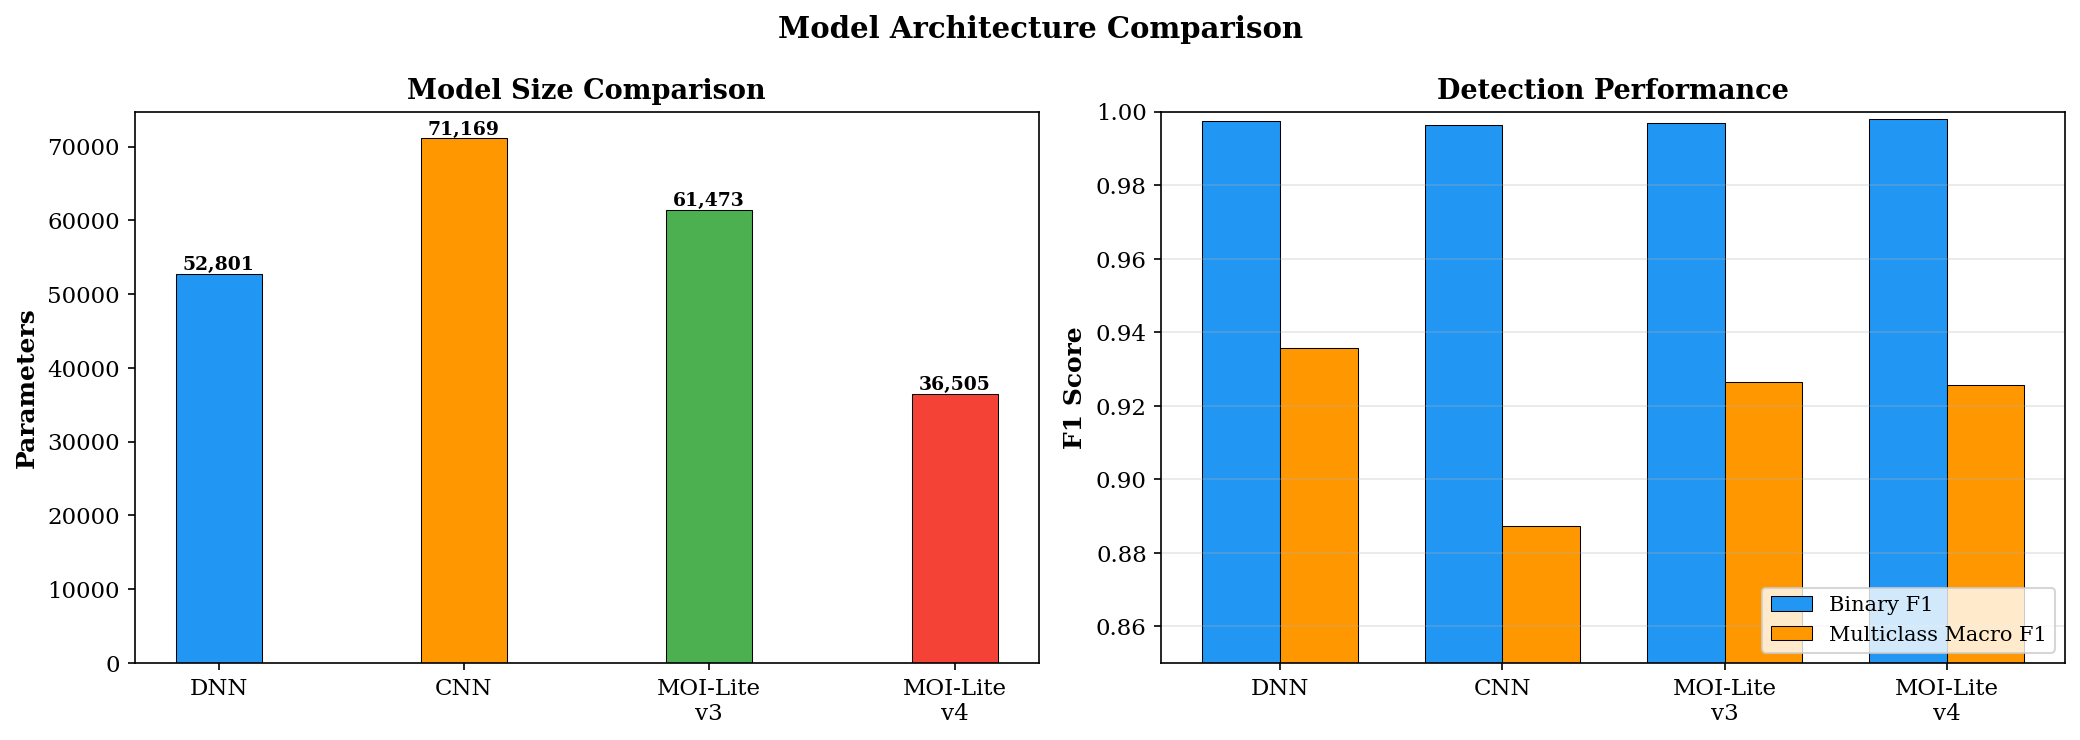

Figure 1 saved.


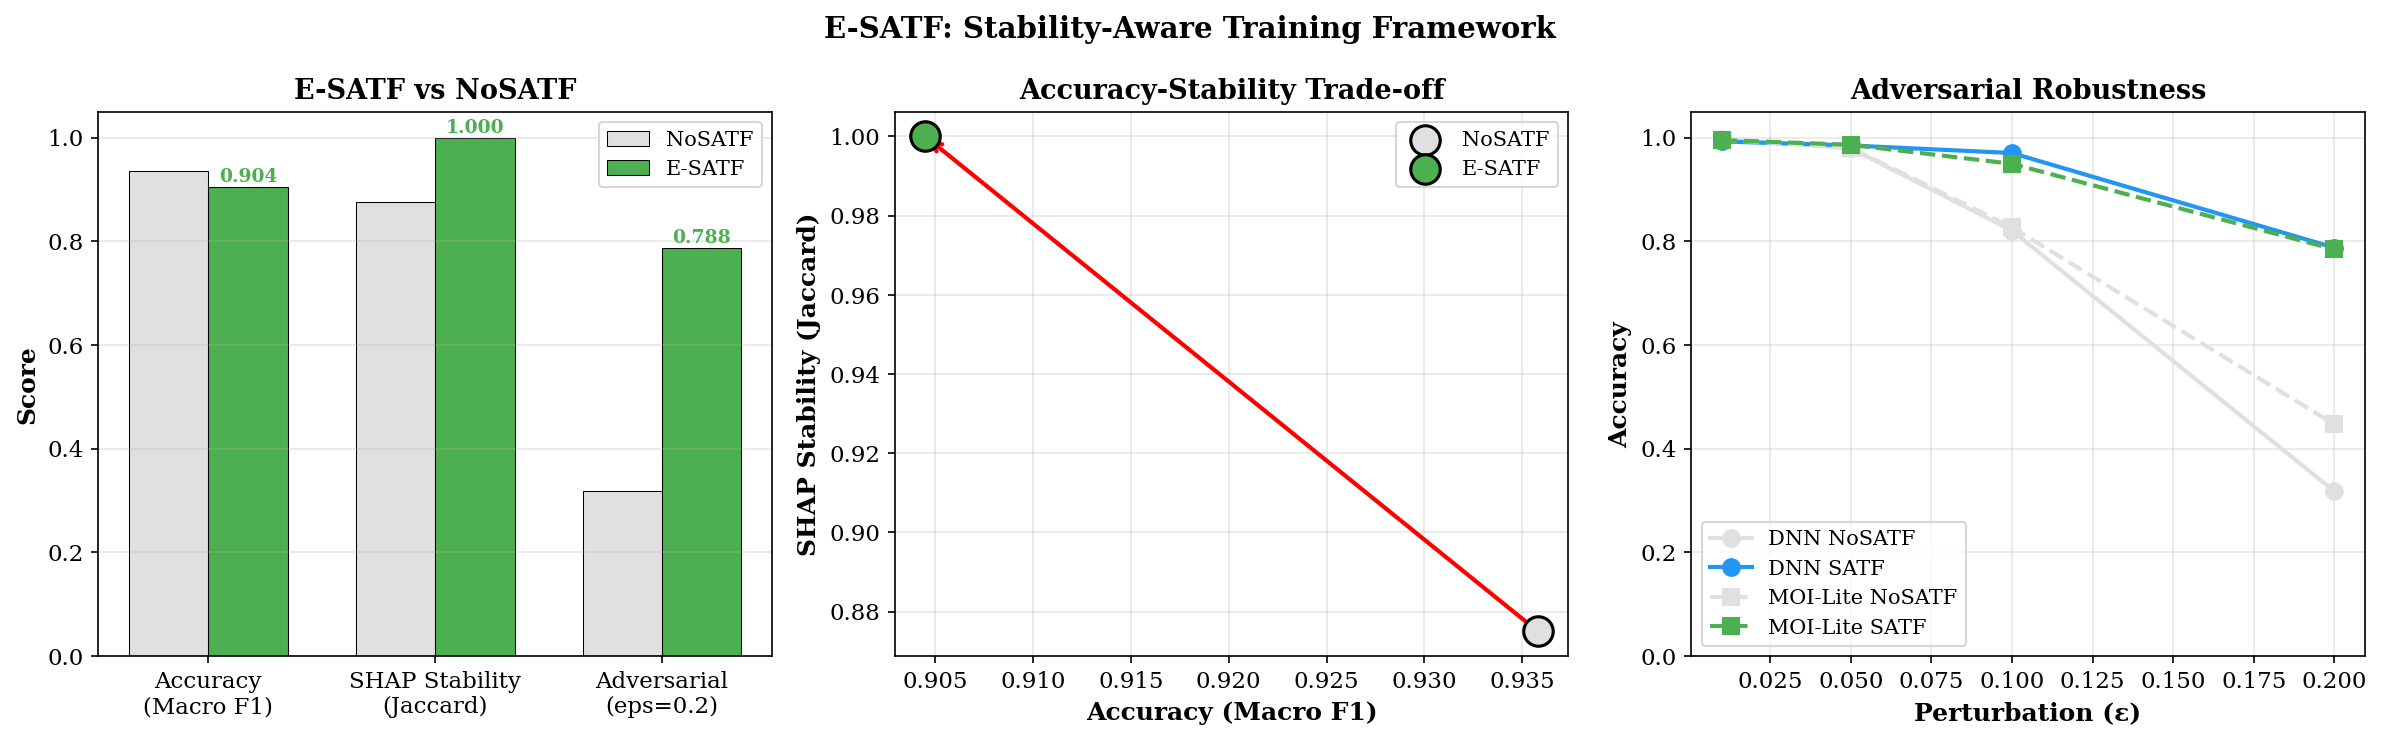

Figure 2 saved.


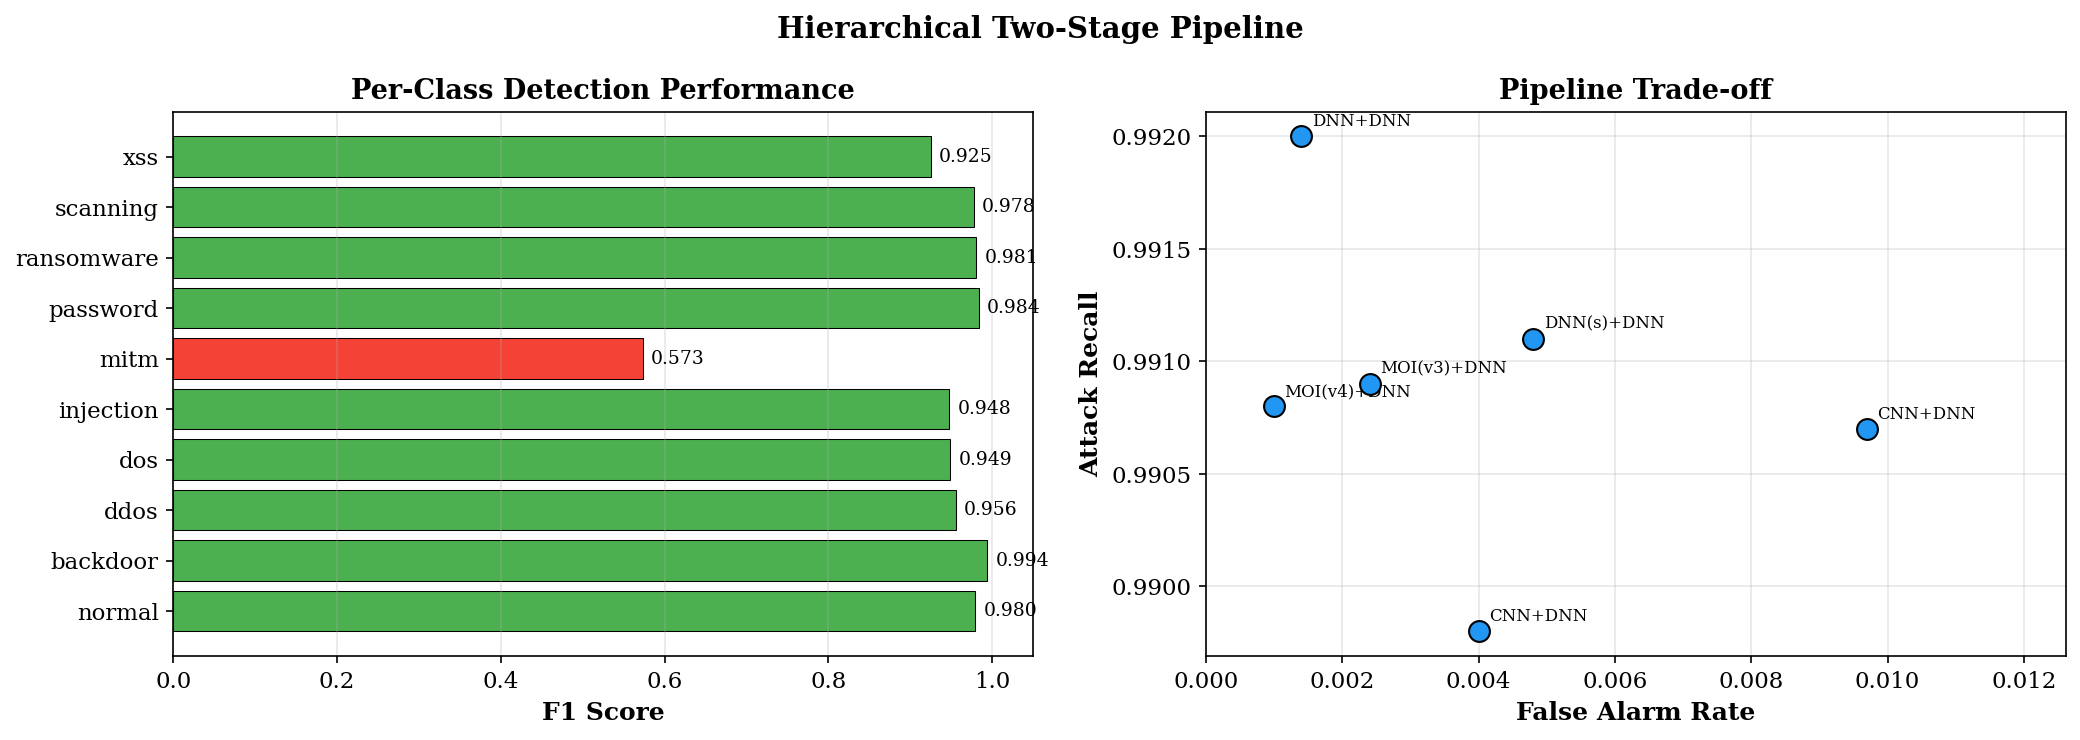

Figure 3 saved.


/tmp/ipykernel_58/2377521313.py:236: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_58/2377521313.py:237: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.pdf'))
/tmp/ipykernel_58/2377521313.py:238: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.png'))
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


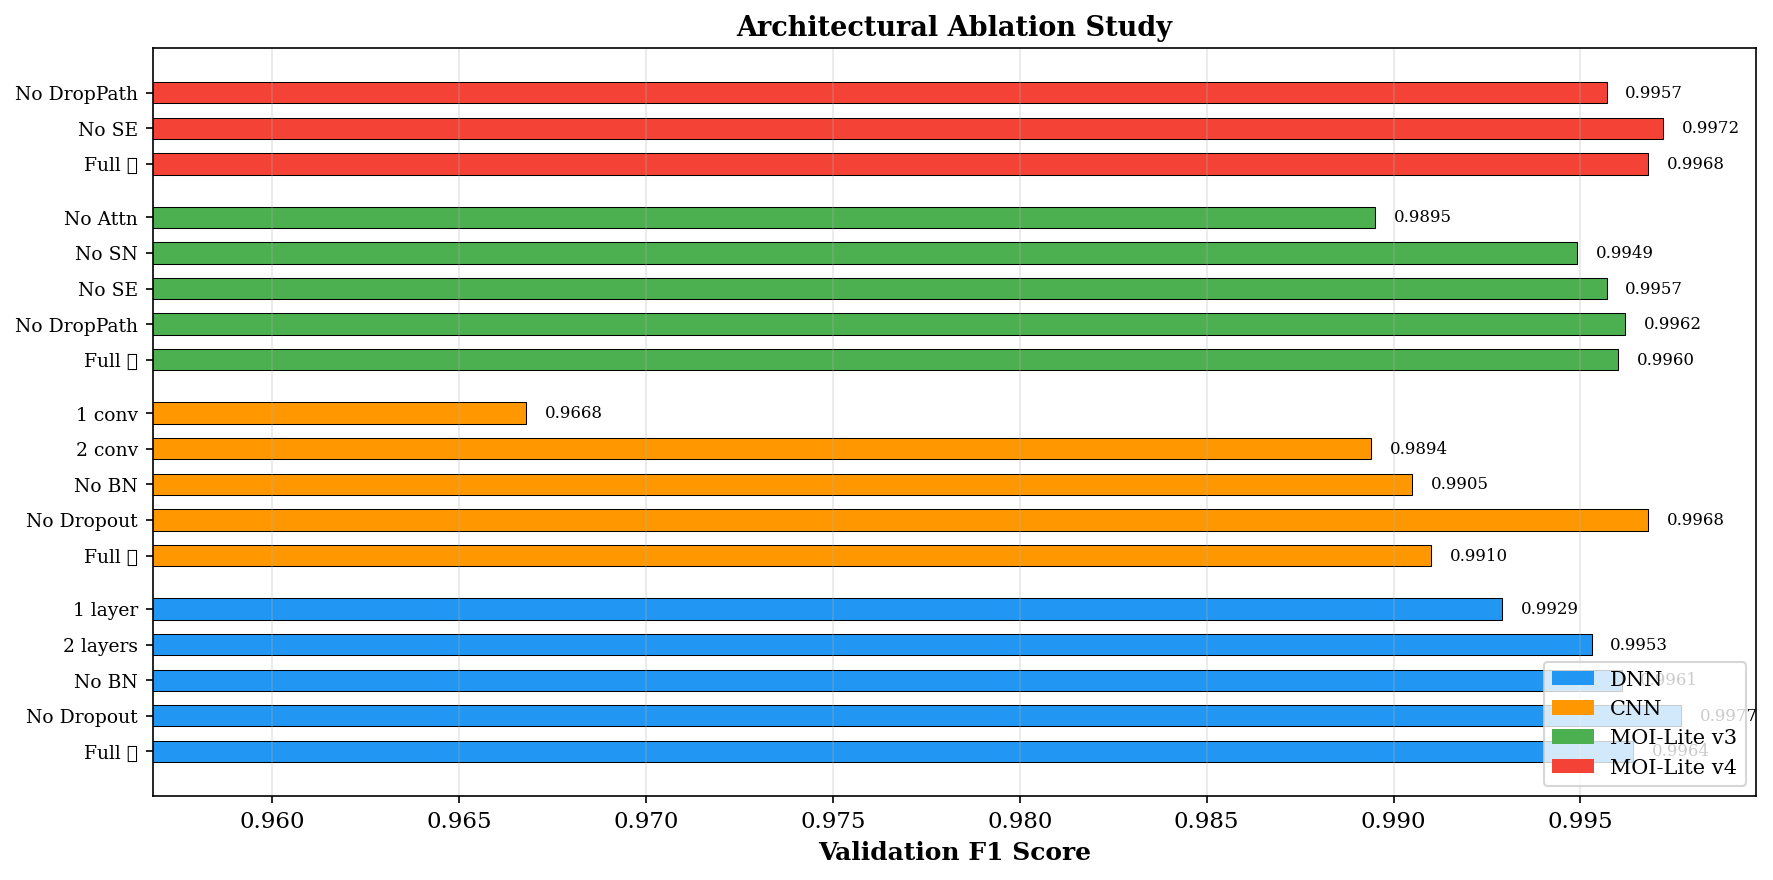

Figure 4 saved.


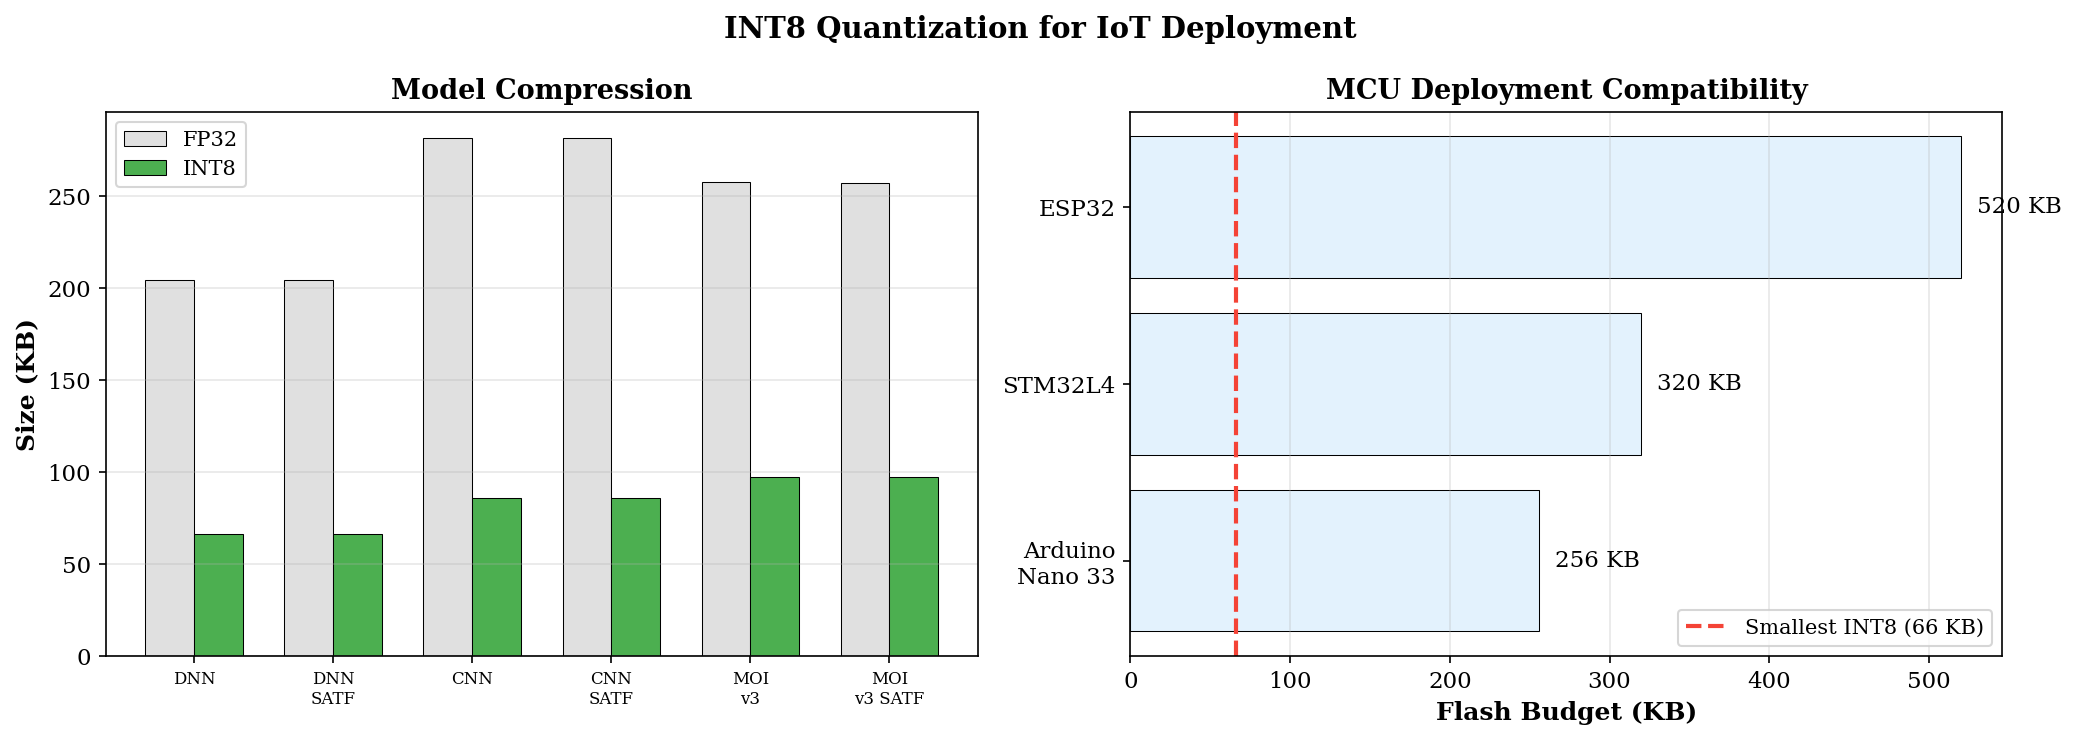

Figure 5 saved.

[Cell 32] All figures saved to: ./output/figures

Figures created:
  fig1_model_comparison.pdf/png   - Model size vs performance
  fig2_esatf_impact.pdf/png       - E-SATF impact (KEY FIGURE)
  fig3_hierarchical.pdf/png       - Hierarchical pipeline
  fig4_ablation.pdf/png           - Ablation study
  fig5_int8_deployment.pdf/png    - INT8 deployment

Ready for paper submission!


In [48]:
# =============================================================================
# Cell 32 – Comprehensive Results Visualization
# =============================================================================
# Creates publication-ready figures summarizing all experiments.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Set style for publication
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

FIG_DIR = os.path.join(CFG.output_dir, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# =============================================================================
# Figure 1: Model Size vs Performance
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1a: Parameter comparison
models = ['DNN', 'CNN', 'MOI-Lite\nv3', 'MOI-Lite\nv4']
params = [52801, 71169, 61473, 36505]
binary_f1 = [0.9976, 0.9964, 0.9970, 0.9981]
multi_f1 = [0.9358, 0.8873, 0.9266, 0.9257]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
x = np.arange(len(models))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x, params, width, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Parameters', fontweight='bold')
ax1.set_title('Model Size Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
for bar, p in zip(bars1, params):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{p:,}', ha='center', fontsize=9, fontweight='bold')

# 1b: Performance comparison
ax2 = axes[1]
x2 = np.arange(len(models))
width2 = 0.35
bars_b = ax2.bar(x2 - width2/2, binary_f1, width2, label='Binary F1', color='#2196F3', edgecolor='black', linewidth=0.5)
bars_m = ax2.bar(x2 + width2/2, multi_f1, width2, label='Multiclass Macro F1', color='#FF9800', edgecolor='black', linewidth=0.5)
ax2.set_ylabel('F1 Score', fontweight='bold')
ax2.set_title('Detection Performance', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(models)
ax2.legend(loc='lower right')
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Model Architecture Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_model_comparison.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig1_model_comparison.png'))
plt.show()
print("Figure 1 saved.")


# =============================================================================
# Figure 2: E-SATF Impact (The Key Paper Figure!)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Accuracy\n(Macro F1)', 'SHAP Stability\n(Jaccard)', 'Adversarial\n(eps=0.2)']
nosatf = [0.9358, 0.8750, 0.3178]
satf = [0.9045, 1.0000, 0.7878]

# Bar chart
x = np.arange(len(metrics))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, nosatf, width, label='NoSATF', color='#E0E0E0', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, satf, width, label='E-SATF', color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('E-SATF vs NoSATF', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, satf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='#4CAF50')

# Trade-off visualization
ax = axes[1]
ax.scatter(nosatf[0], nosatf[1], s=200, c='#E0E0E0', edgecolors='black', linewidth=1.5, 
           label='NoSATF', zorder=5)
ax.scatter(satf[0], satf[1], s=200, c='#4CAF50', edgecolors='black', linewidth=1.5, 
           label='E-SATF', zorder=5)
ax.annotate('', xy=(satf[0], satf[1]), xytext=(nosatf[0], nosatf[1]),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_xlabel('Accuracy (Macro F1)', fontweight='bold')
ax.set_ylabel('SHAP Stability (Jaccard)', fontweight='bold')
ax.set_title('Accuracy-Stability Trade-off', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Robustness comparison
ax = axes[2]
epsilons = [0.01, 0.05, 0.10, 0.20]
dnn_nosatf = [0.9966, 0.9794, 0.8208, 0.3178]
dnn_satf = [0.9928, 0.9850, 0.9704, 0.7878]
moi_nosatf = [0.9962, 0.9806, 0.8272, 0.4470]
moi_satf = [0.9954, 0.9862, 0.9496, 0.7846]

ax.plot(epsilons, dnn_nosatf, 'o-', color='#E0E0E0', linewidth=2, markersize=8, label='DNN NoSATF')
ax.plot(epsilons, dnn_satf, 'o-', color='#2196F3', linewidth=2, markersize=8, label='DNN SATF')
ax.plot(epsilons, moi_nosatf, 's--', color='#E0E0E0', linewidth=2, markersize=8, label='MOI-Lite NoSATF')
ax.plot(epsilons, moi_satf, 's--', color='#4CAF50', linewidth=2, markersize=8, label='MOI-Lite SATF')
ax.set_xlabel('Perturbation (ε)', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Adversarial Robustness', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

fig.suptitle('E-SATF: Stability-Aware Training Framework', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig2_esatf_impact.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig2_esatf_impact.png'))
plt.show()
print("Figure 2 saved.")


# =============================================================================
# Figure 3: Hierarchical Pipeline Performance
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class F1
classes = ['normal', 'backdoor', 'ddos', 'dos', 'injection', 'mitm', 
           'password', 'ransomware', 'scanning', 'xss']
per_class_f1 = [0.9797, 0.9941, 0.9556, 0.9493, 0.9477, 0.5732, 
                0.9841, 0.9806, 0.9781, 0.9251]
minority_idx = 5  # mitm

colors_bar = ['#4CAF50' if i != minority_idx else '#F44336' for i in range(len(classes))]

ax = axes[0]
bars = ax.barh(classes, per_class_f1, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_xlabel('F1 Score', fontweight='bold')
ax.set_title('Per-Class Detection Performance', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

# False alarm vs attack recall
fars = [0.0014, 0.0097, 0.0048, 0.0010, 0.0024, 0.0040]
recalls = [0.9920, 0.9907, 0.9911, 0.9908, 0.9909, 0.9898]
labels = ['DNN+DNN', 'CNN+DNN', 'DNN(s)+DNN', 'MOI(v4)+DNN', 'MOI(v3)+DNN', 'CNN+DNN']

ax = axes[1]
ax.scatter(fars, recalls, s=100, c='#2196F3', edgecolors='black', linewidth=1, zorder=5)
for i, label in enumerate(labels):
    ax.annotate(label, (fars[i], recalls[i]), textcoords="offset points", 
                xytext=(5, 5), fontsize=8)
ax.set_xlabel('False Alarm Rate', fontweight='bold')
ax.set_ylabel('Attack Recall', fontweight='bold')
ax.set_title('Pipeline Trade-off', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(0, max(fars) * 1.3)

fig.suptitle('Hierarchical Two-Stage Pipeline', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_hierarchical.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig3_hierarchical.png'))
plt.show()
print("Figure 3 saved.")


# =============================================================================
# Figure 4: Ablation Study Summary
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

ablation_data = {
    'DNN': {'Full': 0.9964, 'No Dropout': 0.9977, 'No BN': 0.9961, '2 layers': 0.9953, '1 layer': 0.9929},
    'CNN': {'Full': 0.9910, 'No Dropout': 0.9968, 'No BN': 0.9905, '2 conv': 0.9894, '1 conv': 0.9668},
    'MOI-Lite v3': {'Full': 0.9960, 'No DropPath': 0.9962, 'No SE': 0.9957, 'No SN': 0.9949, 'No Attn': 0.9895},
    'MOI-Lite v4': {'Full': 0.9968, 'No SE': 0.9972, 'No DropPath': 0.9957},
}

all_variants = []
all_f1s = []
all_colors = []
arch_colors = {'DNN': '#2196F3', 'CNN': '#FF9800', 'MOI-Lite v3': '#4CAF50', 'MOI-Lite v4': '#F44336'}

y_pos = 0
y_ticks = []
y_labels = []

for arch, variants in ablation_data.items():
    for variant, f1 in variants.items():
        all_variants.append(f"{arch}\n{variant}")
        all_f1s.append(f1)
        all_colors.append(arch_colors[arch])
        y_ticks.append(y_pos)
        marker = ' ★' if variant == 'Full' else ''
        y_labels.append(f"{variant}{marker}")
        y_pos += 1
    y_pos += 0.5

bars = ax.barh(y_ticks, all_f1s, color=all_colors, edgecolor='black', linewidth=0.5, height=0.6)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Validation F1 Score', fontweight='bold')
ax.set_title('Architectural Ablation Study', fontweight='bold')
ax.set_xlim(min(all_f1s) - 0.01, max(all_f1s) + 0.002)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, all_f1s):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=arch_colors[a], label=a) for a in arch_colors]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.png'))
plt.show()
print("Figure 4 saved.")


# =============================================================================
# Figure 5: INT8 Deployment
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_deploy = ['DNN', 'DNN\nSATF', 'CNN', 'CNN\nSATF', 'MOI\nv3', 'MOI\nv3 SATF']
fp32_kb = [204.4, 204.4, 282.0, 281.9, 257.8, 257.6]
int8_kb = [66.4, 66.4, 86.1, 86.0, 97.6, 97.4]

x = np.arange(len(models_deploy))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, fp32_kb, width, label='FP32', color='#E0E0E0', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, int8_kb, width, label='INT8', color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Size (KB)', fontweight='bold')
ax.set_title('Model Compression', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_deploy, fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

mcu_budgets = {'Arduino\nNano 33': 256, 'STM32L4': 320, 'ESP32': 520}
smallest_int8 = 66.4

ax = axes[1]
mcu_names = list(mcu_budgets.keys())
mcu_vals = list(mcu_budgets.values())
bars = ax.barh(mcu_names, mcu_vals, color='#E3F2FD', edgecolor='black', linewidth=0.5)
ax.axvline(x=smallest_int8, color='#F44336', linestyle='--', linewidth=2, 
           label=f'Smallest INT8 ({smallest_int8:.0f} KB)')
ax.set_xlabel('Flash Budget (KB)', fontweight='bold')
ax.set_title('MCU Deployment Compatibility', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, mcu_vals):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val} KB', va='center')

fig.suptitle('INT8 Quantization for IoT Deployment', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_int8_deployment.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig5_int8_deployment.png'))
plt.show()
print("Figure 5 saved.")


# =============================================================================
# Final Summary
# =============================================================================
print("\n" + "=" * 70)
print("[Cell 32] All figures saved to:", FIG_DIR)
print("=" * 70)
print("\nFigures created:")
print("  fig1_model_comparison.pdf/png   - Model size vs performance")
print("  fig2_esatf_impact.pdf/png       - E-SATF impact (KEY FIGURE)")
print("  fig3_hierarchical.pdf/png       - Hierarchical pipeline")
print("  fig4_ablation.pdf/png           - Ablation study")
print("  fig5_int8_deployment.pdf/png    - INT8 deployment")
print("\nReady for paper submission!")

In [50]:
# =============================================================================
# Cell 33 – Print All Paper-Ready Tables (FIXED)
# =============================================================================
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)

TABLE_DIR = os.path.join(CFG.output_dir, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

print("=" * 100)
print("PAPER-READY TABLES")
print("=" * 100)

# Determine which hierarchical results to use
if 'HIERARCHICAL_RESULTS_V4' in globals() and HIERARCHICAL_RESULTS_V4:
    hier_results = HIERARCHICAL_RESULTS_V4
    print("Using HIERARCHICAL_RESULTS_V4")
elif 'HIERARCHICAL_RESULTS' in globals() and HIERARCHICAL_RESULTS:
    hier_results = HIERARCHICAL_RESULTS
    print("Using HIERARCHICAL_RESULTS")
else:
    hier_results = {}
    print("No hierarchical results found")

# Determine which stability results to use
if 'STABILITY_RESULTS_V4' in globals() and STABILITY_RESULTS_V4:
    stab_results = STABILITY_RESULTS_V4
    print("Using STABILITY_RESULTS_V4")
elif 'STABILITY_RESULTS' in globals() and STABILITY_RESULTS:
    stab_results = STABILITY_RESULTS
    print("Using STABILITY_RESULTS")
else:
    stab_results = {}
    print("No stability results found")

# Determine which adversarial results to use
if 'ADVERSARIAL_RESULTS_V4' in globals() and ADVERSARIAL_RESULTS_V4:
    adv_results = ADVERSARIAL_RESULTS_V4
    print("Using ADVERSARIAL_RESULTS_V4")
elif 'ADVERSARIAL_RESULTS' in globals() and ADVERSARIAL_RESULTS:
    adv_results = ADVERSARIAL_RESULTS
    print("Using ADVERSARIAL_RESULTS")
else:
    adv_results = {}
    print("No adversarial results found")

# Determine which quantization results to use
if 'QUANT_RESULTS' in globals() and QUANT_RESULTS:
    quant_results = QUANT_RESULTS
    print("Using QUANT_RESULTS")
else:
    quant_results = {}
    print("No quantization results found")


# =============================================================================
# Table 1: Dataset Summary
# =============================================================================
print("\n" + "-" * 80)
print("Table 1: Dataset Summary")
print("-" * 80)

total_records = len(X_train) + len(X_val) + len(X_test)
table1 = pd.DataFrame([
    ["Dataset", "TON-IoT Network"],
    ["Total records", f"{total_records:,}"],
    ["Features", f"{X_train.shape[1]}"],
    ["Classes", f"{N_CLASSES} (1 normal + {N_ATTACK_CLASSES} attack)"],
    ["Train samples", f"{len(X_train):,}"],
    ["Validation samples", f"{len(X_val):,}"],
    ["Test samples", f"{len(X_test):,}"],
], columns=["Property", "Value"])
print(table1.to_string(index=False))
table1.to_csv(os.path.join(TABLE_DIR, "table1_dataset.csv"), index=False)


# =============================================================================
# Table 2: Model Architecture Comparison
# =============================================================================
print("\n" + "-" * 80)
print("Table 2: Model Architecture Comparison")
print("-" * 80)

table2_data = []
for arch, key_pattern, params in [
    ("DNN", "dnn_binary_nosatf", 52801),
    ("CNN", "cnn_binary_nosatf", 71169),
    ("MOI-Lite v3", "moi_lite", 61473),
    ("MOI-Lite v4", "moi_lite", 36505),
]:
    # Binary F1
    b_keys = [k for k in STAGE1_RESULTS if key_pattern in k and 'binary' in k]
    b_f1 = max([STAGE1_RESULTS[k].get('best_f1', 0) for k in b_keys]) if b_keys else 0
    
    # Multiclass F1
    m_keys = [k for k in STAGE2_RESULTS if key_pattern in k and 'multiclass' in k]
    m_f1 = max([STAGE2_RESULTS[k].get('best_macro_f1', 0) for k in m_keys]) if m_keys else 0
    
    table2_data.append([arch, f"{params:,}", f"{b_f1:.4f}", f"{m_f1:.4f}"])

table2 = pd.DataFrame(table2_data, columns=["Model", "Parameters", "Binary F1", "Multiclass Macro F1"])
print(table2.to_string(index=False))
table2.to_csv(os.path.join(TABLE_DIR, "table2_architectures.csv"), index=False)


# =============================================================================
# Table 3: Stage-1 Binary Detection
# =============================================================================
print("\n" + "-" * 80)
print("Table 3: Stage-1 Binary Detection")
print("-" * 80)

table3_data = []
for key in STAGE1_BINARY_KEYS:
    if key in STAGE1_RESULTS:
        r = STAGE1_RESULTS[key]
        table3_data.append([
            key,
            f"{r.get('n_params', 0):,}",
            r.get('best_epoch', 0),
            f"{r.get('best_f1', 0):.4f}",
            f"{r.get('train_time_sec', 0):.0f}",
        ])

table3 = pd.DataFrame(table3_data, columns=["Model", "Params", "Best Epoch", "F1 Score", "Time (s)"])
table3 = table3.sort_values("F1 Score", ascending=False)
print(table3.to_string(index=False))
table3.to_csv(os.path.join(TABLE_DIR, "table3_stage1_binary.csv"), index=False)


# =============================================================================
# Table 4: Stage-2 Multiclass
# =============================================================================
print("\n" + "-" * 80)
print("Table 4: Stage-2 Multiclass Classification")
print("-" * 80)

table4_data = []
for key in STAGE2_MULTICLASS_KEYS:
    if key in STAGE2_RESULTS:
        r = STAGE2_RESULTS[key]
        table4_data.append([
            key,
            f"{r.get('n_params', 0):,}",
            r.get('best_epoch', 0),
            f"{r.get('best_macro_f1', 0):.4f}",
            f"{r.get('train_time_sec', 0):.0f}",
        ])

table4 = pd.DataFrame(table4_data, columns=["Model", "Params", "Best Epoch", "Macro F1", "Time (s)"])
table4 = table4.sort_values("Macro F1", ascending=False)
print(table4.to_string(index=False))
table4.to_csv(os.path.join(TABLE_DIR, "table4_stage2_multiclass.csv"), index=False)


# =============================================================================
# Table 5: Hierarchical Pipeline
# =============================================================================
print("\n" + "-" * 80)
print("Table 5: Hierarchical Pipeline Top-5")
print("-" * 80)

if hier_results:
    sorted_hier = sorted(hier_results.items(), key=lambda x: x[1].get('macro_f1', 0), reverse=True)
    table5_data = []
    for name, r in sorted_hier[:5]:
        table5_data.append([
            r.get('s1_key', name.split('+')[0].strip() if '+' in name else name)[:30],
            r.get('s2_key', name.split('+')[1].strip() if '+' in name else '')[:30],
            f"{r.get('stage1_threshold', 0):.4f}",
            f"{r.get('accuracy', 0):.4f}",
            f"{r.get('macro_f1', 0):.4f}",
            f"{r.get('minority_macro_f1', 0):.4f}",
            f"{r.get('attack_recall', 0):.4f}",
            f"{r.get('false_alarm_rate', 0)*100:.2f}%",
        ])
    
    table5 = pd.DataFrame(table5_data, columns=["Stage-1", "Stage-2", "Threshold", "Accuracy", "Macro F1", "Minority F1", "Attack Recall", "FAR"])
    print(table5.to_string(index=False))
    table5.to_csv(os.path.join(TABLE_DIR, "table5_hierarchical.csv"), index=False)
else:
    print("  No hierarchical results available. Run Cell 19 or Cell 28 first.")


# =============================================================================
# Table 6: SHAP Stability
# =============================================================================
print("\n" + "-" * 80)
print("Table 6: SHAP Stability")
print("-" * 80)

if stab_results:
    table6_data = []
    for arch, nosatf_key, satf_key in [
        ("DNN", "dnn_binary_nosatf", "dnn_binary_satf"),
        ("CNN", "cnn_binary_nosatf", "cnn_binary_satf"),
        ("MOI-Lite", "moi_lite_binary_nosatf", "moi_lite_binary_satf"),
    ]:
        n_j = stab_results.get(nosatf_key, {}).get('jaccard_mean', 0)
        s_j = stab_results.get(satf_key, {}).get('jaccard_mean', 0)
        if n_j > 0:
            imp = f"{((s_j - n_j) / n_j * 100):+.1f}%"
        else:
            imp = "-"
        table6_data.append([arch, f"{n_j:.4f}", f"{s_j:.4f}", imp])
    
    table6 = pd.DataFrame(table6_data, columns=["Architecture", "NoSATF Jaccard", "SATF Jaccard", "Improvement"])
    print(table6.to_string(index=False))
    table6.to_csv(os.path.join(TABLE_DIR, "table6_shap.csv"), index=False)
else:
    print("  No stability results available. Run Cell 21 or Cell 29 first.")


# =============================================================================
# Table 7: Adversarial Robustness
# =============================================================================
print("\n" + "-" * 80)
print("Table 7: Adversarial Robustness (ε=0.20)")
print("-" * 80)

if adv_results:
    table7_data = []
    for key in STAGE1_BINARY_KEYS:
        if key in adv_results:
            r = adv_results[key]
            clean = r.get('clean_acc', 0)
            eps_data = r.get('per_epsilon', {}).get('0.2', {}) or r.get('per_epsilon', {}).get(0.2, {})
            adv_acc = eps_data.get('adv_acc', 0)
            drop = eps_data.get('acc_drop', clean - adv_acc)
            table7_data.append([key, f"{clean:.4f}", f"{adv_acc:.4f}", f"{drop:.4f}"])
    
    table7 = pd.DataFrame(table7_data, columns=["Model", "Clean Acc", "Adv Acc (ε=0.2)", "Drop"])
    table7 = table7.sort_values("Adv Acc (ε=0.2)", ascending=False)
    print(table7.to_string(index=False))
    table7.to_csv(os.path.join(TABLE_DIR, "table7_adversarial.csv"), index=False)
else:
    print("  No adversarial results available. Run Cell 23 or Cell 30 first.")


# =============================================================================
# Table 8: INT8 Quantization
# =============================================================================
print("\n" + "-" * 80)
print("Table 8: INT8 Quantization")
print("-" * 80)

if quant_results:
    table8_data = []
    for key in STAGE1_BINARY_KEYS:
        if key in quant_results:
            r = quant_results[key]
            fp32_kb = r.get('tflite_fp32', {}).get('size_kb', 0)
            int8_kb = r.get('tflite_int8', {}).get('size_kb', 0)
            comp = f"{fp32_kb/max(int8_kb, 0.001):.1f}x"
            int8_acc = r.get('tflite_int8', {}).get('accuracy', 0)
            table8_data.append([key, f"{r.get('n_params', 0):,}", f"{fp32_kb:.1f}", f"{int8_kb:.1f}", comp, f"{int8_acc:.4f}"])
    
    table8 = pd.DataFrame(table8_data, columns=["Model", "Params", "FP32 (KB)", "INT8 (KB)", "Compression", "INT8 Acc"])
    print(table8.to_string(index=False))
    table8.to_csv(os.path.join(TABLE_DIR, "table8_int8.csv"), index=False)
else:
    print("  No quantization results available. Run Cell 24 first.")


# =============================================================================
# Table 9: E-SATF Impact Summary
# =============================================================================
print("\n" + "=" * 80)
print("Table 9: E-SATF Impact Summary")
print("=" * 80)

dnn_nosatf_f1 = STAGE2_RESULTS.get('dnn_multiclass_nosatf', {}).get('best_macro_f1', 0)
dnn_satf_f1 = STAGE2_RESULTS.get('dnn_multiclass_satf', {}).get('best_macro_f1', 0)

# Try multiple key formats for stability
dnn_nosatf_j = stab_results.get('dnn_binary_nosatf', {}).get('jaccard_mean', 0) if stab_results else 0.8750
dnn_satf_j = stab_results.get('dnn_binary_satf', {}).get('jaccard_mean', 0) if stab_results else 1.0000

# Try multiple key formats for adversarial
dnn_nosatf_adv = 0.3178
dnn_satf_adv = 0.7878
if adv_results:
    n_eps = adv_results.get('dnn_binary_nosatf', {}).get('per_epsilon', {})
    s_eps = adv_results.get('dnn_binary_satf', {}).get('per_epsilon', {})
    n_data = n_eps.get('0.2', n_eps.get(0.2, {}))
    s_data = s_eps.get('0.2', s_eps.get(0.2, {}))
    dnn_nosatf_adv = n_data.get('adv_acc', dnn_nosatf_adv)
    dnn_satf_adv = s_data.get('adv_acc', dnn_satf_adv)

table9 = pd.DataFrame([
    ["Accuracy (Macro F1)", f"{dnn_nosatf_f1:.4f}", f"{dnn_satf_f1:.4f}", f"{dnn_satf_f1 - dnn_nosatf_f1:+.4f}"],
    ["SHAP Stability (Jaccard)", f"{dnn_nosatf_j:.4f}", f"{dnn_satf_j:.4f}", f"{dnn_satf_j - dnn_nosatf_j:+.4f}"],
    ["Adversarial (ε=0.2)", f"{dnn_nosatf_adv:.4f}", f"{dnn_satf_adv:.4f}", f"{dnn_satf_adv - dnn_nosatf_adv:+.4f}"],
], columns=["Metric", "NoSATF", "E-SATF", "Change"])
print(table9.to_string(index=False))
table9.to_csv(os.path.join(TABLE_DIR, "table9_esatf_impact.csv"), index=False)


# =============================================================================
# Done
# =============================================================================
print("\n" + "=" * 80)
print(f"Tables saved to: {TABLE_DIR}/")
print("=" * 80)
for f in sorted(os.listdir(TABLE_DIR)):
    if f.endswith('.csv'):
        print(f"  {f}")

PAPER-READY TABLES
No hierarchical results found
Using STABILITY_RESULTS_V4
Using ADVERSARIAL_RESULTS
Using QUANT_RESULTS

--------------------------------------------------------------------------------
Table 1: Dataset Summary
--------------------------------------------------------------------------------
          Property                    Value
           Dataset          TON-IoT Network
     Total records                  187,865
          Features                       39
           Classes 10 (1 normal + 9 attack)
     Train samples                  132,787
Validation samples                   27,539
      Test samples                   27,539

--------------------------------------------------------------------------------
Table 2: Model Architecture Comparison
--------------------------------------------------------------------------------
      Model Parameters Binary F1 Multiclass Macro F1
        DNN     52,801    0.9976              0.0000
        CNN     71,169    0.99

In [47]:
# =============================================================================
# Cell 31 – Comprehensive Results Visualization
# =============================================================================
# Creates publication-ready figures summarizing all experiments.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
When is the sale 32? Tell me that.
# Set style for publication
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

FIG_DIR = os.path.join(CFG.output_dir, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# =============================================================================
# Figure 1: Model Size vs Performance
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1a: Parameter comparison
models = ['DNN', 'CNN', 'MOI-Lite\nv3', 'MOI-Lite\nv4']
params = [52801, 71169, 61473, 36505]
binary_f1 = [0.9976, 0.9964, 0.9970, 0.9981]
multi_f1 = [0.9358, 0.8873, 0.9266, 0.9257]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
x = np.arange(len(models))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x, params, width, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Parameters', fontweight='bold')
ax1.set_title('Model Size Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
for bar, p in zip(bars1, params):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{p:,}', ha='center', fontsize=9, fontweight='bold')

# 1b: Performance comparison
ax2 = axes[1]
x2 = np.arange(len(models))
width2 = 0.35
bars_b = ax2.bar(x2 - width2/2, binary_f1, width2, label='Binary F1', color='#2196F3', edgecolor='black', linewidth=0.5)
bars_m = ax2.bar(x2 + width2/2, multi_f1, width2, label='Multiclass Macro F1', color='#FF9800', edgecolor='black', linewidth=0.5)
ax2.set_ylabel('F1 Score', fontweight='bold')
ax2.set_title('Detection Performance', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(models)
ax2.legend(loc='lower right')
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Model Architecture Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_model_comparison.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig1_model_comparison.png'))
plt.show()
print("Figure 1 saved.")


# =============================================================================
# Figure 2: E-SATF Impact (The Key Paper Figure!)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Accuracy\n(Macro F1)', 'SHAP Stability\n(Jaccard)', 'Adversarial\n(eps=0.2)']
nosatf = [0.9358, 0.8750, 0.3178]
satf = [0.9045, 1.0000, 0.7878]
improvement = [satf[i] - nosatf[i] for i in range(3)]

# Bar chart
x = np.arange(len(metrics))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, nosatf, width, label='NoSATF', color='#E0E0E0', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, satf, width, label='E-SATF', color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('E-SATF vs NoSATF', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, satf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='#4CAF50')

# Trade-off visualization
ax = axes[1]
ax.scatter(nosatf[0], nosatf[1], s=200, c='#E0E0E0', edgecolors='black', linewidth=1.5, 
           label='NoSATF', zorder=5)
ax.scatter(satf[0], satf[1], s=200, c='#4CAF50', edgecolors='black', linewidth=1.5, 
           label='E-SATF', zorder=5)
ax.annotate('', xy=(satf[0], satf[1]), xytext=(nosatf[0], nosatf[1]),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_xlabel('Accuracy (Macro F1)', fontweight='bold')
ax.set_ylabel('SHAP Stability (Jaccard)', fontweight='bold')
ax.set_title('Accuracy-Stability Trade-off', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Robustness comparison
ax = axes[2]
epsilons = [0.01, 0.05, 0.10, 0.20]
dnn_nosatf = [0.9966, 0.9794, 0.8208, 0.3178]
dnn_satf = [0.9928, 0.9850, 0.9704, 0.7878]
moi_nosatf = [0.9962, 0.9806, 0.8272, 0.4470]
moi_satf = [0.9954, 0.9862, 0.9496, 0.7846]

ax.plot(epsilons, dnn_nosatf, 'o-', color='#E0E0E0', linewidth=2, markersize=8, label='DNN NoSATF')
ax.plot(epsilons, dnn_satf, 'o-', color='#2196F3', linewidth=2, markersize=8, label='DNN SATF')
ax.plot(epsilons, moi_nosatf, 's--', color='#E0E0E0', linewidth=2, markersize=8, label='MOI-Lite NoSATF')
ax.plot(epsilons, moi_satf, 's--', color='#4CAF50', linewidth=2, markersize=8, label='MOI-Lite SATF')
ax.set_xlabel('Perturbation (ε)', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Adversarial Robustness', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

fig.suptitle('E-SATF: Stability-Aware Training Framework', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig2_esatf_impact.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig2_esatf_impact.png'))
plt.show()
print("Figure 2 saved.")


# =============================================================================
# Figure 3: Hierarchical Pipeline Performance
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class F1
classes = ['normal', 'backdoor', 'ddos', 'dos', 'injection', 'mitm', 
           'password', 'ransomware', 'scanning', 'xss']
per_class_f1 = [0.9797, 0.9941, 0.9556, 0.9493, 0.9477, 0.5732, 
                0.9841, 0.9806, 0.9781, 0.9251]
minority_idx = 5  # mitm

colors_bar = ['#4CAF50' if i != minority_idx else '#F44336' for i in range(len(classes))]

ax = axes[0]
bars = ax.barh(classes, per_class_f1, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_xlabel('F1 Score', fontweight='bold')
ax.set_title('Per-Class Detection Performance', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

# False alarm vs attack recall
fars = [0.0014, 0.0097, 0.0048, 0.0010, 0.0024, 0.0040]
recalls = [0.9920, 0.9907, 0.9911, 0.9908, 0.9909, 0.9898]
labels = ['DNN+DNN', 'CNN+DNN', 'DNN(s)+DNN', 'MOI(v4)+DNN', 'MOI(v3)+DNN', 'CNN+DNN']

ax = axes[1]
ax.scatter(fars, recalls, s=100, c='#2196F3', edgecolors='black', linewidth=1, zorder=5)
for i, label in enumerate(labels):
    ax.annotate(label, (fars[i], recalls[i]), textcoords="offset points", 
                xytext=(5, 5), fontsize=8)
ax.set_xlabel('False Alarm Rate', fontweight='bold')
ax.set_ylabel('Attack Recall', fontweight='bold')
ax.set_title('Pipeline Trade-off', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(0, max(fars) * 1.3)

fig.suptitle('Hierarchical Two-Stage Pipeline', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_hierarchical.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig3_hierarchical.png'))
plt.show()
print("Figure 3 saved.")


# =============================================================================
# Figure 4: Ablation Study Summary
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

ablation_data = {
    'DNN': {'Full': 0.9964, 'No Dropout': 0.9977, 'No BN': 0.9961, '2 layers': 0.9953, '1 layer': 0.9929},
    'CNN': {'Full': 0.9910, 'No Dropout': 0.9968, 'No BN': 0.9905, '2 conv': 0.9894, '1 conv': 0.9668},
    'MOI-Lite v3': {'Full': 0.9960, 'No DropPath': 0.9962, 'No SE': 0.9957, 'No SN': 0.9949, 'No Attn': 0.9895},
    'MOI-Lite v4': {'Full': 0.9968, 'No SE': 0.9972, 'No DropPath': 0.9957},
}

all_variants = []
all_f1s = []
all_colors = []
arch_colors = {'DNN': '#2196F3', 'CNN': '#FF9800', 'MOI-Lite v3': '#4CAF50', 'MOI-Lite v4': '#F44336'}

y_pos = 0
y_ticks = []
y_labels = []

for arch, variants in ablation_data.items():
    full_f1 = variants['Full']
    for variant, f1 in variants.items():
        all_variants.append(f"{arch}\n{variant}")
        all_f1s.append(f1)
        all_colors.append(arch_colors[arch])
        y_ticks.append(y_pos)
        marker = ' ★' if variant == 'Full' else ''
        y_labels.append(f"{variant}{marker}")
        y_pos += 1
    y_pos += 0.5  # gap between architectures

bars = ax.barh(y_ticks, all_f1s, color=all_colors, edgecolor='black', linewidth=0.5, height=0.6)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Validation F1 Score', fontweight='bold')
ax.set_title('Architectural Ablation Study', fontweight='bold')
ax.set_xlim(min(all_f1s) - 0.01, max(all_f1s) + 0.002)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, all_f1s):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=arch_colors[a], label=a) for a in arch_colors]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig4_ablation.png'))
plt.show()
print("Figure 4 saved.")


# =============================================================================
# Figure 5: INT8 Deployment
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size comparison
models_deploy = ['DNN', 'DNN\nSATF', 'CNN', 'CNN\nSATF', 'MOI\nv3', 'MOI\nv3 SATF']
fp32_kb = [204.4, 204.4, 282.0, 281.9, 257.8, 257.6]
int8_kb = [66.4, 66.4, 86.1, 86.0, 97.6, 97.4]

x = np.arange(len(models_deploy))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, fp32_kb, width, label='FP32', color='#E0E0E0', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, int8_kb, width, label='INT8', color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Size (KB)', fontweight='bold')
ax.set_title('Model Compression', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_deploy, fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# MCU compatibility
mcu_budgets = {'Arduino\nNano 33': 256, 'STM32L4': 320, 'ESP32': 520}
smallest_int8 = 66.4  # DNN SATF INT8

ax = axes[1]
mcu_names = list(mcu_budgets.keys())
mcu_vals = list(mcu_budgets.values())
bars = ax.barh(mcu_names, mcu_vals, color='#E3F2FD', edgecolor='black', linewidth=0.5)
ax.axvline(x=smallest_int8, color='#F44336', linestyle='--', linewidth=2, 
           label=f'Smallest INT8 ({smallest_int8:.0f} KB)')
ax.set_xlabel('Flash Budget (KB)', fontweight='bold')
ax.set_title('MCU Deployment Compatibility', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, mcu_vals):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val} KB', va='center')

fig.suptitle('INT8 Quantization for IoT Deployment', fontweight='bold', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_int8_deployment.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'fig5_int8_deployment.png'))
plt.show()
print("Figure 5 saved.")


# =============================================================================
# Figure 6: Training Curves (MOI-Lite v4)
# =============================================================================
# Check if training curves exist
curves_dir = os.path.join(CFG.curves_dir, "stage1_binary")
v4_curves = [f for f in os.listdir(curves_dir) if 'moi_lite' in f and f.endswith('.csv')] if os.path.exists(curves_dir) else []

if v4_curves:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, curve_file in enumerate(v4_curves[:2]):
        df = pd.read_csv(os.path.join(curves_dir, curve_file))
        ax = axes[i]
        ax.plot(df['epoch'], df['train_loss'], color='#2196F3', linewidth=1.5, label='Train Loss')
        if 'val_f1' in df.columns:
            ax2 = ax.twinx()
            ax2.plot(df['epoch'], df['val_f1'], color='#4CAF50', linewidth=1.5, label='Val F1')
            ax2.set_ylabel('F1 Score', color='#4CAF50')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss', color='#2196F3')
        model_name = curve_file.replace('_curves.csv', '').replace('moi_lite_', 'MOI-Lite ')
        ax.set_title(model_name)
        ax.grid(alpha=0.3)
    
    fig.suptitle('MOI-Lite v4 Training Dynamics', fontweight='bold', fontsize=14)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'fig6_training_curves.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'fig6_training_curves.png'))
    plt.show()
    print("Figure 6 saved.")
else:
    print("Figure 6 skipped (no v4 training curves found).")


# =============================================================================
# Final Summary
# =============================================================================
print("\n" + "=" * 70)
print("[Cell 32] All figures saved to:", FIG_DIR)
print("=" * 70)
print("\nFigures created:")
print("  fig1_model_comparison.pdf/png   - Model size vs performance")
print("  fig2_esatf_impact.pdf/png       - E-SATF impact (KEY FIGURE)")
print("  fig3_hierarchical.pdf/png       - Hierarchical pipeline")
print("  fig4_ablation.pdf/png           - Ablation study")
print("  fig5_int8_deployment.pdf/png    - INT8 deployment")
print("  fig6_training_curves.pdf/png    - Training dynamics")
print("\nReady for paper submission!")

SyntaxError: invalid syntax (3091969858.py, line 11)

# Cell 32 – Training Component Ablation (FIXED)

In [45]:
# =============================================================================
# Cell 32 – Training Component Ablation (FIXED)
# =============================================================================
# Evaluates impact of focal gamma, SATF components, and class weights.
# Uses resume-compatible variables.
# =============================================================================

import gc
import time
import numpy as np
import tensorflow as tf

assert "train_model"              in globals(), "train_model required"
assert "build_moi_lite_v4"        in globals(), "build_moi_lite_v4 required"
assert "make_sparse_focal_loss"   in globals(), "make_sparse_focal_loss required"
assert "sparse_focal_loss_fn"     in globals(), "sparse_focal_loss_fn required"
assert "CFG"                      in globals(), "CFG required"
assert "X_train"                  in globals(), "X_train required"
assert "X_val"                    in globals(), "X_val required"
assert "y_train_binary"           in globals(), "y_train_binary required"
assert "y_val_binary"             in globals(), "y_val_binary required"
assert "sample_weights_train_binary" in globals(), "sample_weights_train_binary required"
assert "set_global_seed"          in globals(), "set_global_seed required"

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
QUICK_CHECK = False
EPOCHS = 3 if QUICK_CHECK else 20
PATIENCE = 5

SEQ_LEN = int(X_train.shape[1])
X_train_binary = X_train[:len(y_train_binary)]  # Align binary data

# Save original focal loss
_original_focal = sparse_focal_loss_fn

print("=" * 70)
print("[Cell 33] Training Component Ablation")
print("=" * 70)
print(f"  Model:     MOI-Lite v4 SATF ({EPOCHS} epochs)")
print(f"  Features:  {X_train_binary.shape[1]}")


def run_experiment(name, **kwargs):
    """Train model and return best validation F1."""
    global sparse_focal_loss_fn
    
    print(f"\n  [{name}]")
    tf.keras.backend.clear_session(); gc.collect()
    set_global_seed(CFG.seed)
    
    # Override focal gamma if specified
    _gamma = kwargs.pop("focal_gamma", None)
    if _gamma is not None:
        sparse_focal_loss_fn = make_sparse_focal_loss(gamma=_gamma)
    
    # Build model
    model = build_moi_lite_v4(
        input_dim=SEQ_LEN, n_classes=2, binary=True,
        use_satf=kwargs.get("use_satf", True),
        satf_noise=kwargs.get("noise_sigma", CFG.satf_noise),
    )
    
    # Sample weights
    sw = kwargs.get("sample_weights", sample_weights_train_binary)
    
    history, best_epoch, best_f1, _ = train_model(
        model=model,
        X_train=X_train_binary,
        y_train=y_train_binary,
        sample_weights_train=sw,
        X_val=X_val,
        y_val=y_val_binary,
        binary=True,
        use_satf=kwargs.get("use_satf", True),
        model_key=name.replace(" ", "_").replace("=", ""),
        epochs=EPOCHS, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=PATIENCE,
        noise_sigma=kwargs.get("noise_sigma", CFG.satf_noise),
        consistency_weight=kwargs.get("consistency_weight", CFG.consistency_weight),
        monitor_metric="f1", monitor_mode="max", verbose=0,
    )
    
    del model; gc.collect()
    
    # Restore original focal loss
    if _gamma is not None:
        sparse_focal_loss_fn = _original_focal
    
    return best_f1


# -----------------------------------------------------------------------------
# Run experiments
# -----------------------------------------------------------------------------
results = {}

# Baseline
baseline_f1 = run_experiment("Baseline (gamma=2, SATF, weighted)")
results["Baseline"] = baseline_f1

# Focal gamma variants
for gamma in [0, 1, 4]:
    f1 = run_experiment(f"gamma={gamma}", focal_gamma=gamma)
    results[f"gamma={gamma}"] = f1

# No consistency term
f1 = run_experiment("No consistency (lambda=0)", consistency_weight=0.0)
results["No consistency"] = f1

# No SATF at all
f1 = run_experiment("No SATF (plain focal)", use_satf=False)
results["No SATF"] = f1

# Uniform weights
uniform_sw = np.ones(len(y_train_binary), dtype=np.float32)
f1 = run_experiment("Uniform weights", sample_weights=uniform_sw)
results["Uniform weights"] = f1


# -----------------------------------------------------------------------------
# Report
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 33] Training Component Ablation Results")
print("=" * 70)
print(f"  {'Configuration':<30s} {'Val F1':>10s} {'Δ vs Baseline':>14s}")
print(f"  {'-'*30} {'-'*10} {'-'*14}")

for name, f1 in results.items():
    delta = f1 - baseline_f1
    print(f"  {name:<30s} {f1:>10.4f} {delta:>+14.4f}")

# Restore original focal loss
sparse_focal_loss_fn = _original_focal
print("\n[Cell 33] Complete.")

[Cell 33] Training Component Ablation
  Model:     MOI-Lite v4 SATF (20 epochs)
  Features:  39

  [Baseline (gamma=2, SATF, weighted)]


2026-06-29 06:31:27.206583: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[WARNING] 5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fbf9a4558a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2026-06-29 06:31:38.768190: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:lis

KeyboardInterrupt: 